# Loading sweep results.

## Prepare the notebook.

### Import the libraries.

In [36]:
import logging
import os
import sys
import yaml

from hydra import initialize, compose
from matplotlib.patches import PathPatch, Rectangle
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import pandas as pd
import scanpy as sc
from scipy.special import softmax
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import torch
from tqdm import tqdm

from sc_exp_design.constants import ParamsFields


### Initialize logger.

In [37]:
logger = logging.getLogger("notebook")
logger.setLevel(logging.INFO)

# Avoid adding handlers multiple times when cells re-run
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%H:%M:%S"
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)

logger.propagate = False

### Import additional modules.

In [38]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"
sys.path.insert(0, f"{BASE_DIR}/model_utils")
sys.path.insert(0, f"{BASE_DIR}/inverse/experiments")
from experiment_utils import get_forward_model, create_dir
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel



### Constants.

In [39]:
ANNOTATION_CONFIG_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
RESULTS_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results"
CONFIG_DIR = "../config"
# PLOTS_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/plots/plots_presentation"
PLOTS_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/plots_presentation"
CONFIG_NAME = "run_inverse"
cell_state_rep = "X_channel_standardized+X_scatter_standardized"
condition_rep = "condition_concat"

### Read default configuration.

In [71]:
with initialize(config_path=CONFIG_DIR, version_base=None):
    base_cfg = compose(config_name=CONFIG_NAME)
print(base_cfg)

{'forward_model': {'num_time_steps': 1000, 'solver_kwargs': {'method': 'euler'}}, 'loss_guidance': {'fix_noise': True, 'num_forward_pass_per_sample': 350, 'regularization': None, 'reg_strength': 0.0, 'n_time_steps_forward_model': 50, 'solver_kwargs_forward_model': {'method': 'euler'}}, 'non_linearity': {'non_linearity_id': 'relu', 'non_linearity_kwargs': None}, 'paths': {'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/dainty-fog-107_FlowMatching.pkl', 'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl', 'prior_flow_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/prior_flow_FlowMatching.pkl', 'dump_dir': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results'}, 'run': {'random_seed': 42}, 'sampling': {'target_cell_type': 'HSCs', 'N': 125, 'num_time

### Define helper functions.

In [72]:
def get_rescaling(
    adata: sc.AnnData,
    channel_params_key: str = "X_channel_params", 
    scatter_params_key: str = "X_scatter_params",
    inverse: bool = False,
) -> ZNorm | IZNorm:
    X_channel_params_fwd = adata.uns[channel_params_key]
    X_scatter_params_fwd = adata.uns[scatter_params_key]
    params = {
        ParamsFields.MEAN: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd[ParamsFields.MEAN],
                    X_scatter_params_fwd[ParamsFields.MEAN]
                ), axis=0
            )
        ),
        ParamsFields.COVARIANCE: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd["std"],
                    X_scatter_params_fwd["std"]
                ), axis=0
            )
        ),
    }
    if inverse:
        return IZNorm(params)
    return ZNorm(params)


def generated_density_knn(X_true, X_generated, k=20, bandwidth=None):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_true)
    distances, indices = nbrs.kneighbors(X_generated)
    
    # Auto-bandwidth: median distance of neighbors
    if bandwidth is None:
        bandwidth = np.median(distances)

    density = np.zeros(X_true.shape[0])

    # Gaussian kernel weights
    weights = np.exp(-(distances**2) / (2 * bandwidth**2))

    # Add weighted contributions
    for gen_idx in range(len(X_generated)):
        for neighbor_pos, real_idx in enumerate(indices[gen_idx]):
            density[real_idx] += weights[gen_idx, neighbor_pos]

    return density


def plot_heatmap(
    base_dir,
    classes,
    target_ct,
    fwd_results,
    inverse_results,
    annotation_dict,
    samples_vmin,
    samples_vmax, 
    loss_vmin,
    loss_vmax,
    plot_pheno=False
):
    trajectory = inverse_results["trajectory"]
    loss_history = inverse_results["loss_history"]
    lambda_history = inverse_results["lambda_history"]
    noise = inverse_results["noise"]
    ct_probs = fwd_results["ct_probs"].mean(1)

    samples = np.maximum(trajectory[:, -1, :], 0)
    loss = loss_history[:, -1]

    clustering_ok = True
    try:
        cg = sns.clustermap(
            ct_probs if plot_pheno else samples,
            figsize=(14, 12),
            annot=False,
            xticklabels=classes if plot_pheno else annotation_dict["protocol_columns"],
            yticklabels=[],
            vmin=samples_vmin,
            vmax=1.0 if plot_pheno else samples_vmax,
        )
    except ValueError:
        cg = sns.clustermap(
            ct_probs if plot_pheno else samples,
            figsize=(14, 12),
            annot=False,
            xticklabels=classes if plot_pheno else annotation_dict["protocol_columns"],
            yticklabels=[],
            vmin=samples_vmin,
            vmax=1.0 if plot_pheno else samples_vmax,
            row_cluster=False,
            col_cluster=False,
        )
        clustering_ok = False


    cg.figure.subplots_adjust(top=0.9)
    cg.figure.suptitle(target_ct, y=0.97, fontsize=16)
    cg.cax.set_position([0.05, 0.2, 0.02, 0.3])

    if clustering_ok:
        row_order = cg.dendrogram_row.reordered_ind
        loss = loss[row_order]
    heatmap_pos = cg.ax_heatmap.get_position()
    loss_ax = cg.figure.add_axes([
        heatmap_pos.x1 + 0.01,  # small gap to the right
        heatmap_pos.y0,         # align bottom
        0.02,                   # width
        heatmap_pos.height      # same height as heatmap
    ])
    sns.heatmap(
        loss[:, None],
        ax=loss_ax,
        cbar=True,
        yticklabels=False,
        xticklabels=["loss"],
        vmin=loss_vmin,
        vmax=loss_vmax
    )

    min_loss_idx = np.argmin(loss)
    ax = cg.ax_heatmap
    xmin, xmax = ax.get_xlim()  # full heatmap width
    ymin, ymax = ax.get_ylim()  # row coordinates (usually ymax < ymin)


    if plot_pheno:
        for label in ax.get_xticklabels():
            if label.get_text() == target_ct:
                label.set_color("red")
                label.set_fontweight("bold")
                label.set_fontsize(12)

    # Because y-axis is inverted in heatmaps, compute height correctly
    rect_height = 1  # one row

    # Draw rectangle over the sample with minimum loss
    hrect = Rectangle(
        (xmin, min_loss_idx),    # left-bottom corner
        xmax - xmin,             # full width
        rect_height,             # one row
        fill=False,
        edgecolor="red",        # color of the rectangle
        linewidth=2.5,
        zorder=10
    )
    ax.add_patch(hrect)

    # ct_dir = os.path.join(base_dir, target_ct.replace("/", "_"))
    # create_dir(ct_dir, logger=logger)
    heatmap_path = os.path.join(base_dir,  "induced_pheno.png" if plot_pheno else "posterior_samples.png")

    bbox = cg.figure.get_tightbbox(cg.figure.canvas.get_renderer())
    bbox = bbox.expanded(1.15, 1.0)  # expand width only
    cg.figure.savefig(
        heatmap_path,
        dpi=300,
        bbox_inches=bbox
    )
    plt.close(cg.figure)


### Read annotation configurations.

In [ ]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

## Read experiment data.

### Read forward model.

In [ ]:
forward_model, (
    perturbation_response_prediction_model,
    target_prediction_model,
) = get_forward_model(base_cfg, logger=logger)

11:15:42 | INFO | Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/dainty-fog-107_FlowMatching.pkl...
11:18:24 | INFO | Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=128, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=1024, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_fe

### Get data from models.

In [ ]:
train_adata_phi = perturbation_response_prediction_model.train_data.adata
val_adata_phi = perturbation_response_prediction_model.validation_data[0].adata
print(f"{train_adata_phi=}\n{val_adata_phi=}")

train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
print(f"{train_adata_g=}\n{val_adata_g=}")


train_adata_phi=AnnData object with n_obs × n_vars = 92953367 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_

### Subsample data.

In [ ]:
n_train_cells = 70_000
n_val_cells = 30_000
train_adata_phi = sc.pp.sample(
    train_adata_phi,
    n=n_train_cells,
    copy=True
)
val_adata_phi = sc.pp.sample(
    val_adata_phi,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_phi=}, {val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one

### Concatenate adata and compute embeddings.

In [ ]:
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
sc.pp.pca(adata_phi)
sc.pp.neighbors(adata_phi)
sc.tl.umap(adata_phi)
adata_phi

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng_ml]_one_hot', 'butyzamide_[nm]_one_h

### Concatenate adata.

In [ ]:
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")
adata_g

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scatter', 'X_scatter_standardized', 'X_channel', 'X_channel_standardized', 'X_channel+X_scatter', 'X_channel_standardized+X_scatter'

### Prepare label encoder.

In [ ]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

### Forward pass on cell type classifier.

## Inverse results.

### Read inverse results.

In [ ]:
ct_results_dict = {}
ct_list = os.listdir(RESULTS_DIR)
pbar = tqdm(range(len(ct_list)))
for ct in ct_list:
    ct_dir = os.path.join(RESULTS_DIR, ct)
    if not os.path.isdir(ct_dir):
        continue
    ct_runs =  os.listdir(ct_dir)
    runs_dict = {}
    pbar.set_description(f"Reading results for {ct}, {len(ct_runs)} runs found")
    pbar.update()
    for run in ct_runs:
        run_dir = os.path.join(ct_dir, run)
        if not os.path.isdir(run_dir):
            continue
        inverse_results = np.load(
            os.path.join(run_dir, "inverse_results.npz")
        )
        fwd_results = np.load(
            os.path.join(run_dir, "fwd_results.npz")
        )
        with open(
            os.path.join(run_dir, "config.yaml"), "r"
        ) as fp:
            run_config = yaml.safe_load(fp)
        runs_dict[run] = {
            "inverse_results": inverse_results,
            "fwd_results": fwd_results,
            "config": run_config,
        }
    ct_results_dict[ct] = runs_dict

Reading results for EosBasoMastPre, 73 runs found:  75%|███████▌  | 15/20 [08:15<02:45, 33.05s/it]


### Constructing results data frame.

In [ ]:
results_df_list = []
for target_ct, ct_runs_dict in ct_results_dict.items():
    for run, run_dict in ct_runs_dict.items():
        # parse dict
        inverse_results = run_dict["inverse_results"]
        fwd_results = run_dict["fwd_results"]
        config = run_dict["config"]

        # retrieve loss values
        loss_history = inverse_results["loss_history"]
        samples_losses = loss_history[: , -1]
        min_loss = samples_losses.min()
        max_loss = samples_losses.max()
        mean_loss = samples_losses.mean()
        median_loss = np.median(samples_losses)
        std_loss = samples_losses.std()        
        
        # retrieving ct proportion for min sample
        ct_props = fwd_results["ct_probs"].mean(1)
        ct_props_min_sample = ct_props[
            samples_losses.argmin(), :
        ]
        ct_props_max_sample = ct_props[
            samples_losses.argmax(), :
        ]

        # configuration fields of interest
        row_dict = {
            "run": run,
            "target_ct": config["sampling"]["target_cell_type"],
            "num_time_steps": config["sampling"]["num_time_steps"],
            "scheduler_id": config["scheduler"]["scheduler_id"],
            "lambda_val": config["scheduler"]["scheduler_kwargs"]["lambda_val"],
            "lmin": config["scheduler"]["scheduler_kwargs"]["lmin"],
            "lmax": config["scheduler"]["scheduler_kwargs"]["lmax"],
            "gamma": config["scheduler"]["scheduler_kwargs"]["gamma"],
            "min_loss": min_loss,
            "max_loss": max_loss,
            "mean_loss": mean_loss,
            "median_loss": median_loss,
            "std_loss": std_loss,
            **{
                f"{ct}_prop_min": ct_props_min_sample[idx] for idx, ct in enumerate(classes)
            },
            **{
                f"{ct}_prop_max": ct_props_max_sample[idx] for idx, ct in enumerate(classes)
            }
        }
        results_df_list.append(row_dict)
results_df = pd.DataFrame(results_df_list)
results_df

,run,target_ct,num_time_steps,scheduler_id,lambda_val,lmin,lmax,gamma,min_loss,max_loss,...,GMP-Cycle_prop_max,GMP-Neutro_prop_max,GMP-Neutro/CD16-Mono_prop_max,HSCs_prop_max,MEP_prop_max,MLP_prop_max,MPP_prop_max,MgkPro_prop_max,Pro-B_prop_max,pDCs/cDCs_prop_max
0,2025-12-20_22-02-43_1b38fbbc,Early_Pro-B,500,constant,5.0,0.0,10.0,1.0,1.868575,18.464876,...,0.230875,0.125101,0.019876,0.002927,0.110915,0.056951,0.149336,0.000010,0.017628,0.142280
1,2025-12-21_01-59-00_b543258b,Early_Pro-B,100,exp-decay,1.0,0.0,10.0,5.0,3.847190,24.169886,...,0.269113,0.066075,0.022084,0.000275,0.019341,0.001442,0.001162,0.000011,0.003451,0.004109
2,2025-12-21_02-00-05_aa72e55d,Early_Pro-B,200,exp-decay,5.0,0.0,10.0,2.0,2.502074,19.696358,...,0.340814,0.172085,0.000034,0.000029,0.206361,0.022061,0.000311,0.006342,0.005724,0.009519
3,2025-12-21_02-23-40_1c0fc2a3,Early_Pro-B,100,exp-decay,1.0,0.0,10.0,1.0,1.257298,20.483322,...,0.106087,0.025786,0.030559,0.005004,0.000737,0.005878,0.002802,0.000419,0.008195,0.016138
4,2025-12-21_01-55-39_56019992,Early_Pro-B,200,exp-decay,1.0,0.0,10.0,5.0,3.121410,20.612137,...,0.385975,0.164887,0.002901,0.000012,0.098829,0.012851,0.000103,0.000007,0.000091,0.007076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,2025-12-20_14-47-50_5e09b8bf,DCs-CD14,200,reciprocal,1.0,0.0,10.0,1.0,0.000072,19.243328,...,0.129803,0.077711,0.031373,0.000017,0.008533,0.000715,0.000025,0.000012,0.000135,0.001443
1379,2025-12-20_16-44-18_5feba276,DCs-CD14,500,lin-decay,NaN,0.0,1.0,1.0,0.070970,22.424927,...,0.129143,0.089472,0.042210,0.000012,0.014379,0.000930,0.000019,0.000008,0.000046,0.004584
1380,2025-12-20_19-53-26_964f1bdb,DCs-CD14,200,constant,1.0,0.0,10.0,1.0,0.032096,21.272936,...,0.101944,0.072006,0.045622,0.000013,0.004191,0.000395,0.000022,0.000008,0.000039,0.000966
1381,2025-12-20_18-05-35_0b4cf9fa,DCs-CD14,500,constant,1.0,0.0,10.0,1.0,0.031763,21.270212,...,0.101174,0.071661,0.045632,0.000013,0.004105,0.000400,0.000022,0.000008,0.000040,0.000969


### Plot loss statistics.

In [ ]:
plot_loss = False
if plot_loss:
    loss_cols = ["min_loss", "max_loss", "mean_loss", "median_loss", "std_loss"]

    long_df = results_df.melt(
        id_vars=["target_ct", "scheduler_id"],
        value_vars=loss_cols,
        var_name="loss_stat",
        value_name="loss_value"
    )

    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=long_df,
        x="scheduler_id",
        y="loss_value",
        col="loss_stat",
        row="target_ct",
        hue="scheduler_id",
        kind="box",
        dodge=False,          # keep boxes centered
        height=3,
        aspect=1.2,
        sharey=False,
        legend=True
    )

    # Overlay individual points
    g.map_dataframe(
        sns.stripplot,
        x="scheduler_id",
        y="loss_value",
        hue="scheduler_id",
        dodge=False,
        jitter=0.25,
        alpha=0.5,
        size=3
    )

    # Remove duplicate legends created by stripplot
    g._legend.remove()

    # Add a single clean legend
    g.add_legend(title="Scheduler")

    g.set_axis_labels("Scheduler", "Loss value")
    g.set_titles(row_template="CT: {row_name}", col_template="{col_name}")

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


### Plot cell type proportions.

In [ ]:
plot_ct_props = False
if plot_ct_props:
    min_cols = [c for c in results_df.columns if c.endswith("_prop_min")]
    max_cols = [c for c in results_df.columns if c.endswith("_prop_max")]

    def melt_props(df, cols, loss_type):
        out = df.melt(
            id_vars=["target_ct"],
            value_vars=cols,
            var_name="pred_ct",
            value_name="ct_prop"
        )
        out["pred_ct"] = out["pred_ct"].str.replace(f"_prop_{loss_type}", "", regex=False)
        out["loss_type"] = loss_type
        return out

    long_min = melt_props(results_df, min_cols, "min")
    long_max = melt_props(results_df, max_cols, "max")

    long_props_df = pd.concat([long_min, long_max], ignore_index=True)

    long_props_df["is_target"] = (
        long_props_df["pred_ct"] == long_props_df["target_ct"]
    )
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=long_props_df,
        x="pred_ct",
        y="ct_prop",
        row="target_ct",
        col="loss_type",
        hue="is_target",
        kind="box",
        dodge=False,
        palette={True: "red", False: "lightgray"},
        height=3,
        aspect=1.2,
        sharey=True,
        legend=True
    )

    # Overlay points (optional, consistent coloring)
    g.map_dataframe(
        sns.stripplot,
        x="pred_ct",
        y="ct_prop",
        hue="is_target",
        dodge=False,
        jitter=0.25,
        alpha=0.5,
        size=3,
        palette={True: "red", False: "gray"}
    )
    g._legend.remove()
    g.add_legend(title="")

    # Rename legend entries
    for text, label in zip(
        g.legend.texts,
        ["Other cell types", "Target cell type"]
    ):
        text.set_text(label)
    g.set_axis_labels("Predicted cell type", "Predicted CT proportion")
    g.set_titles(
        row_template="Target CT: {row_name}",
        col_template="{col_name} loss"
    )

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=30)

    g.set(ylim=(0, 1))
    plt.tight_layout()
    plt.show()


## Visualizing sampled conditions.

### Heatmap of sampled conditions.

For each type we pick the configuration with the best minimum loss.

  0%|          | 0/72 [00:00<?, ?it/s]

 26%|██▋       | 19/72 [00:19<00:54,  1.02s/it]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/matrix.py:715: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self._figure = plt.figure(figsize=figsize)
 28%|██▊       | 20/72 [00:20<00:52,  1.00s/it]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/seaborn/matrix.py:715: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self._figure = pl

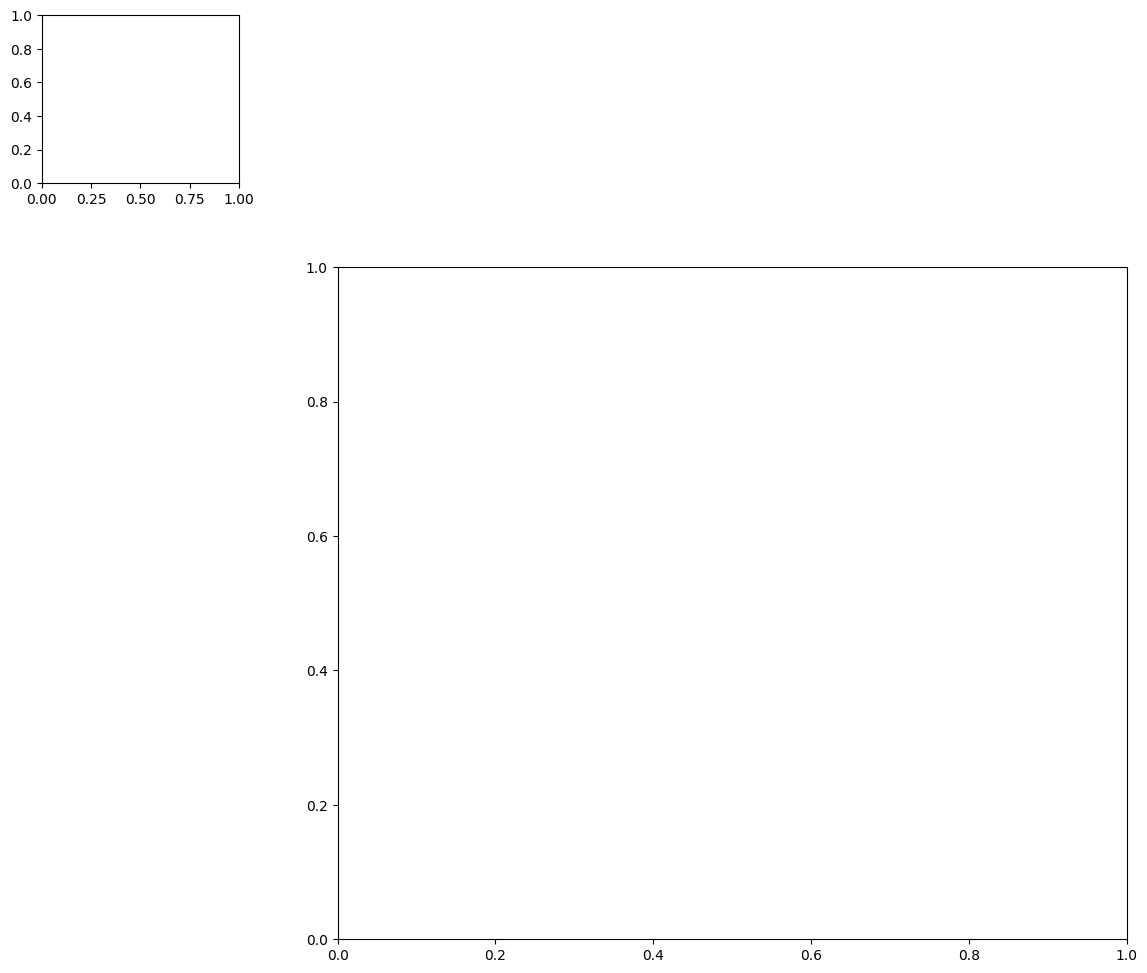

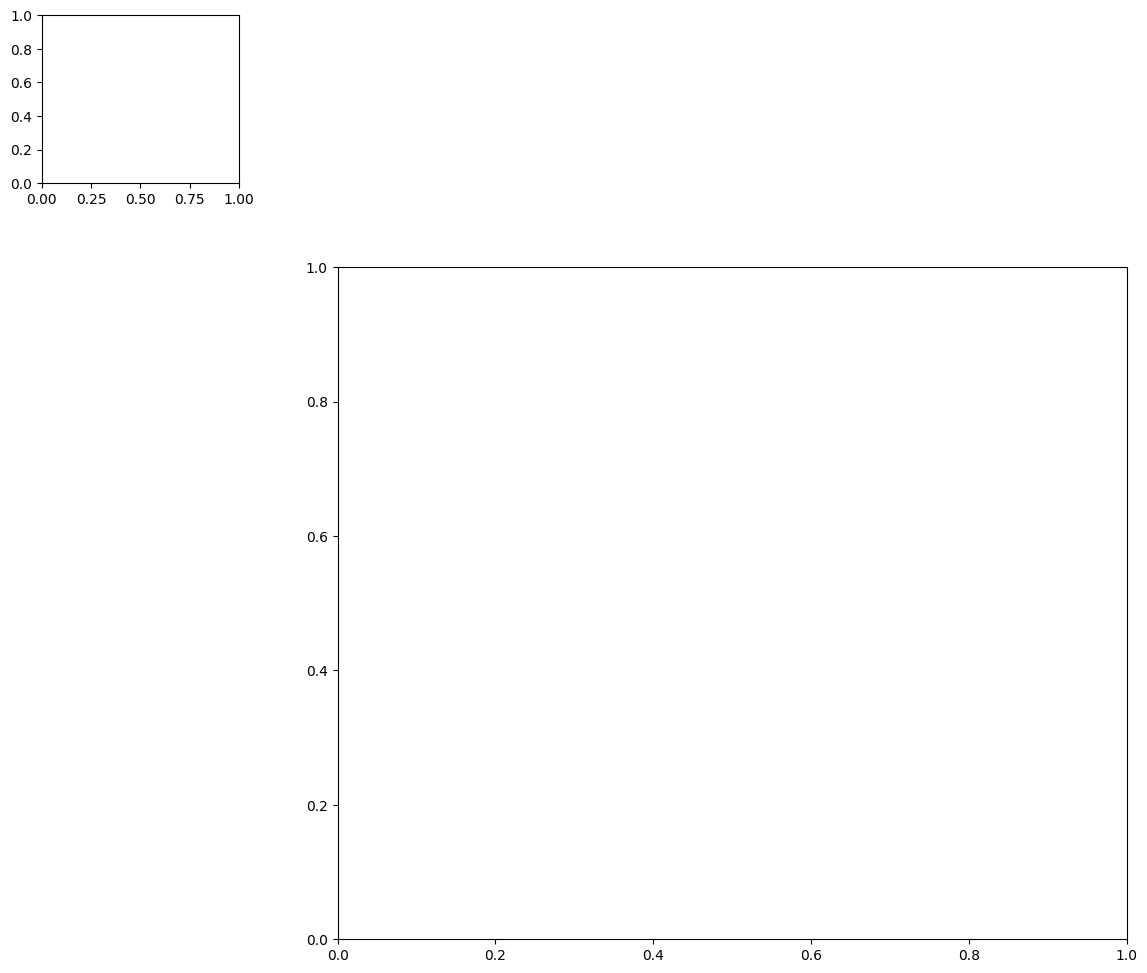

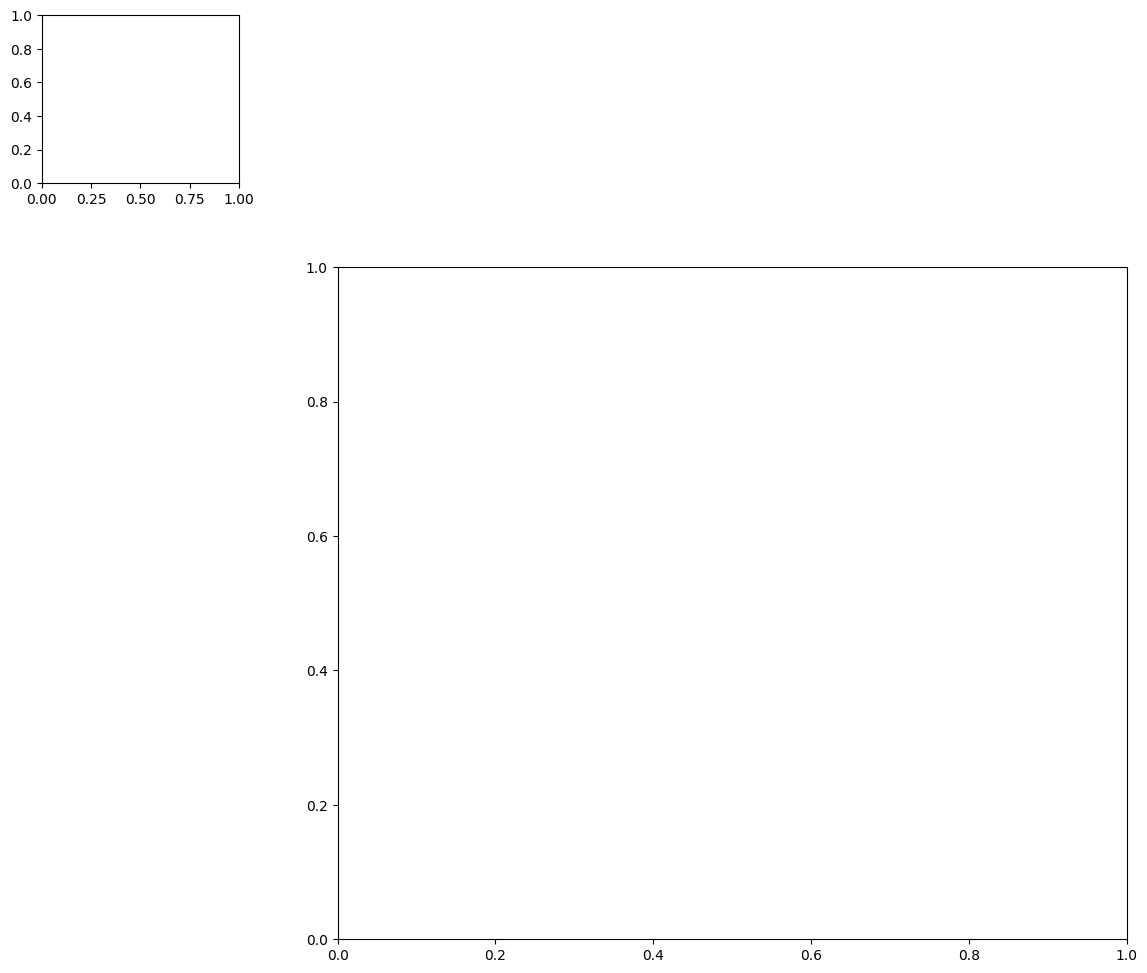

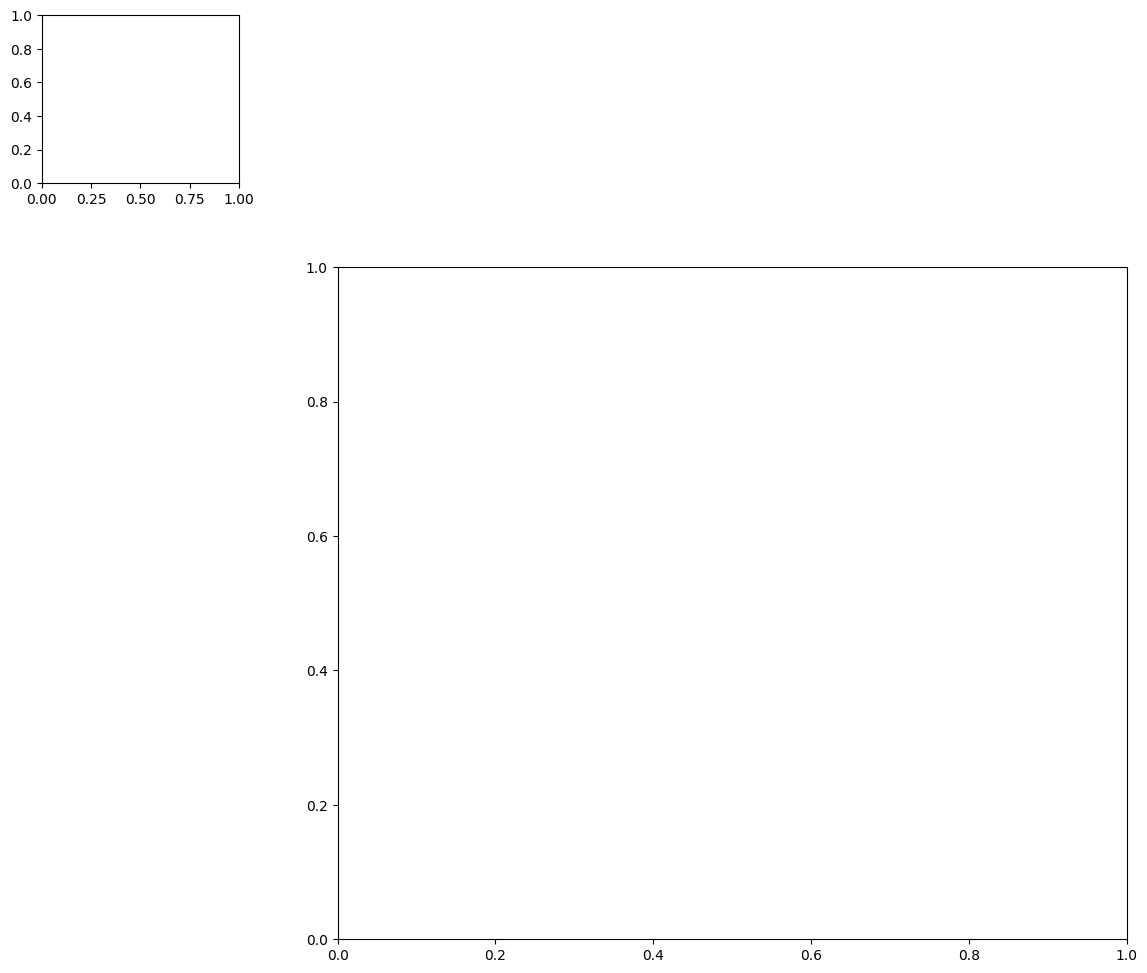

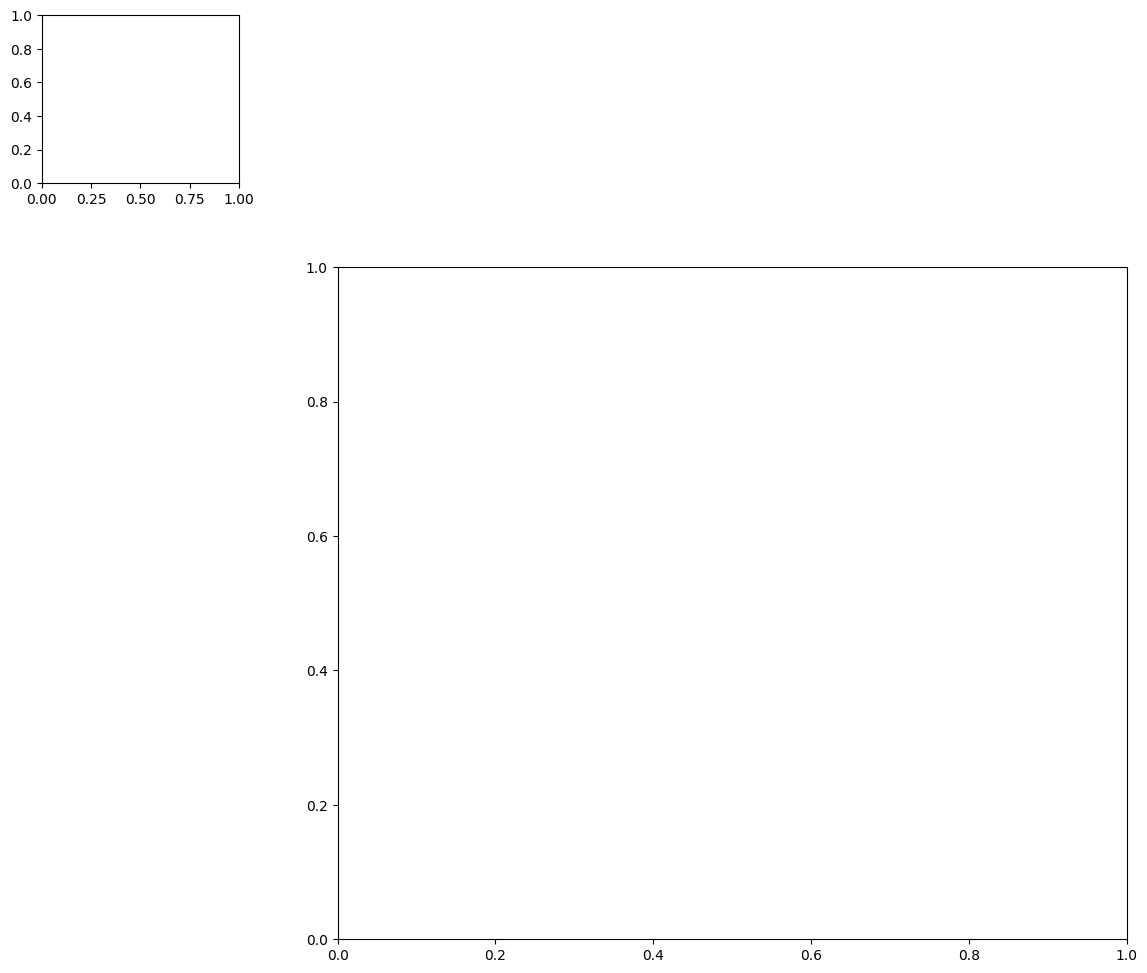

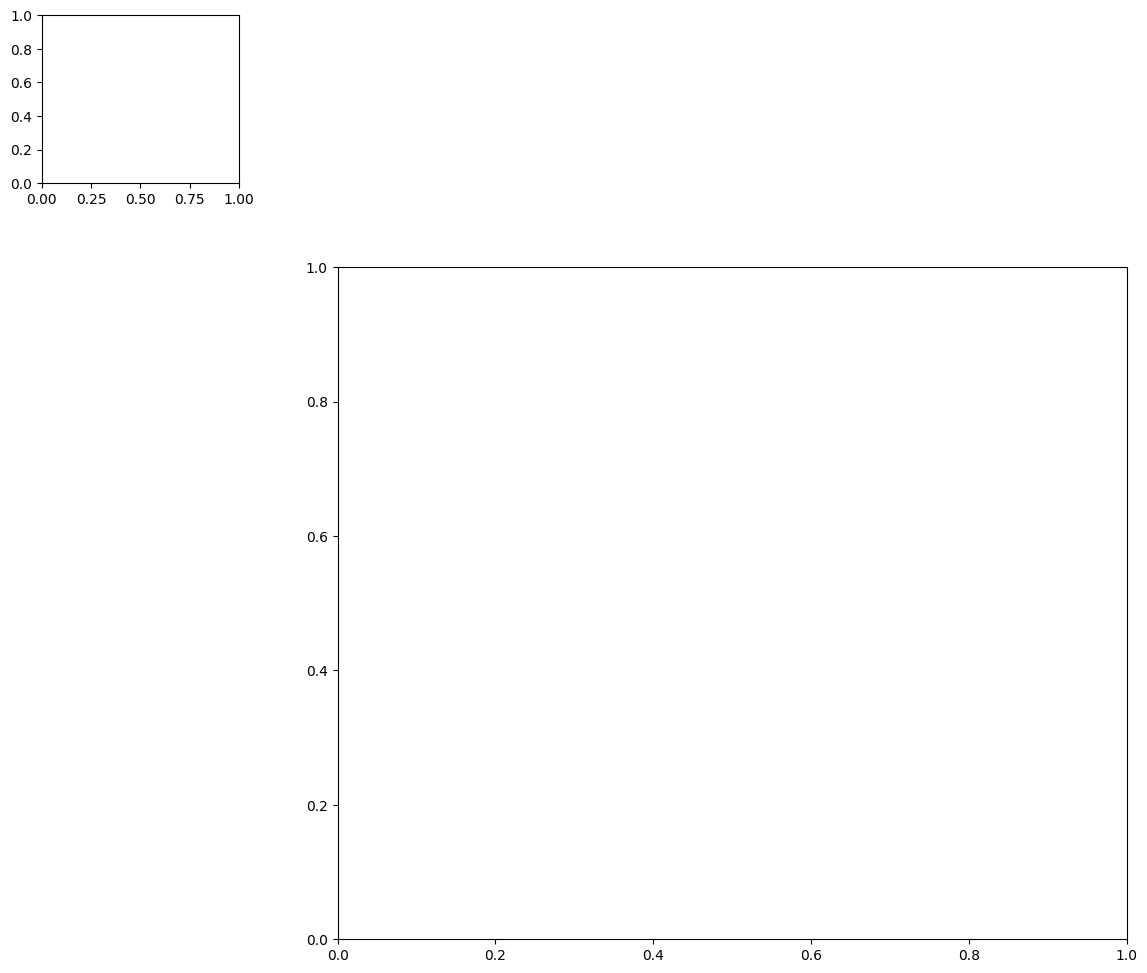

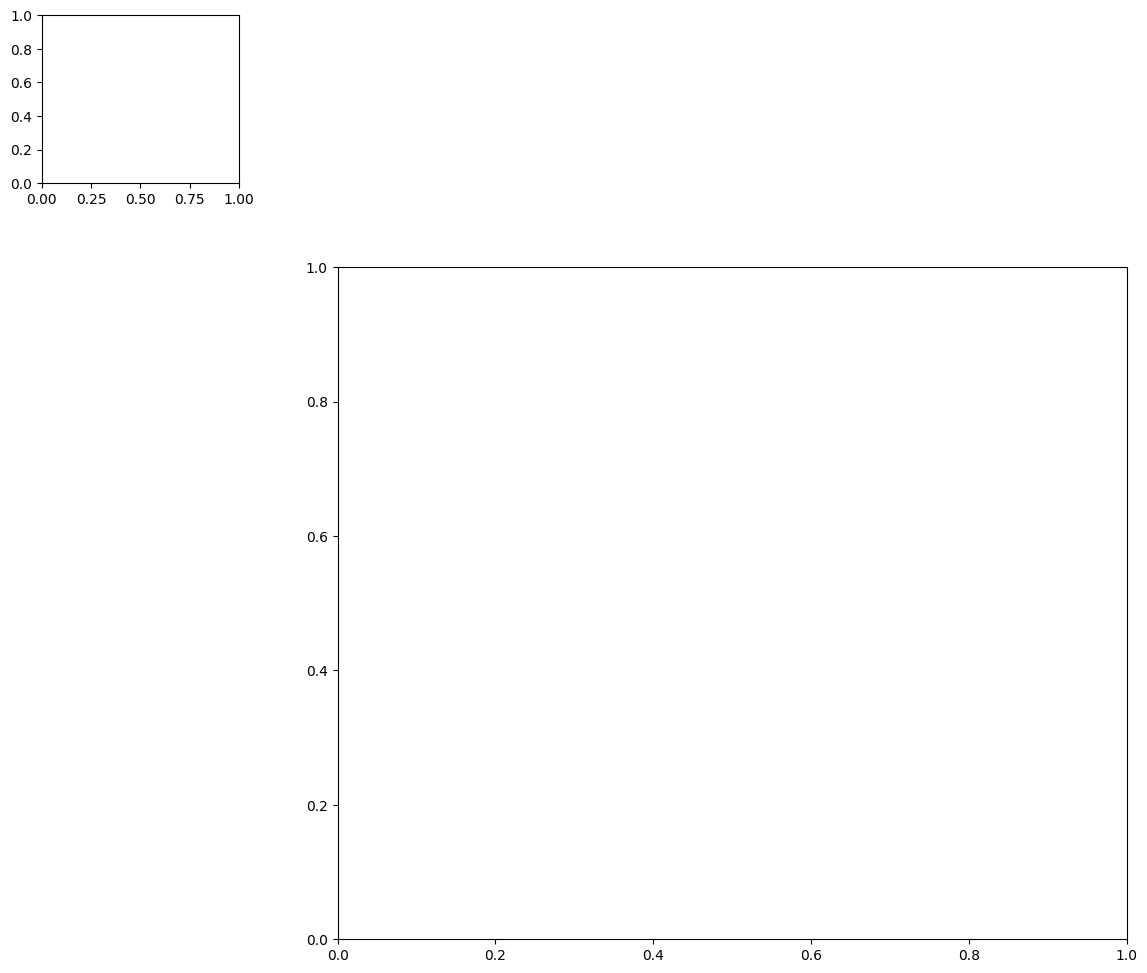

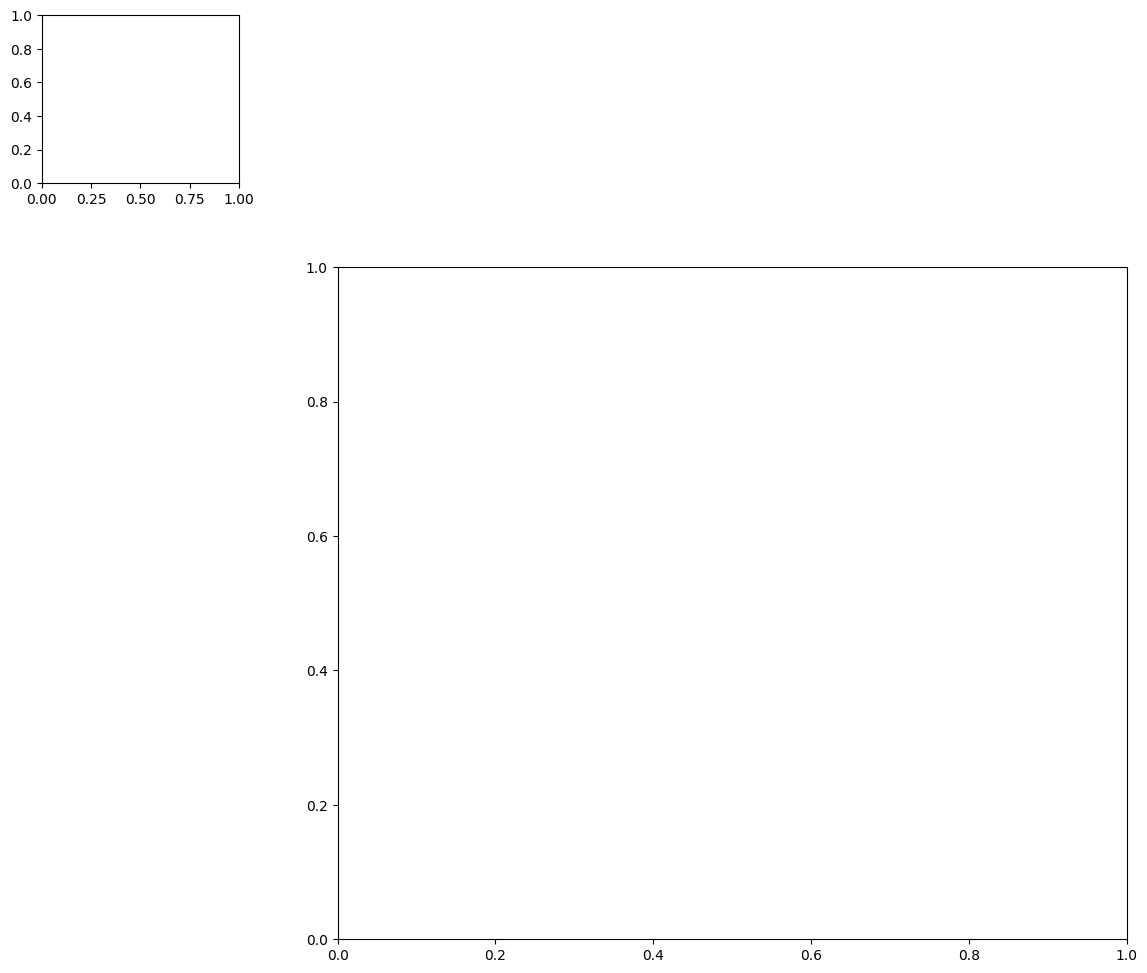

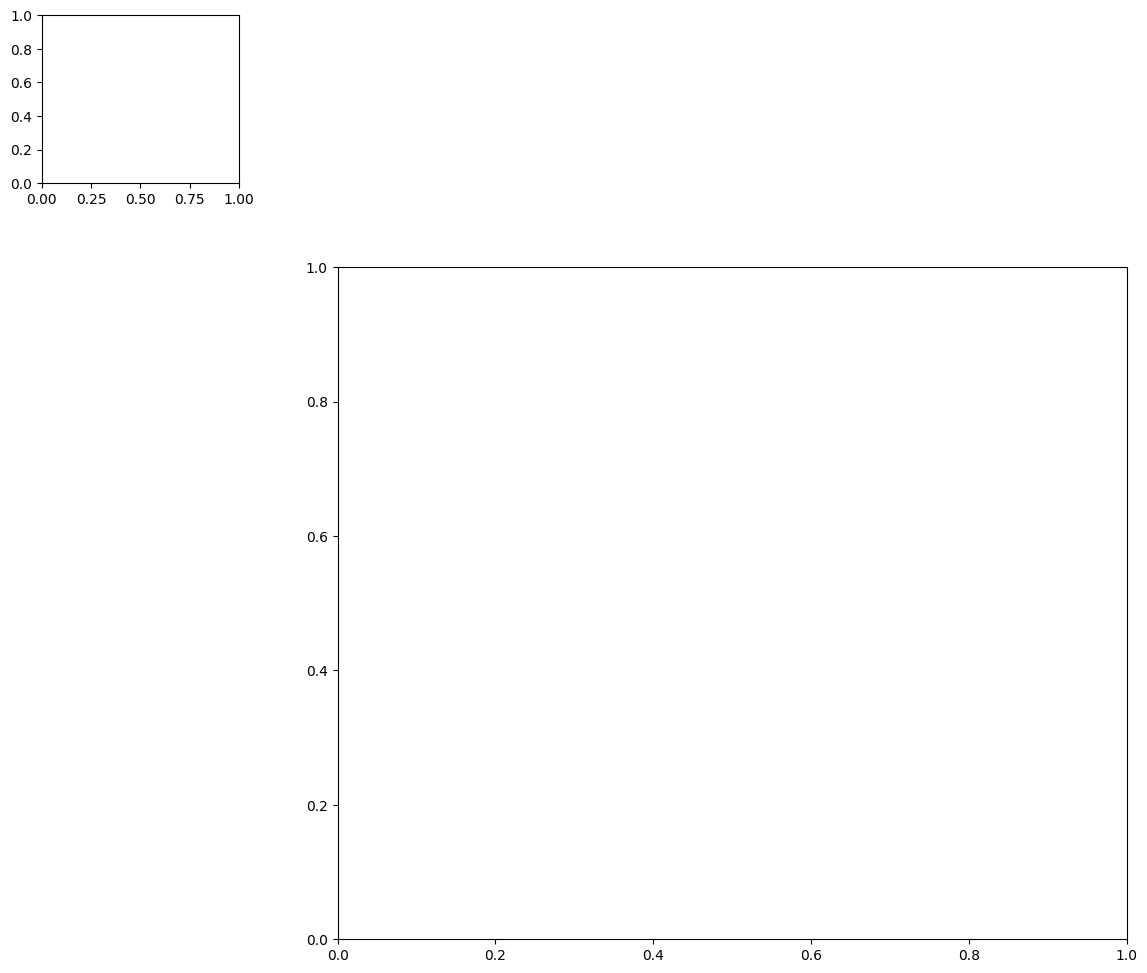

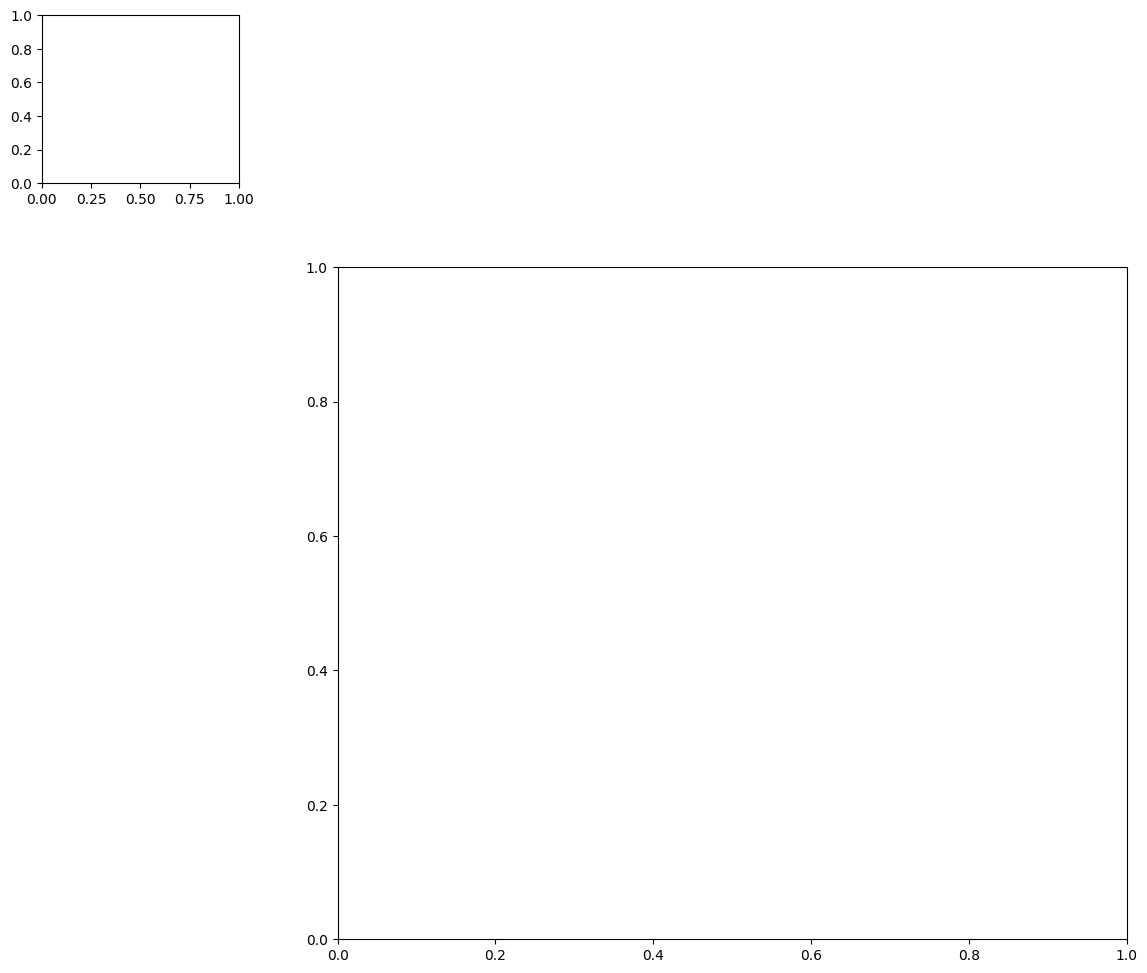

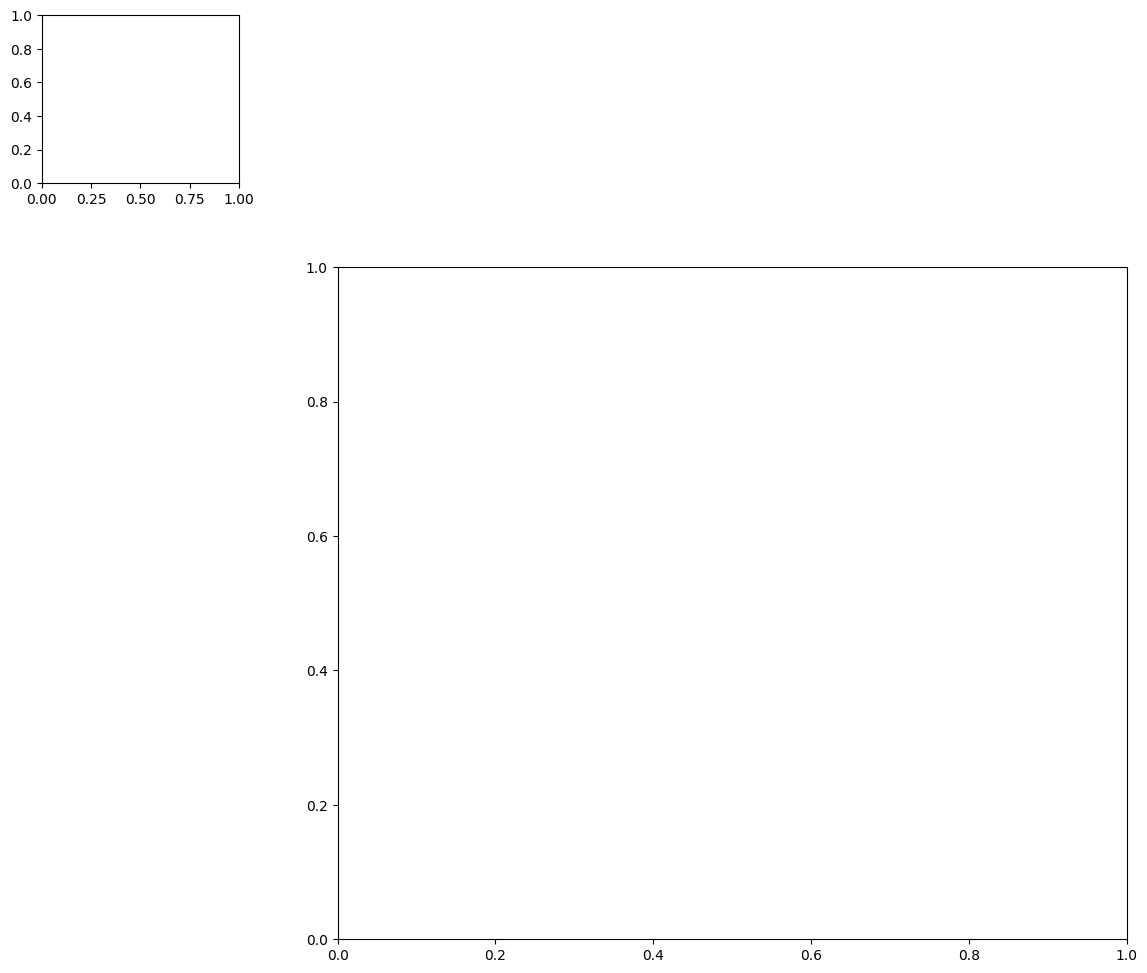

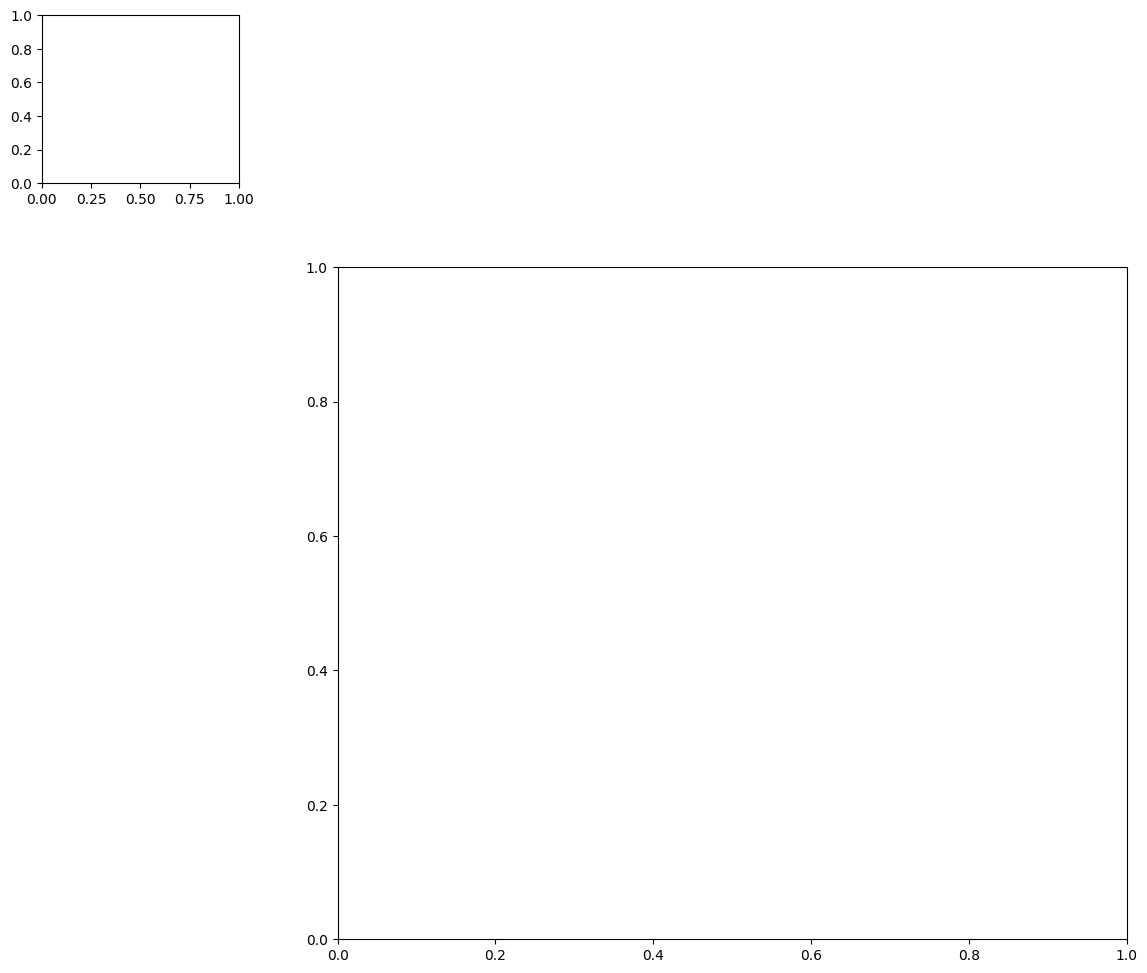

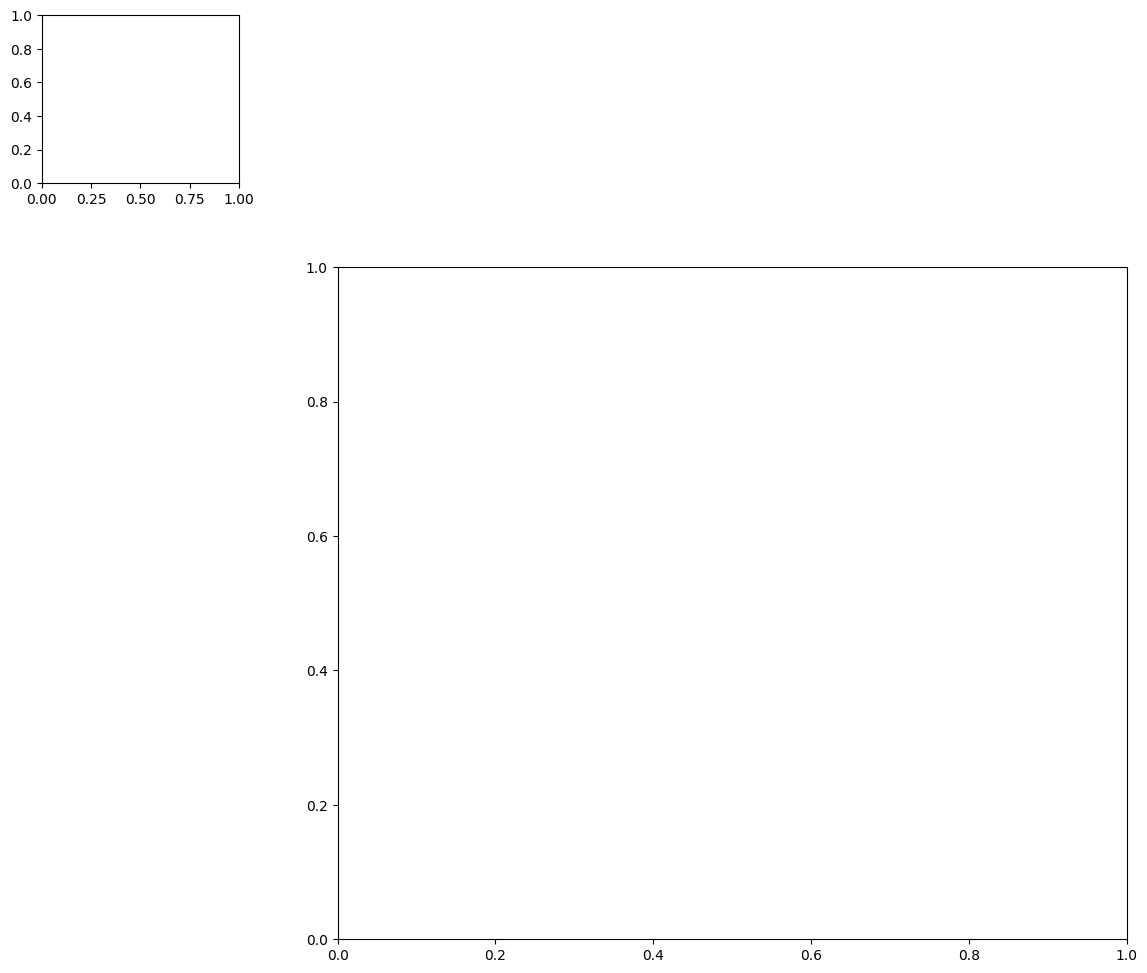

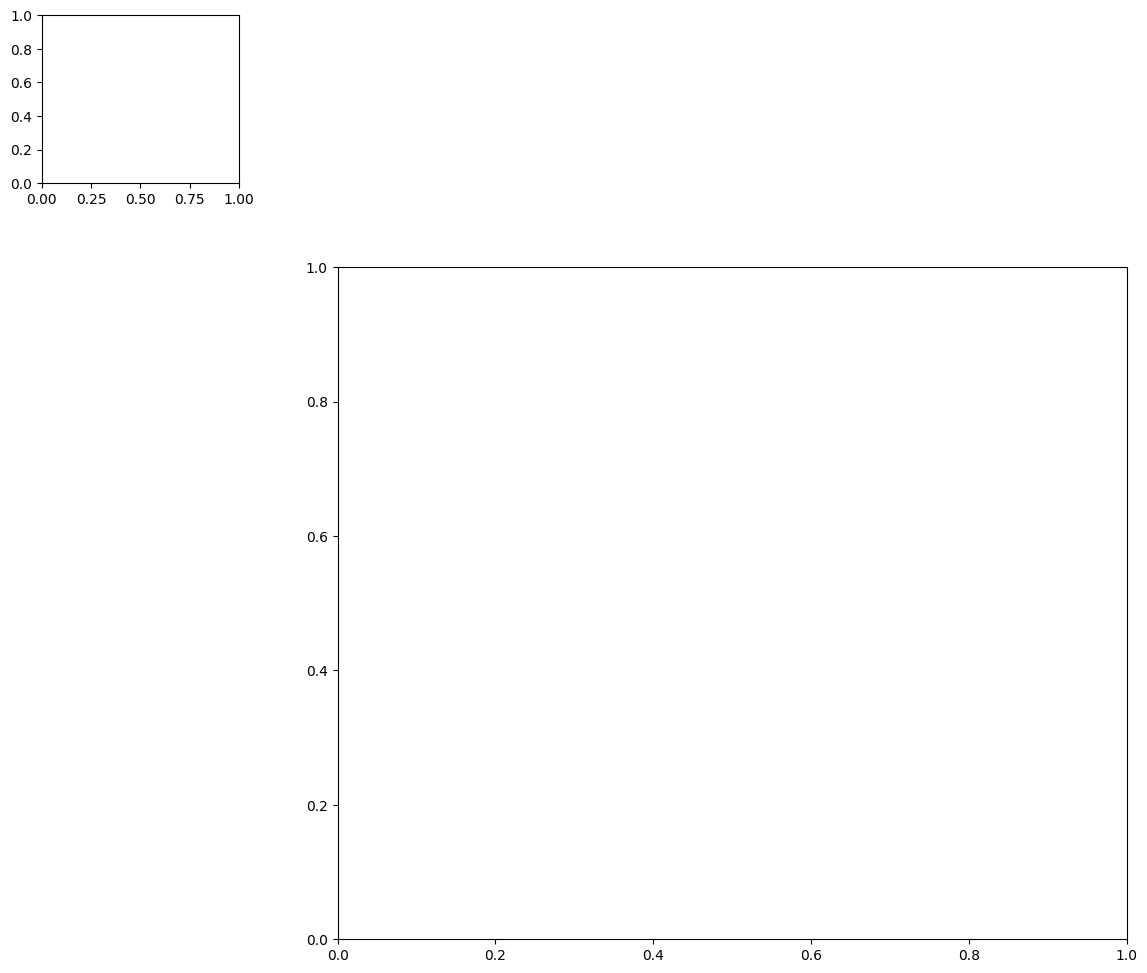

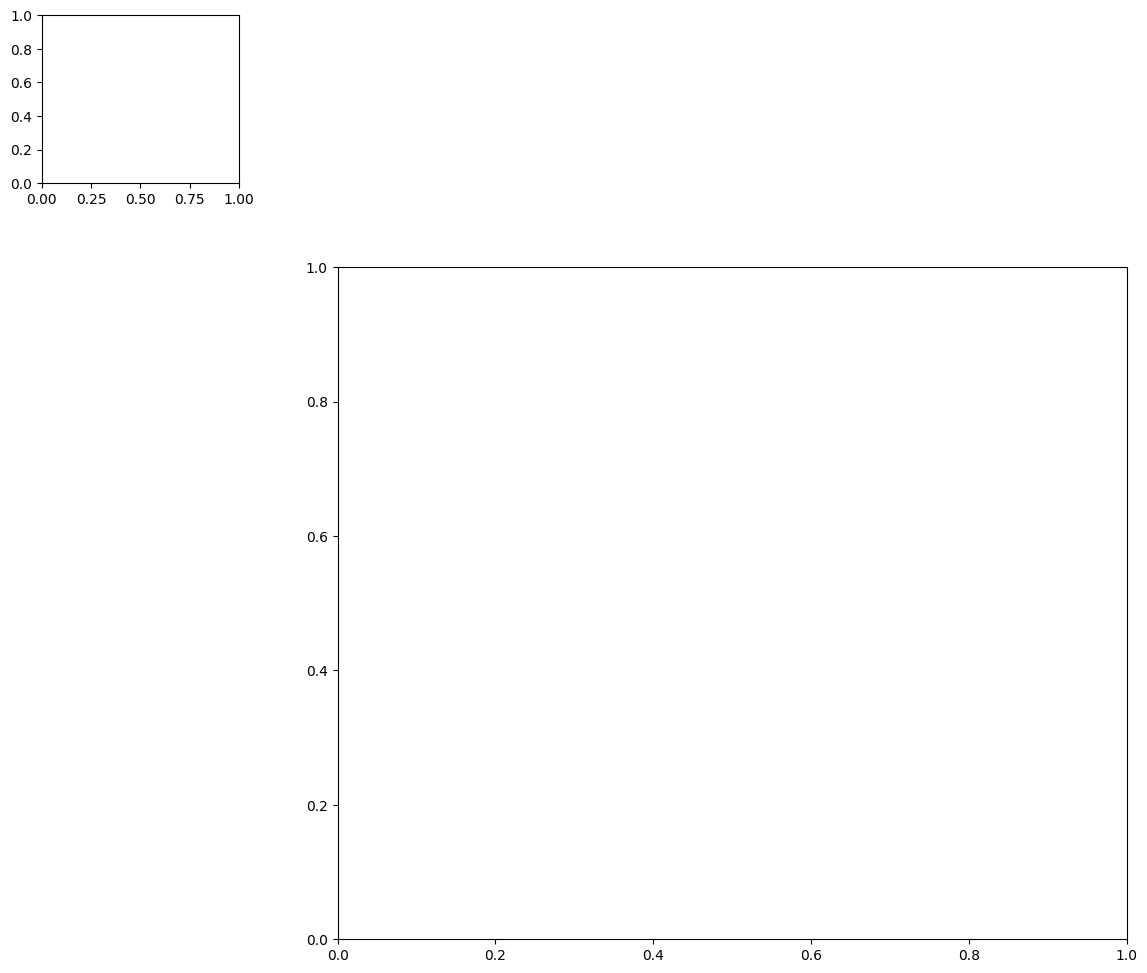

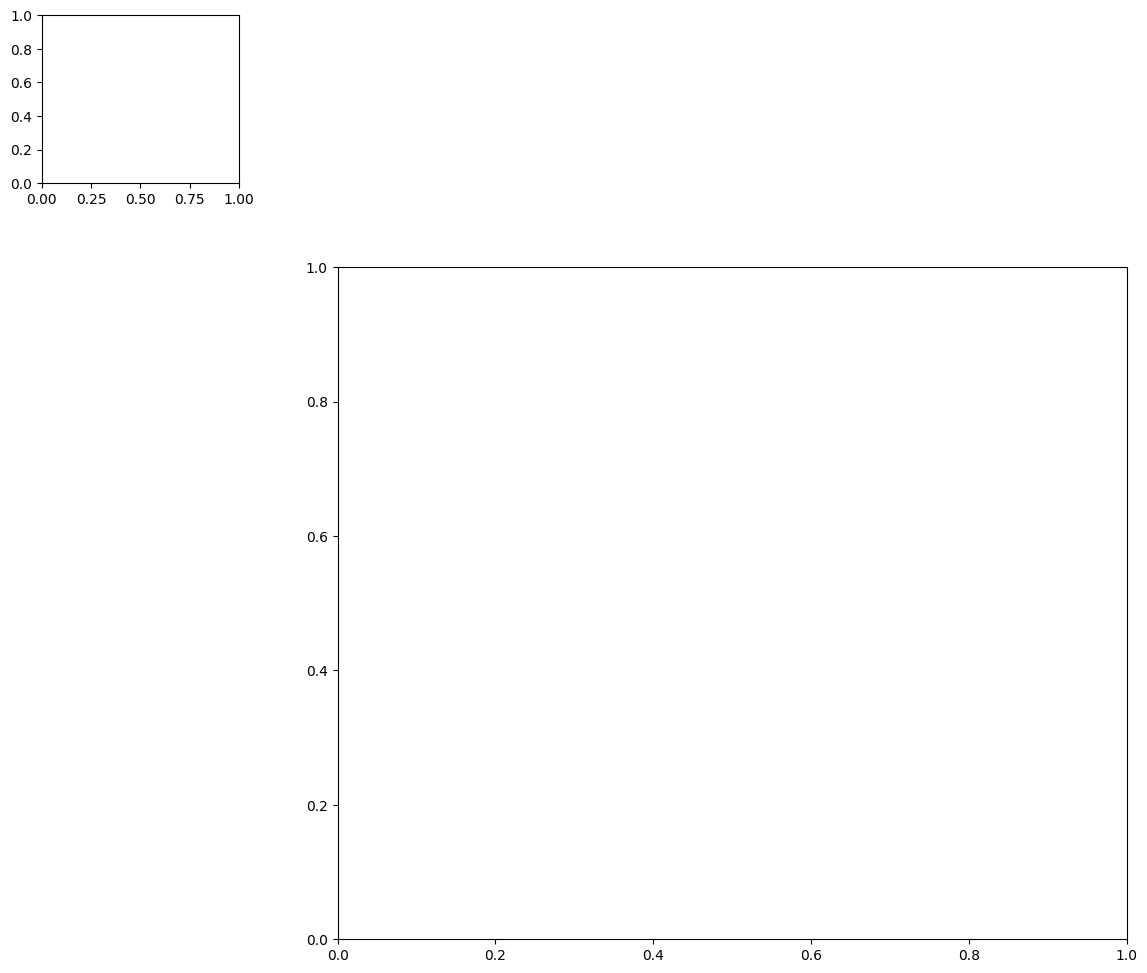

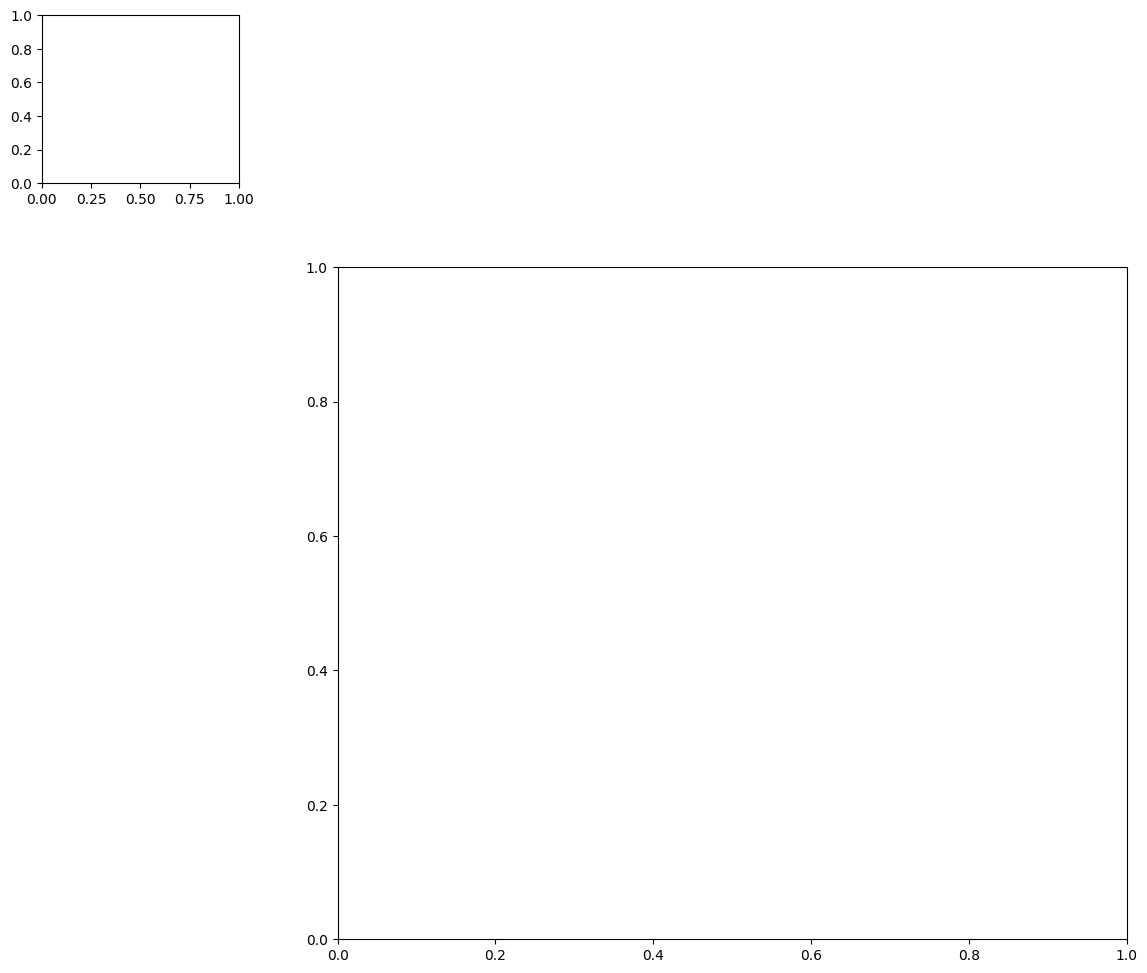

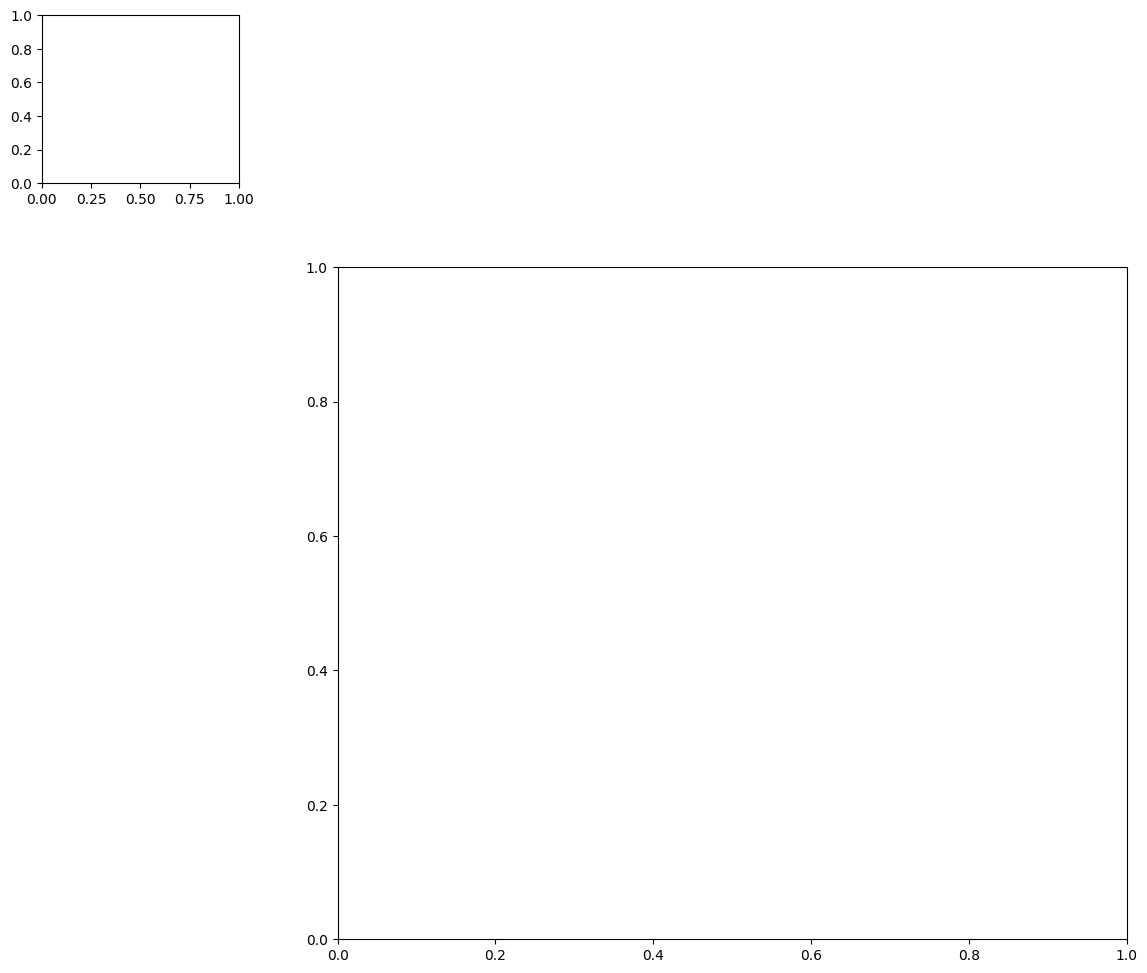

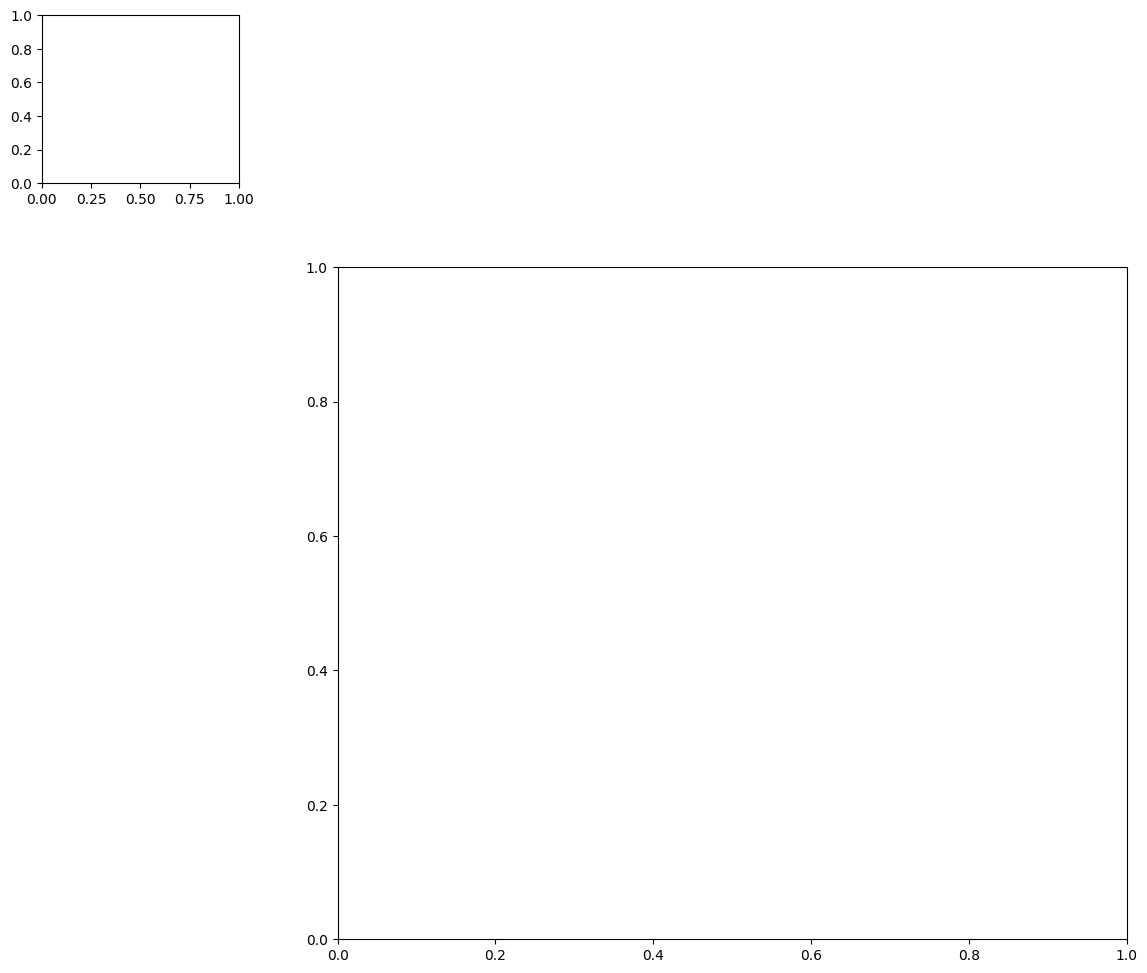

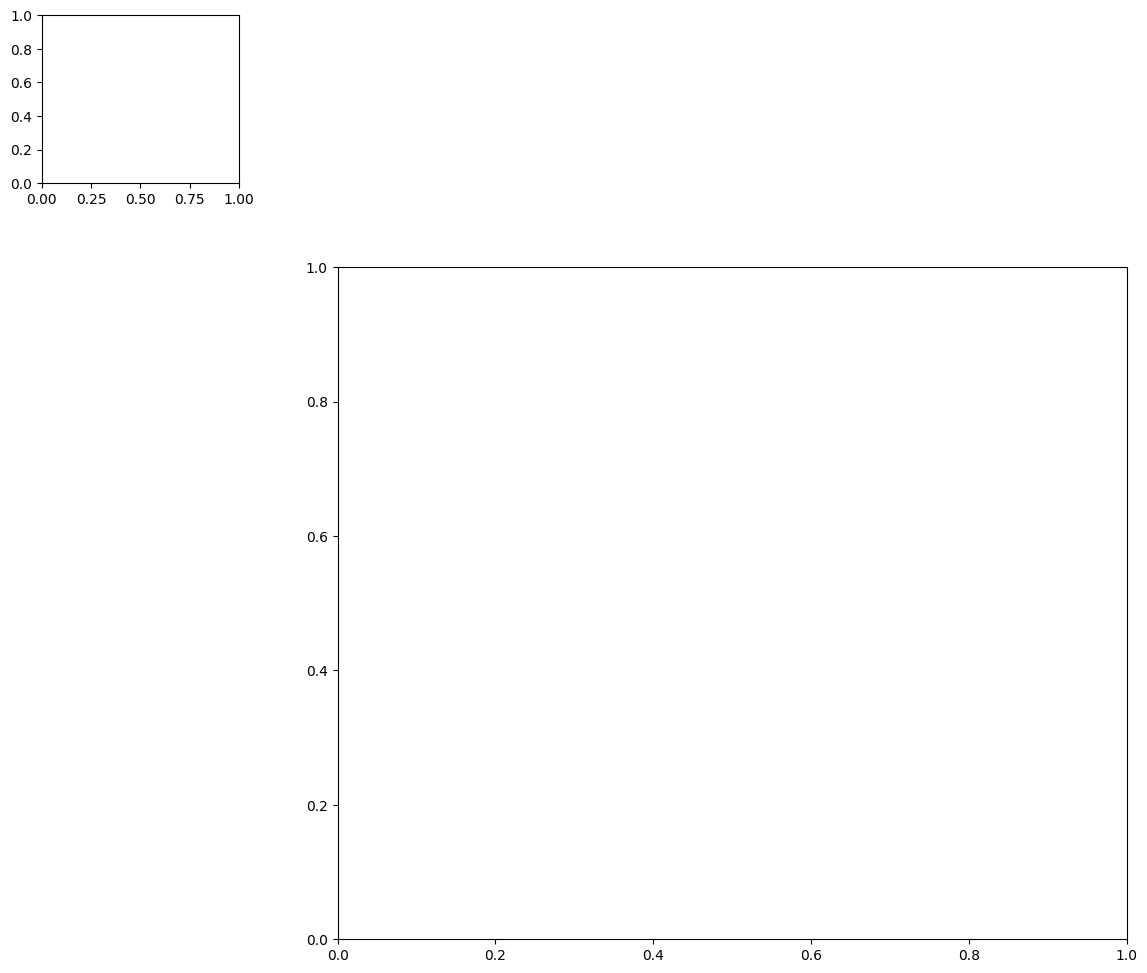

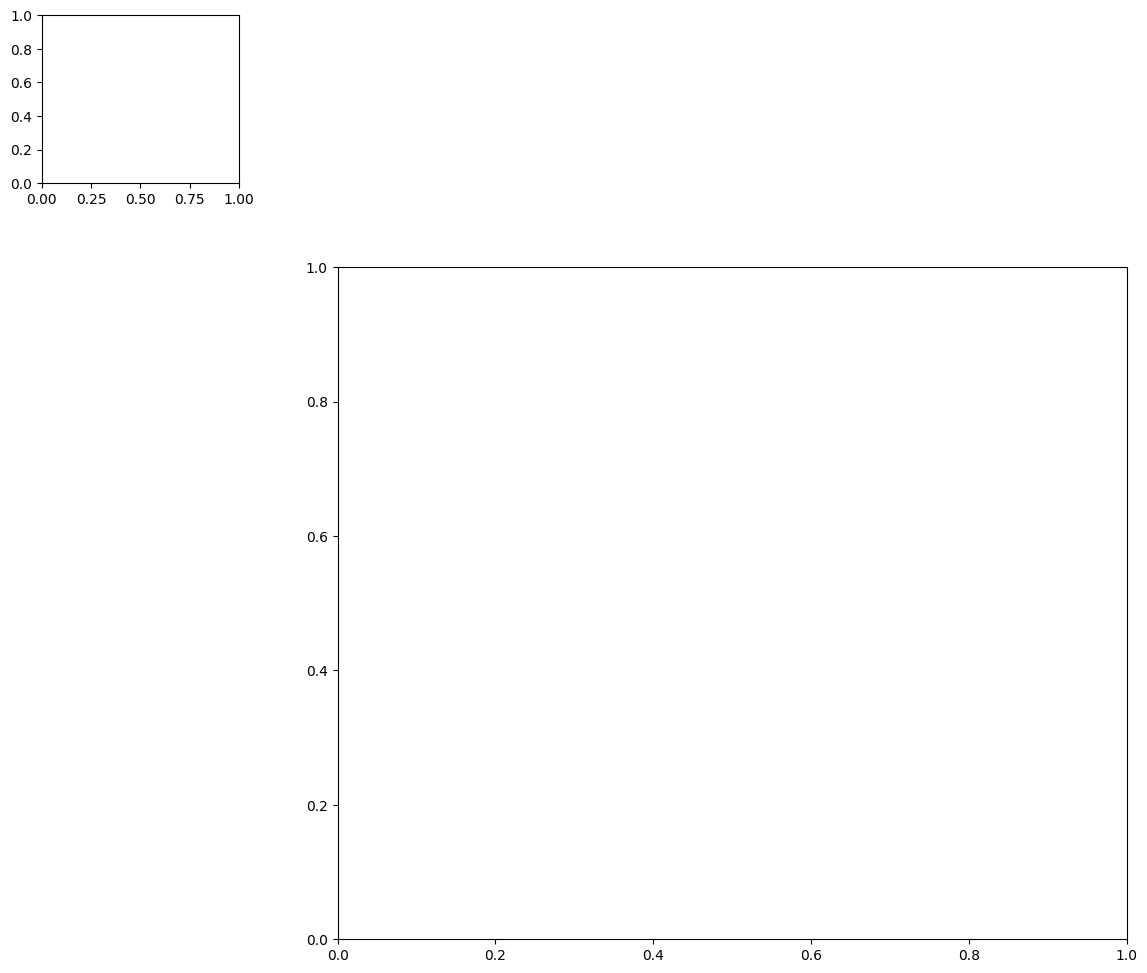

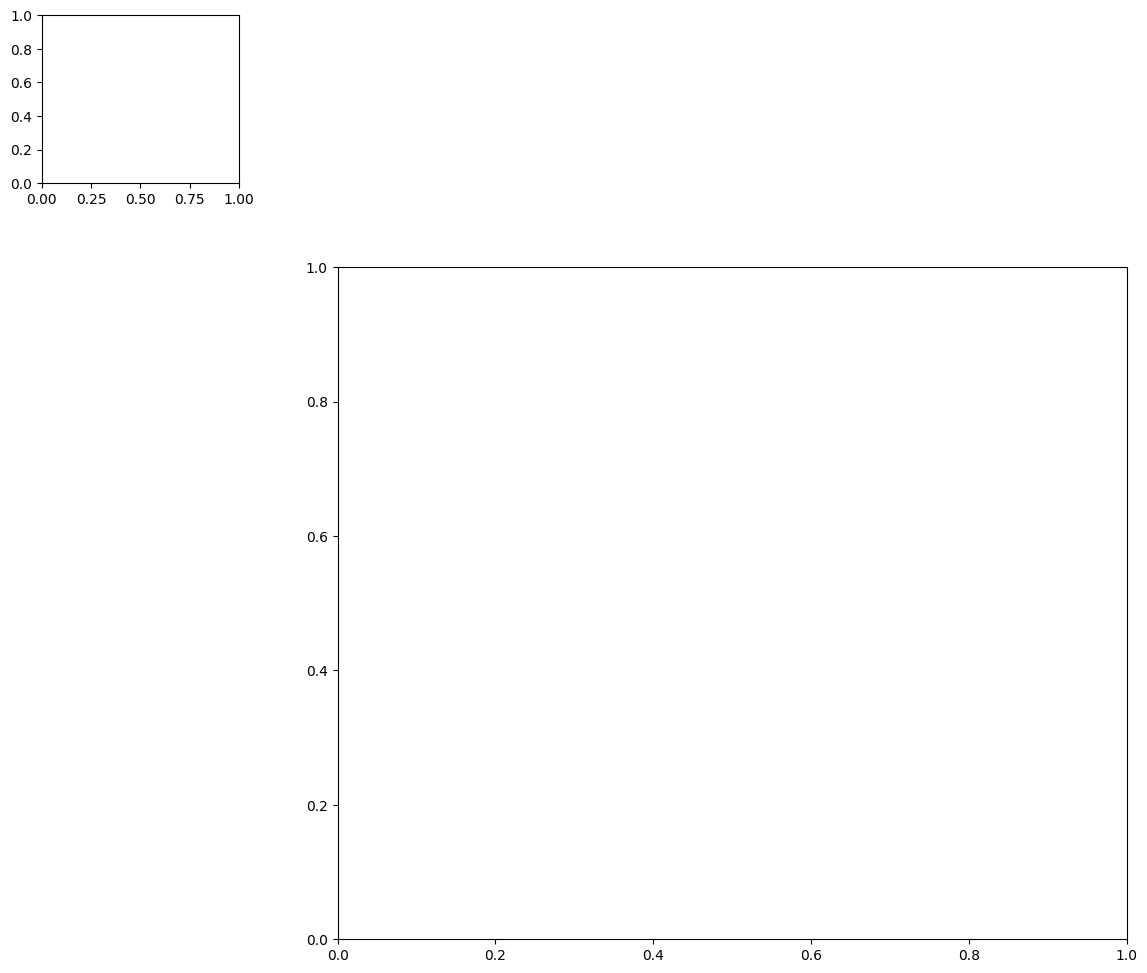

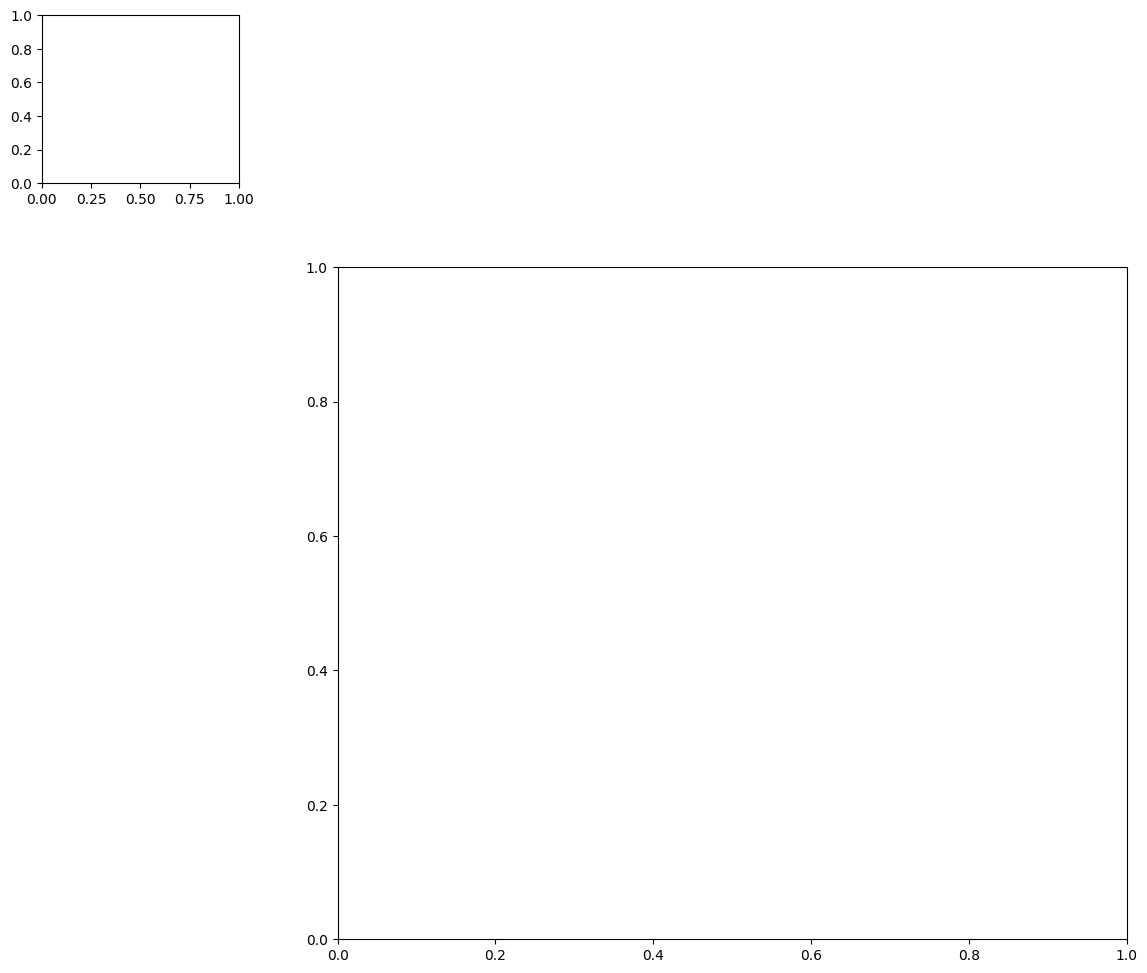

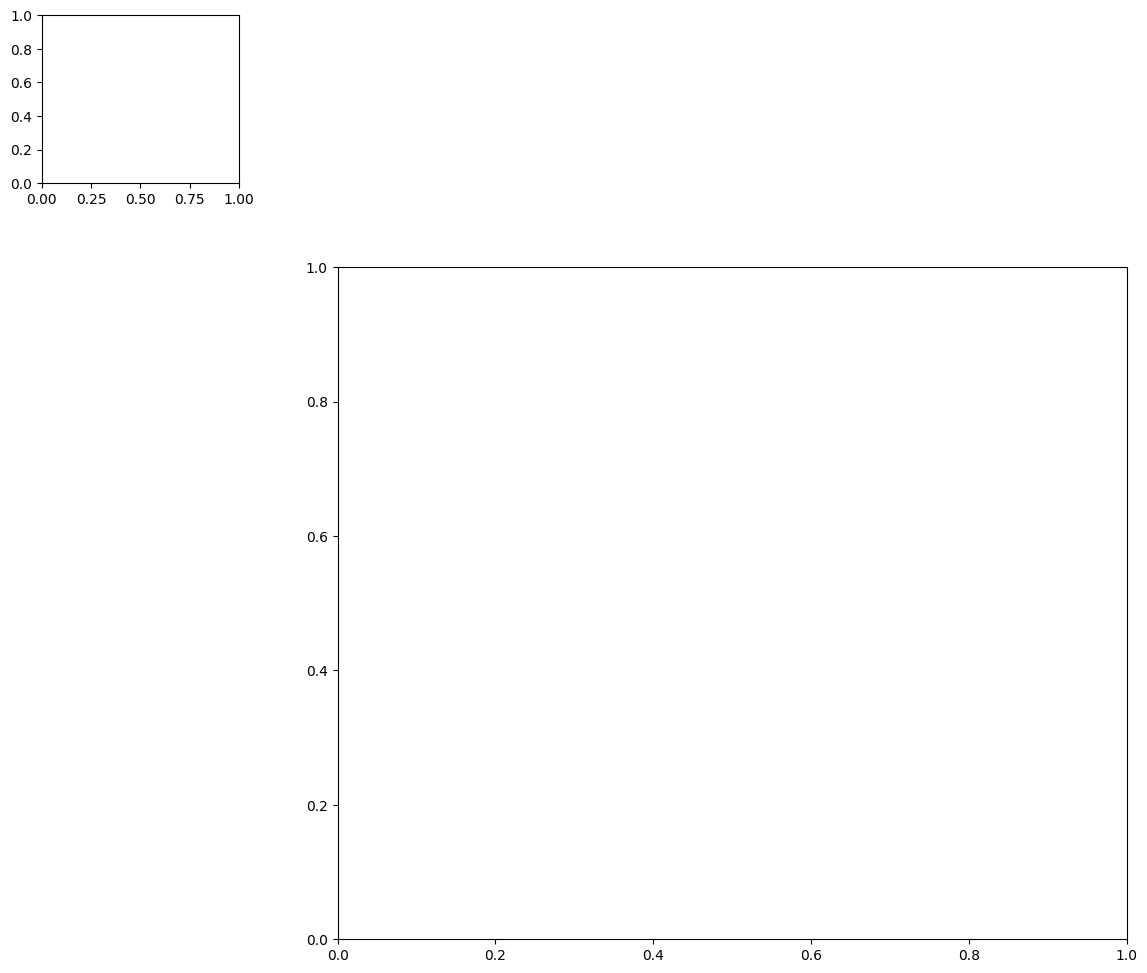

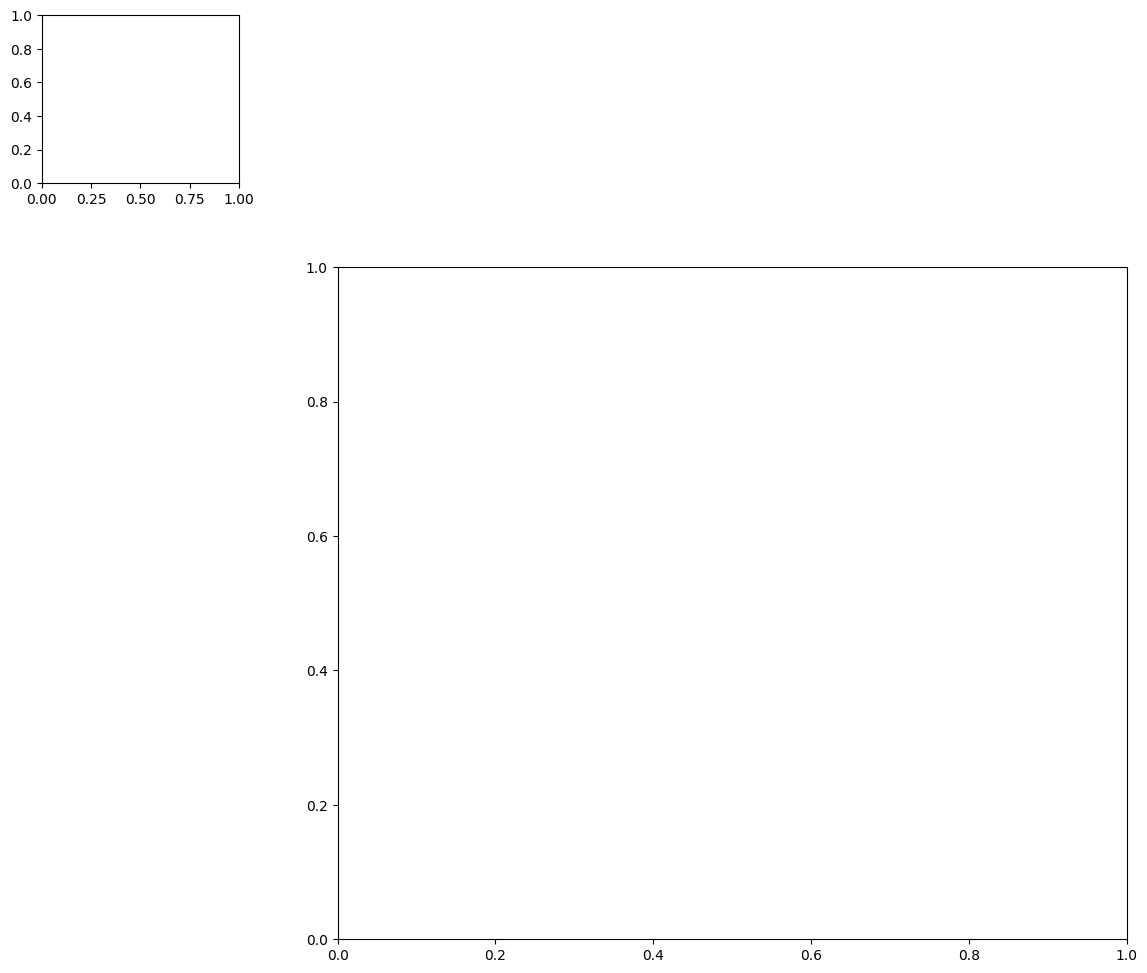

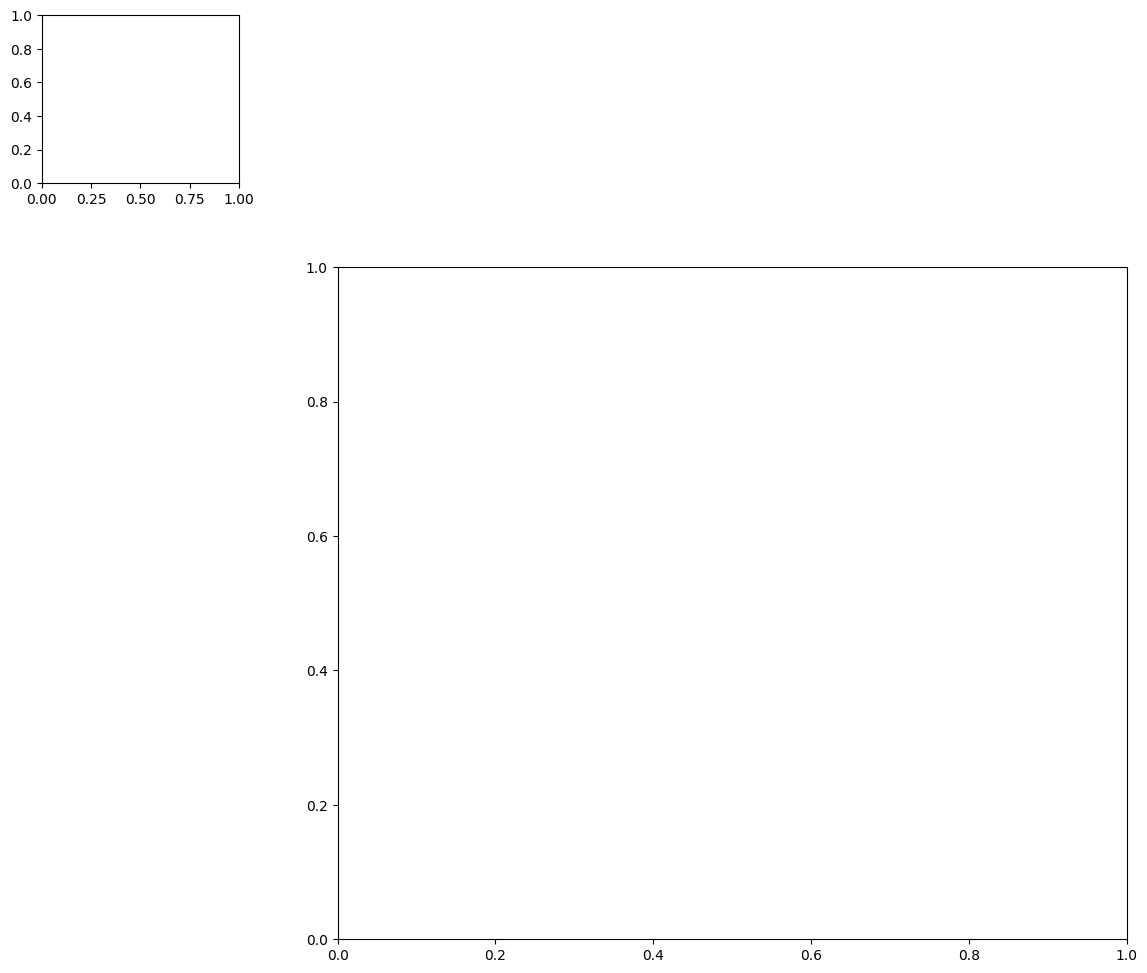

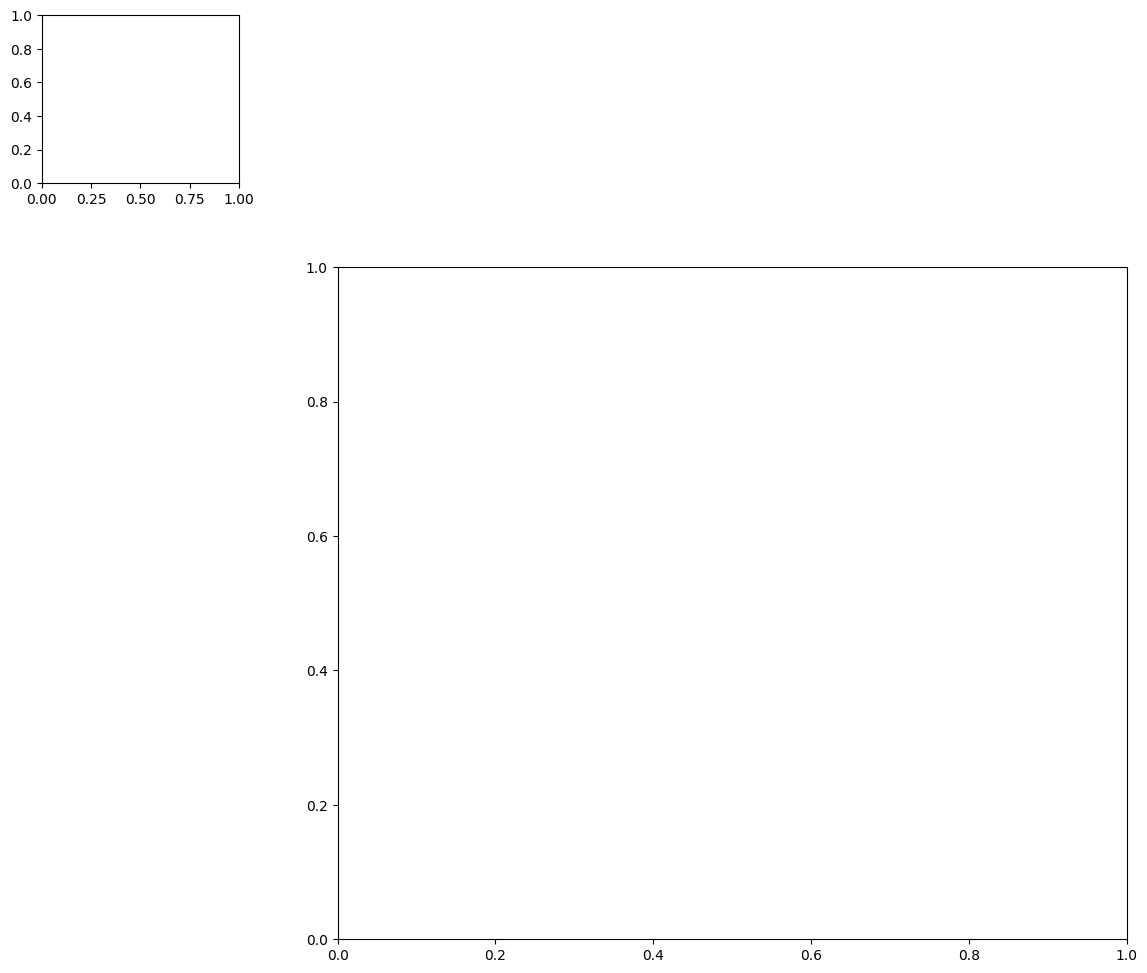

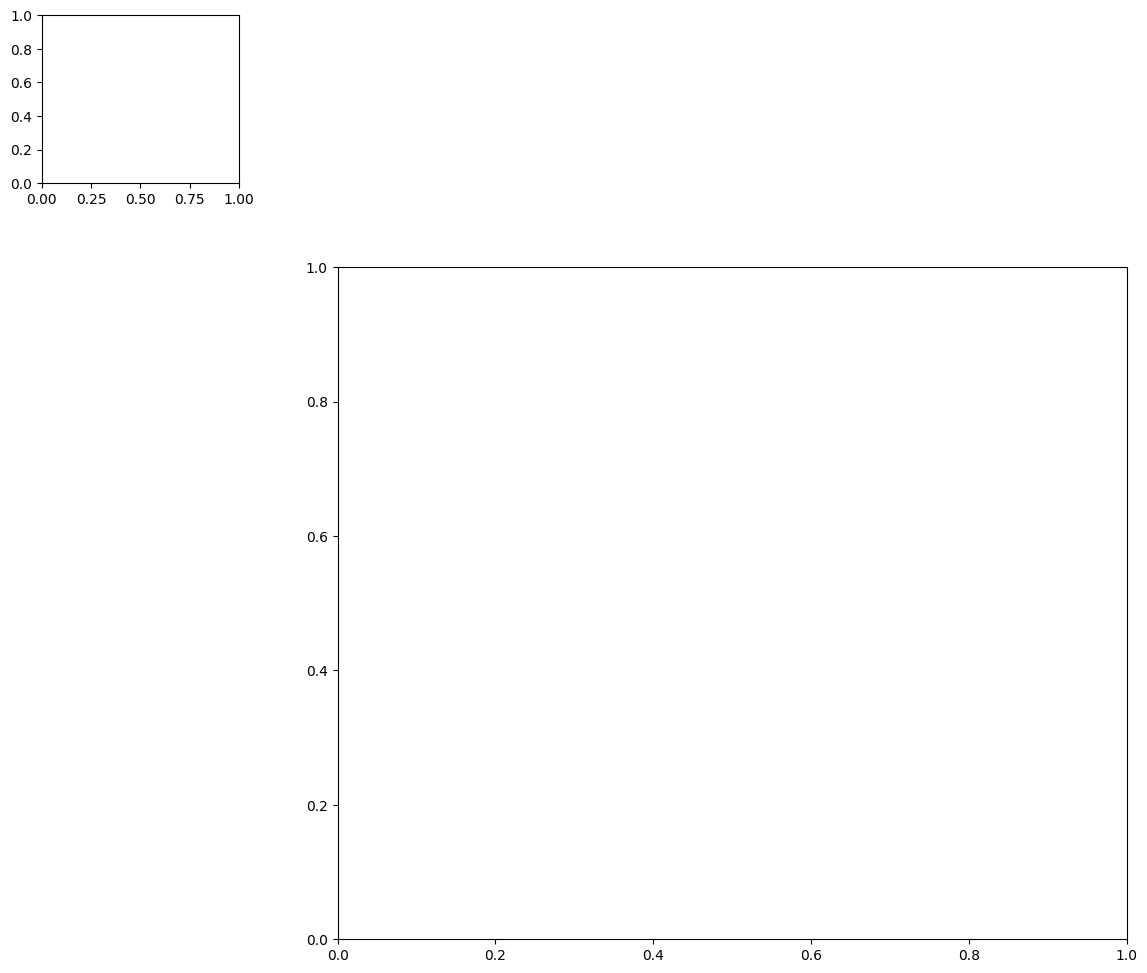

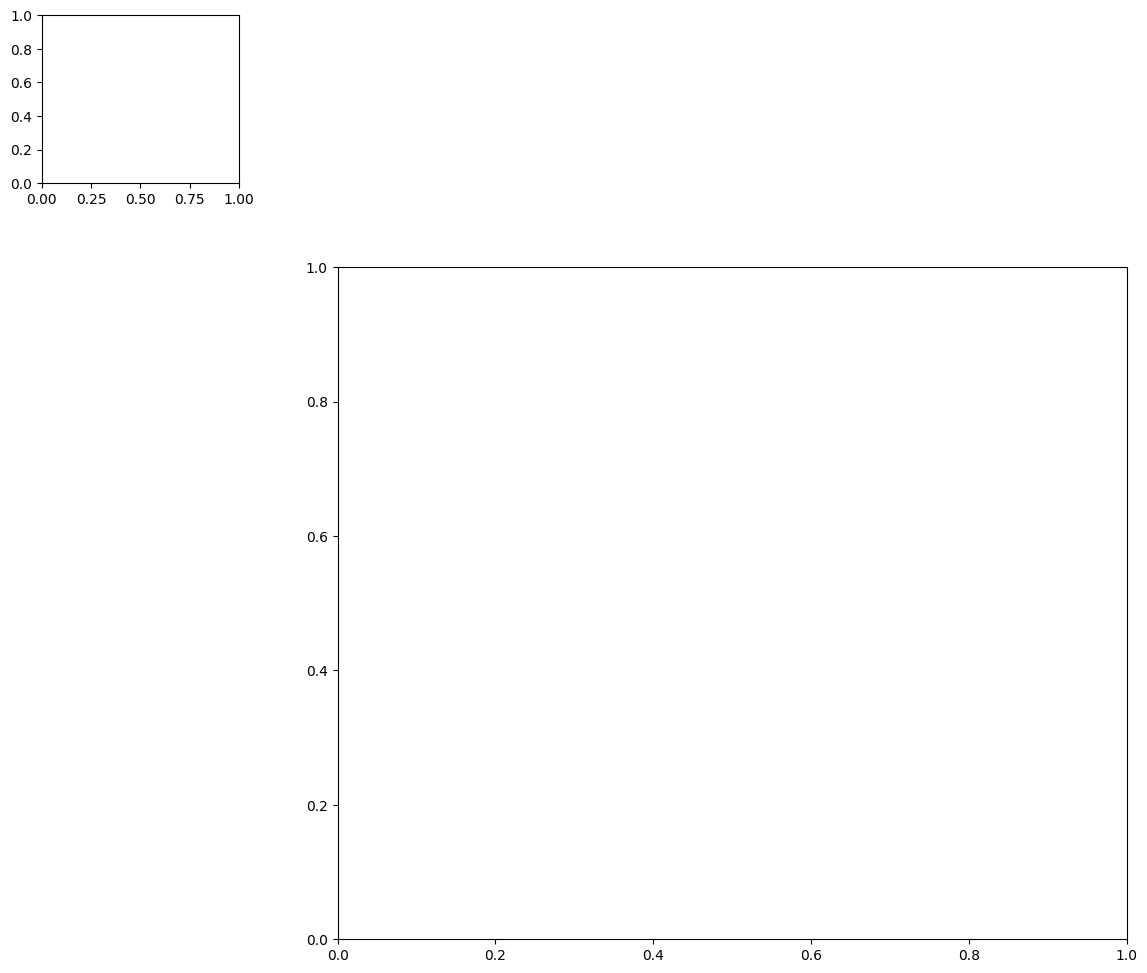

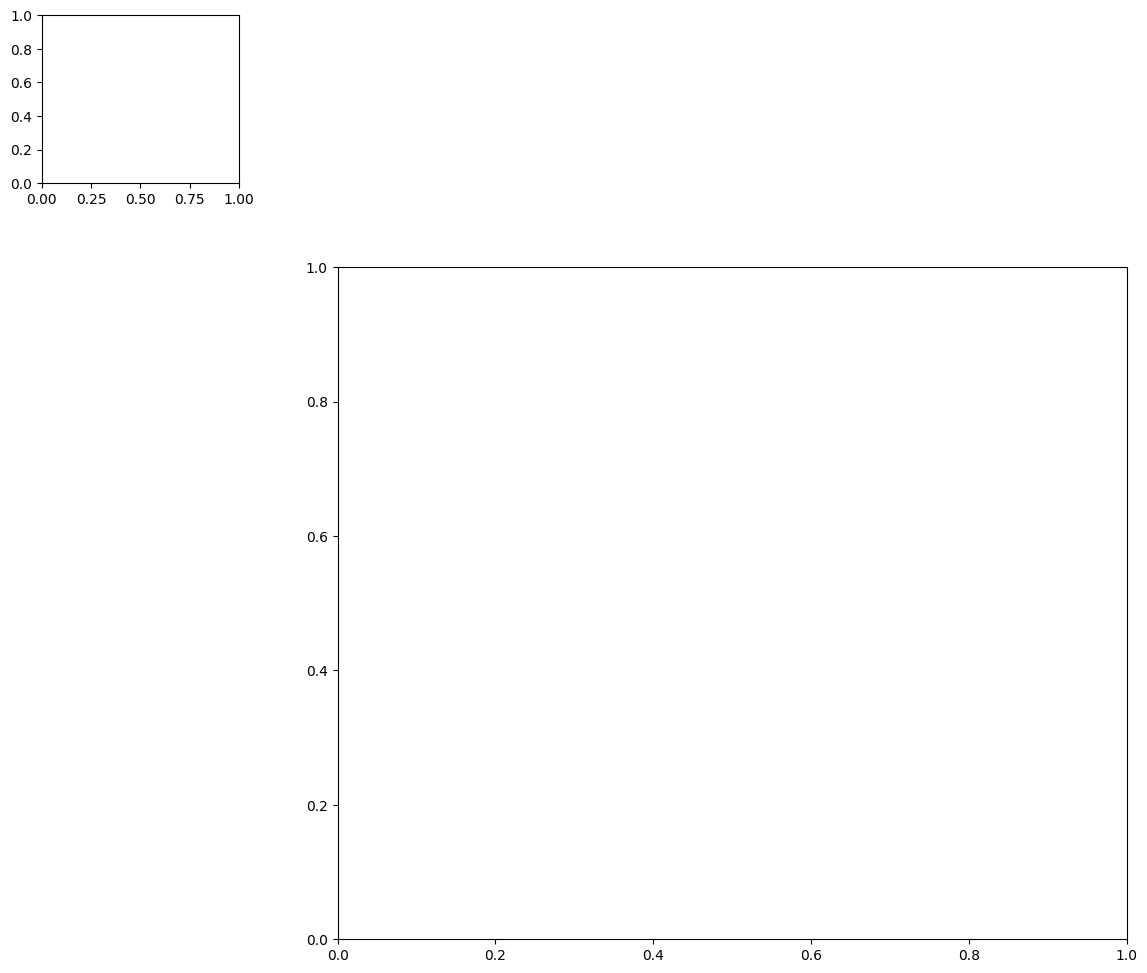

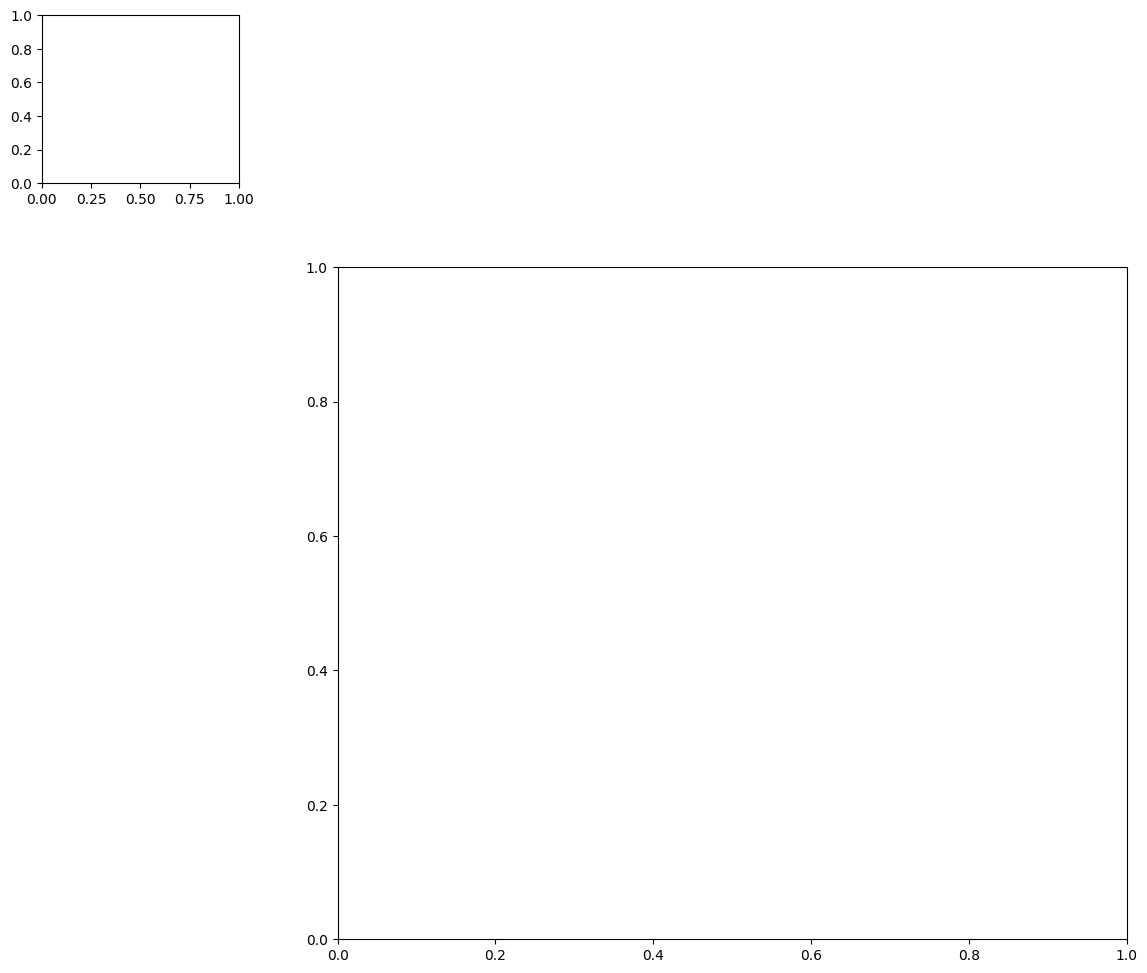

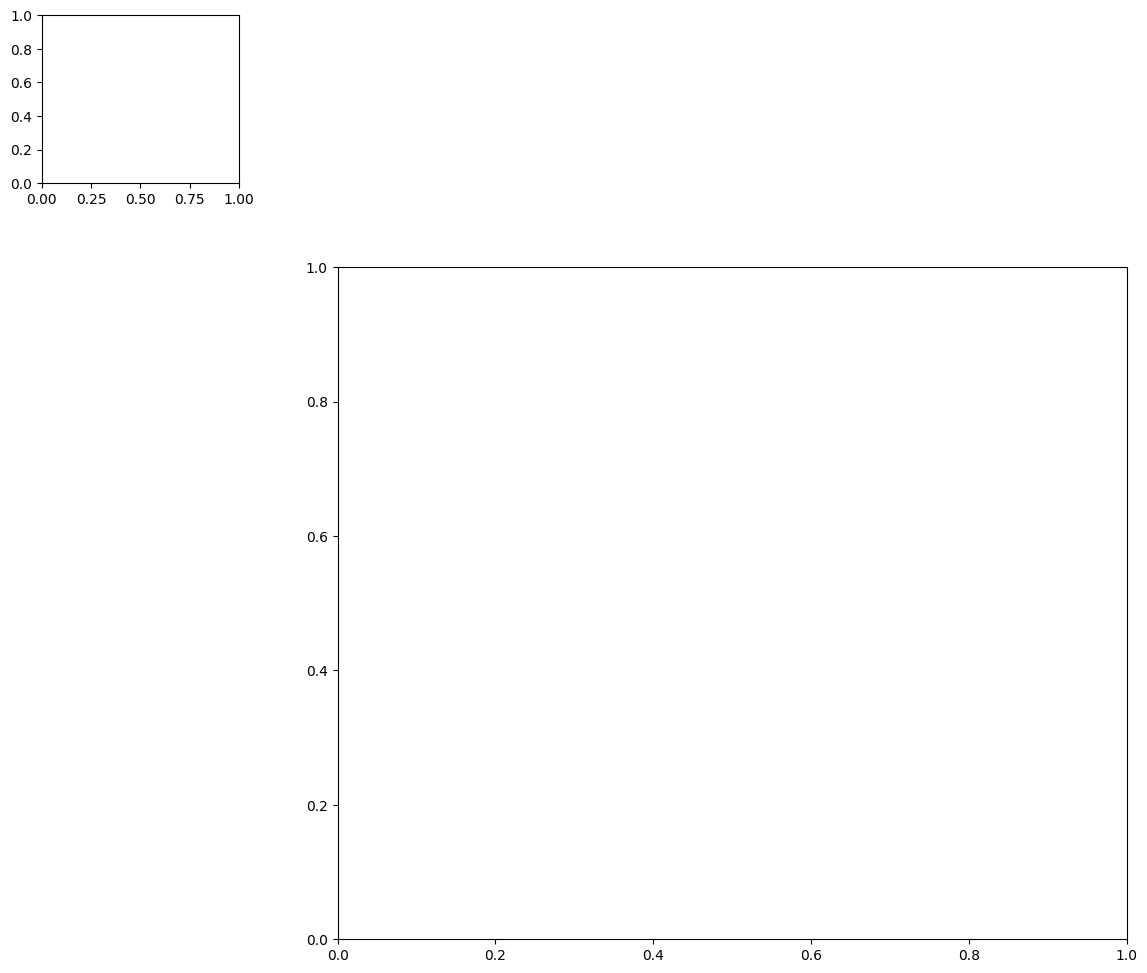

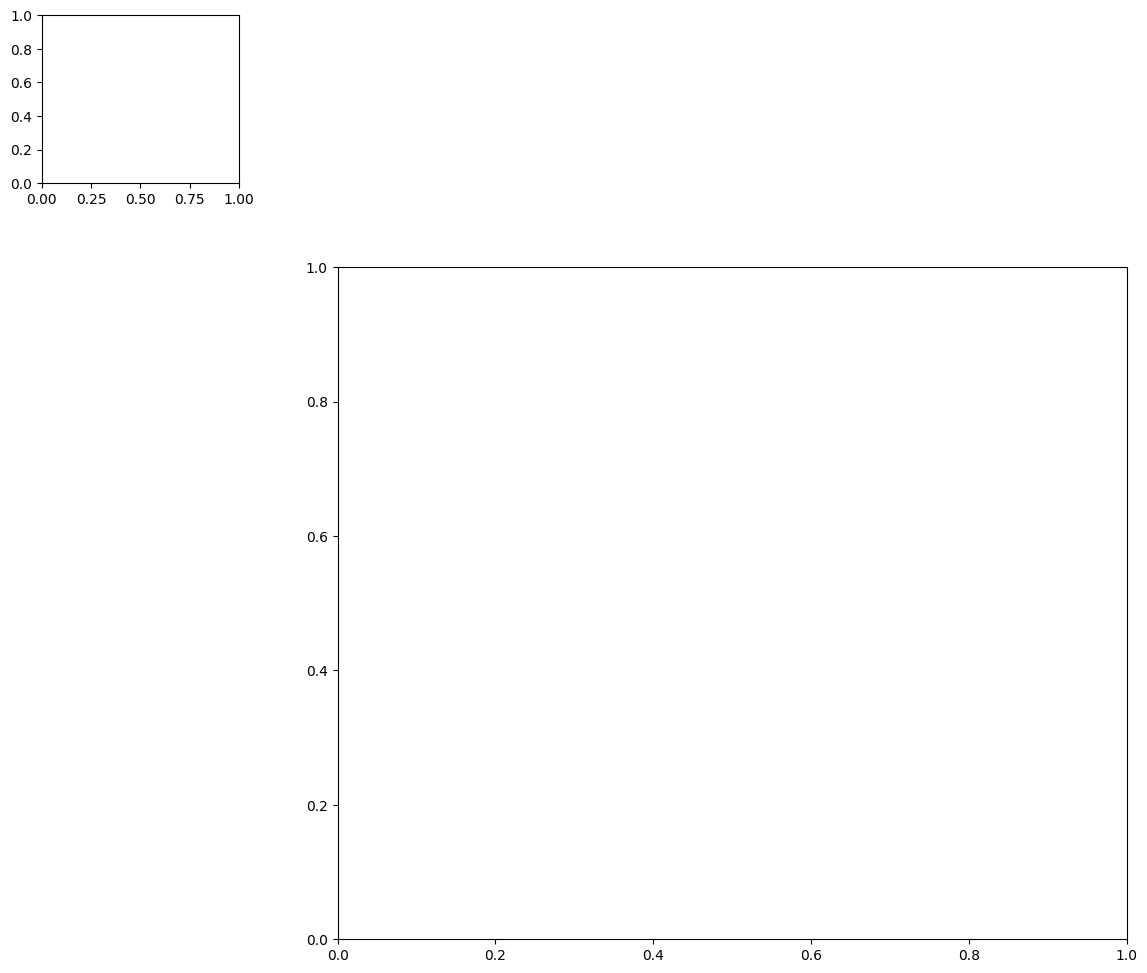

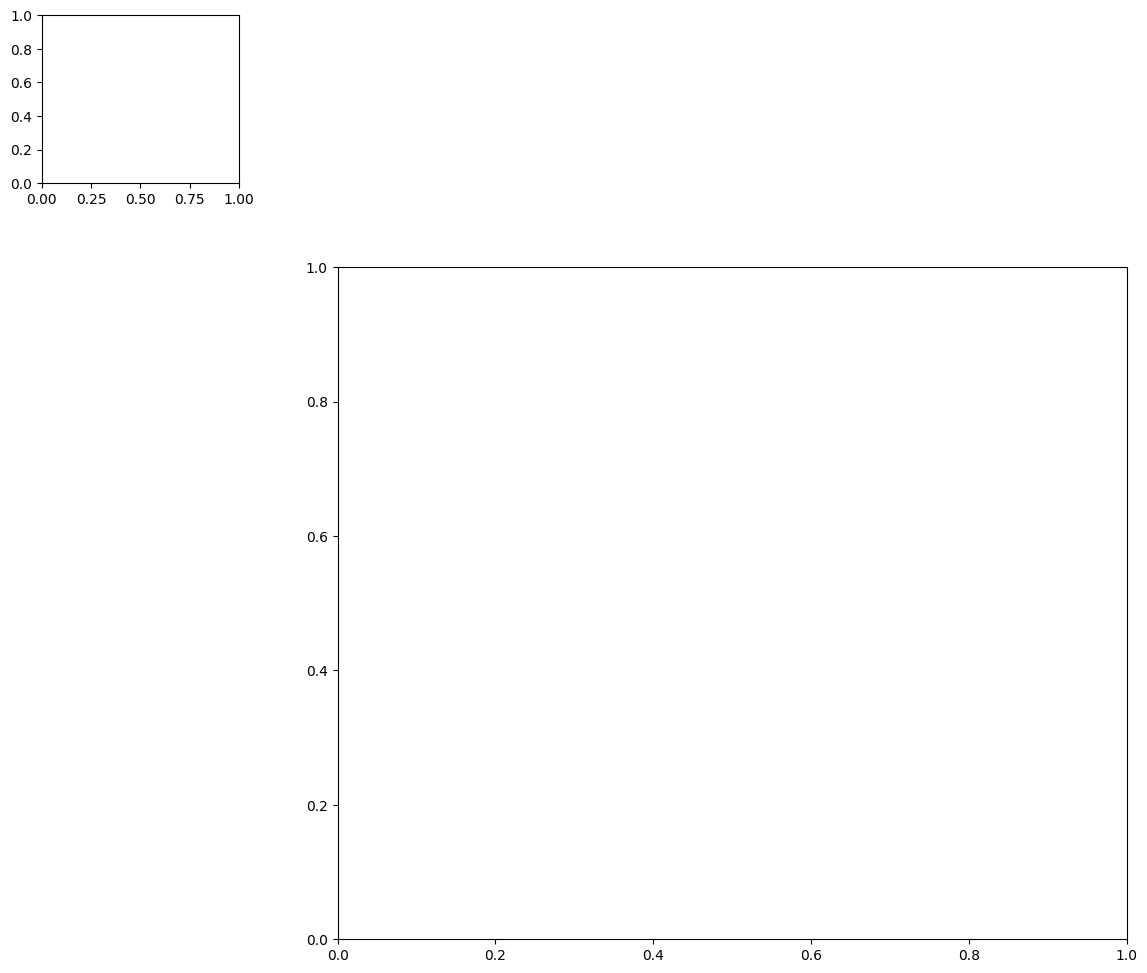

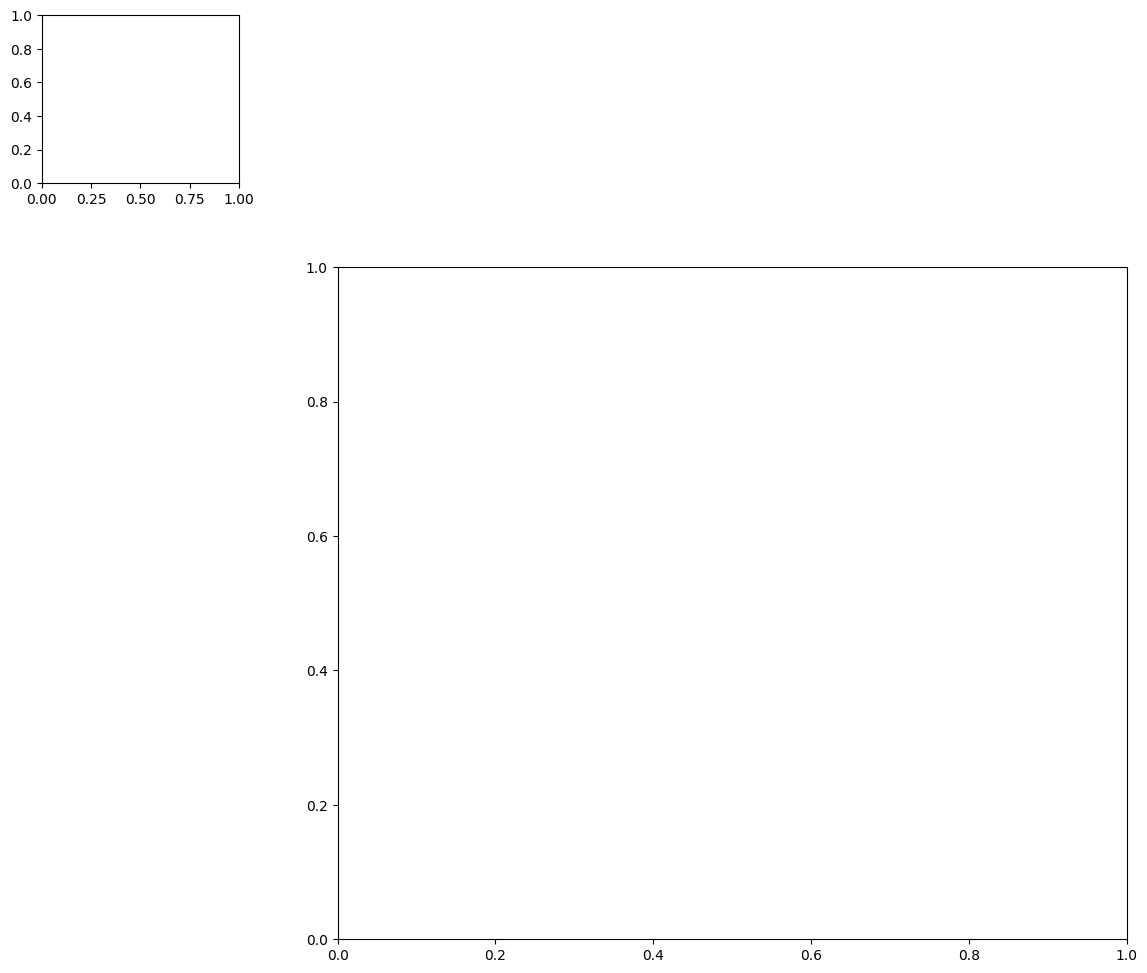

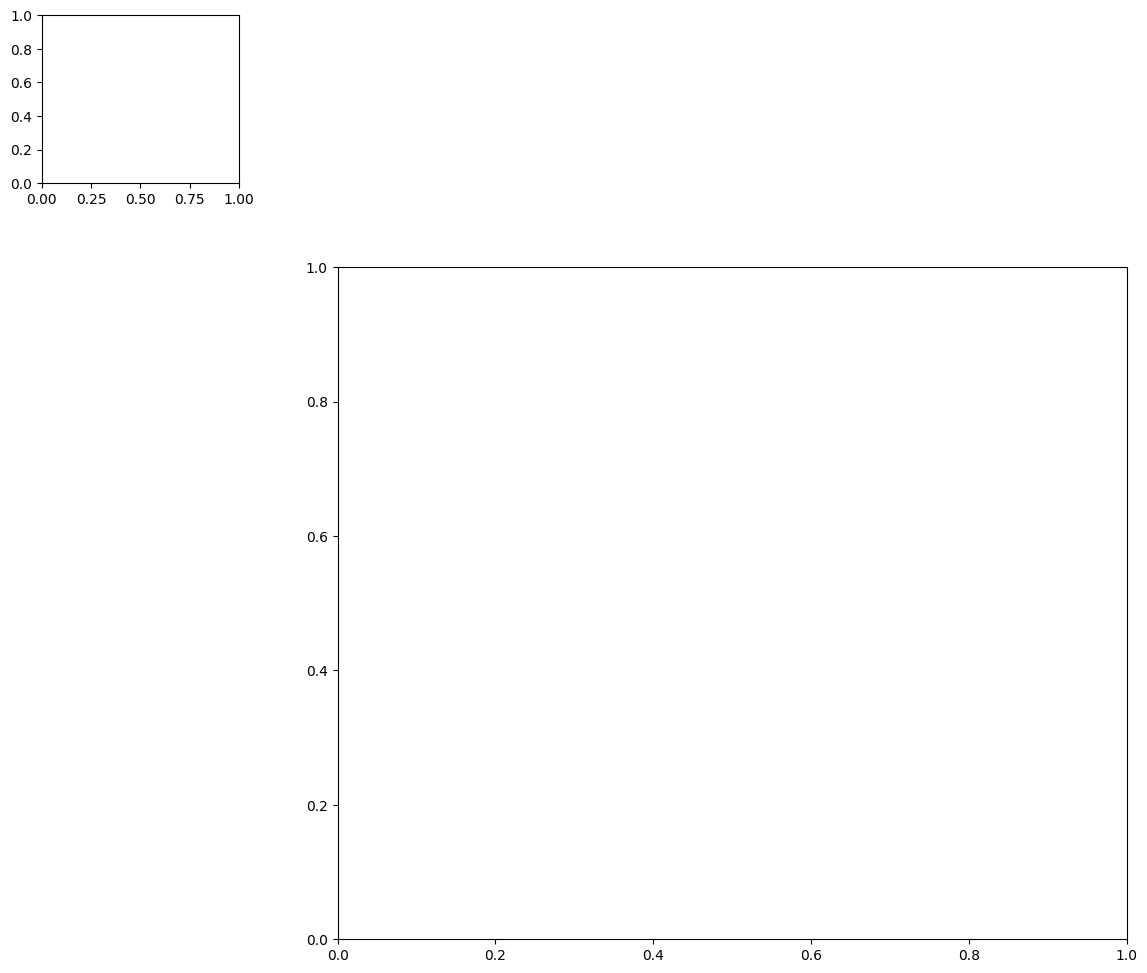

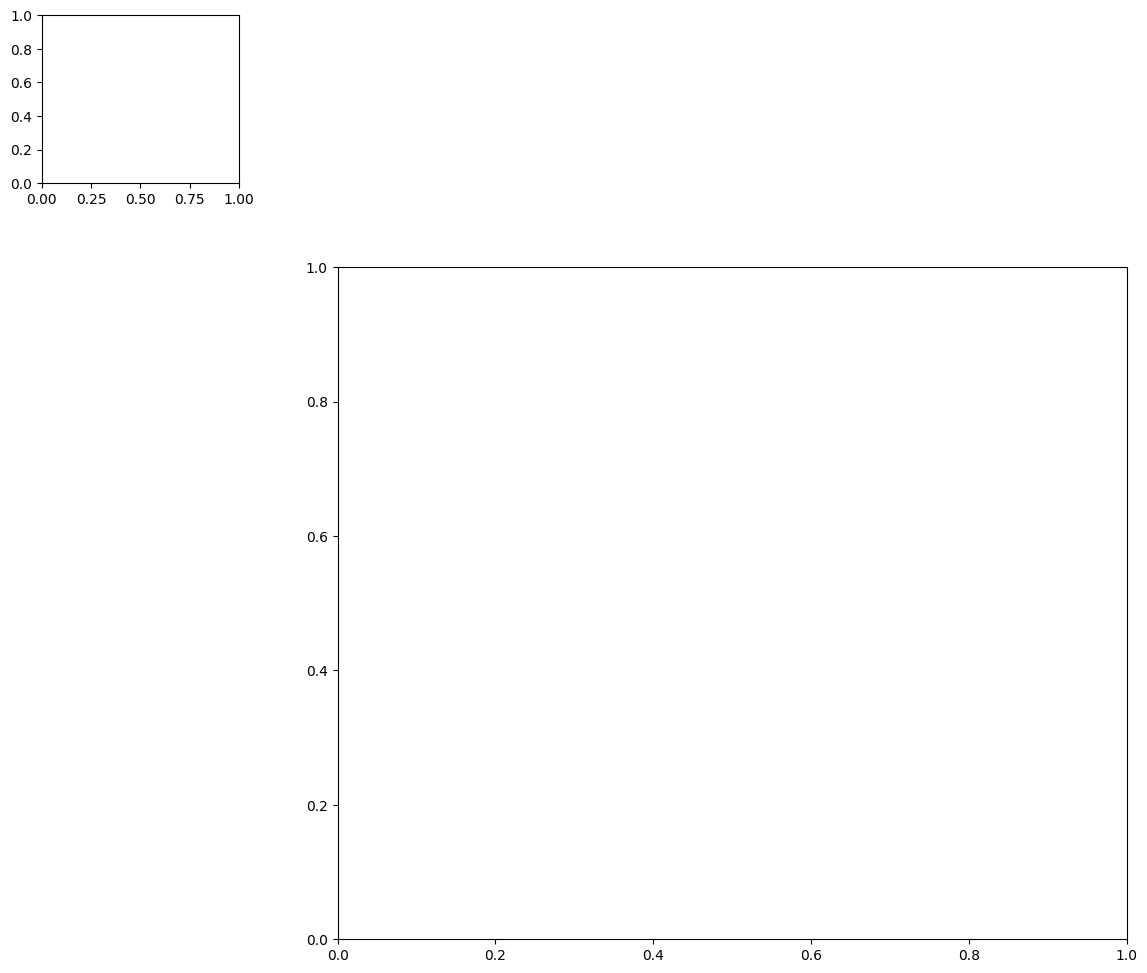

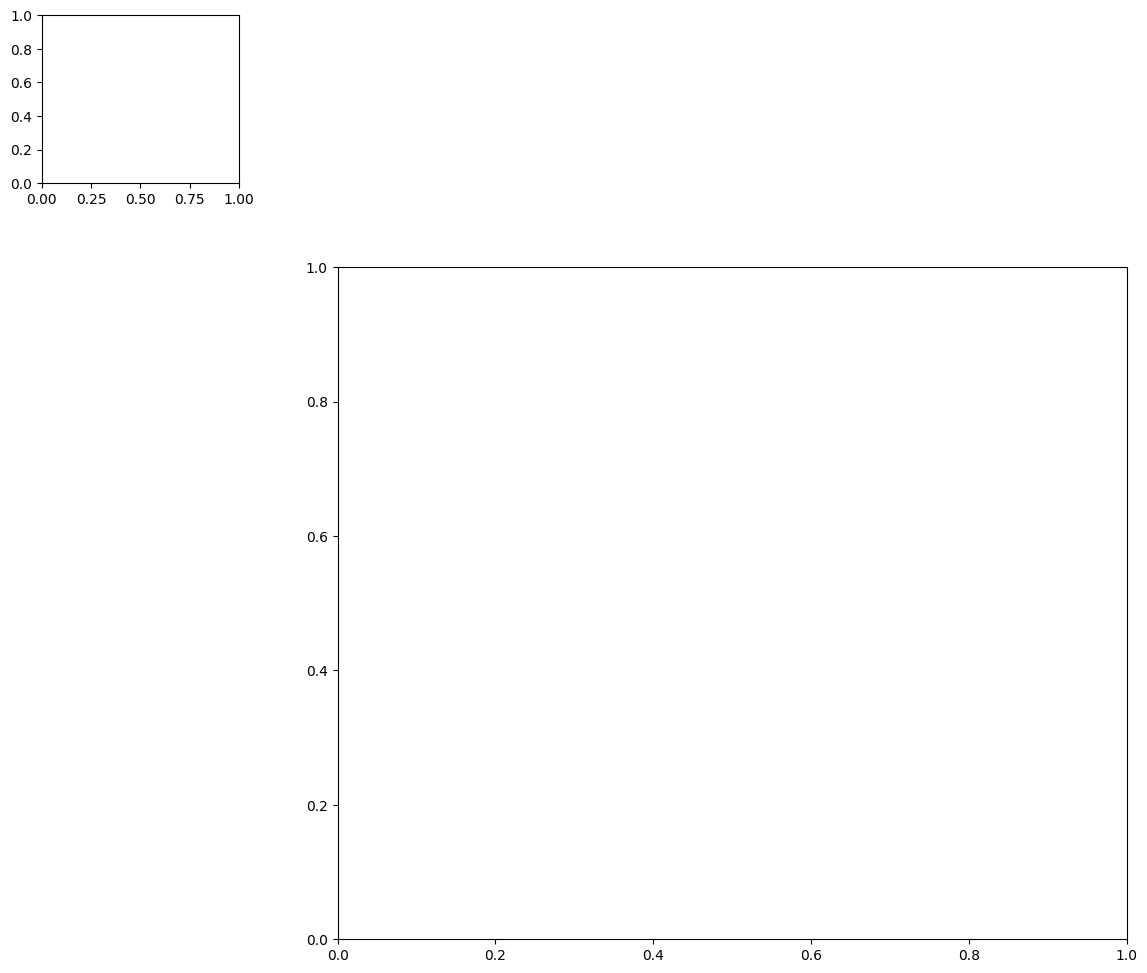

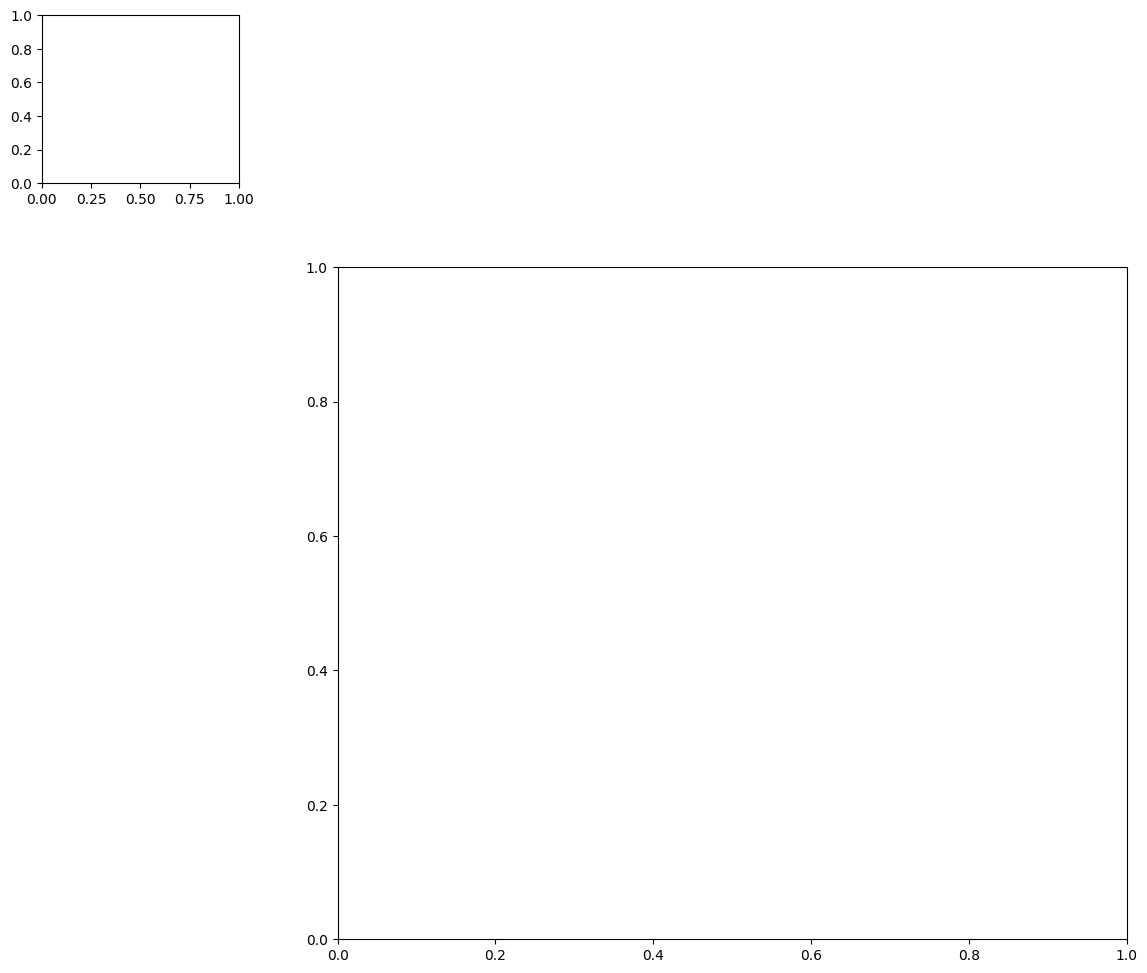

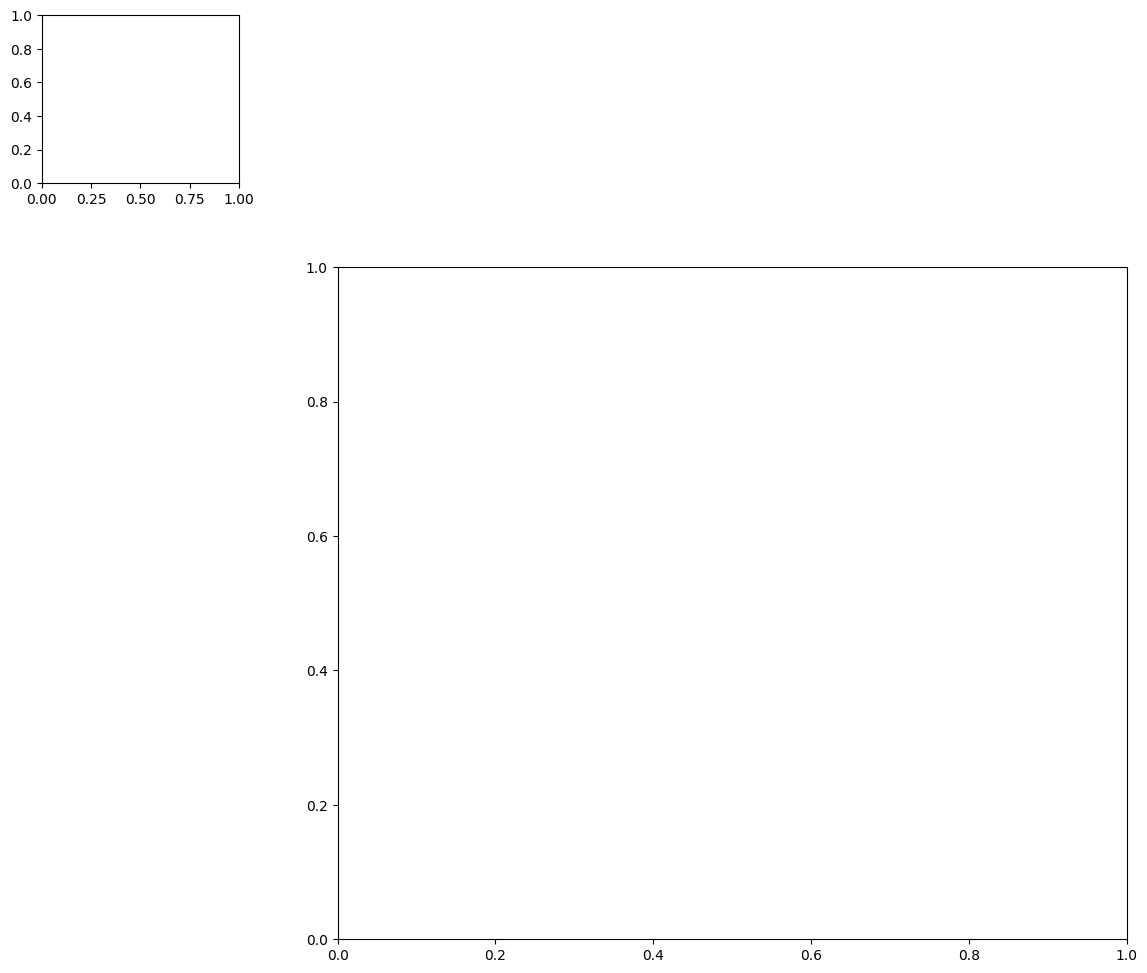

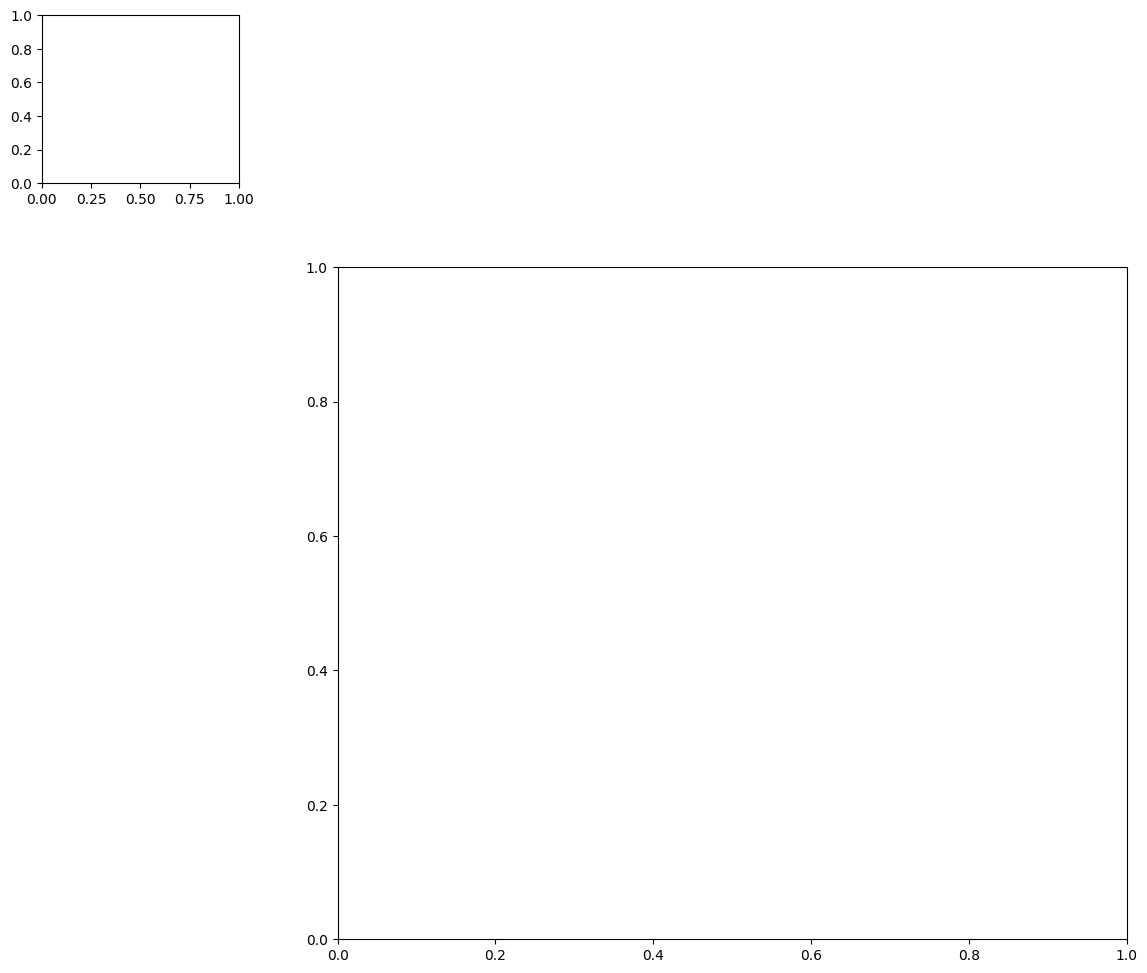

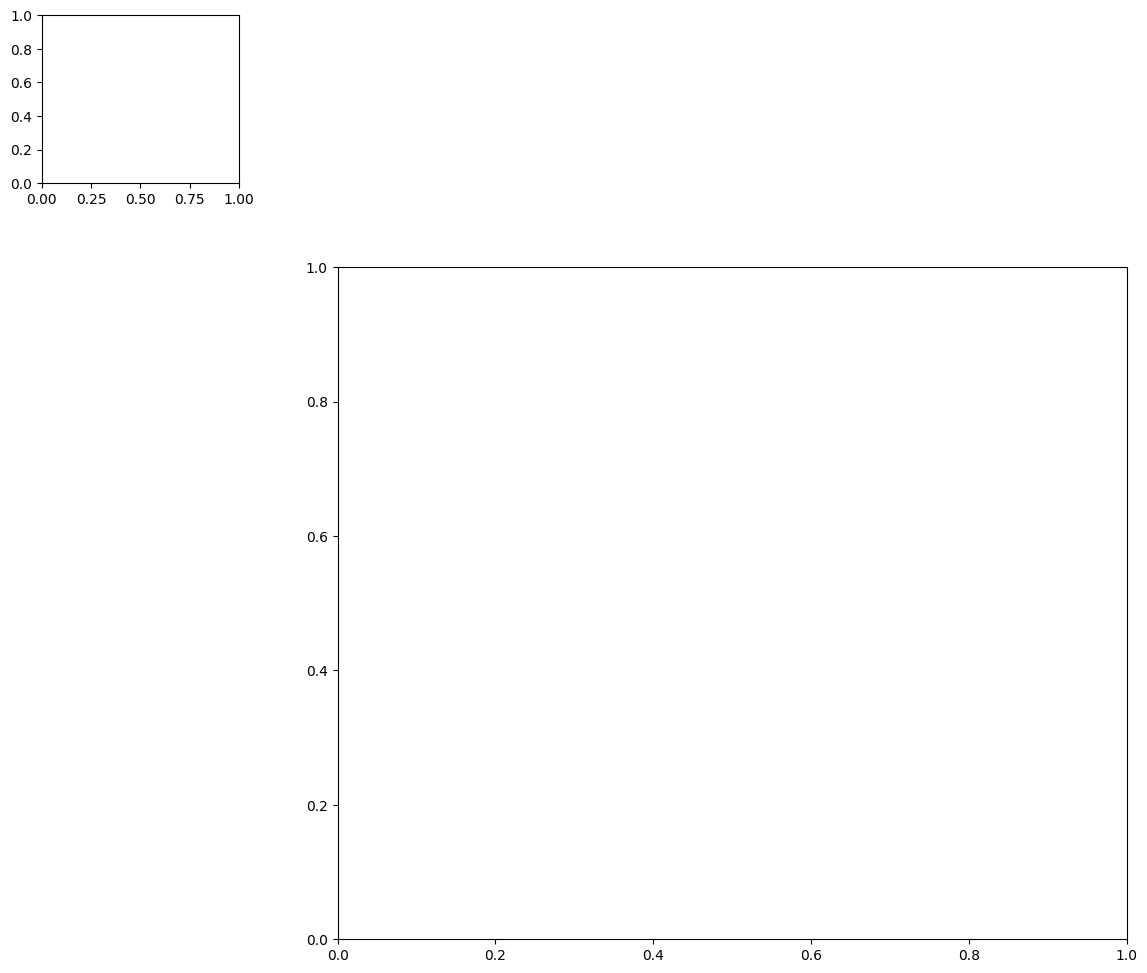

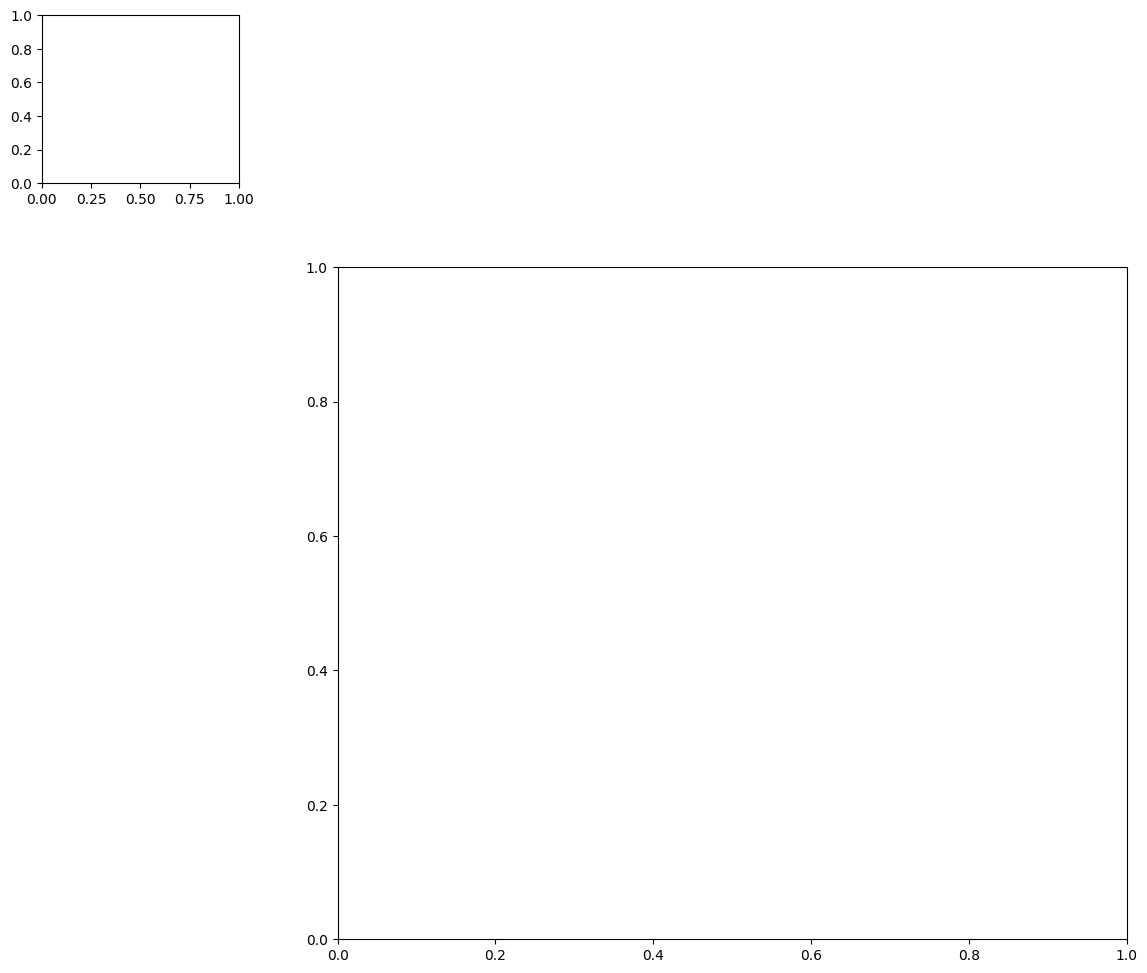

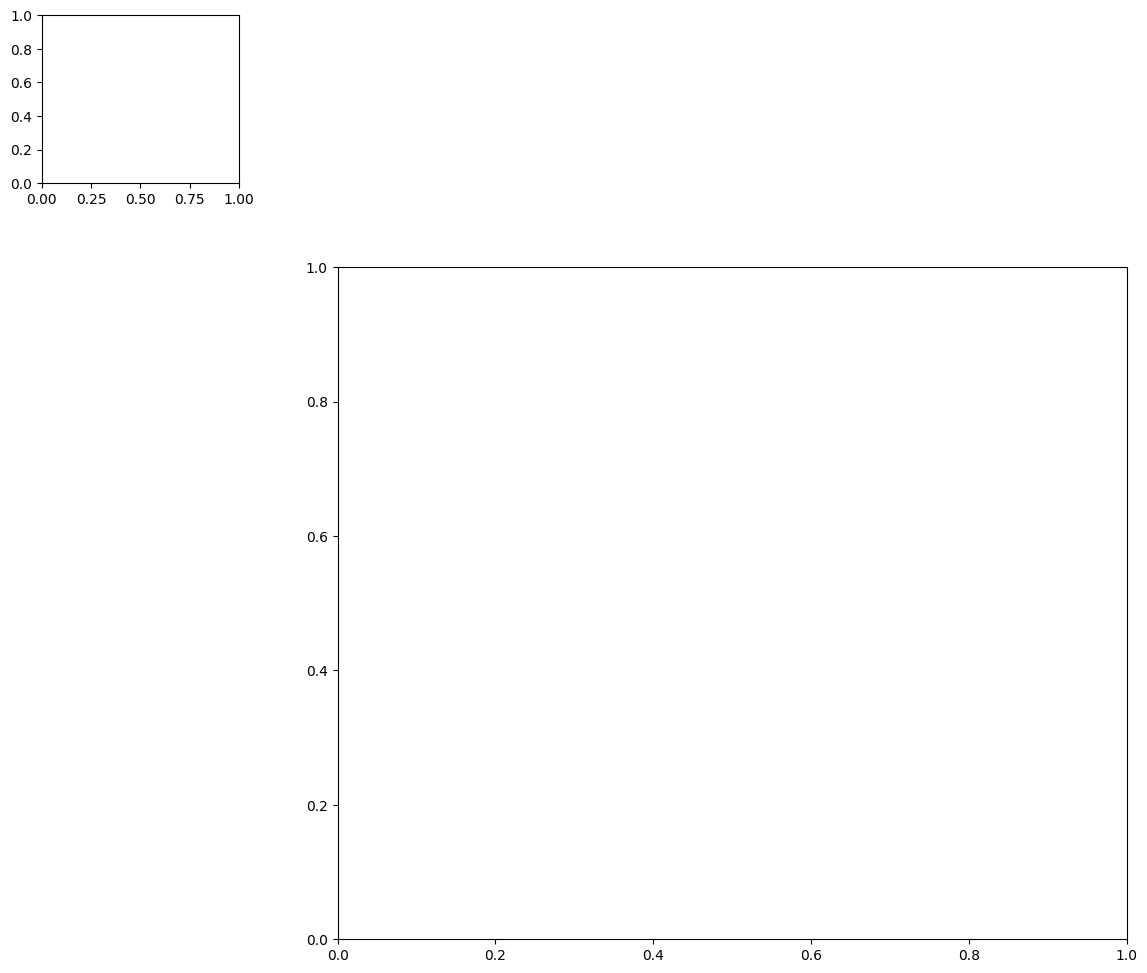

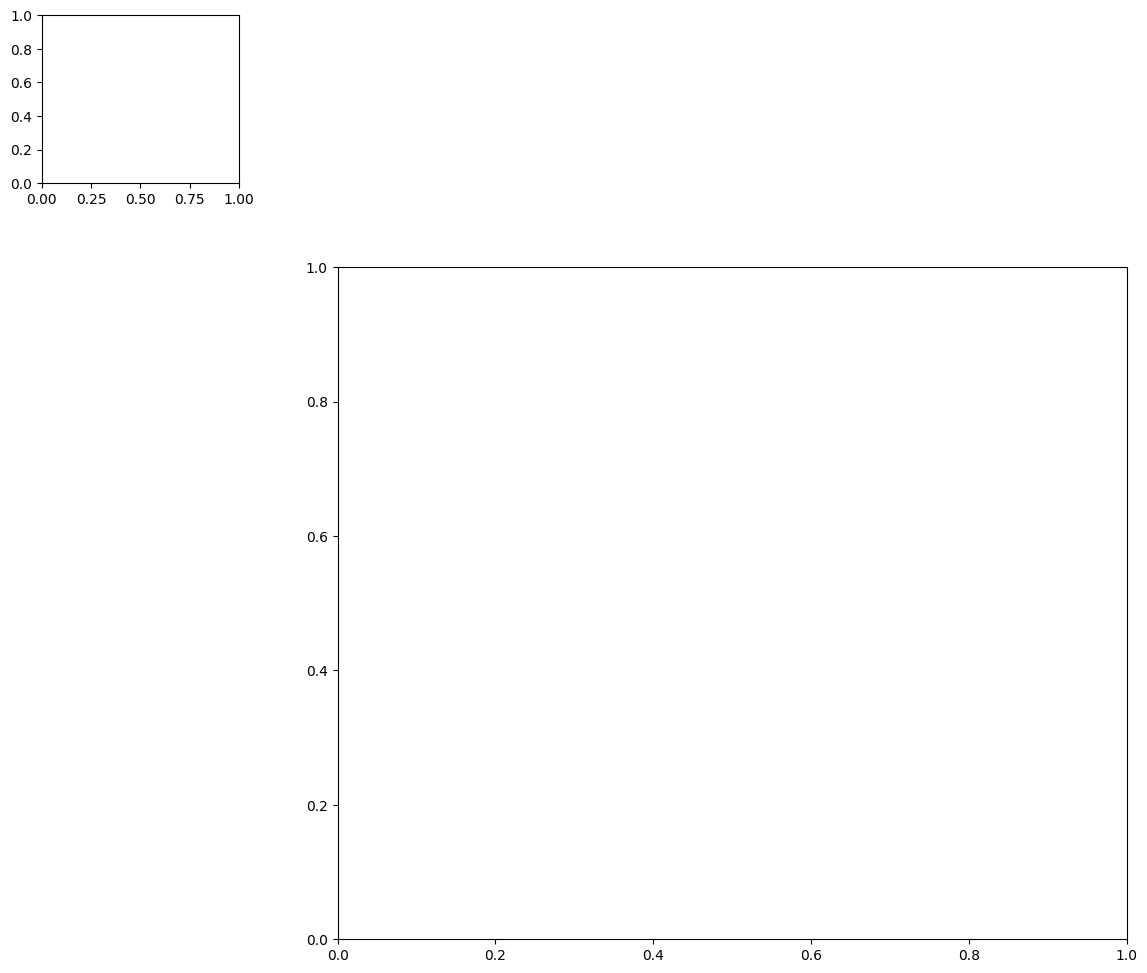

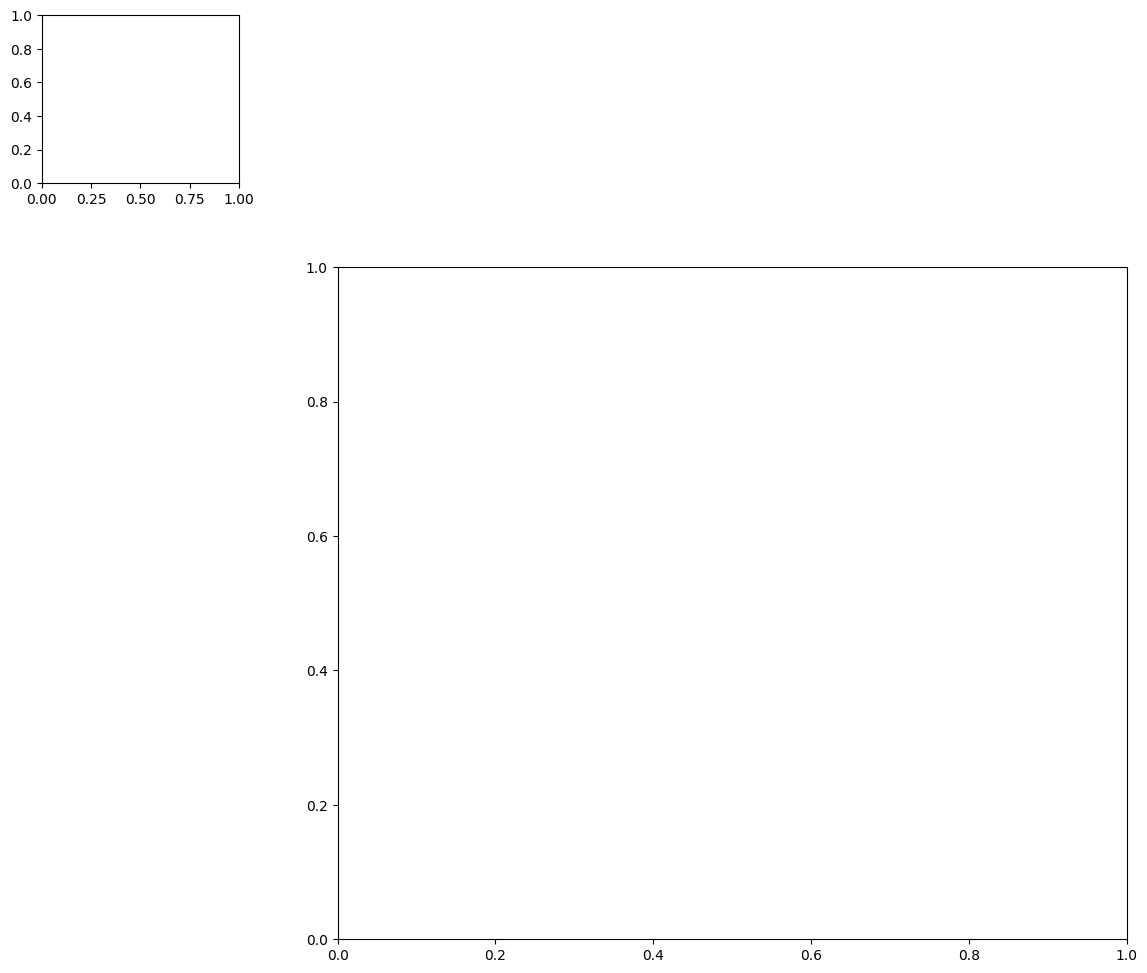

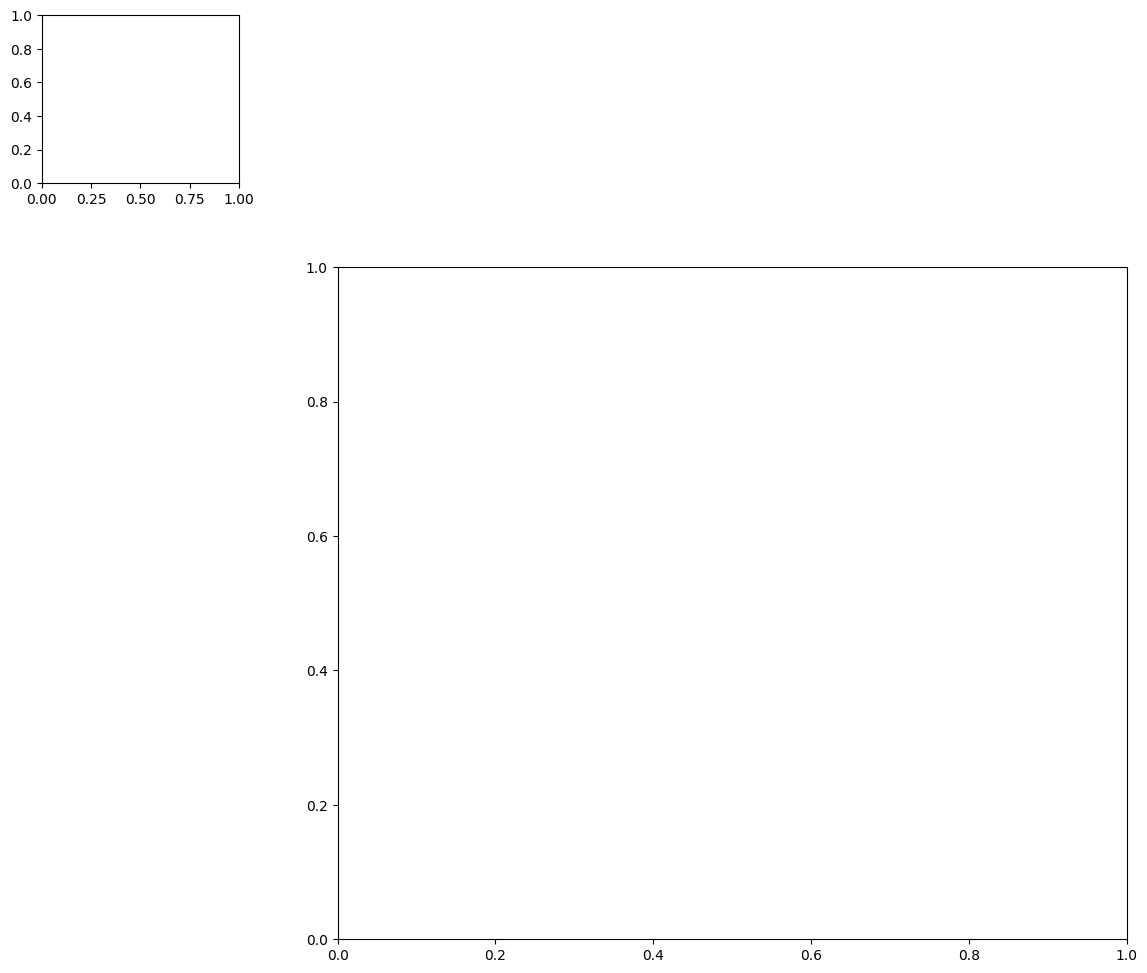

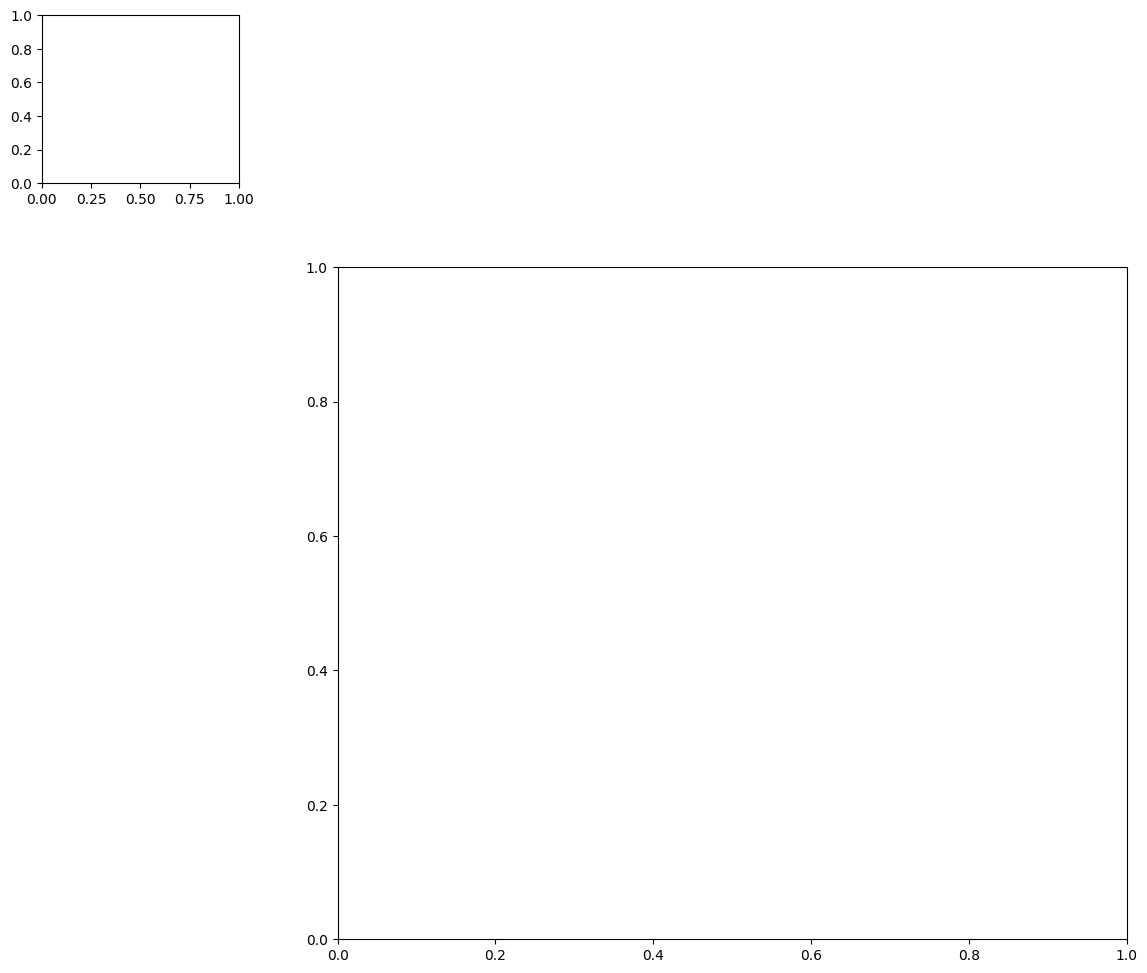

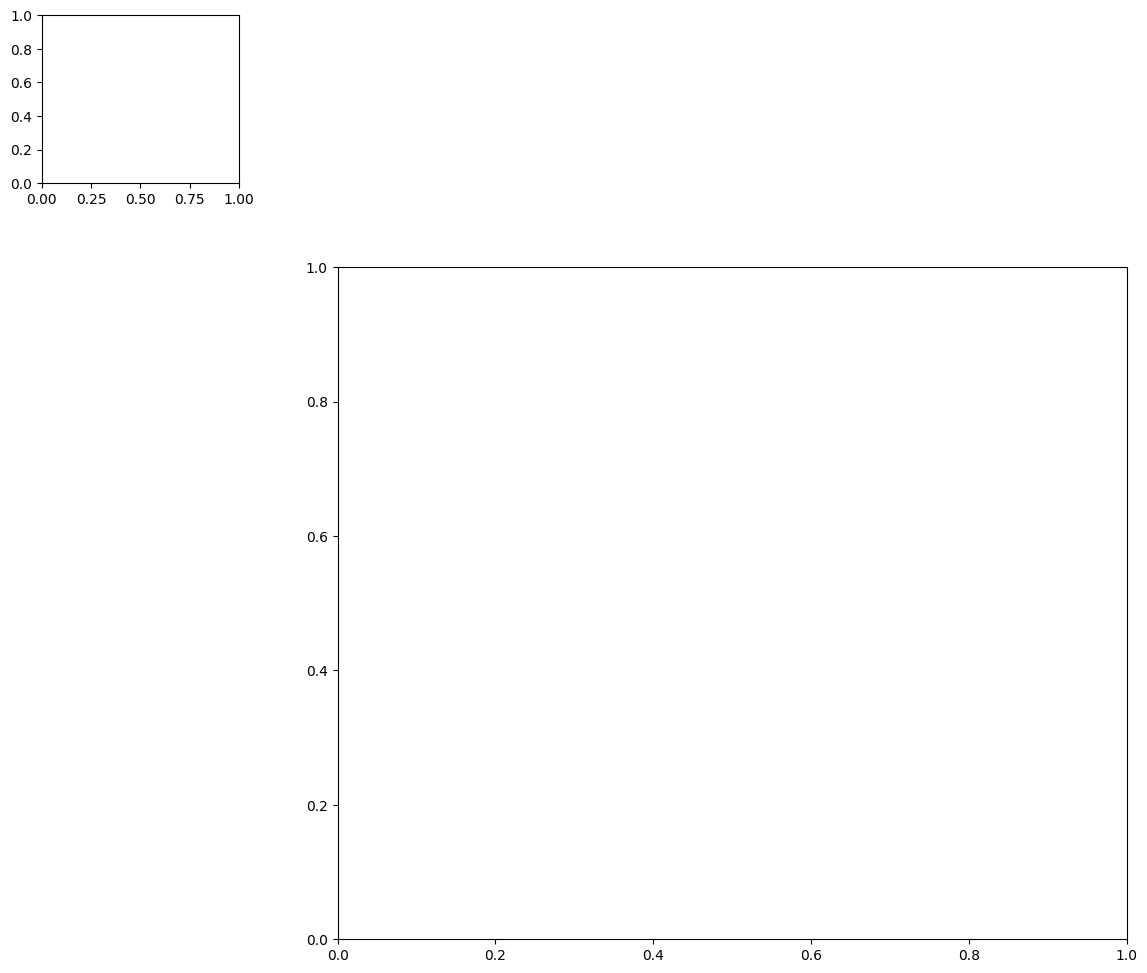

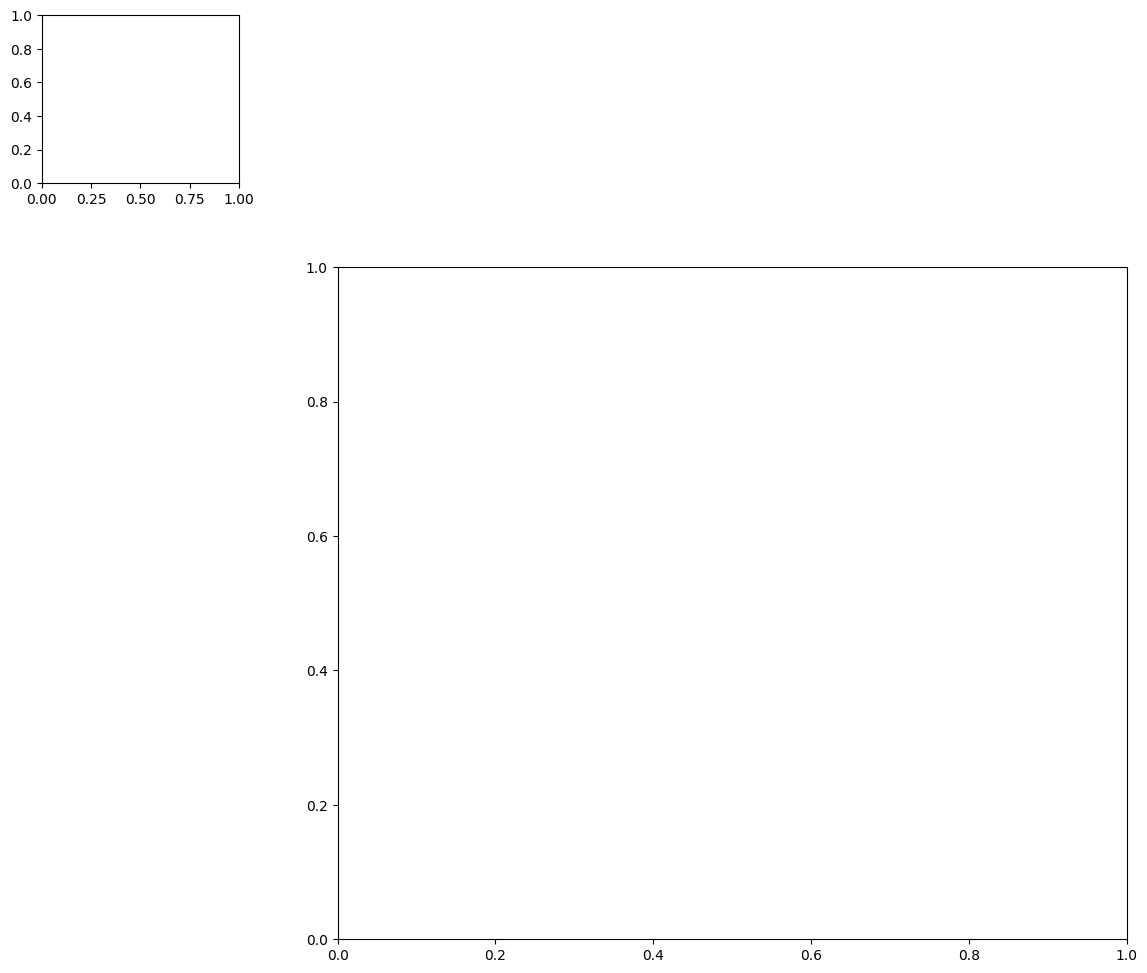

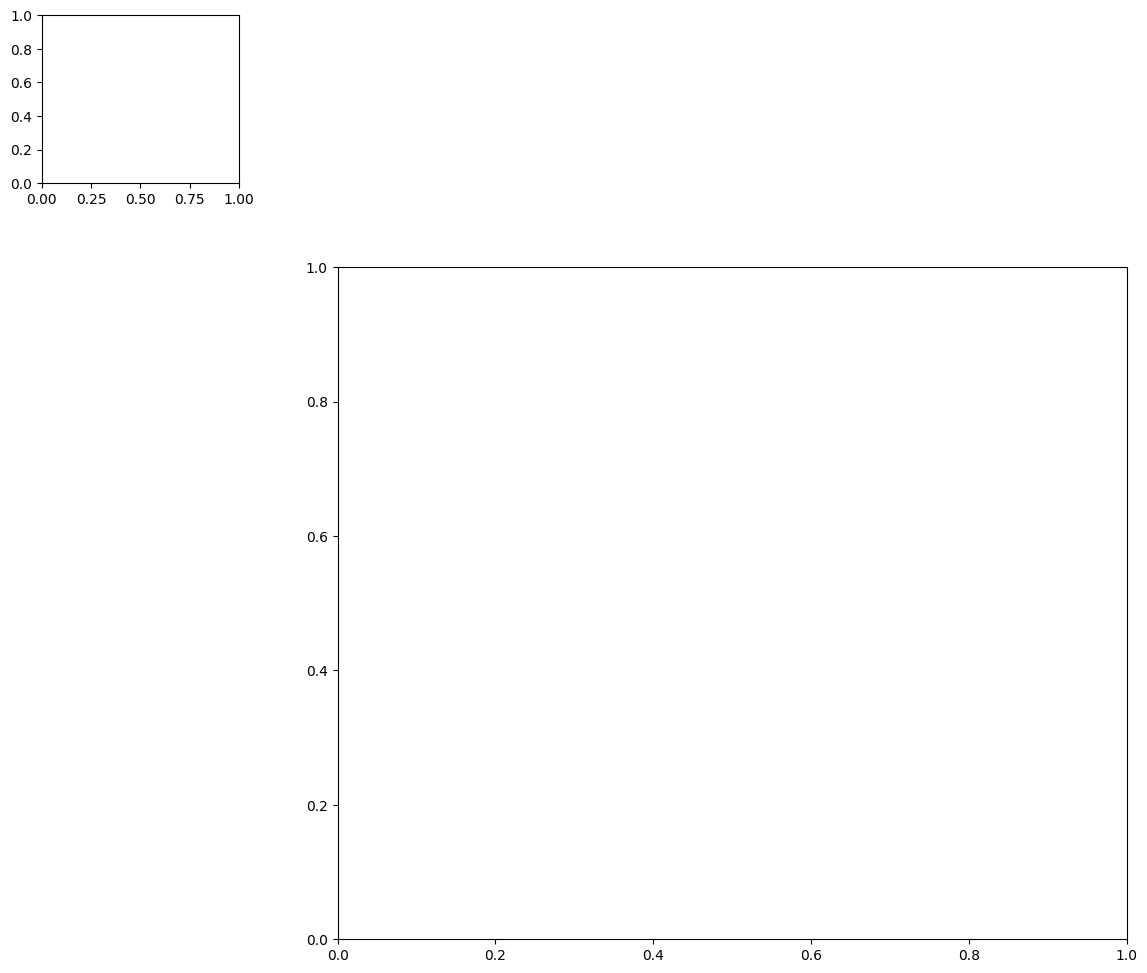

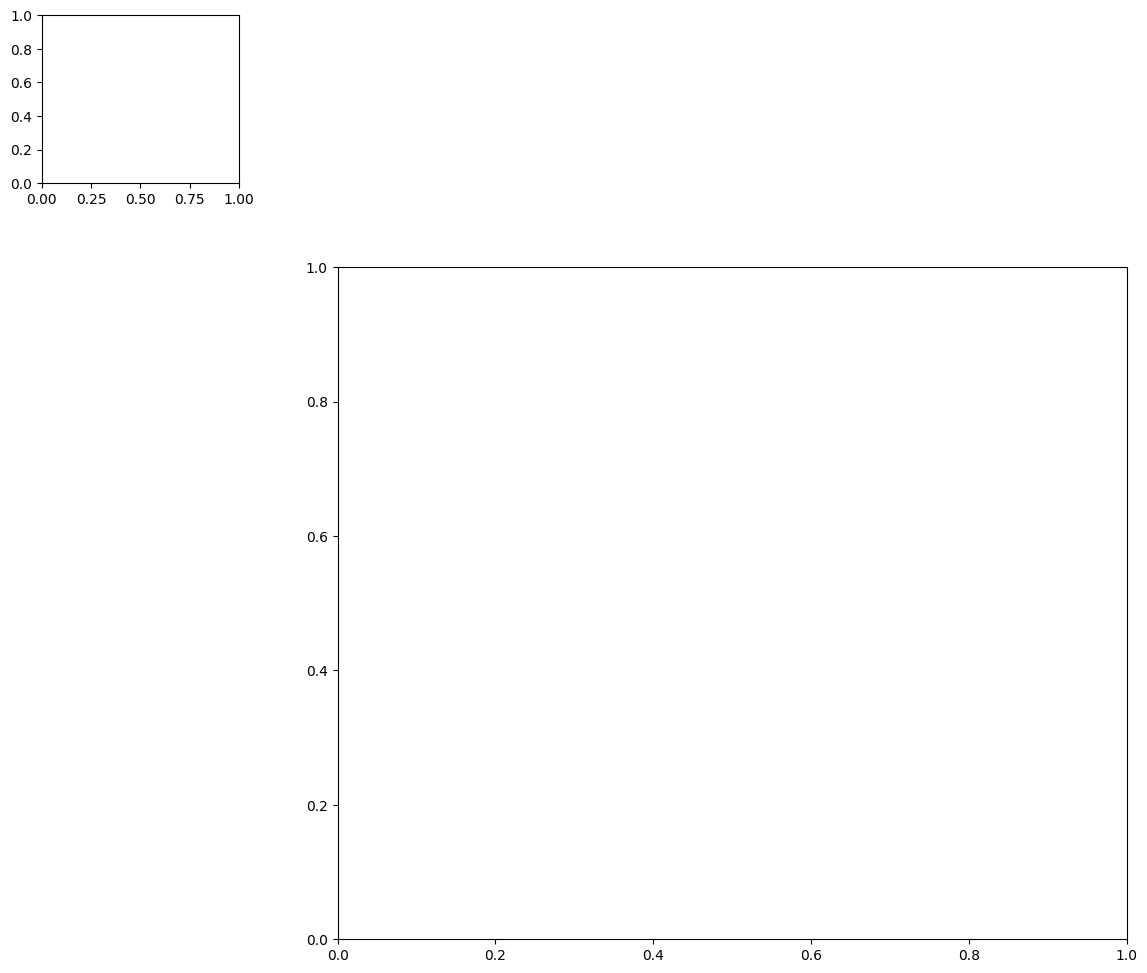

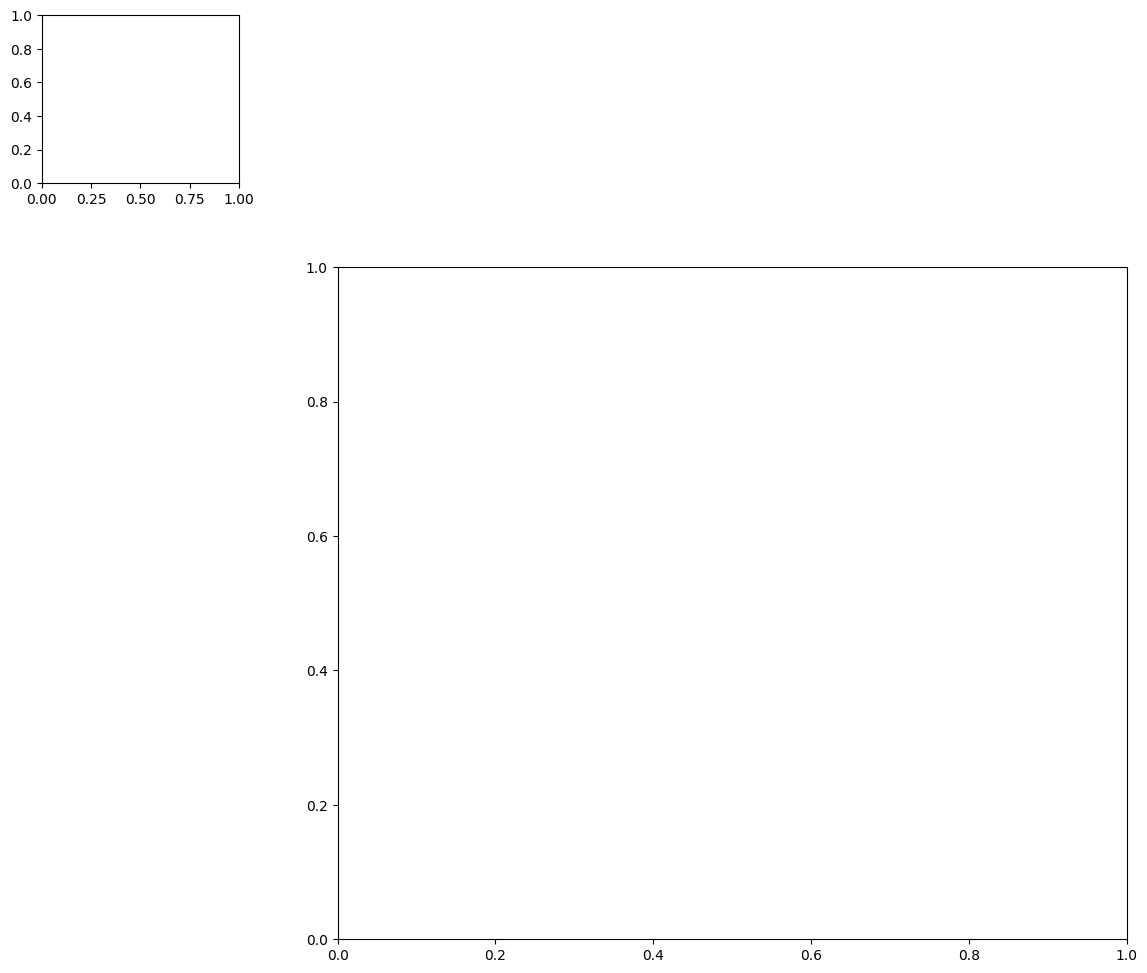

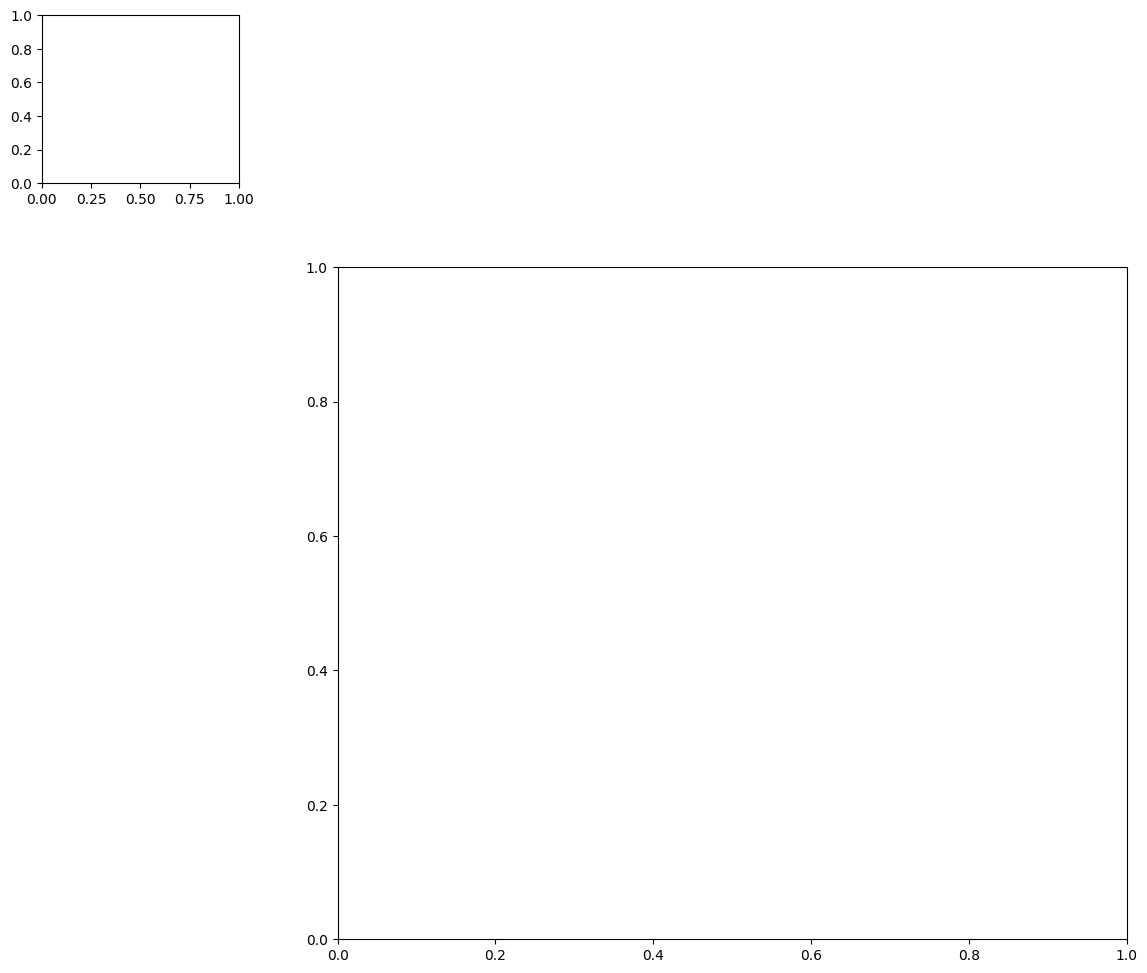

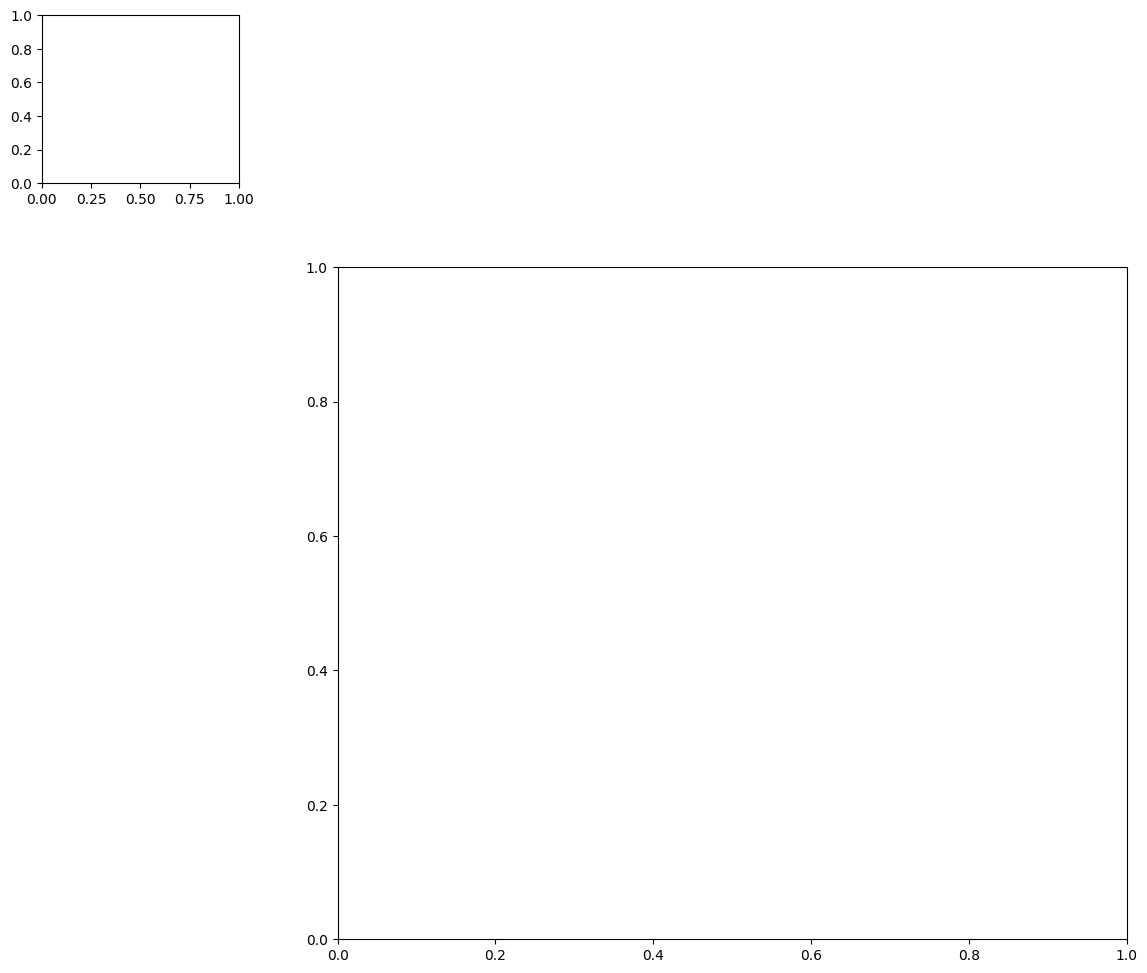

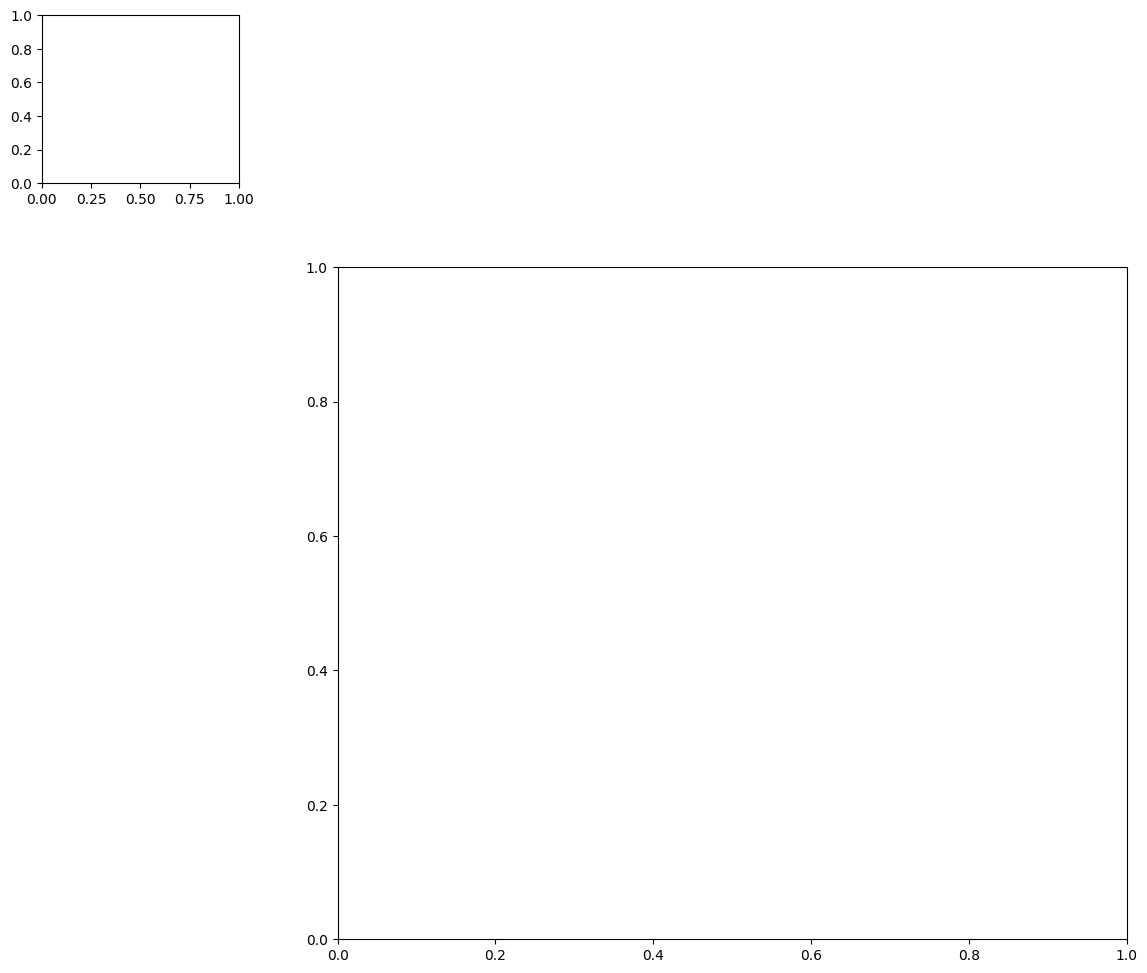

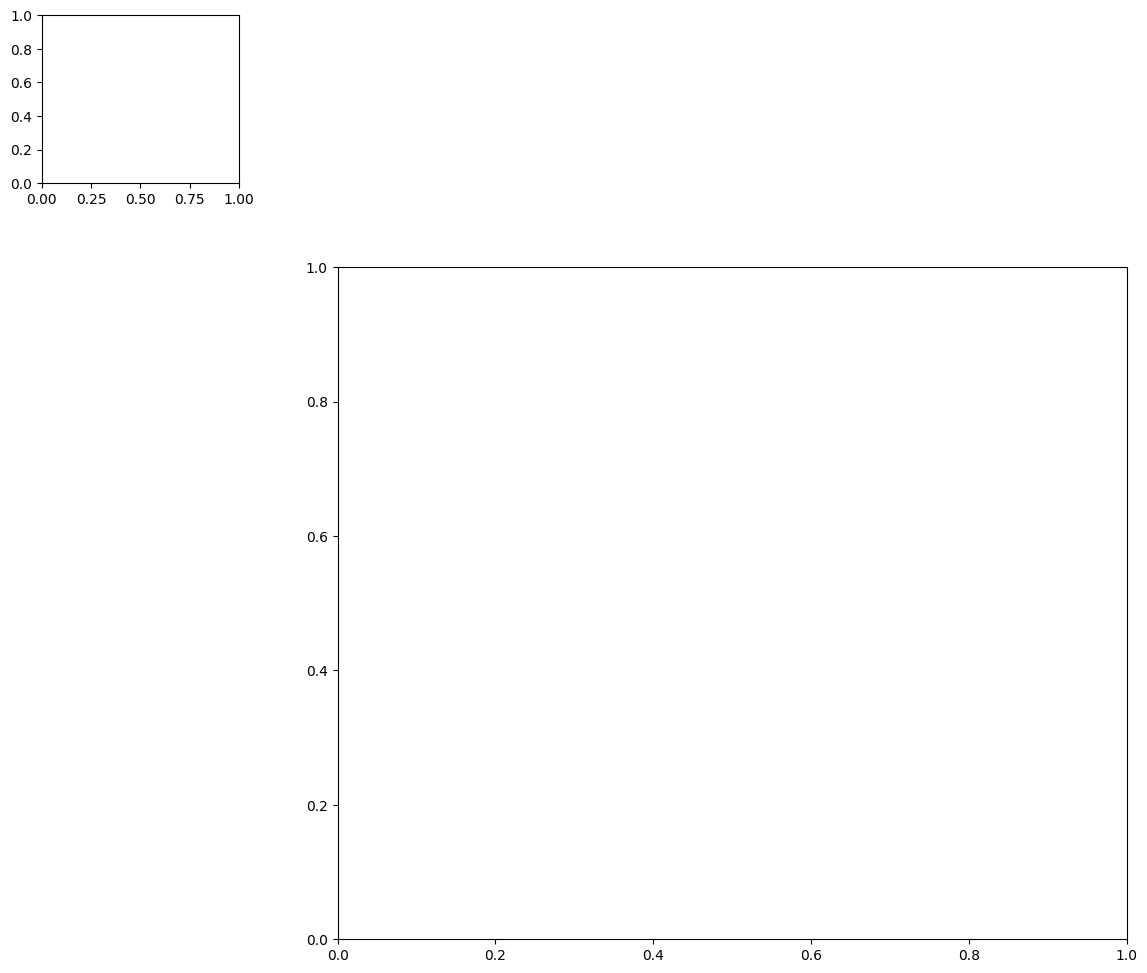

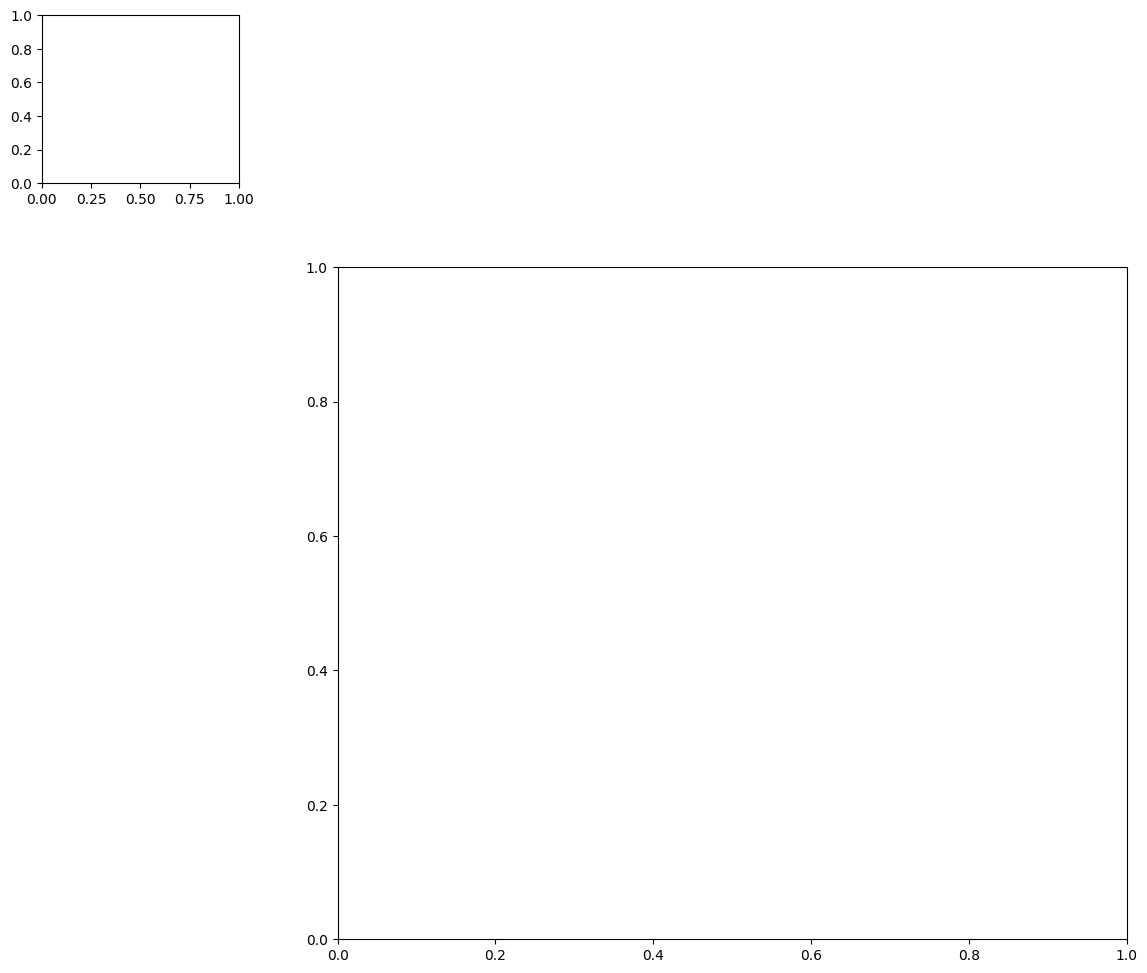

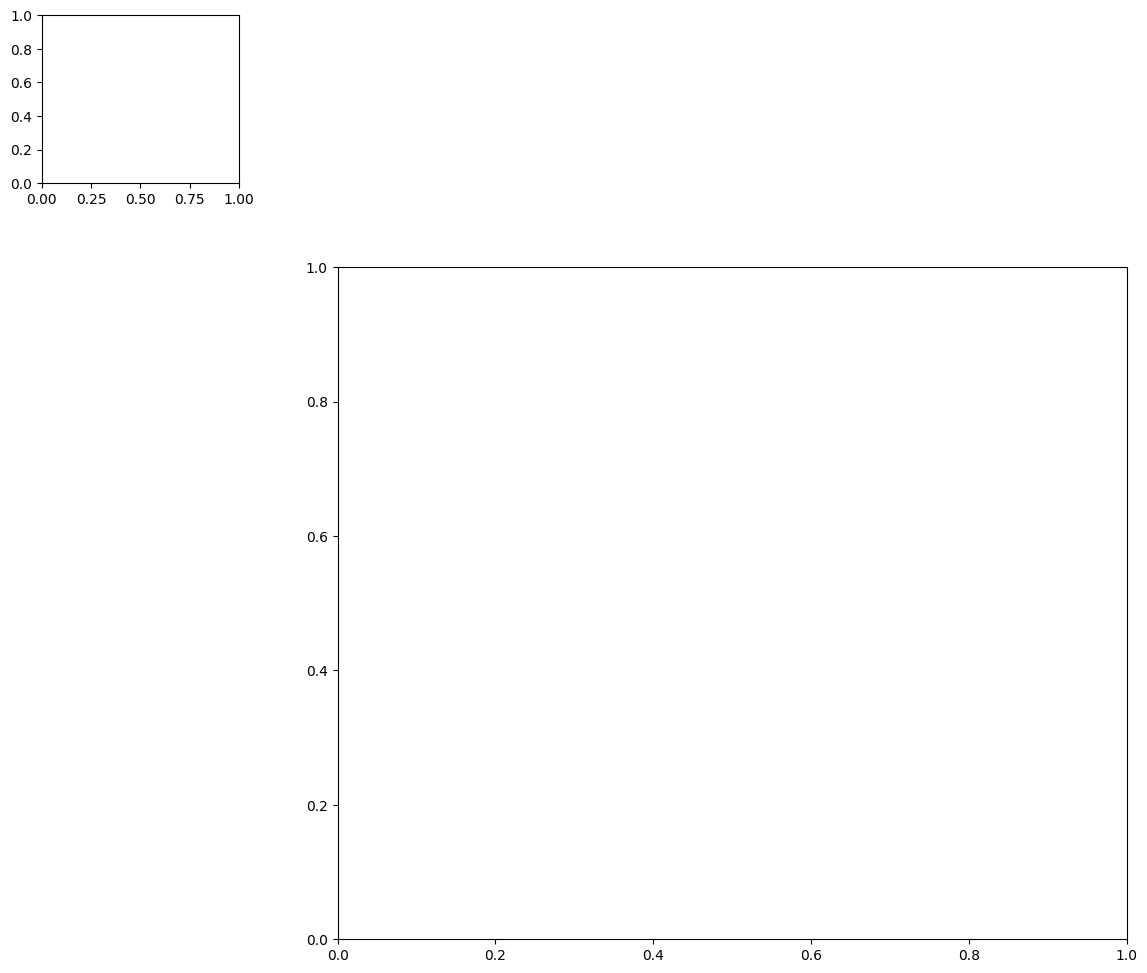

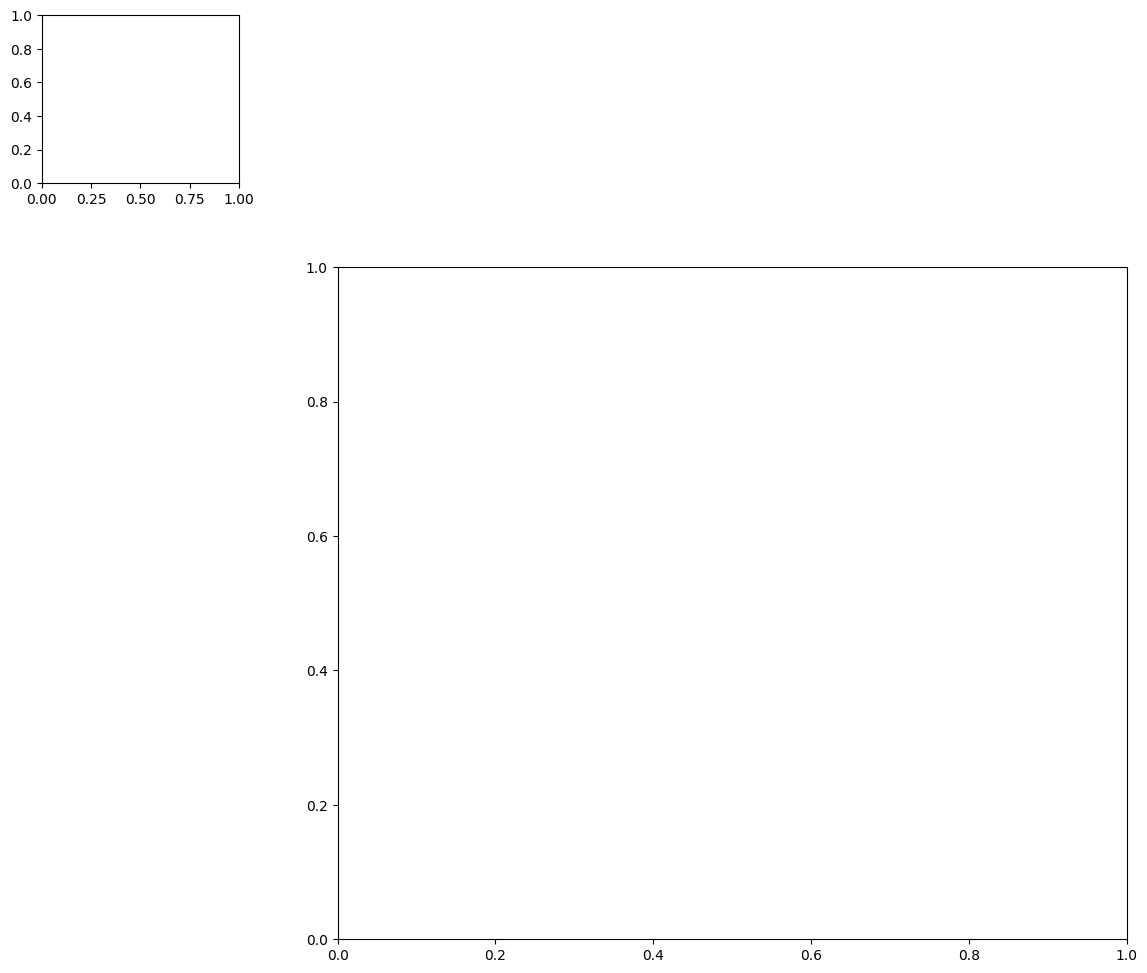

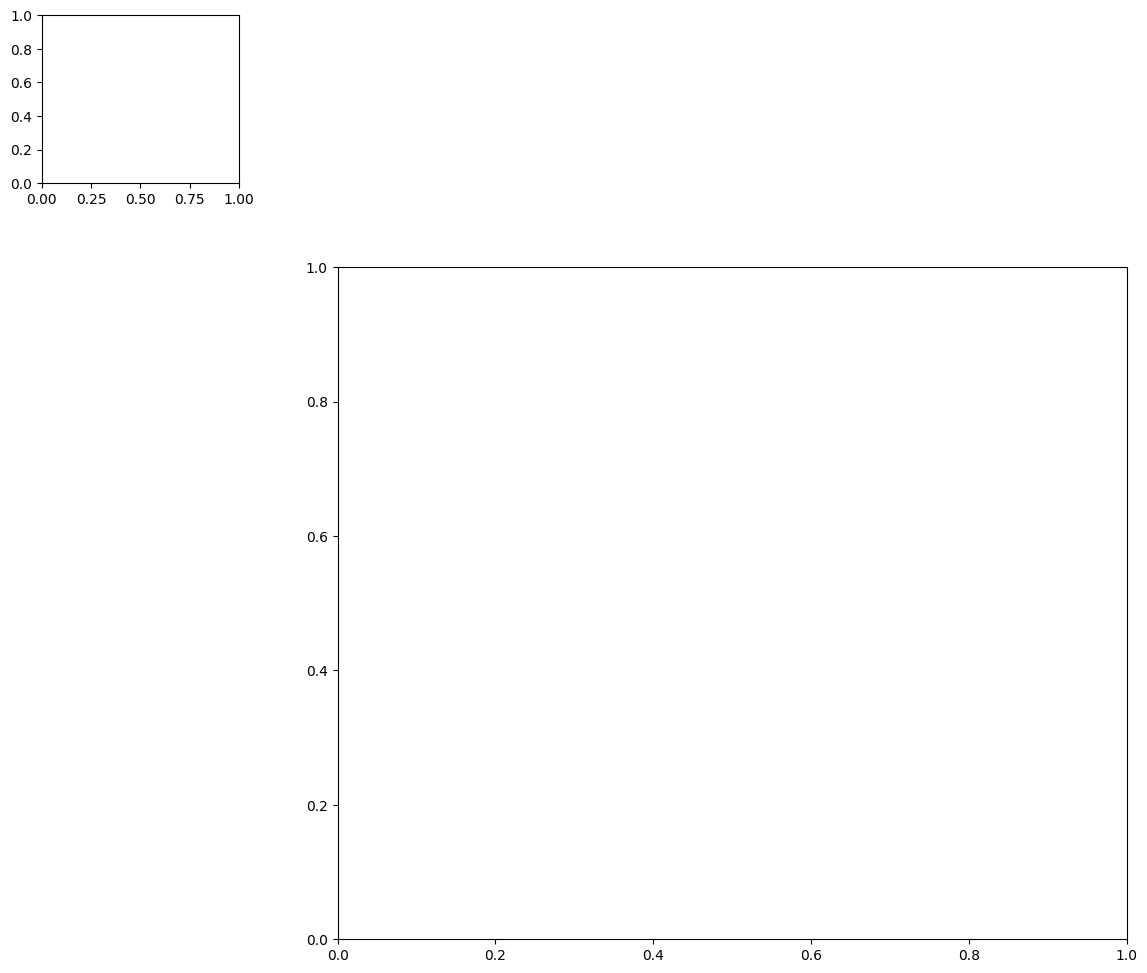

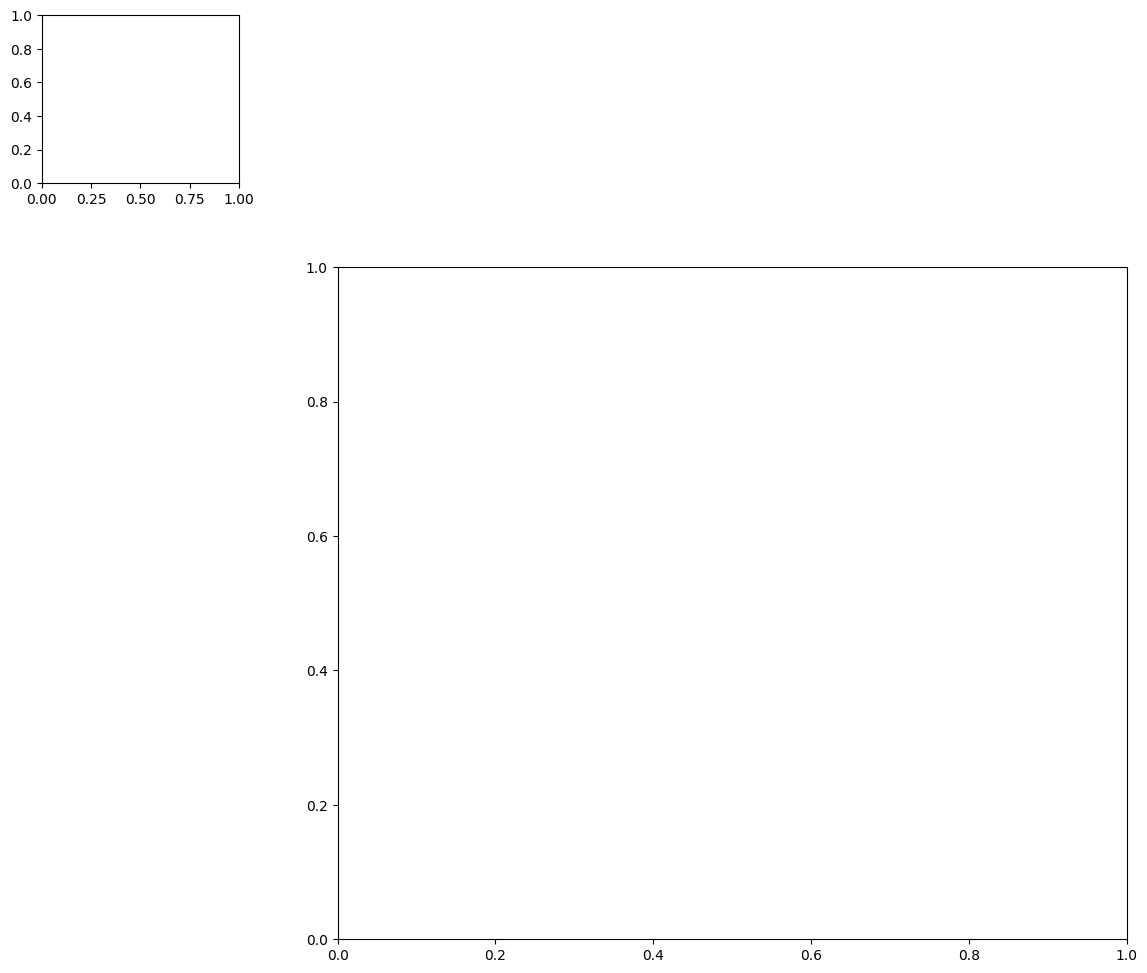

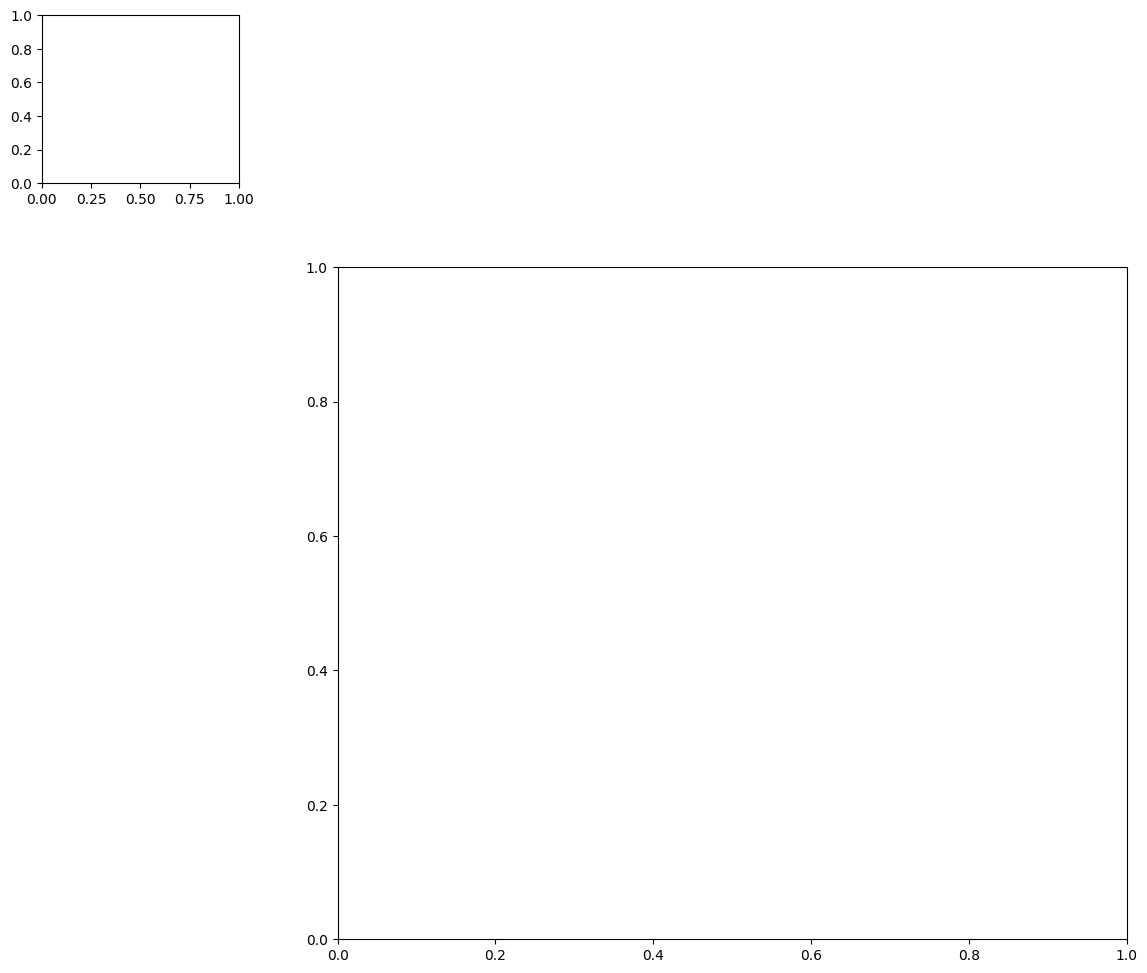

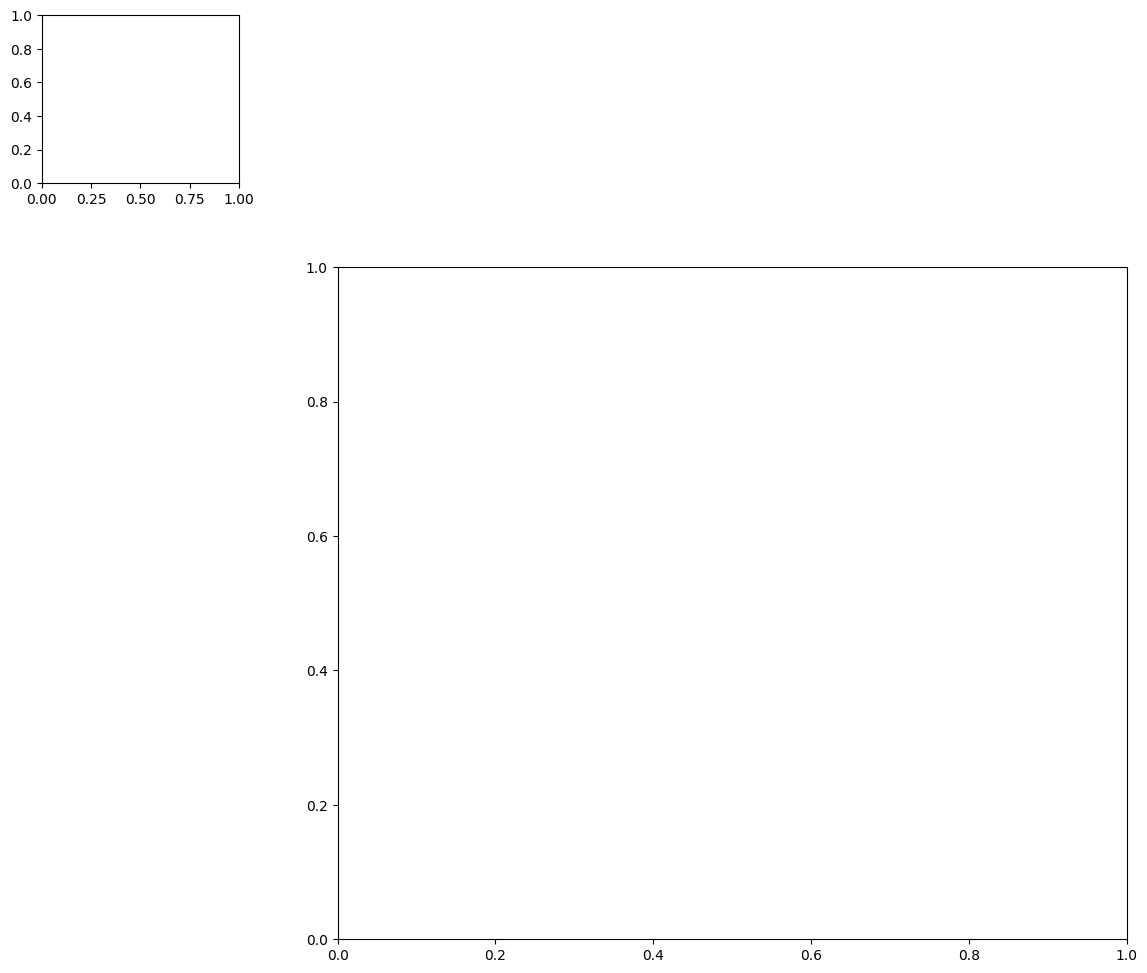

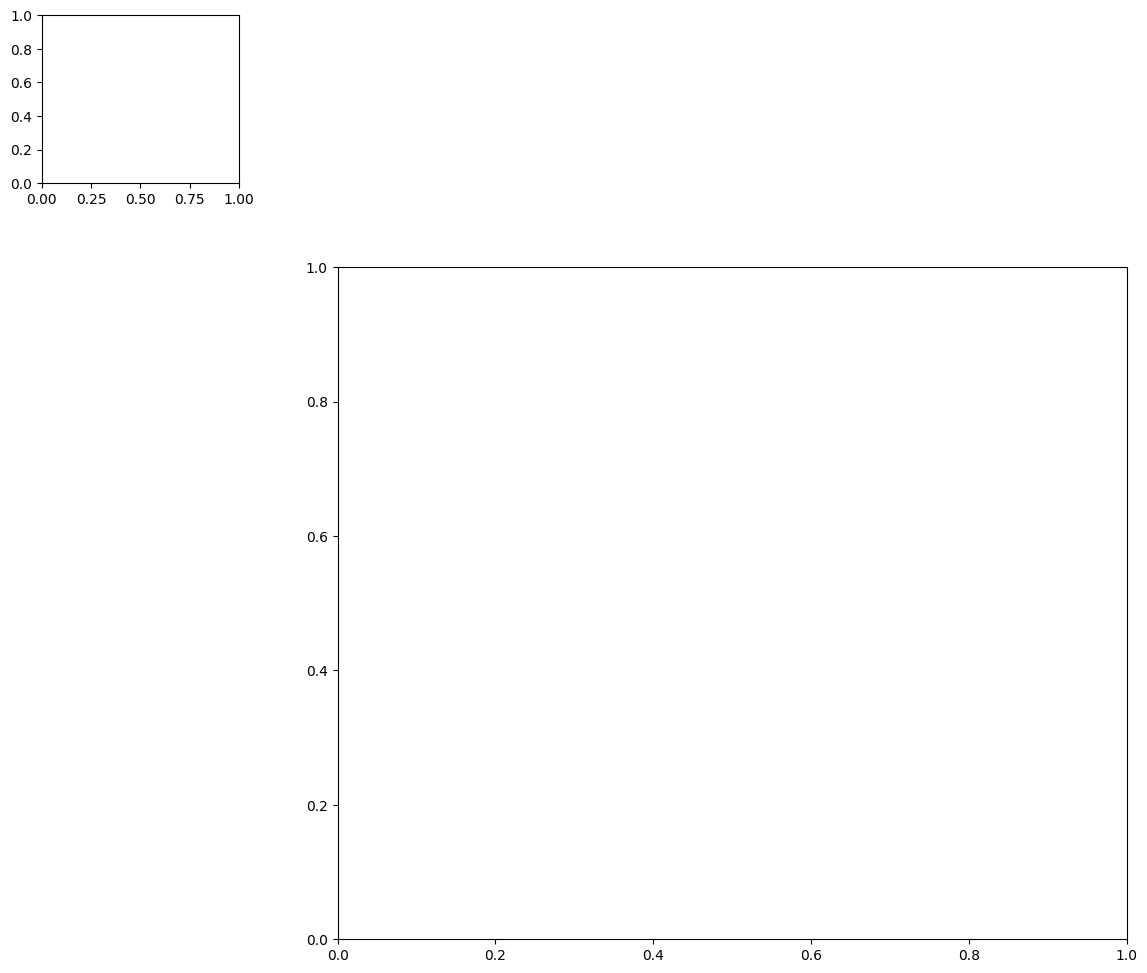

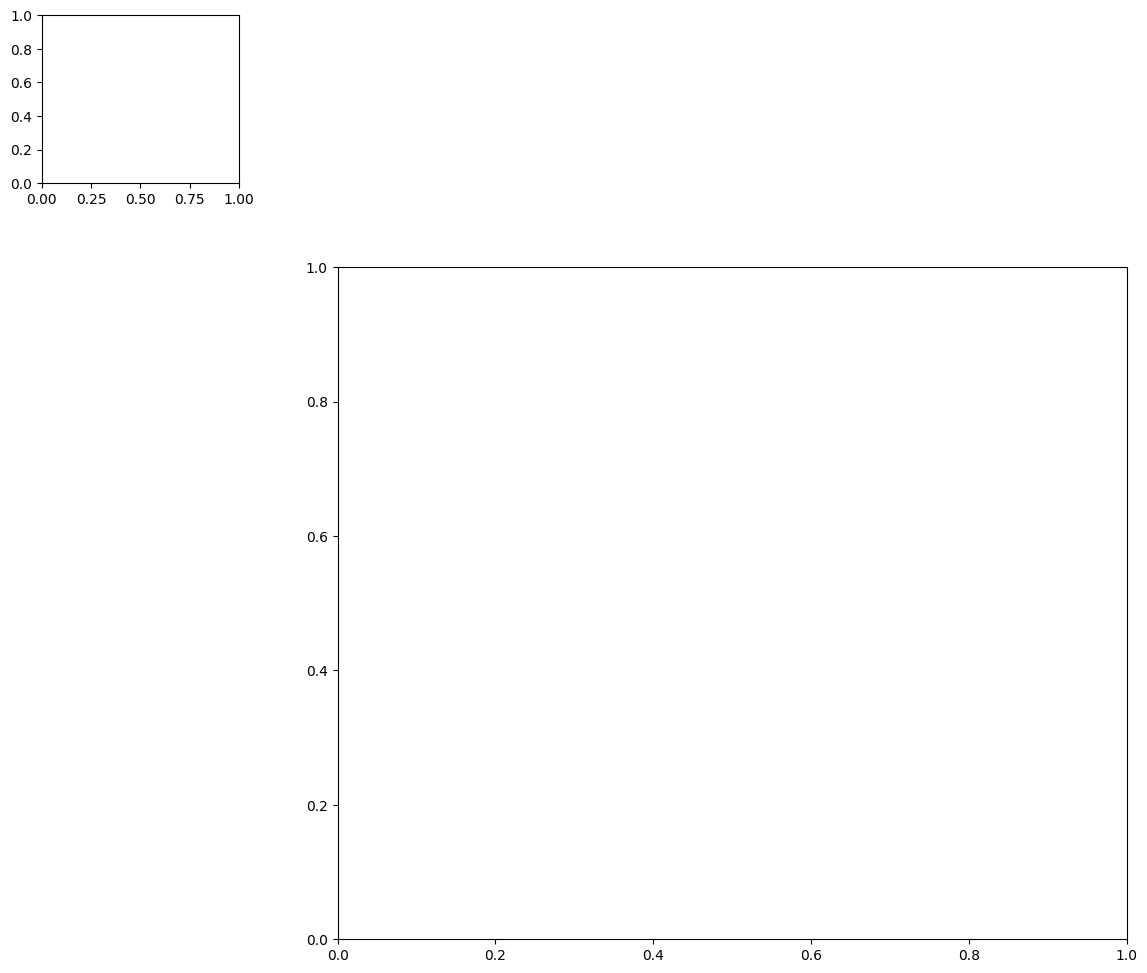

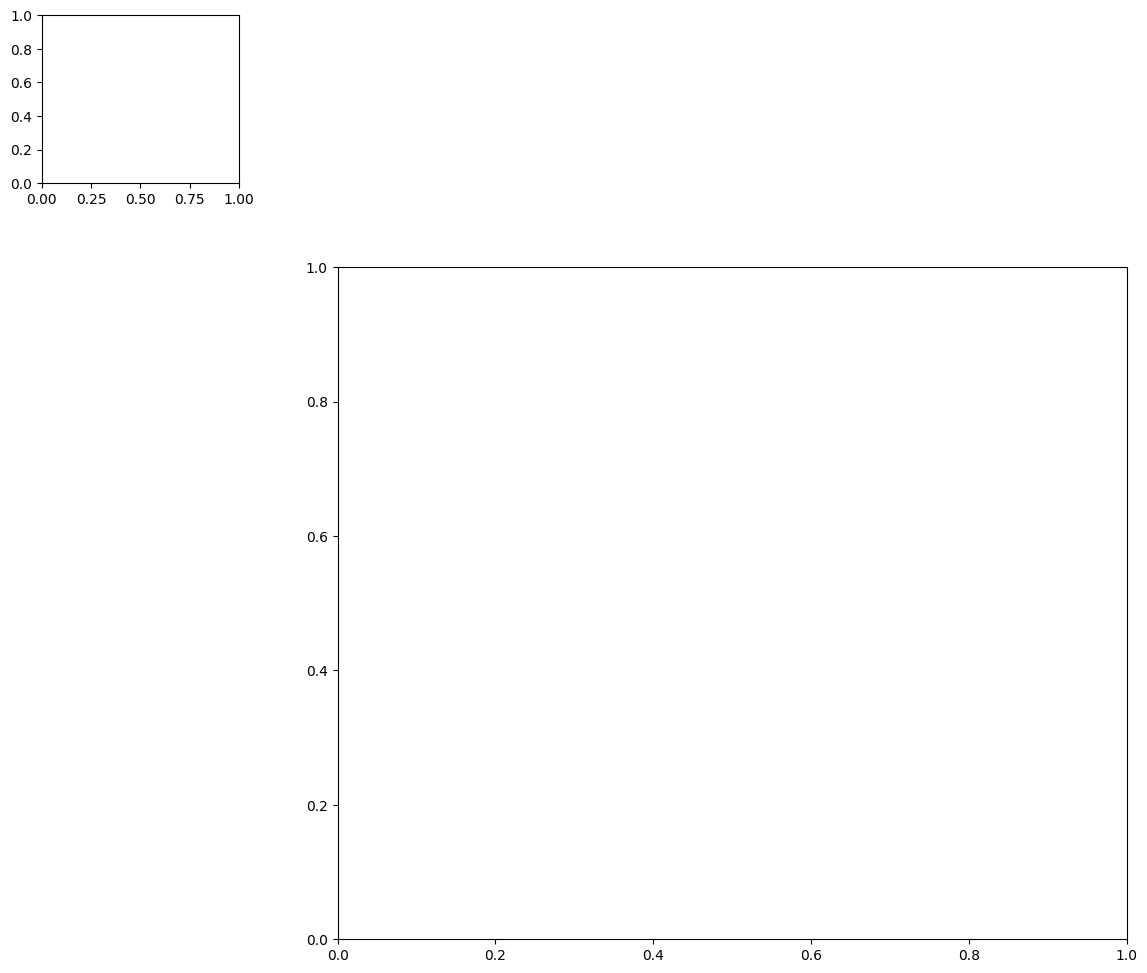

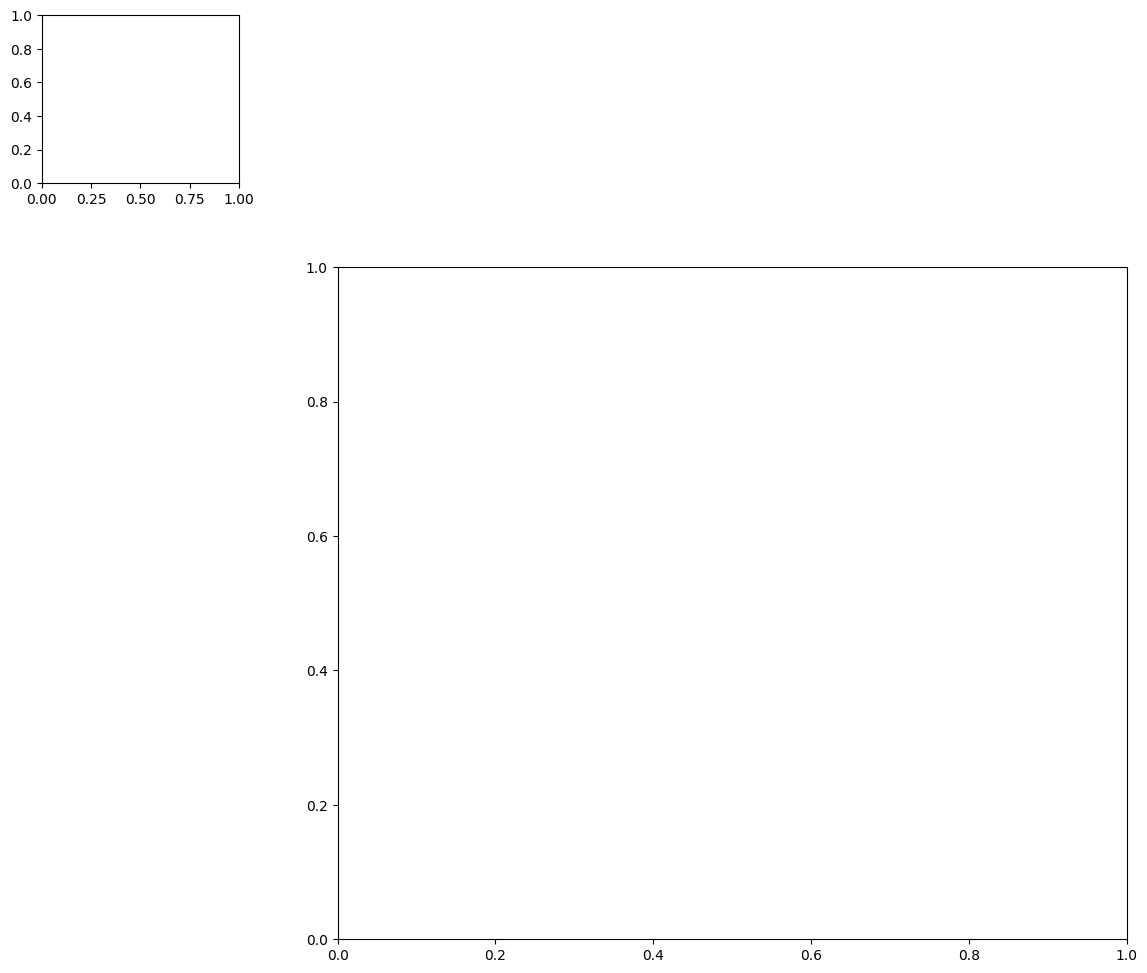

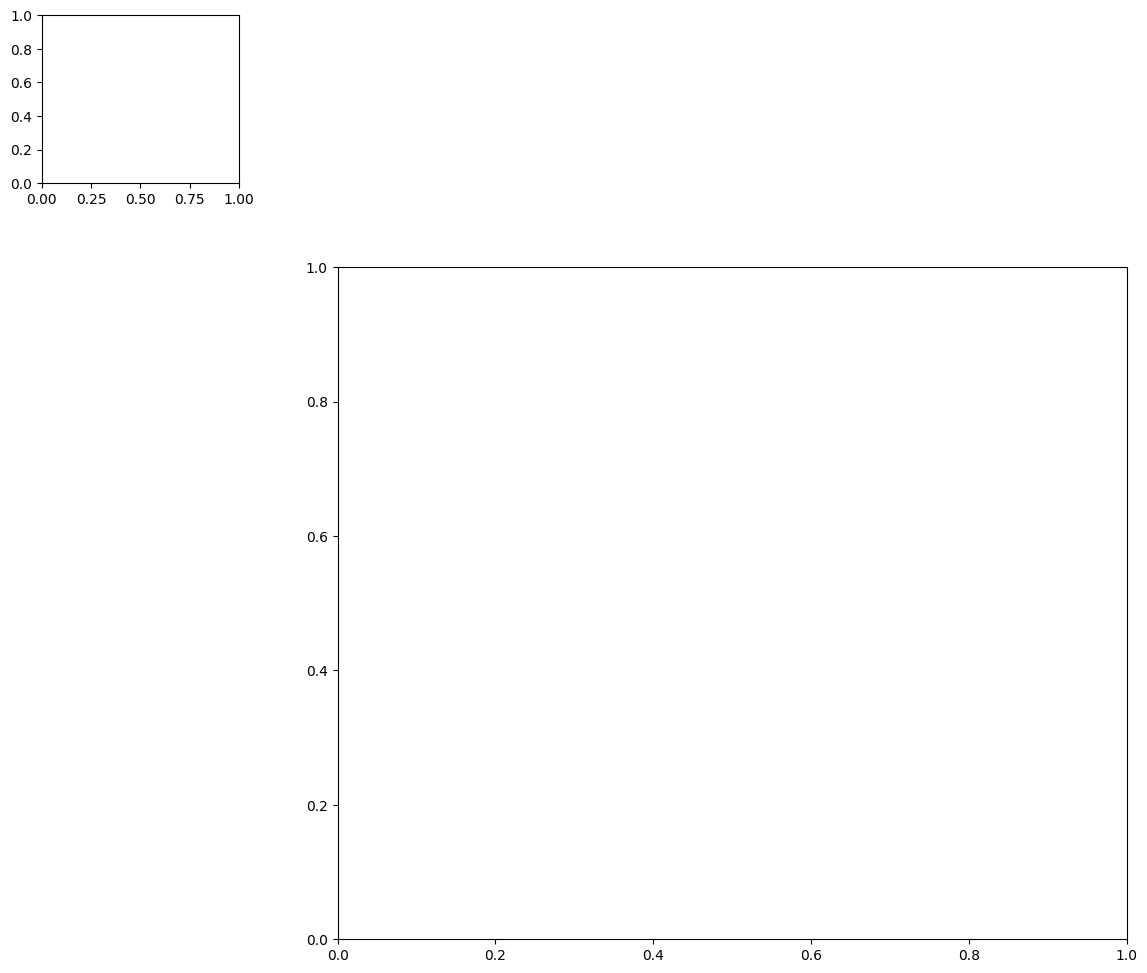

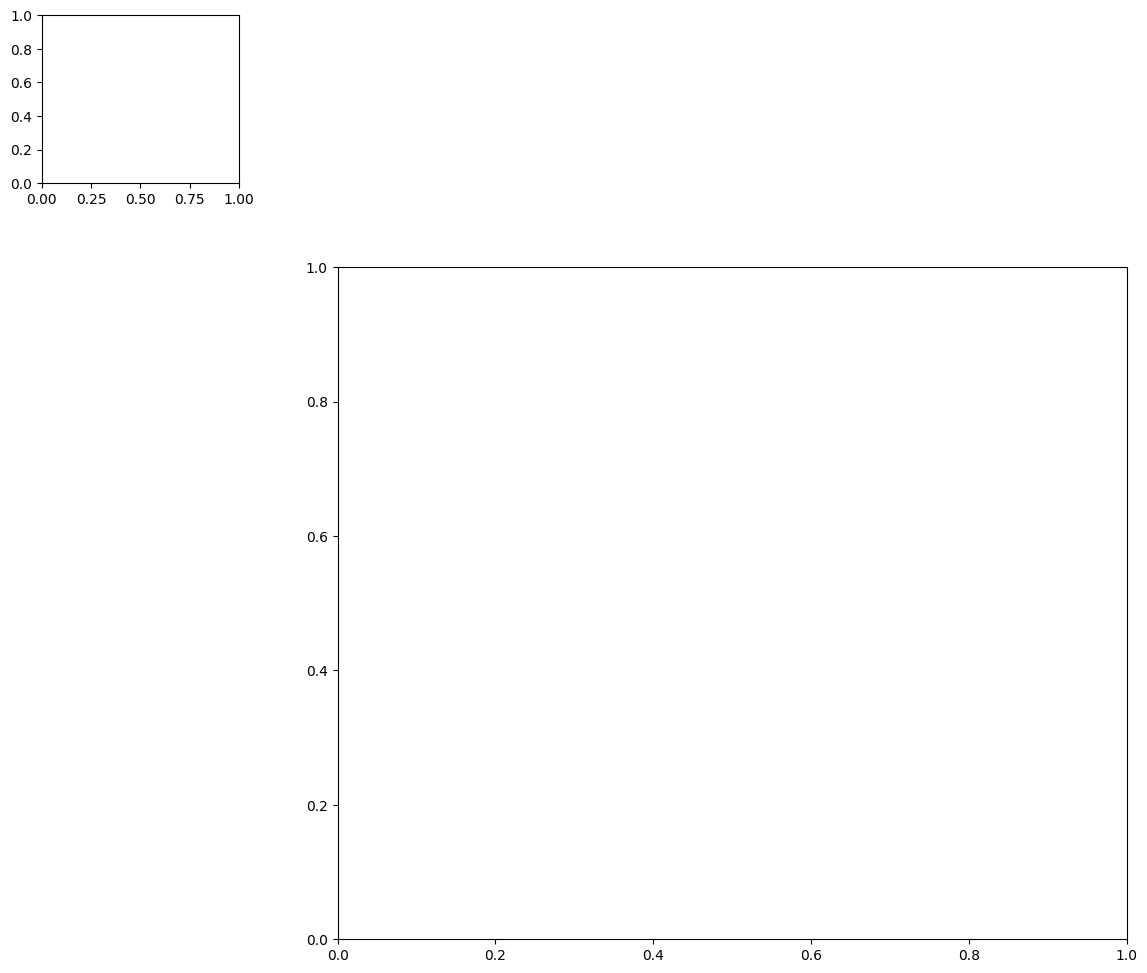

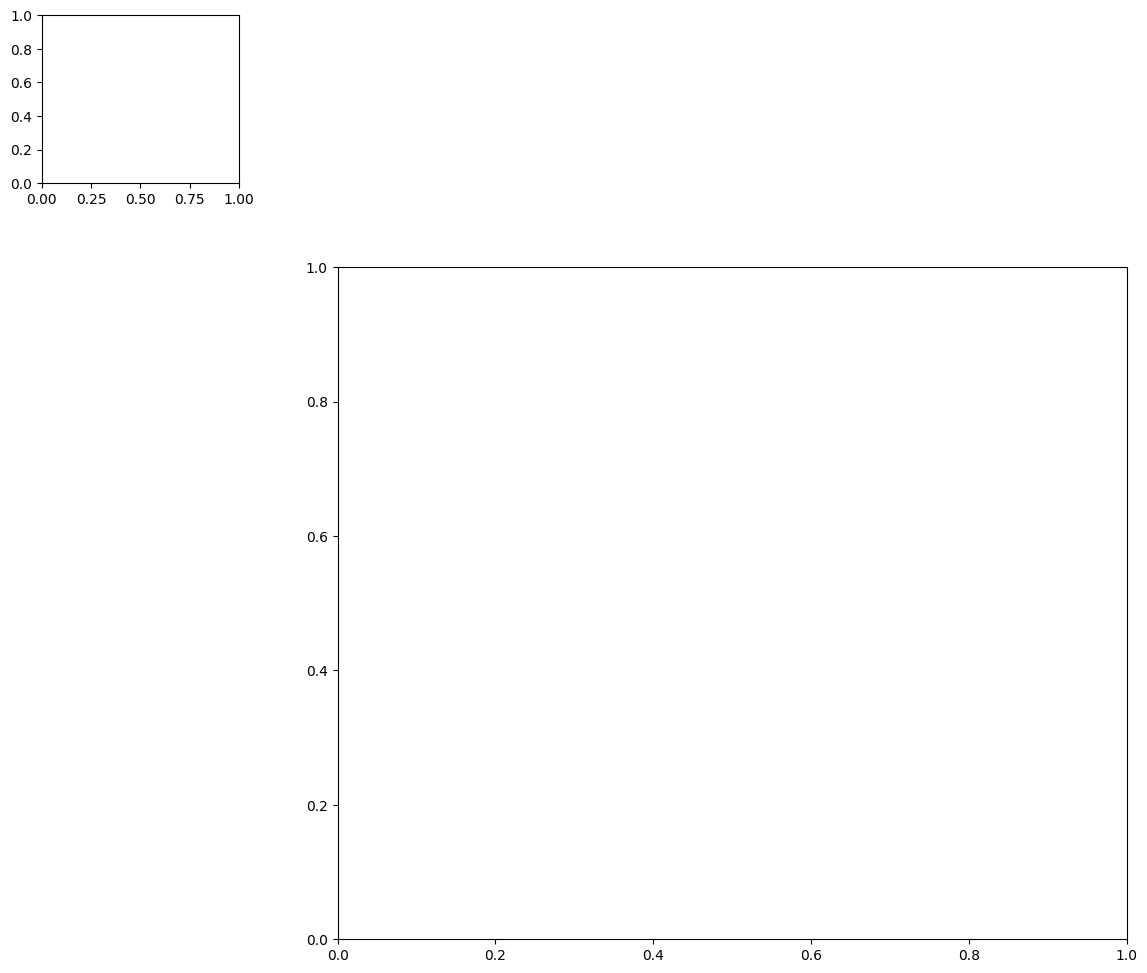

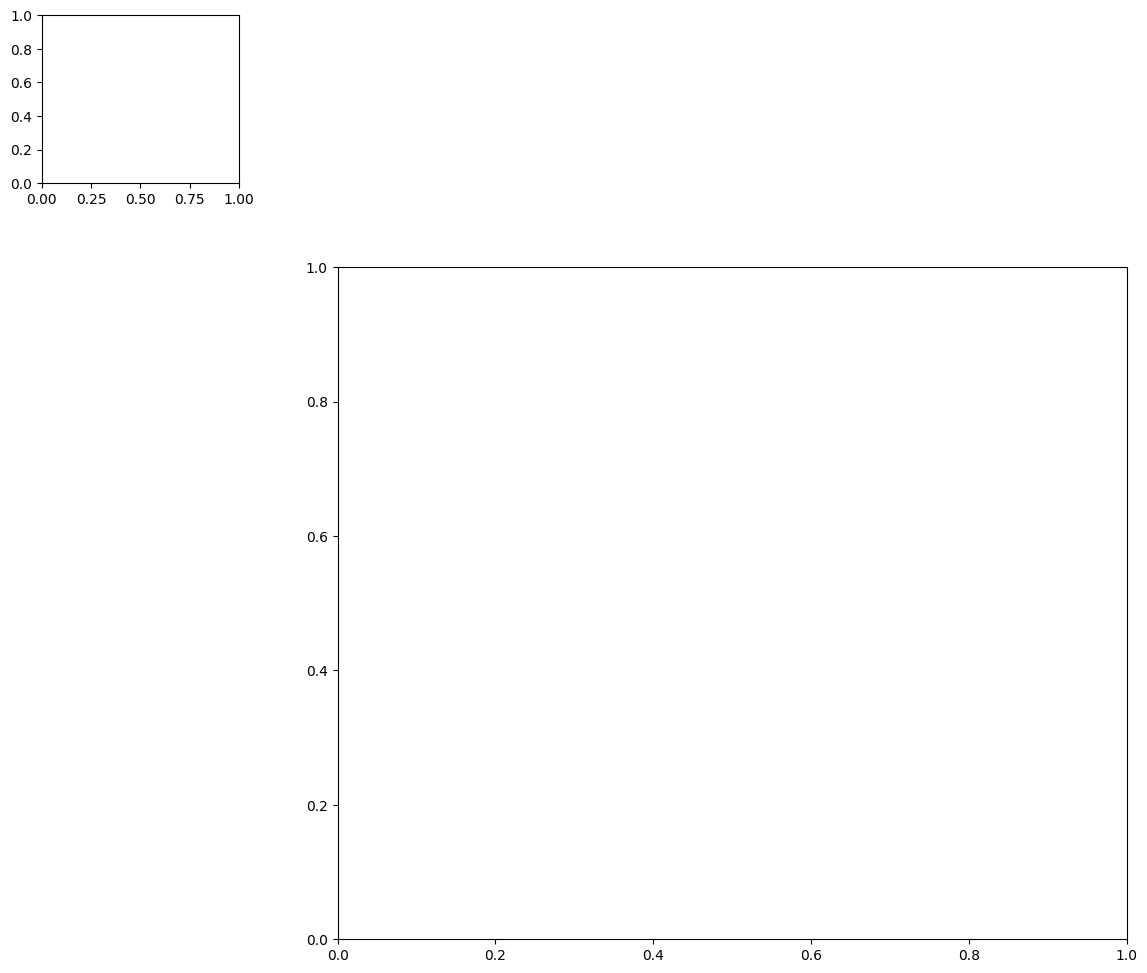

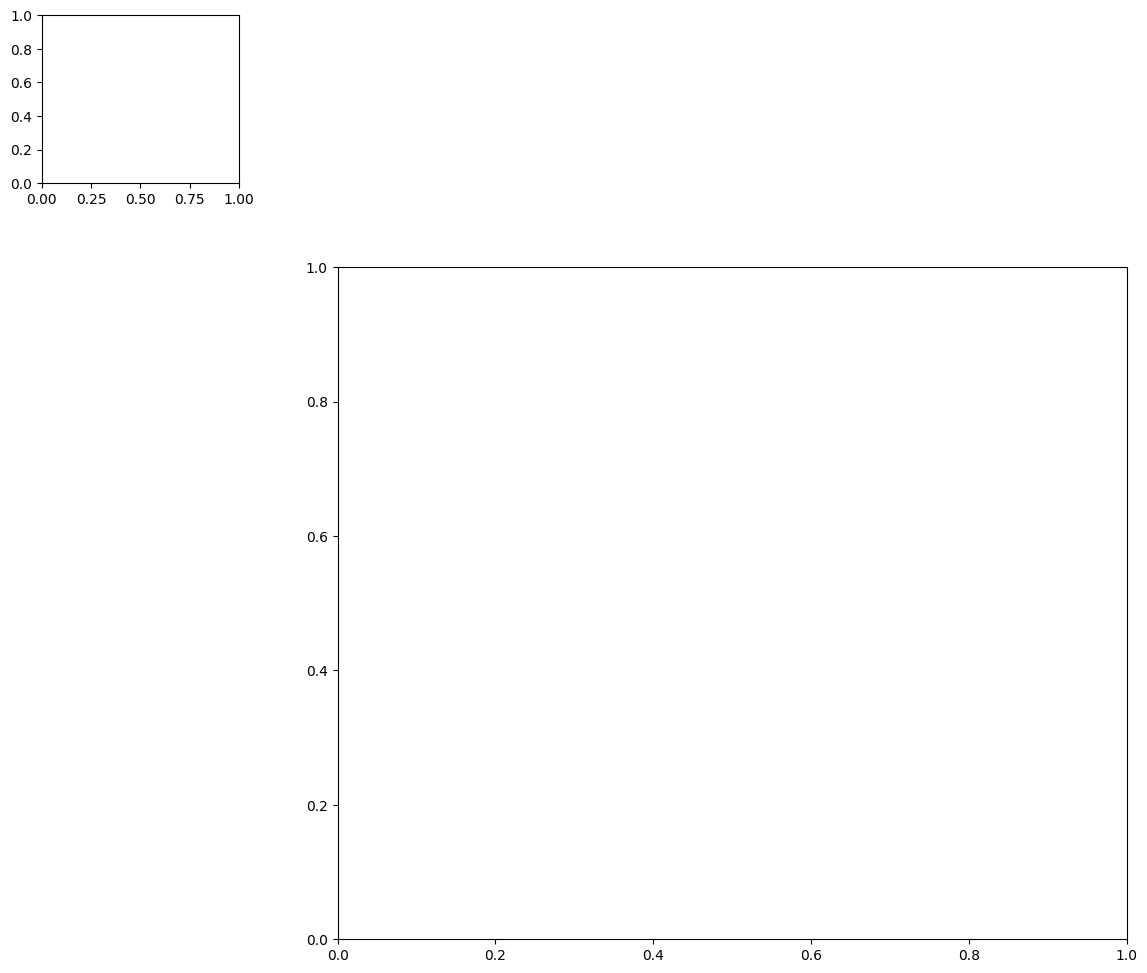

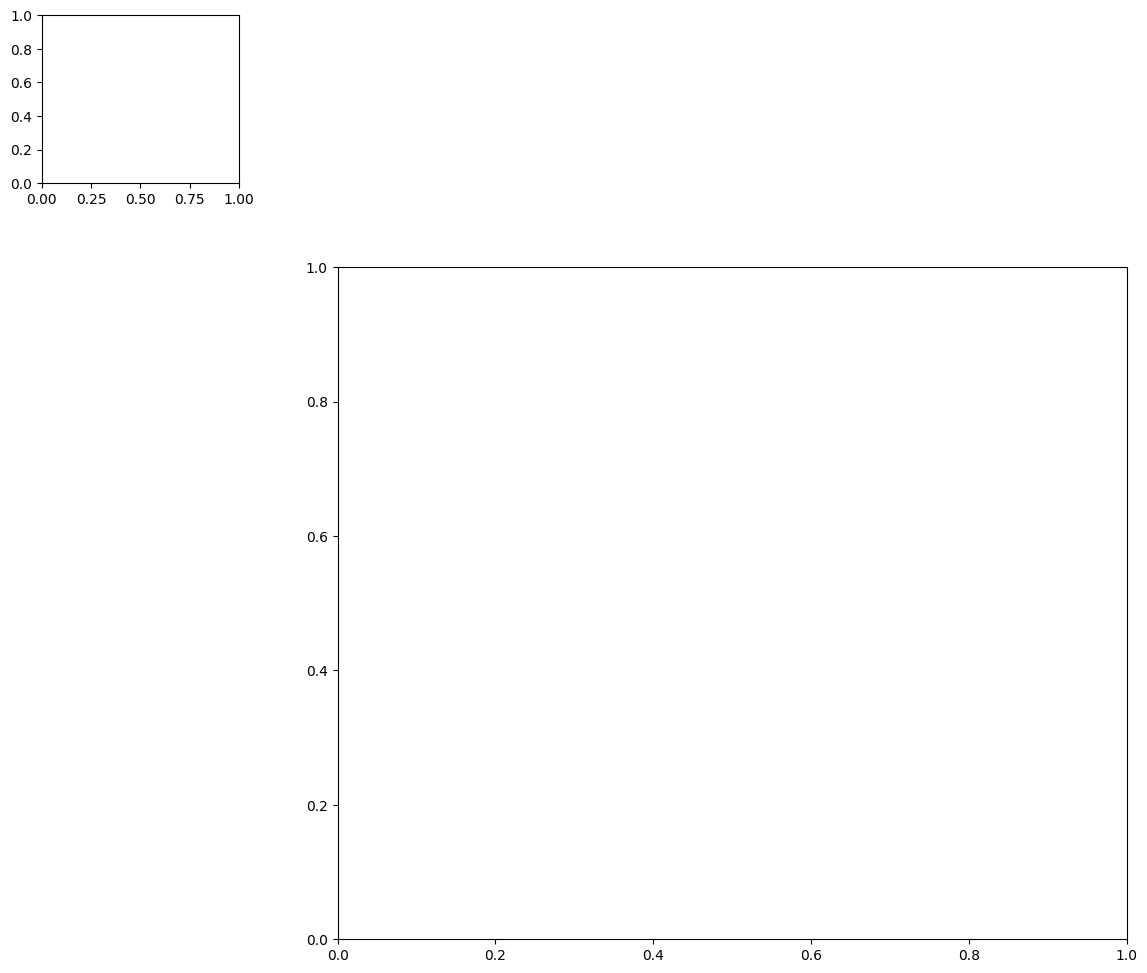

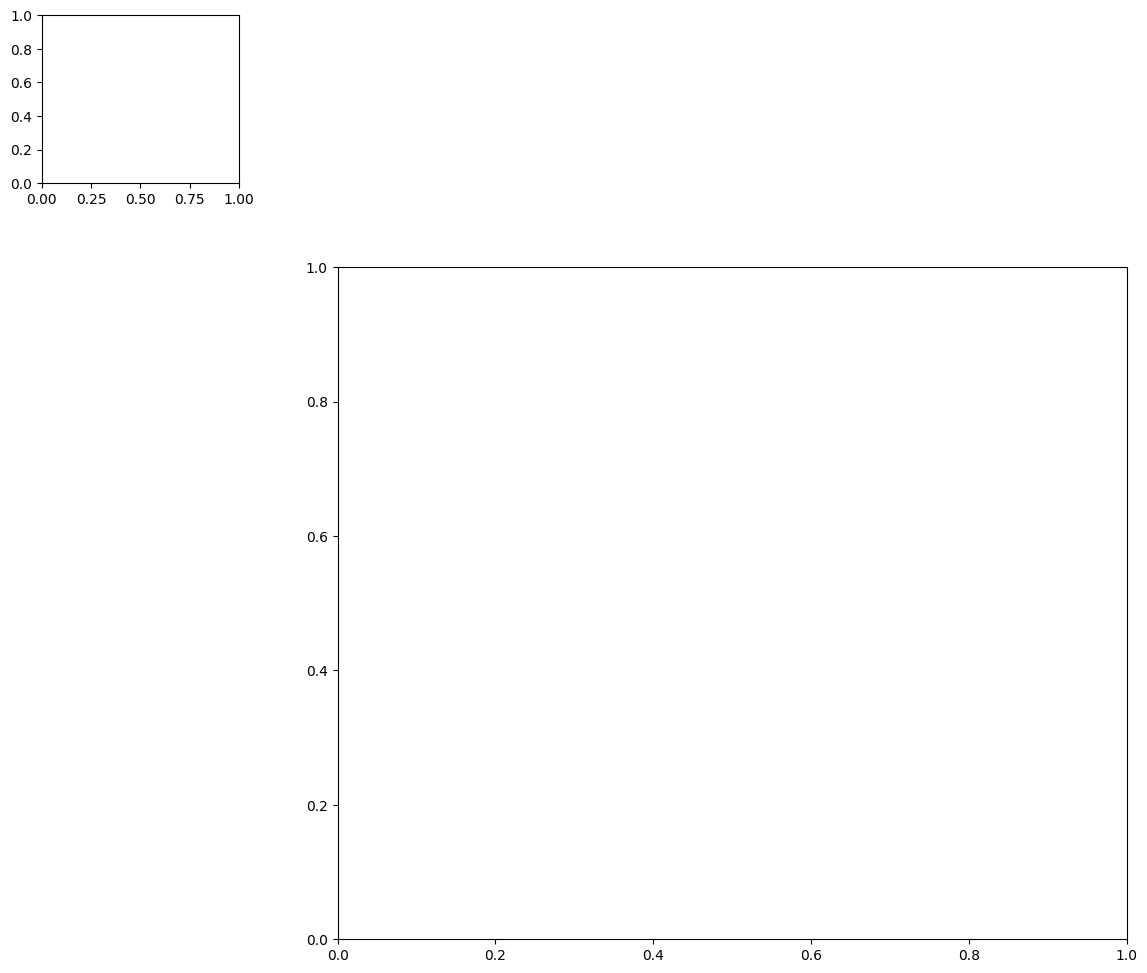

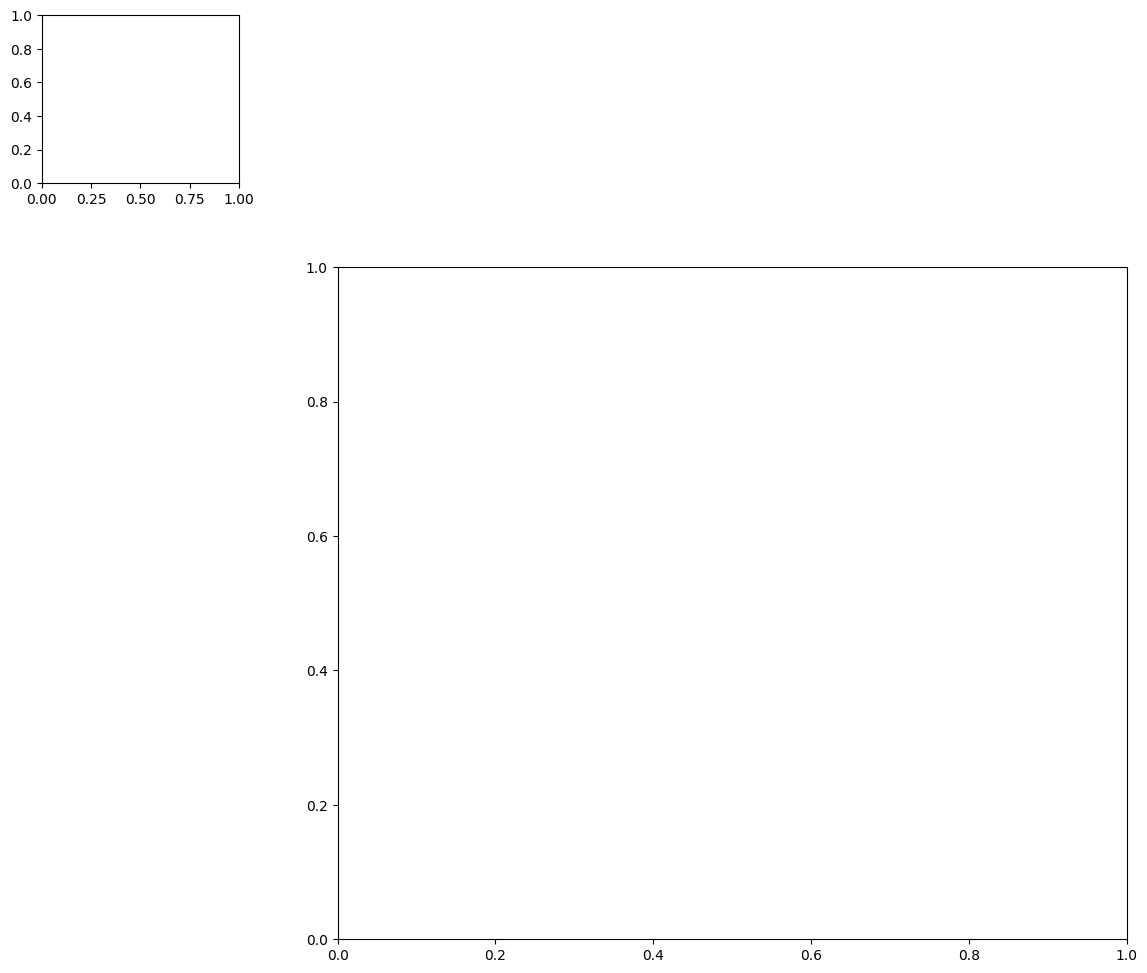

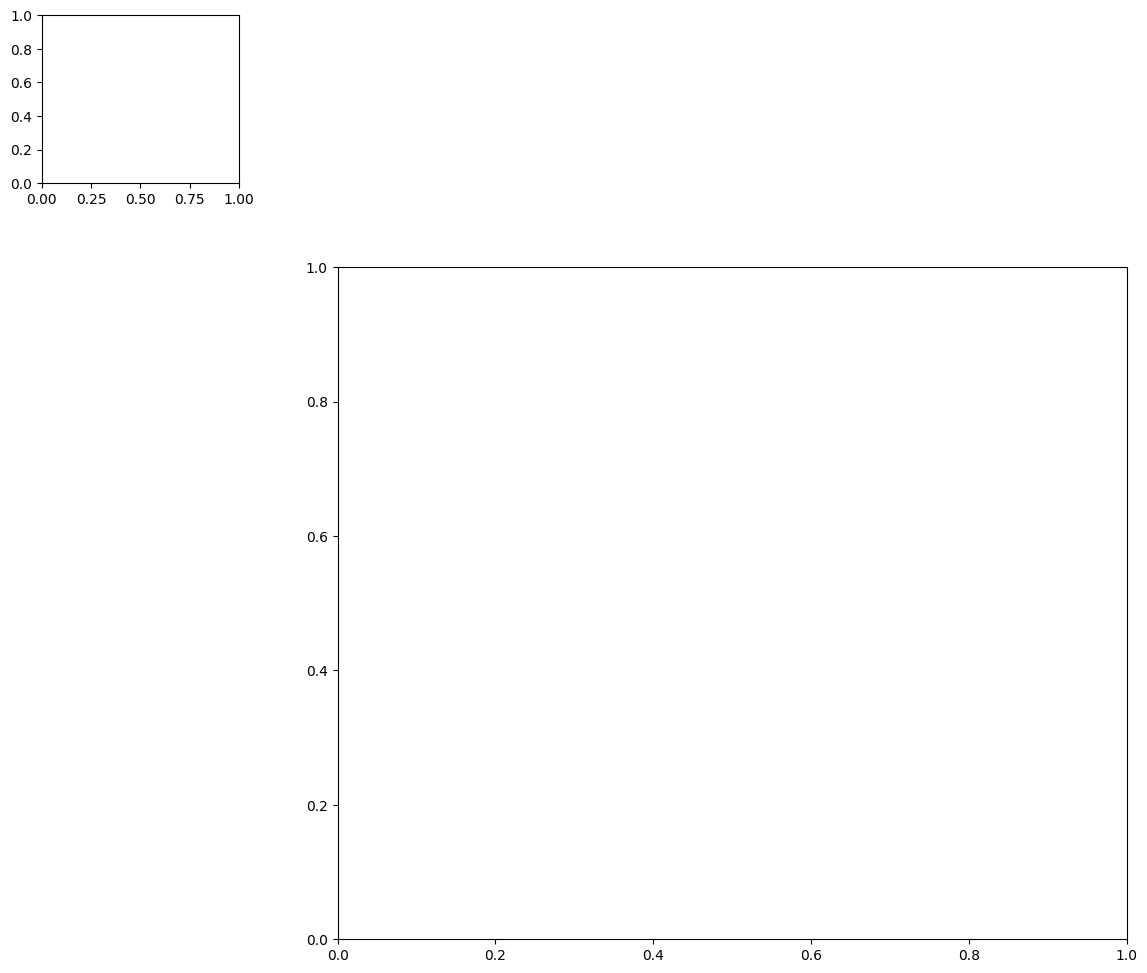

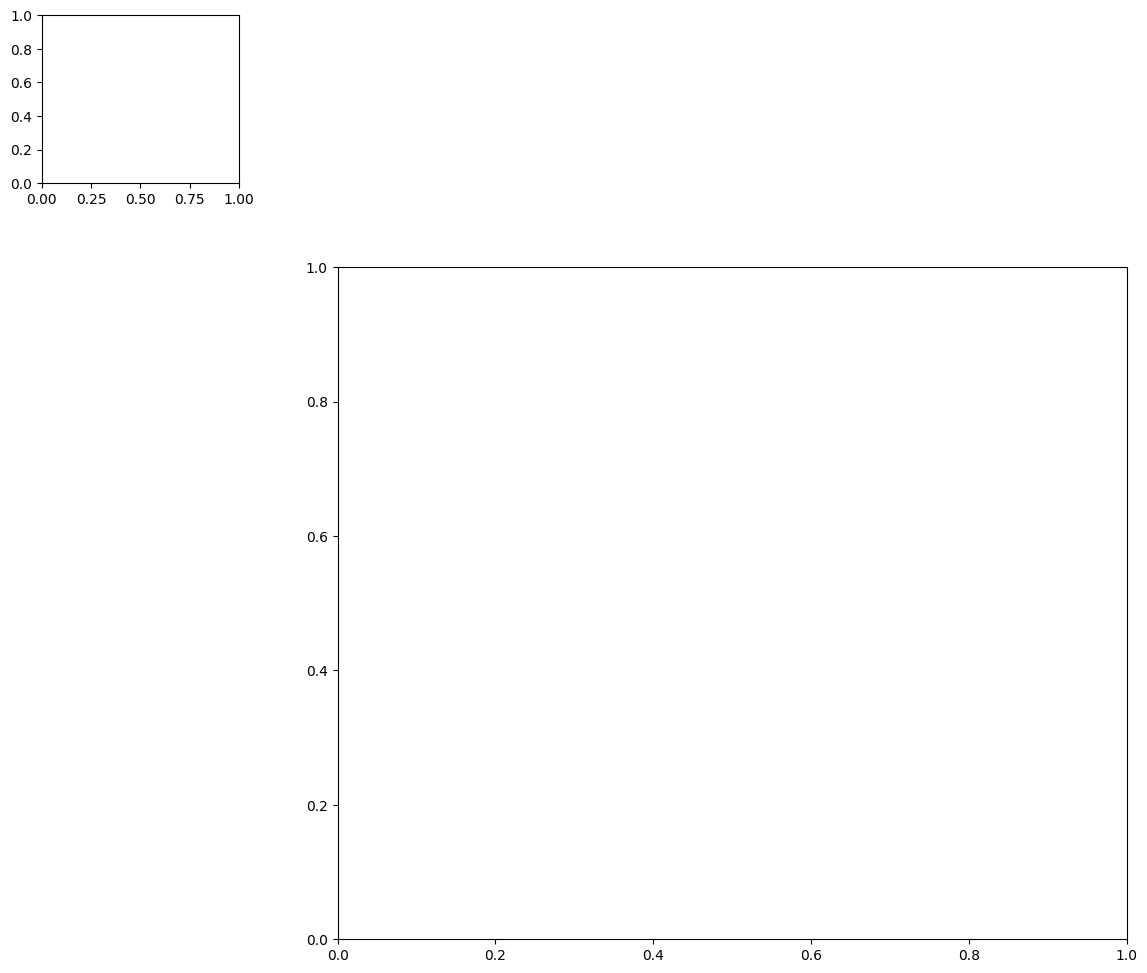

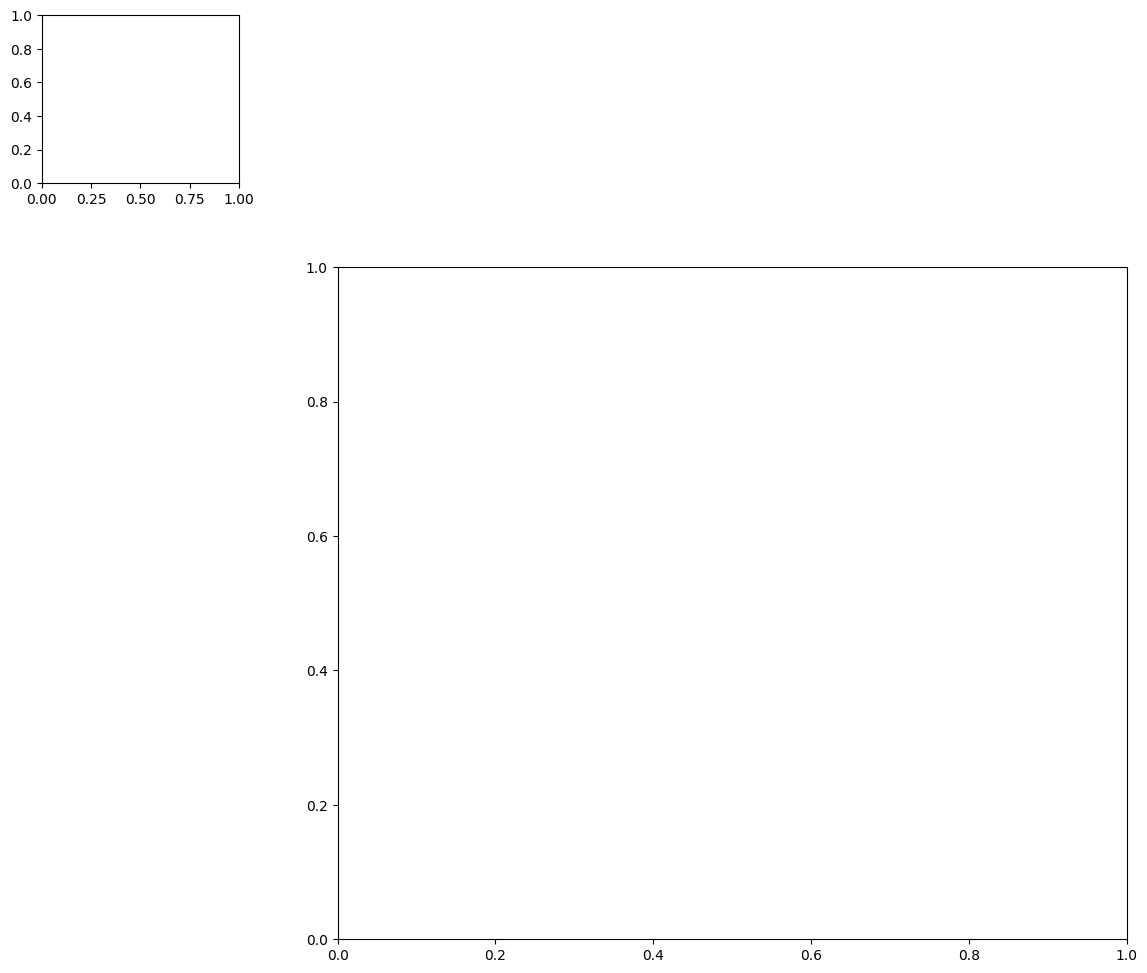

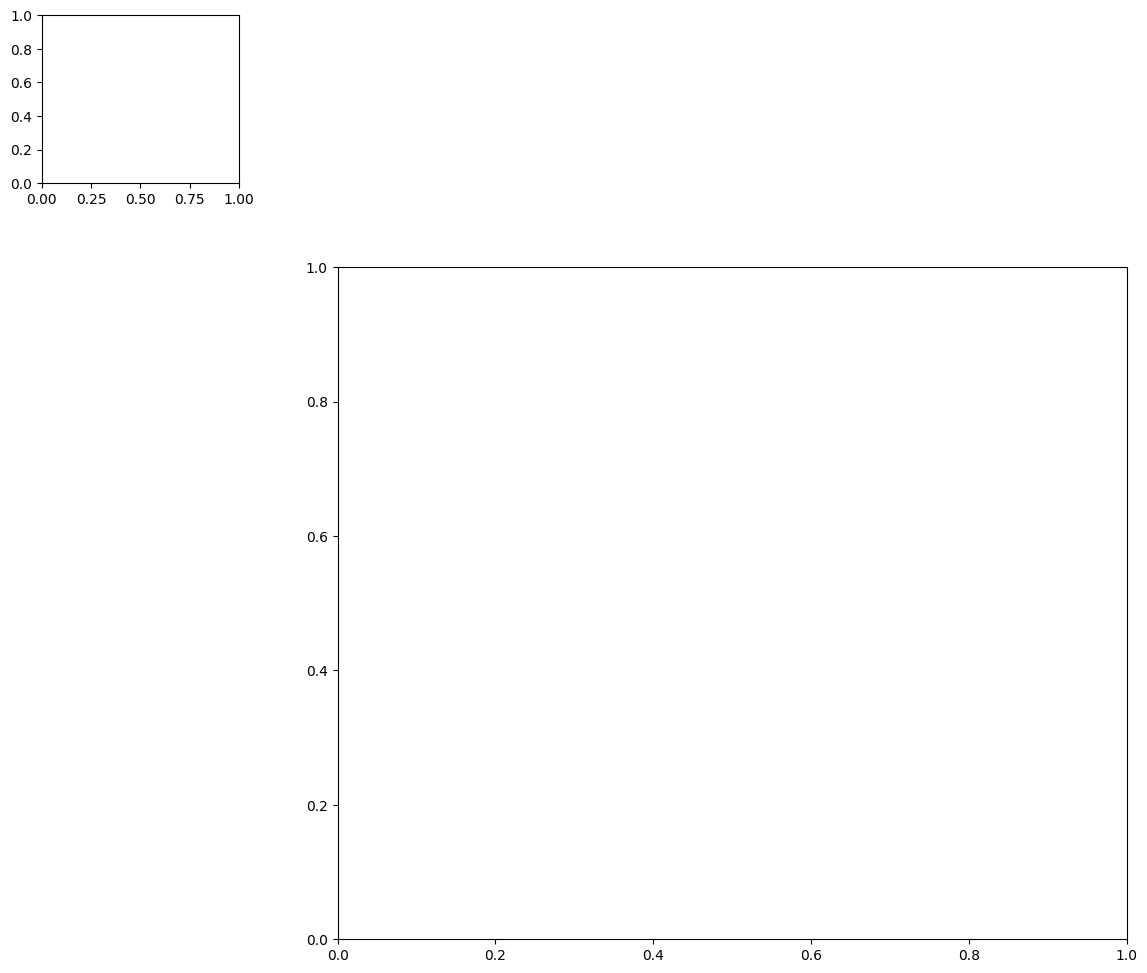

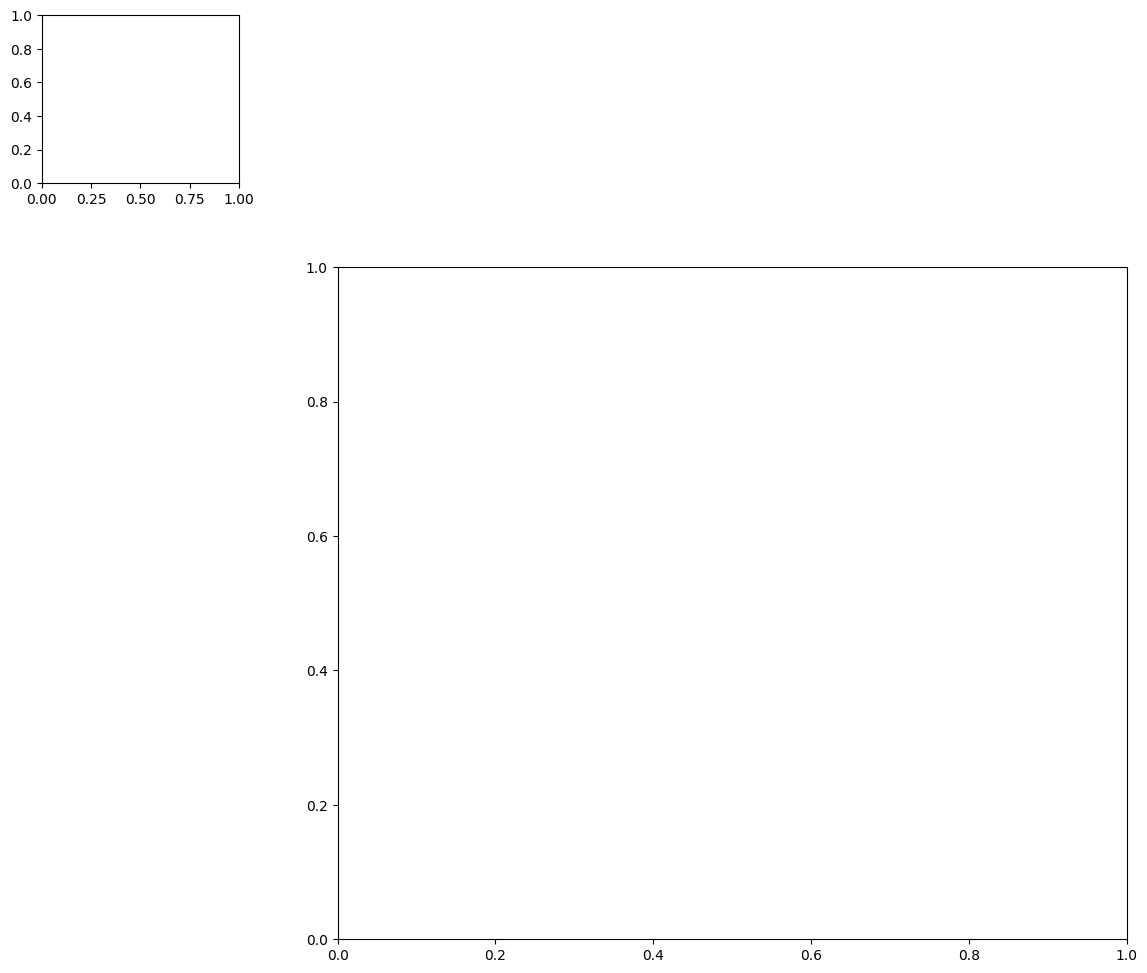

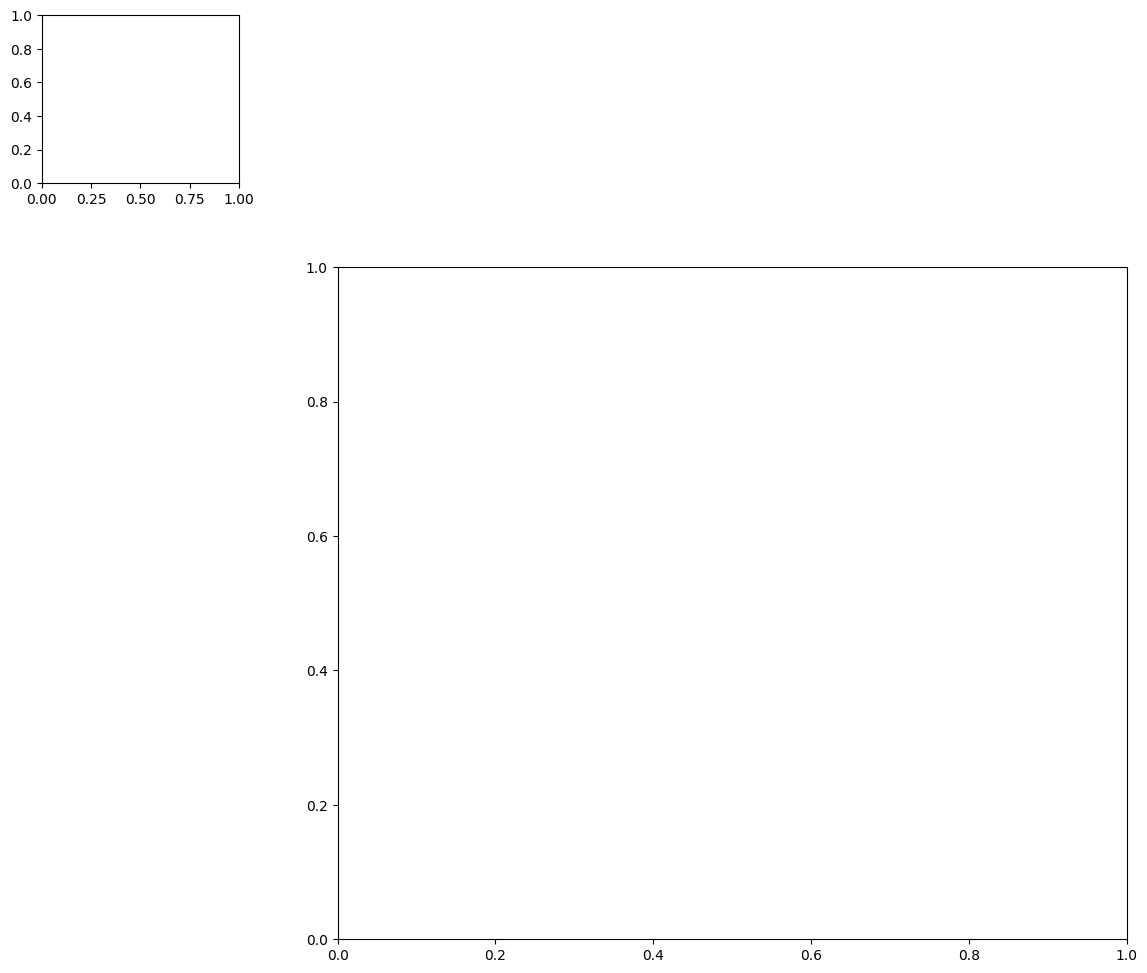

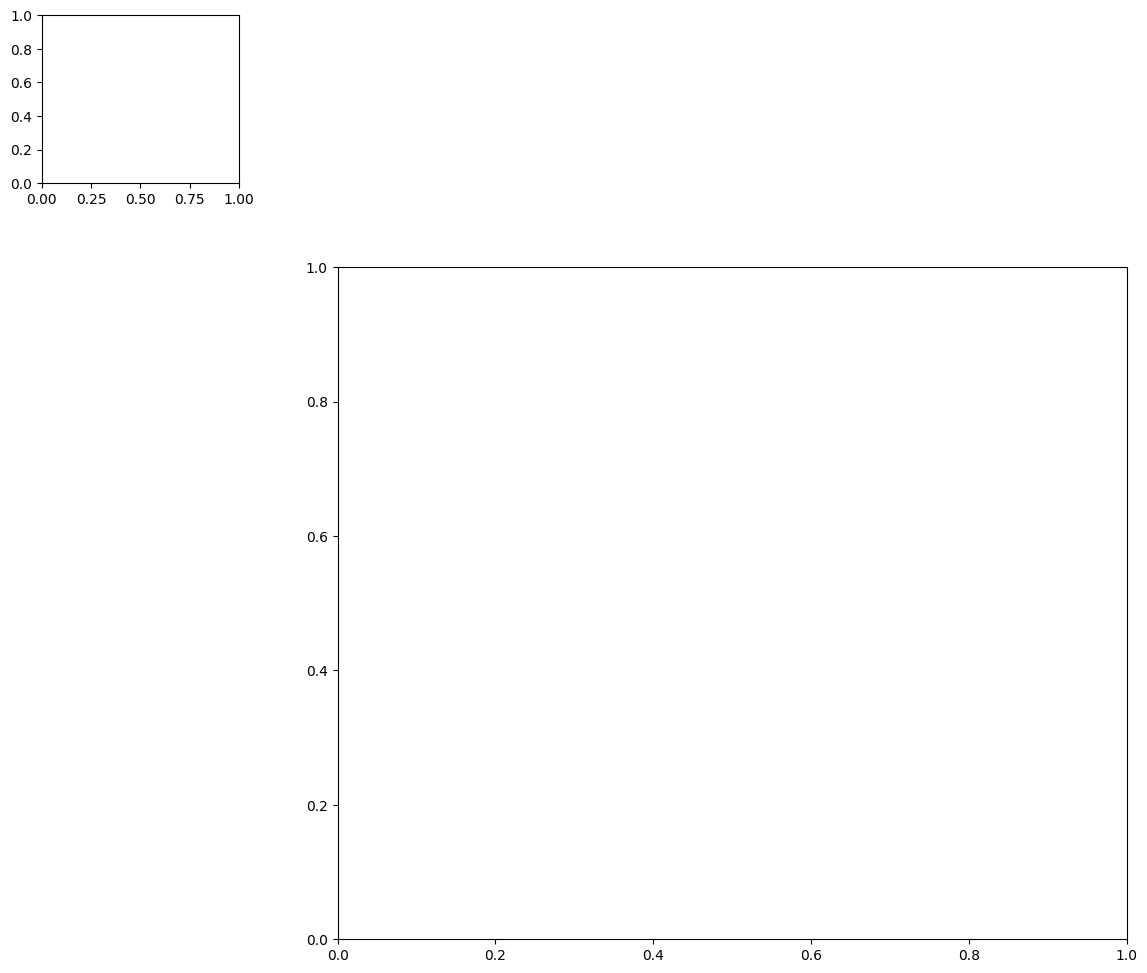

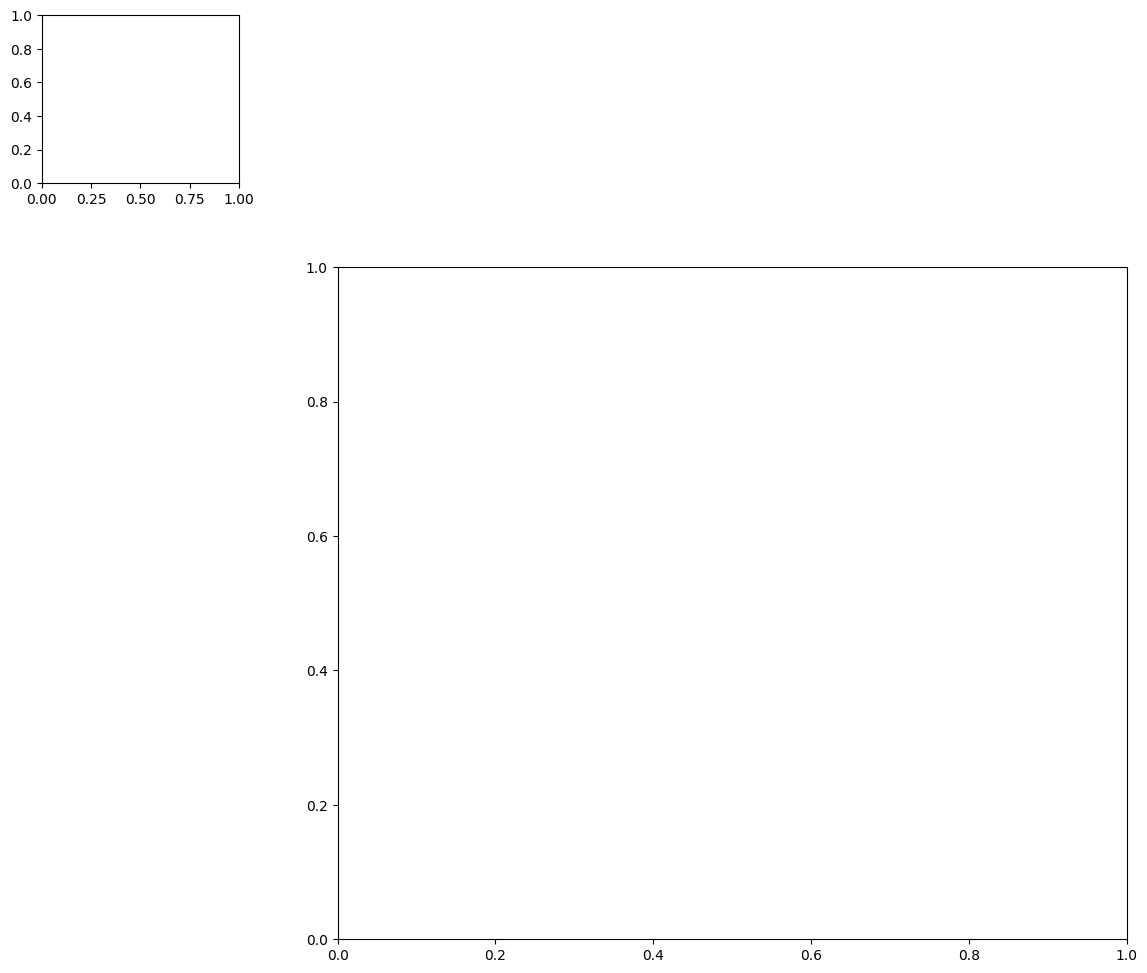

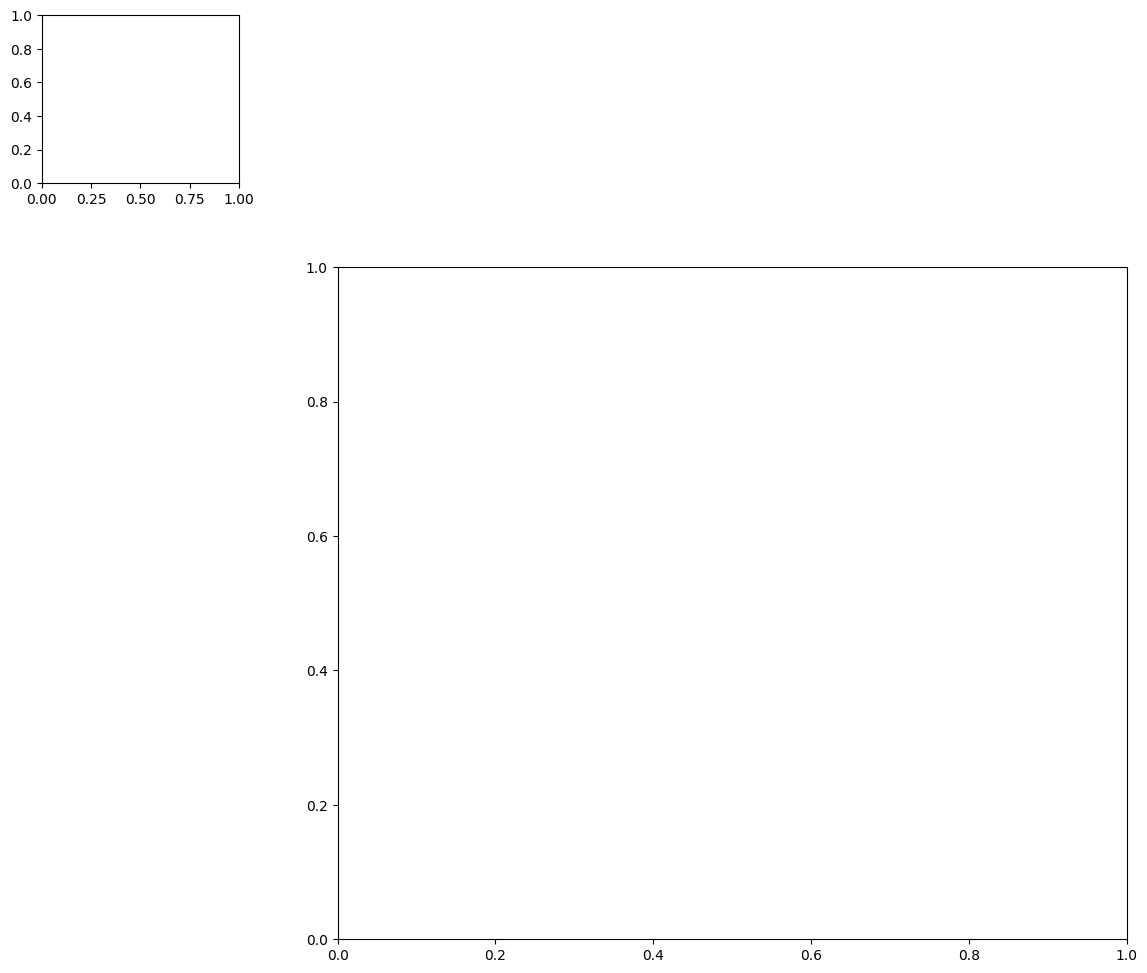

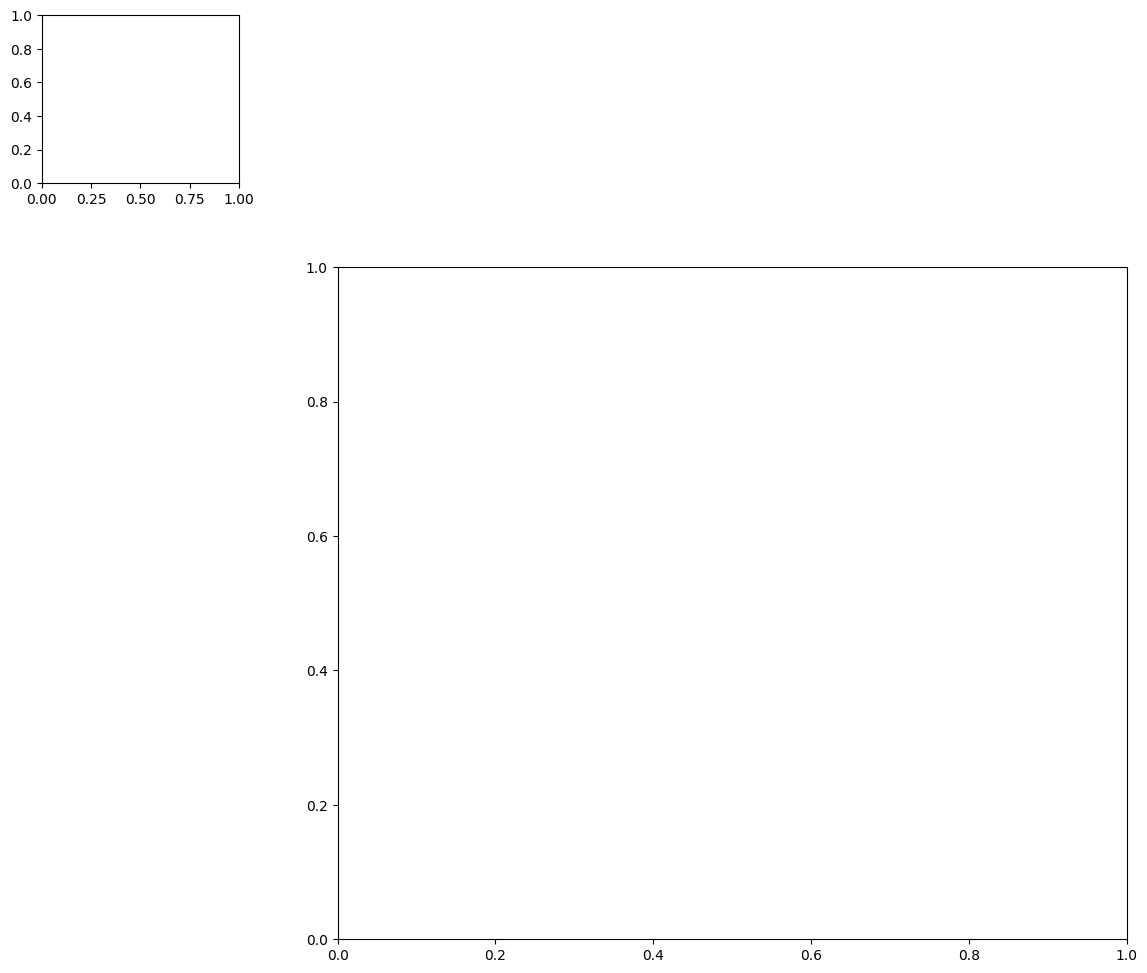

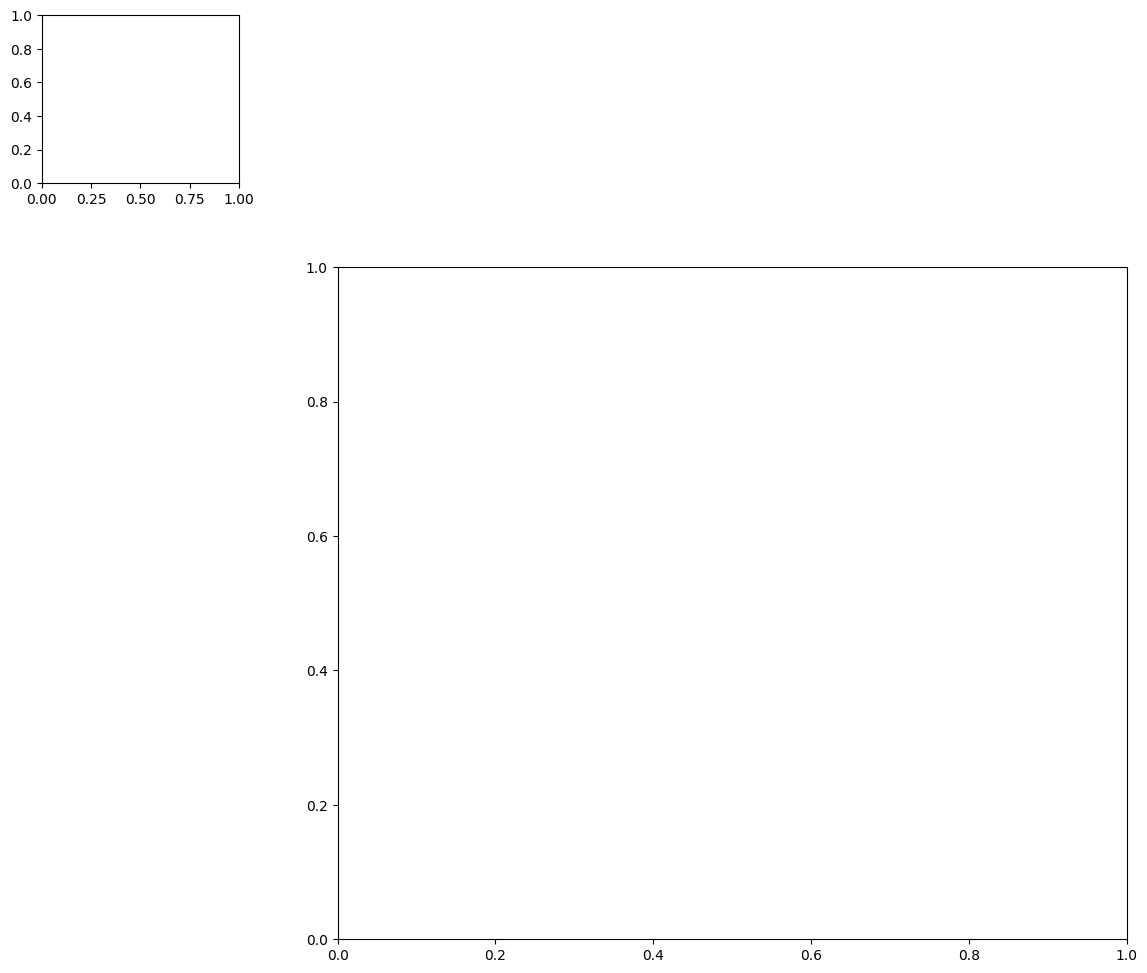

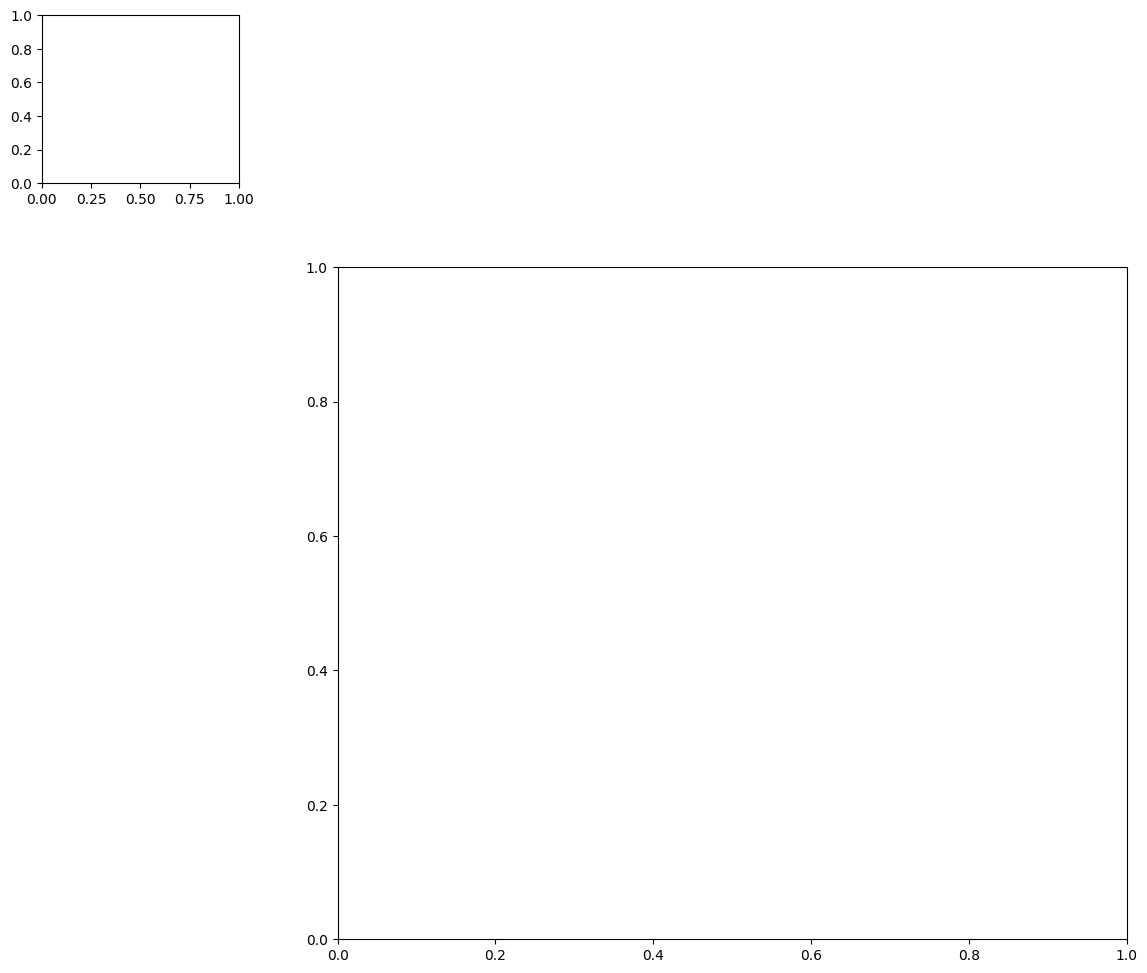

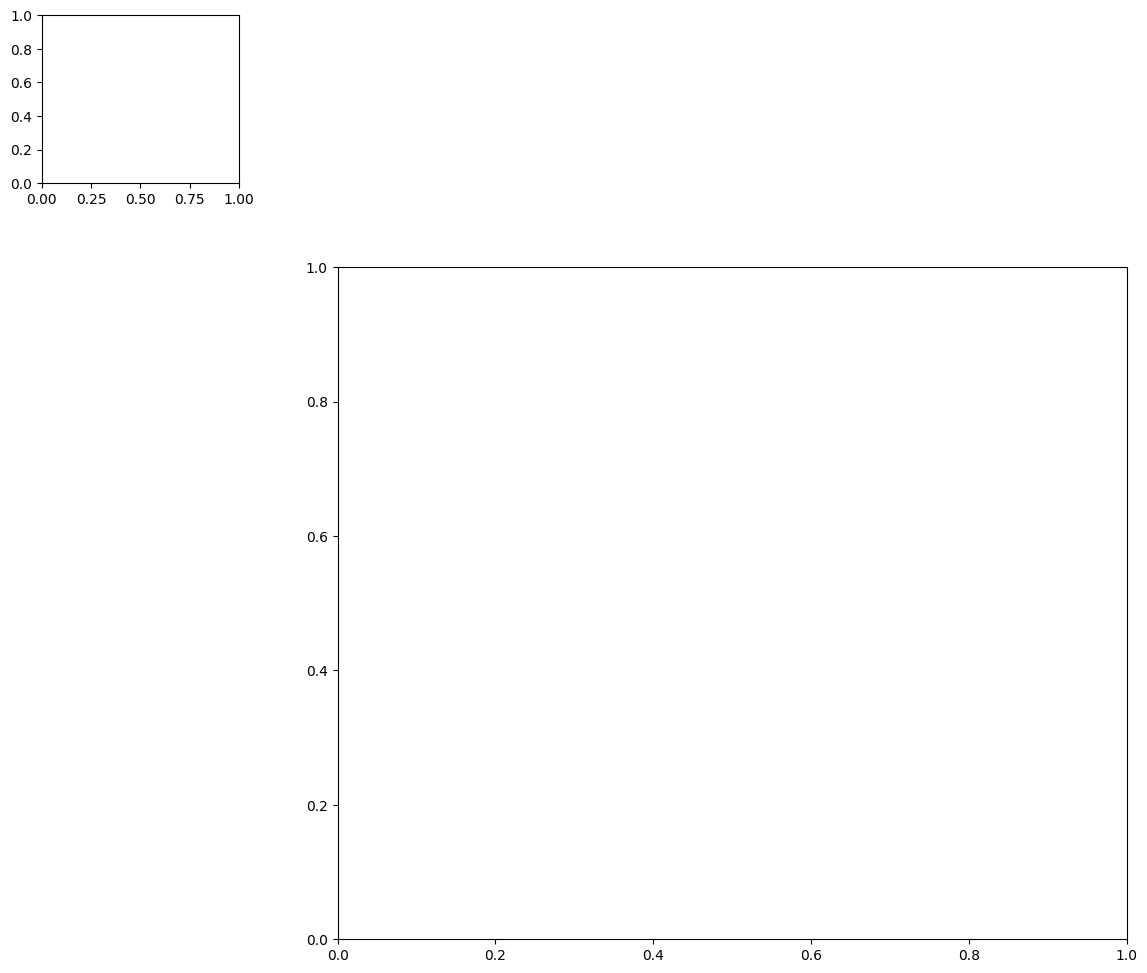

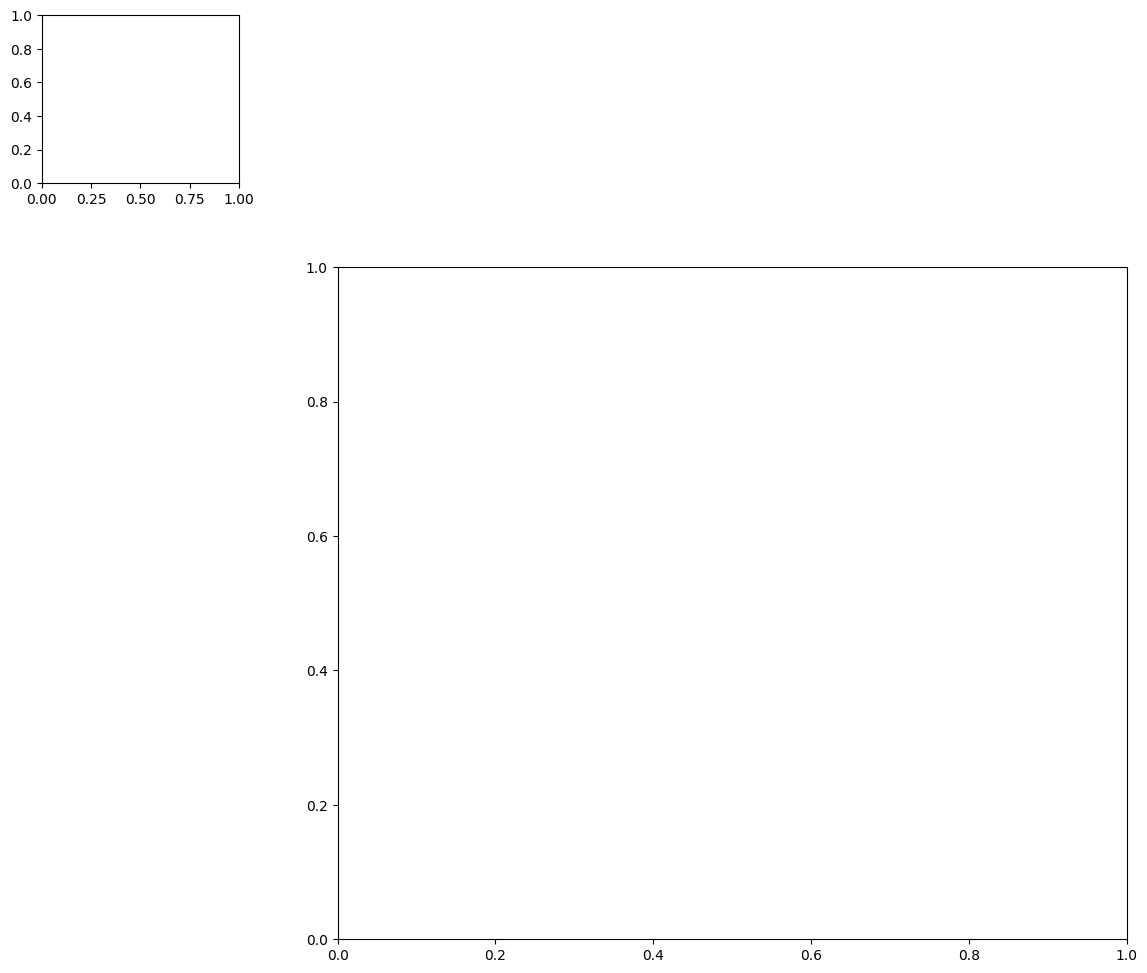

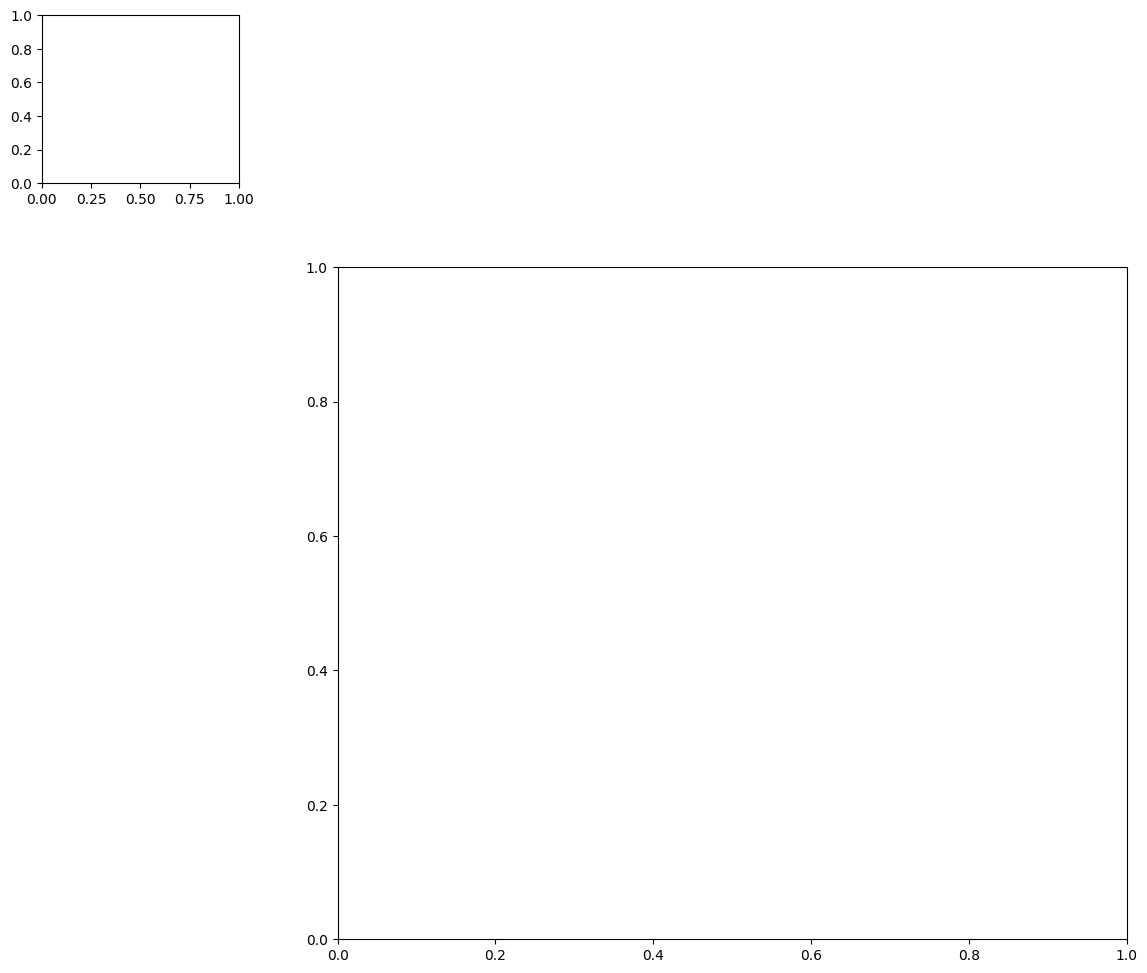

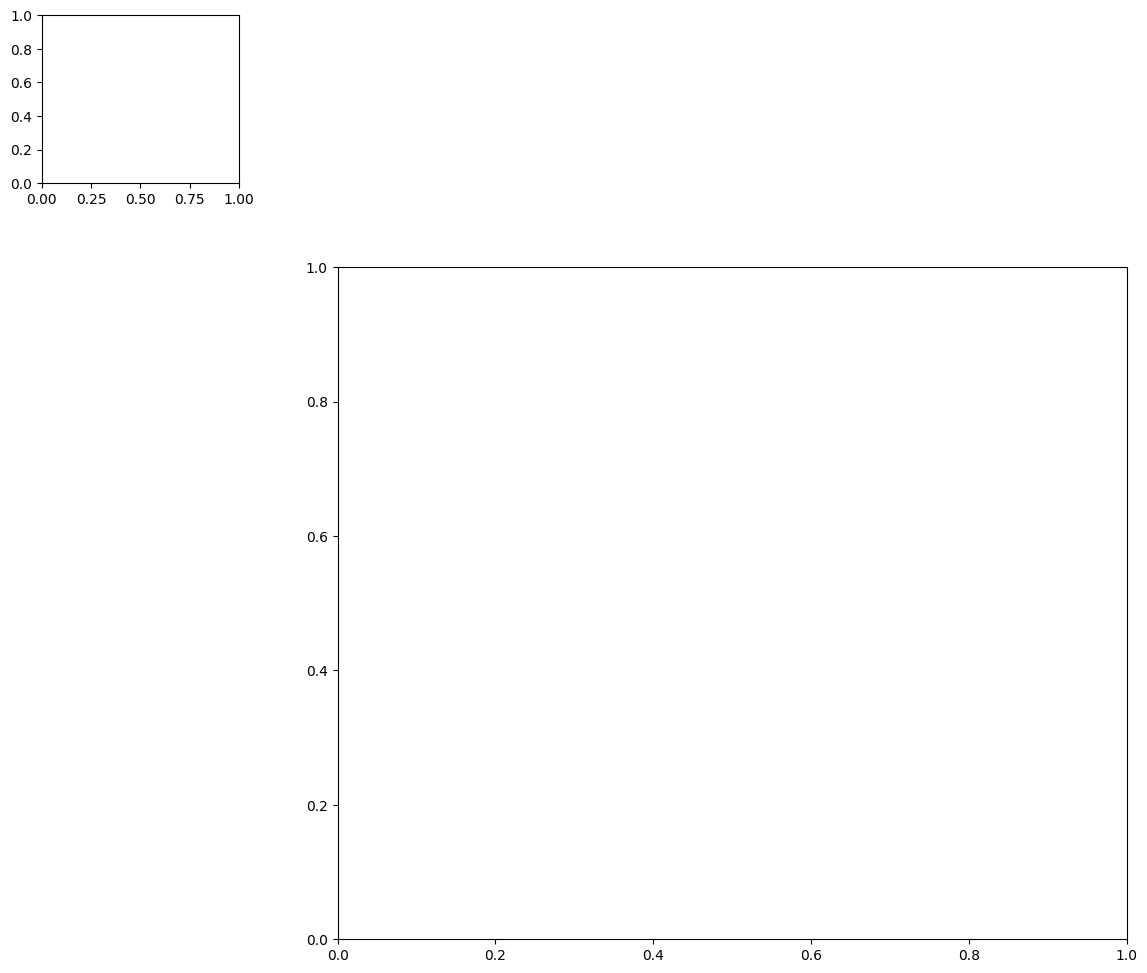

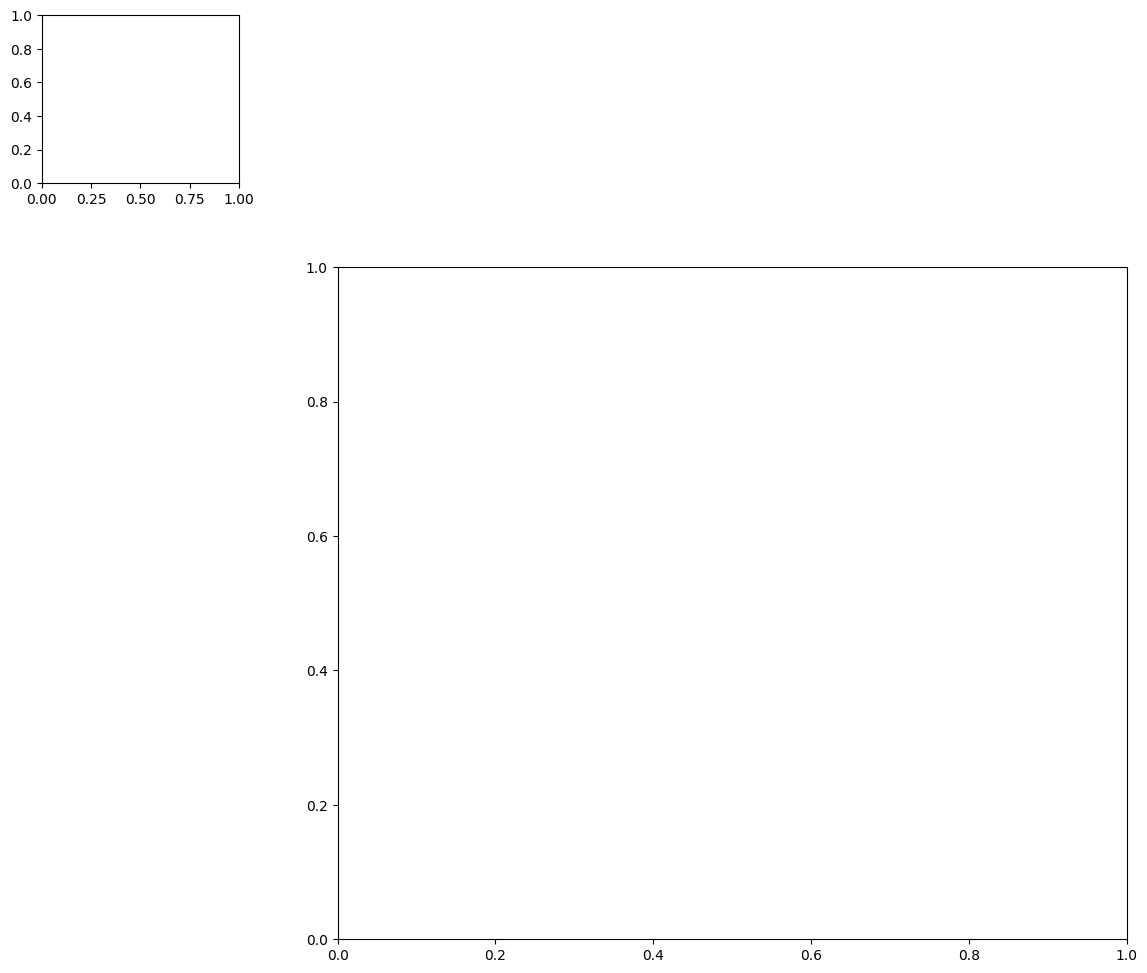

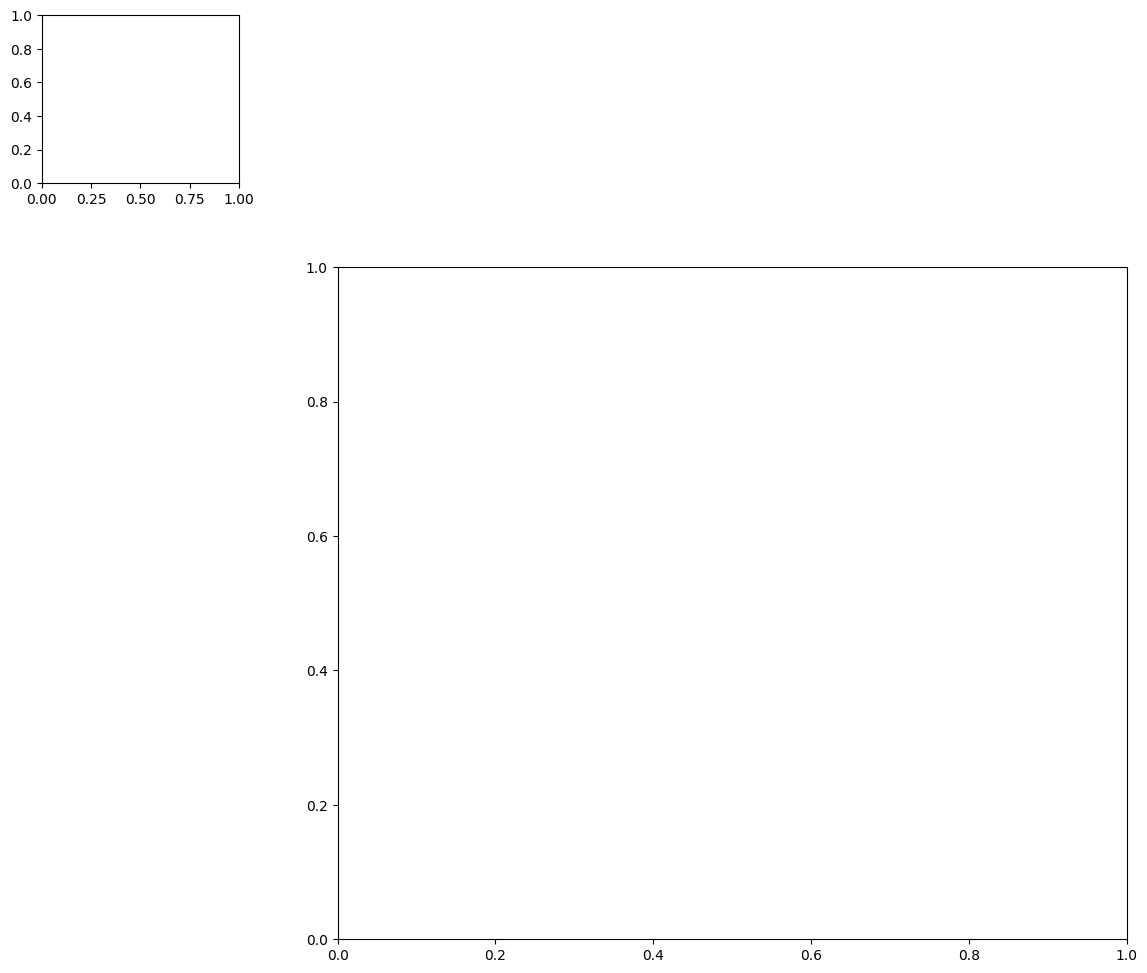

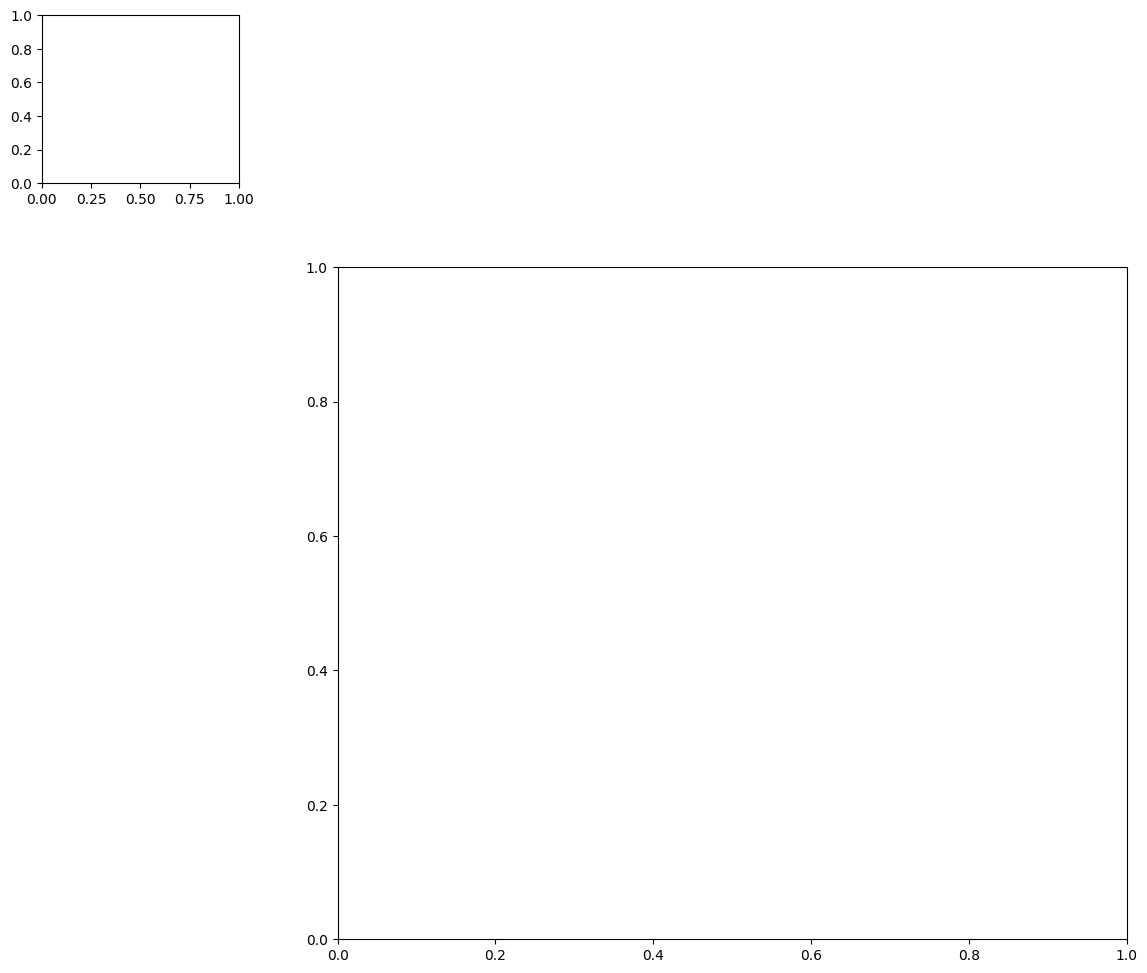

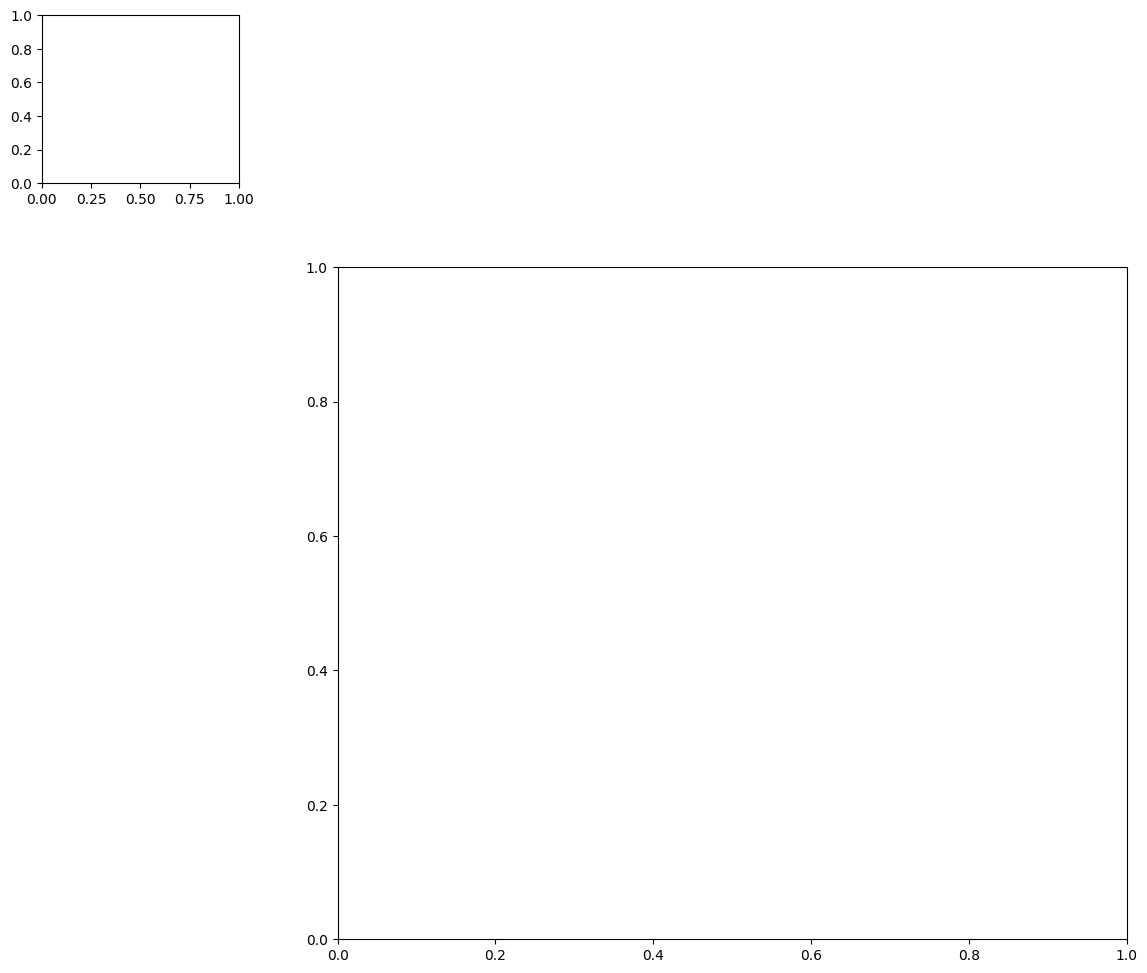

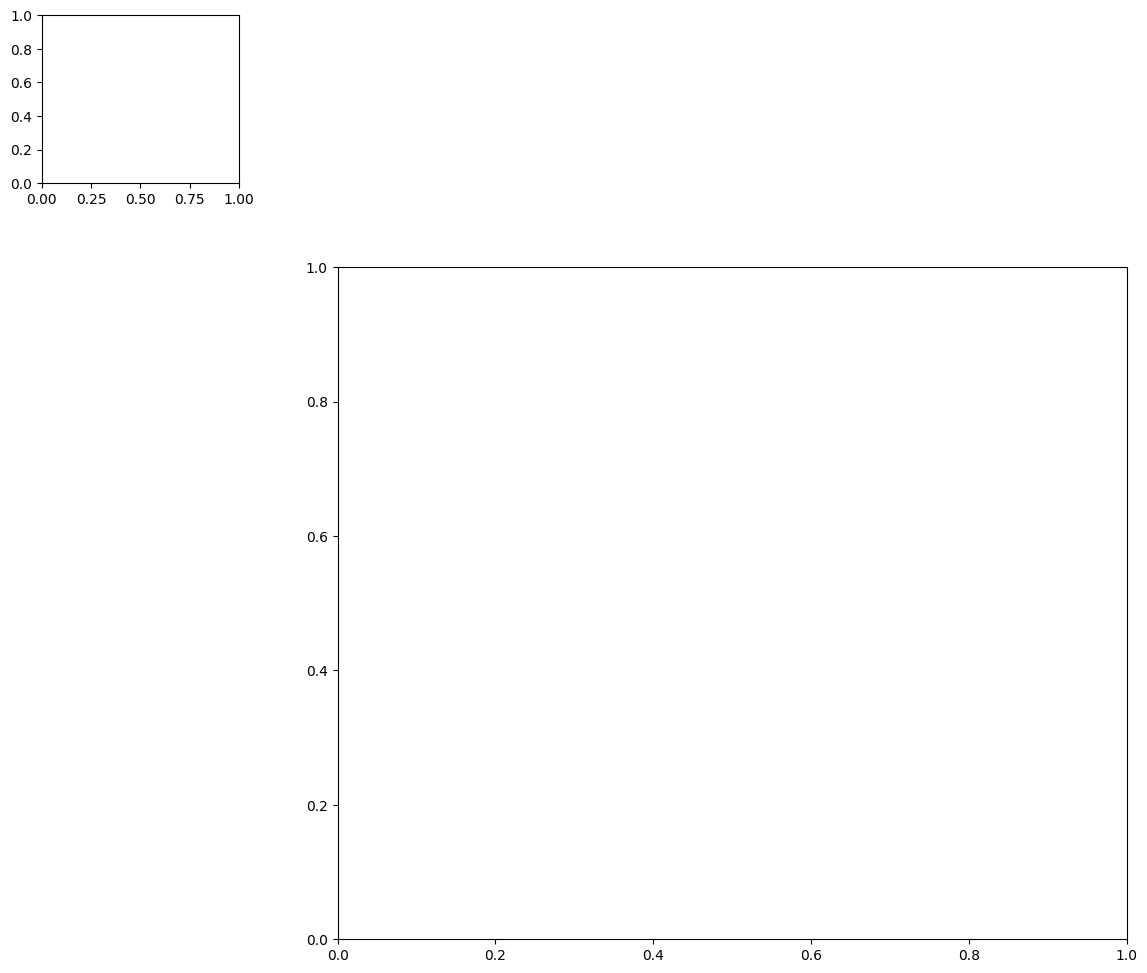

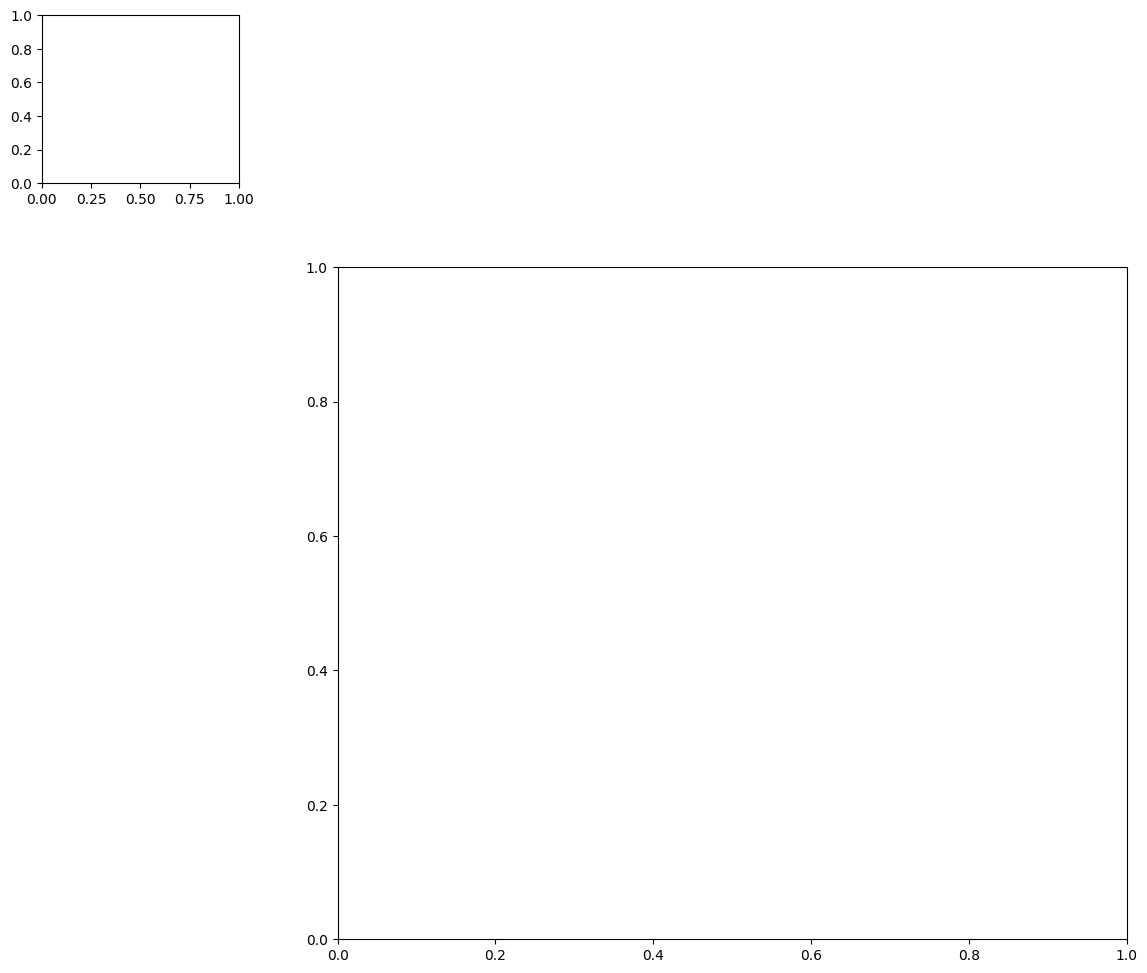

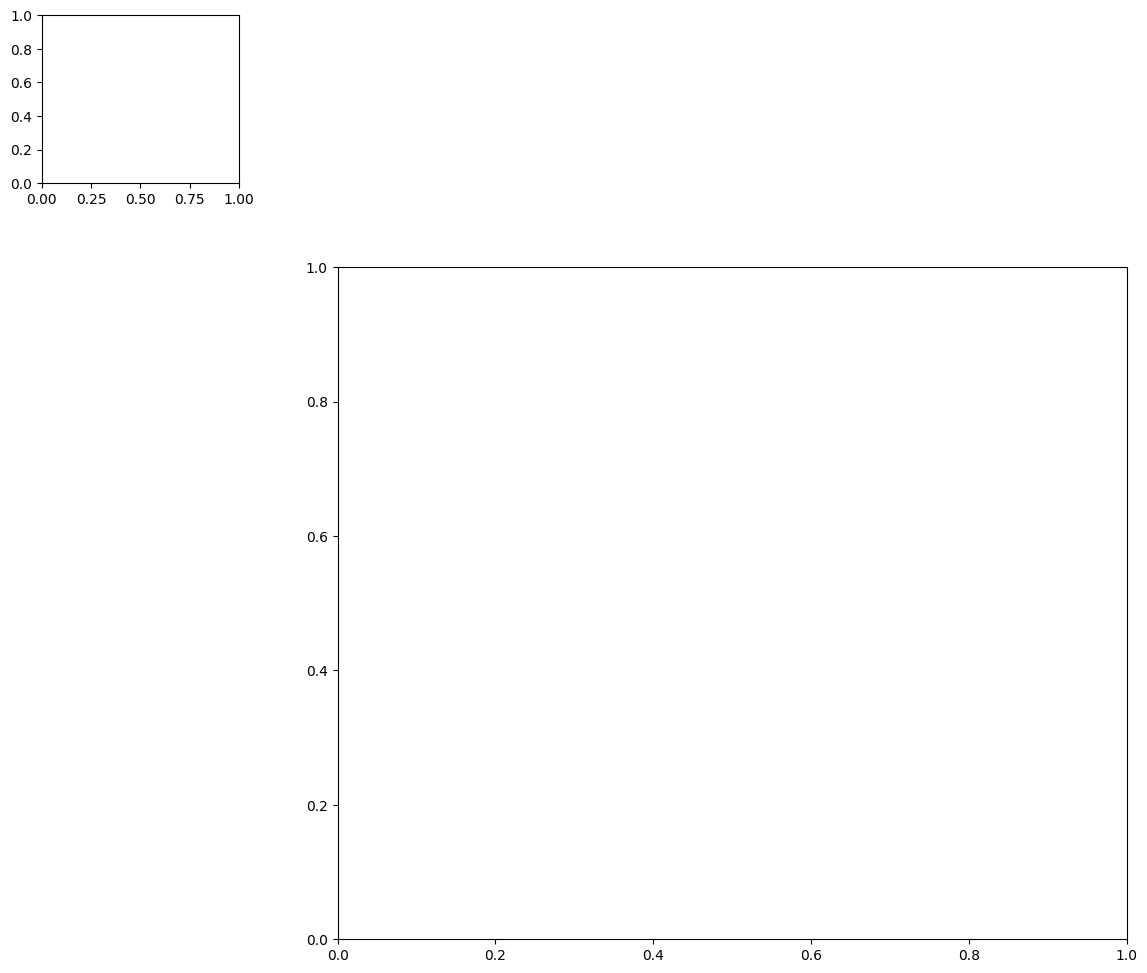

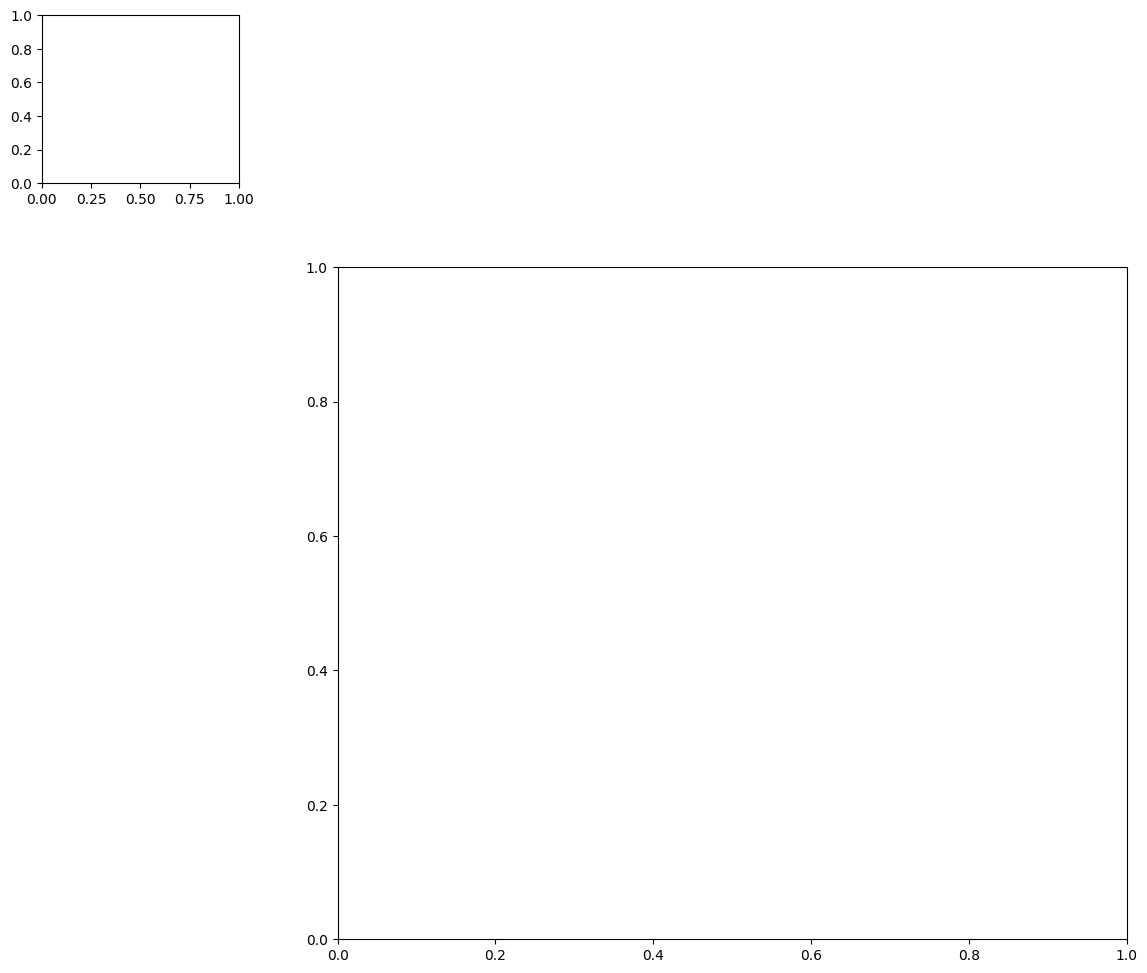

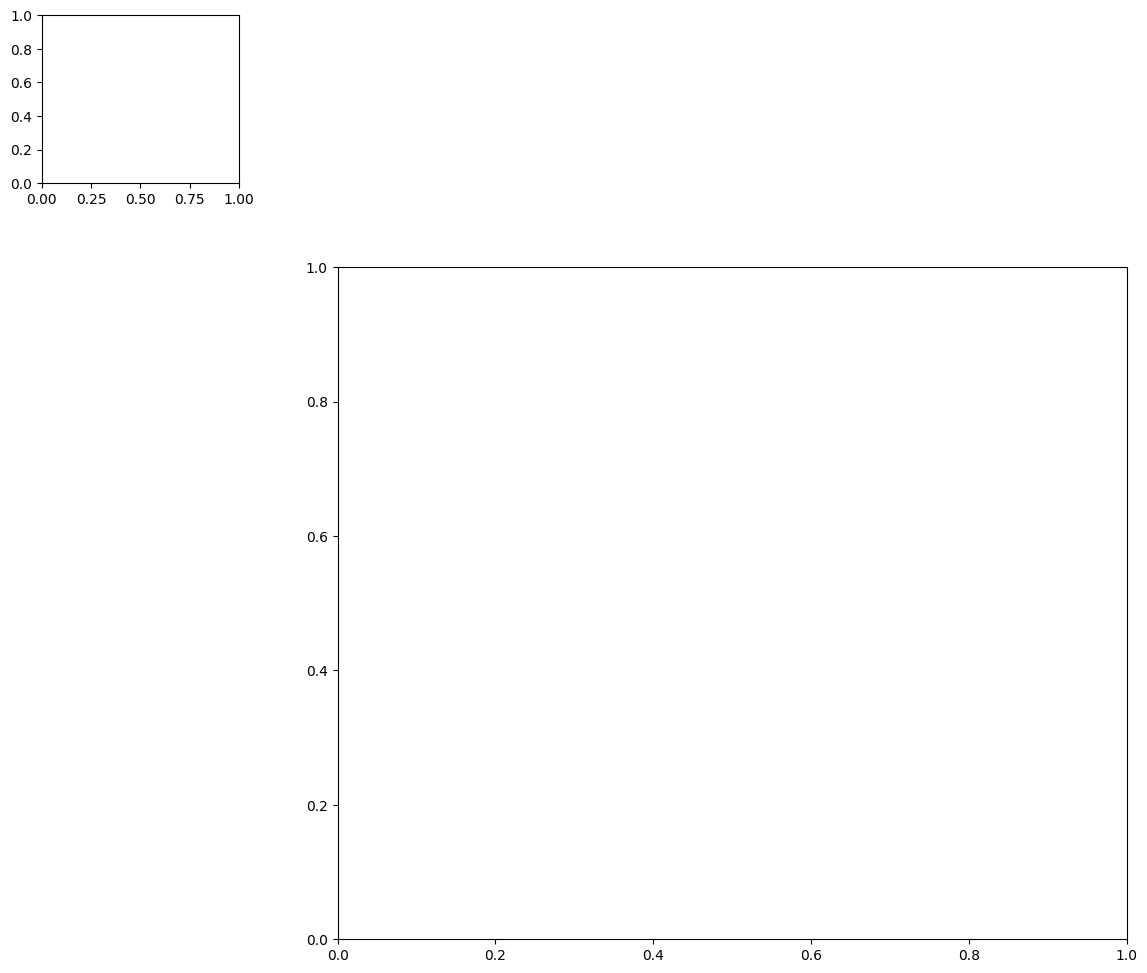

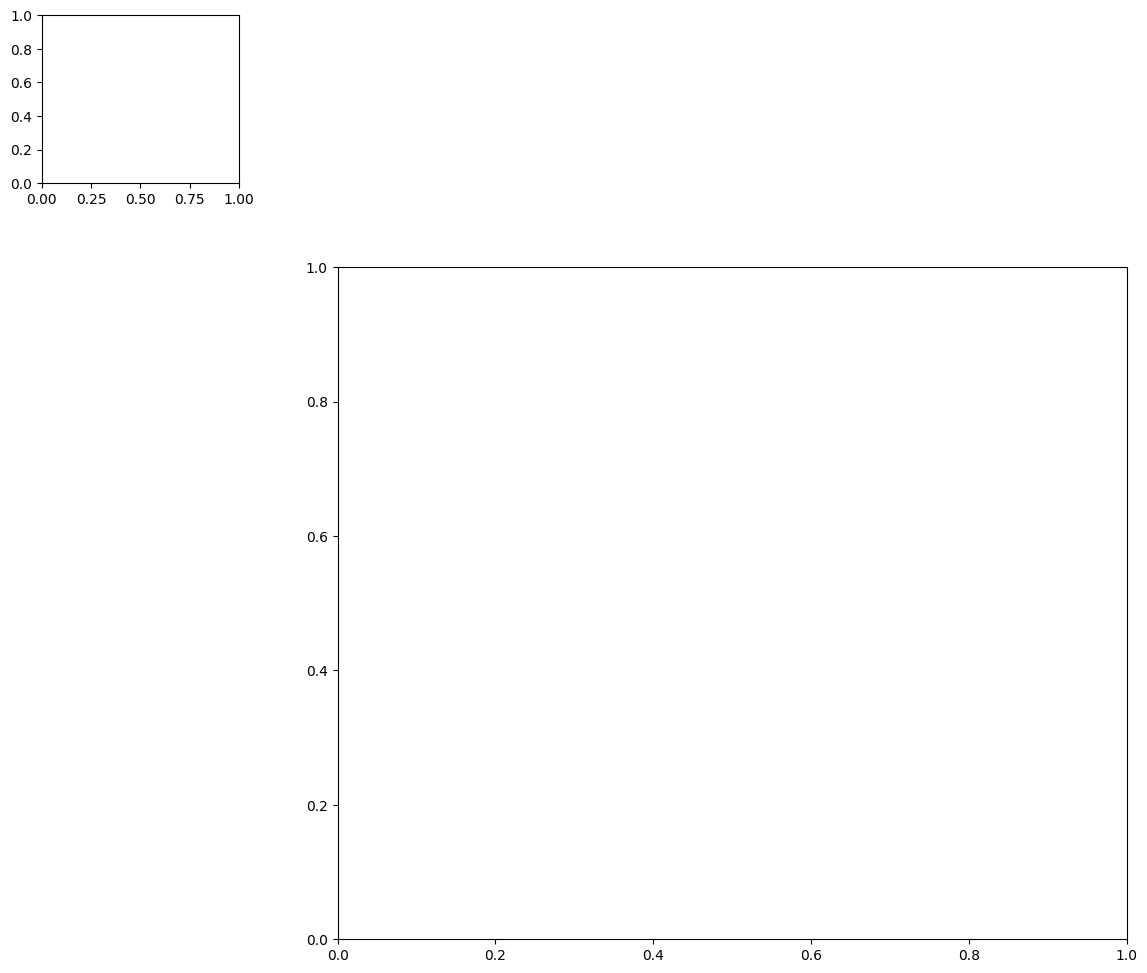

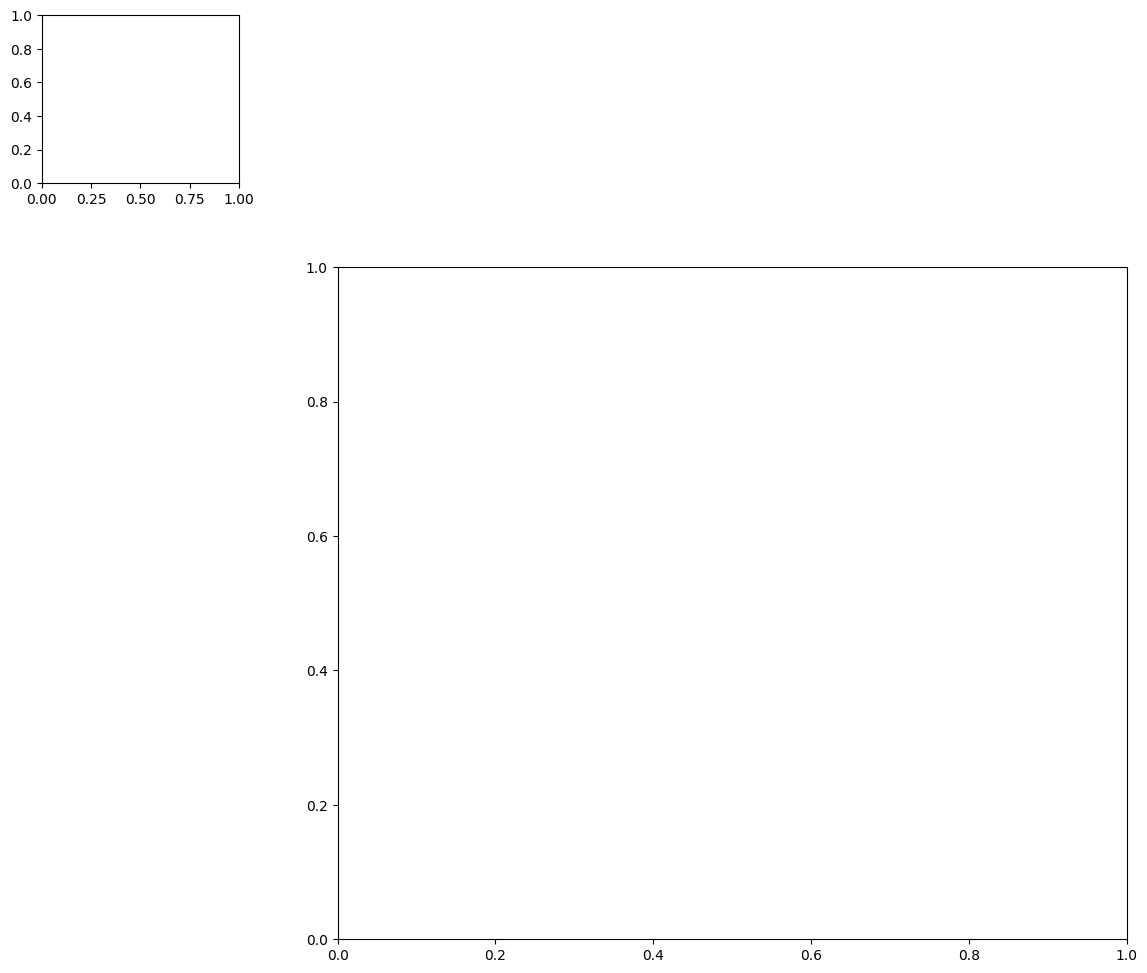

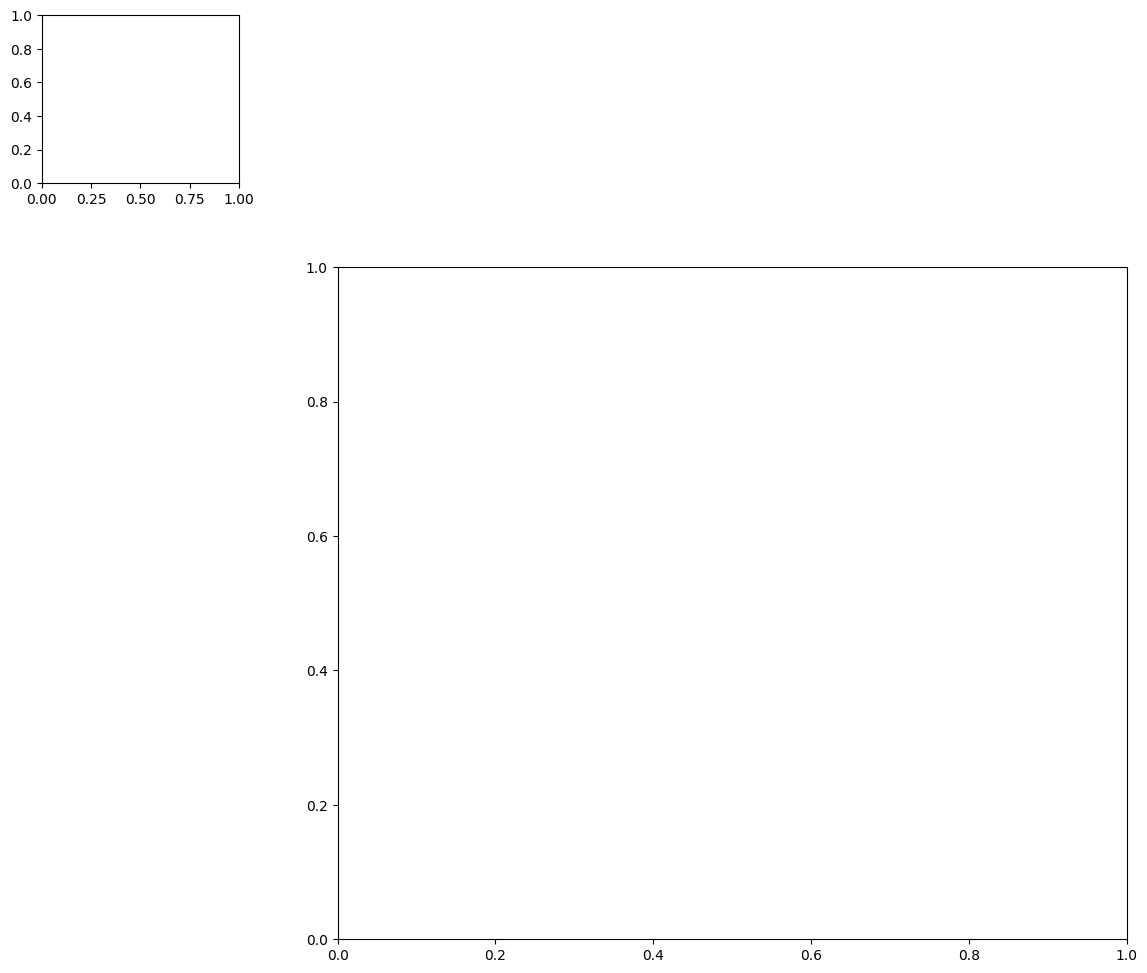

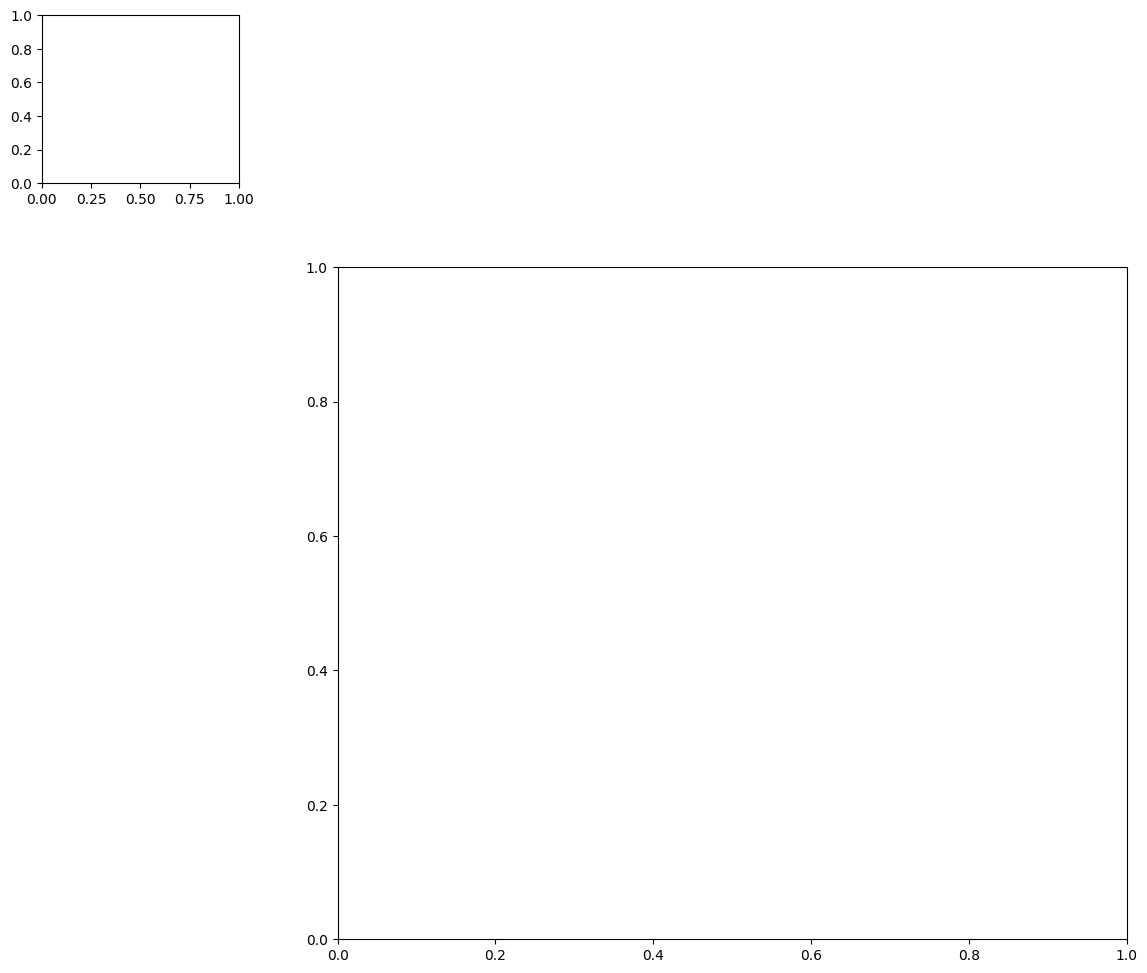

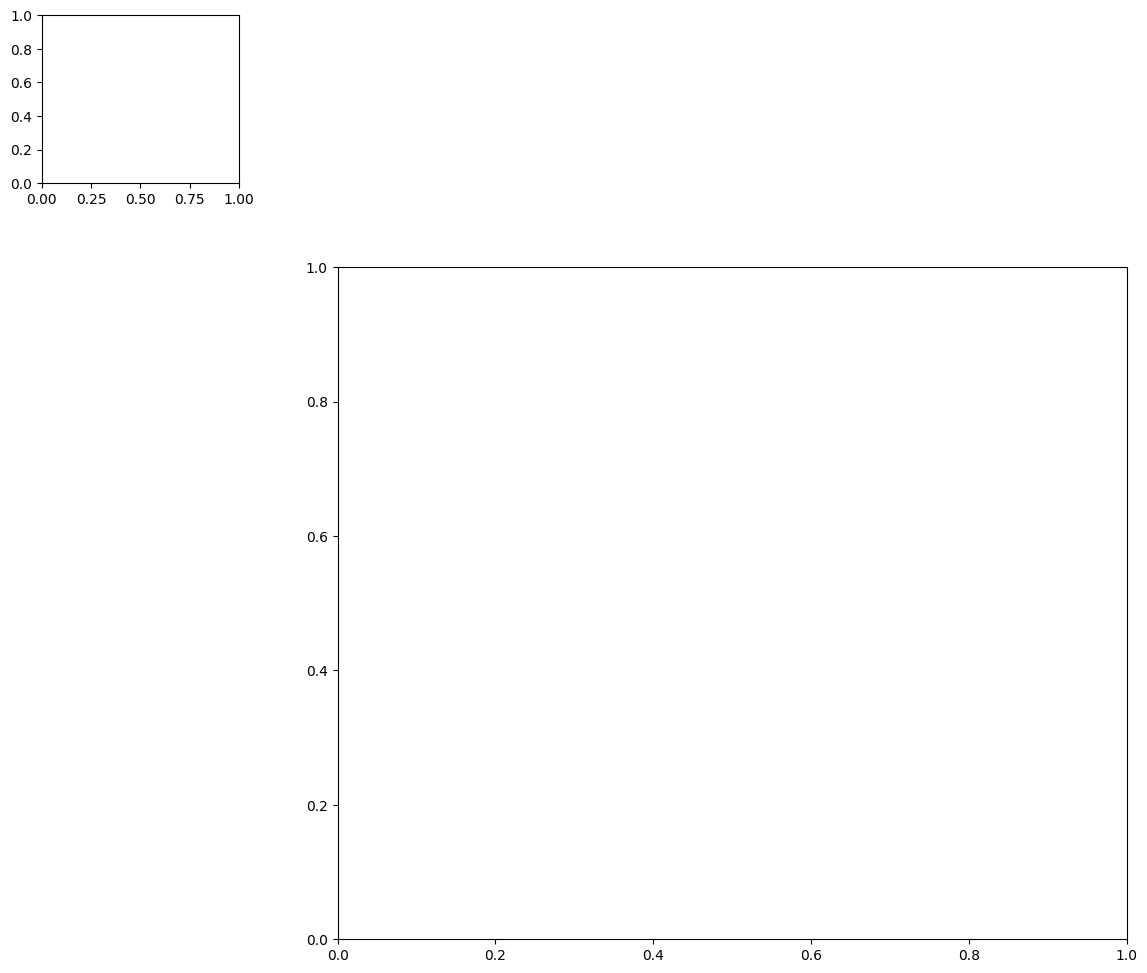

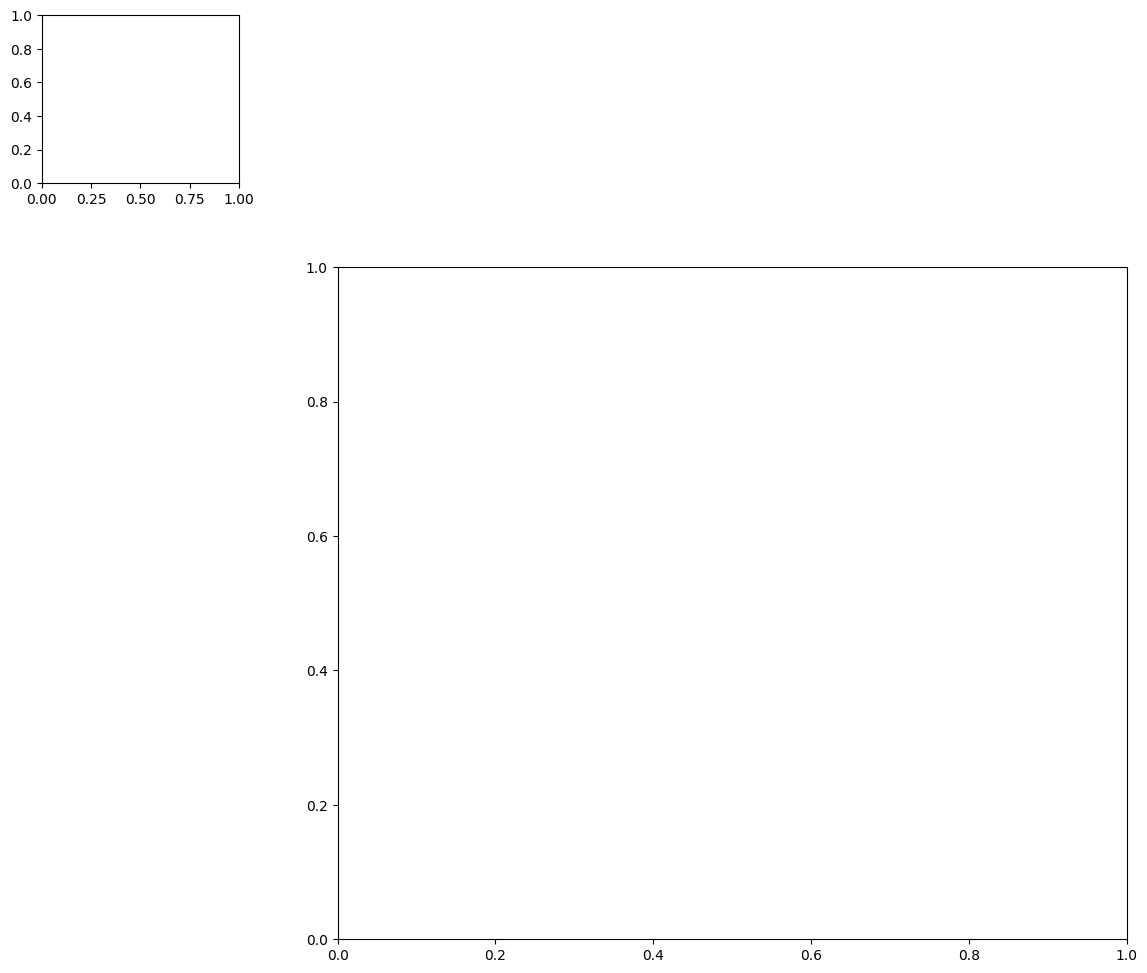

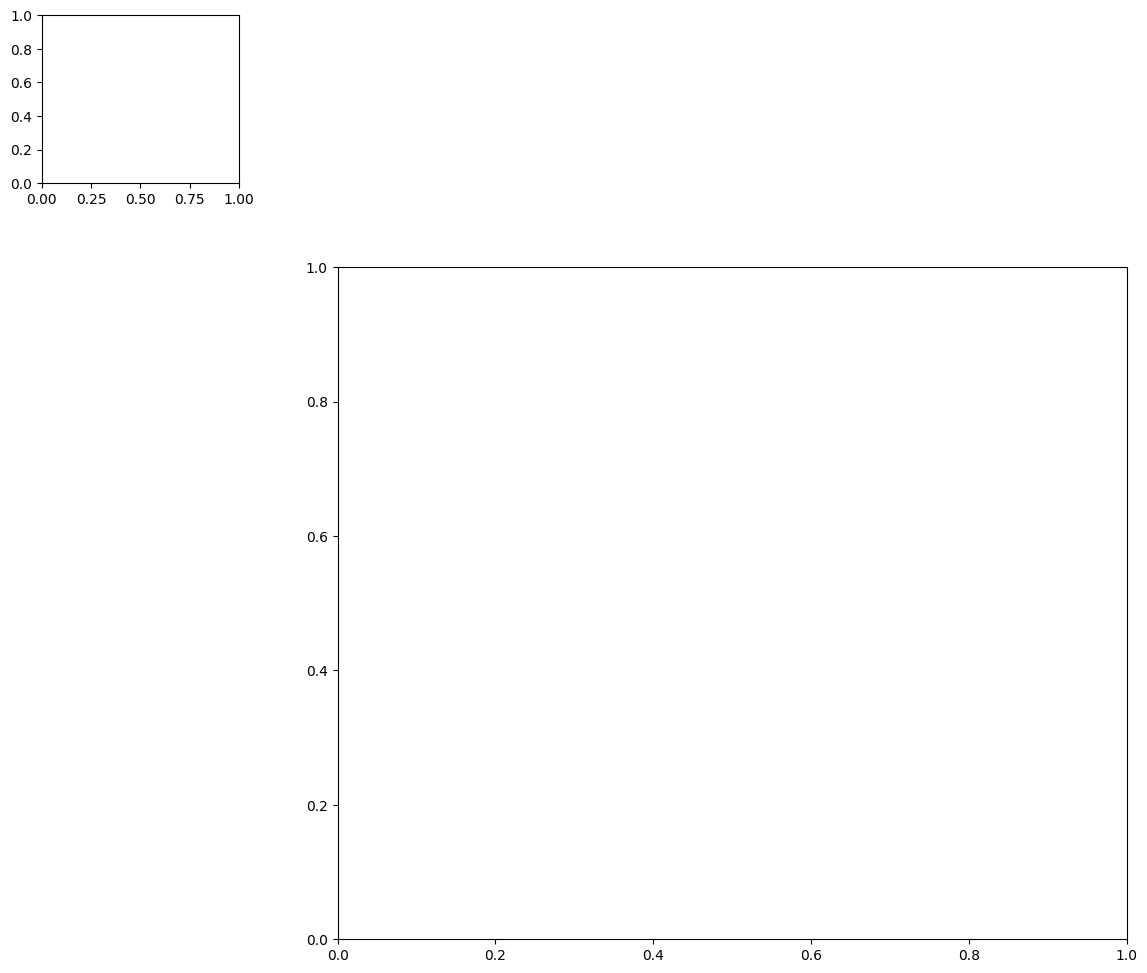

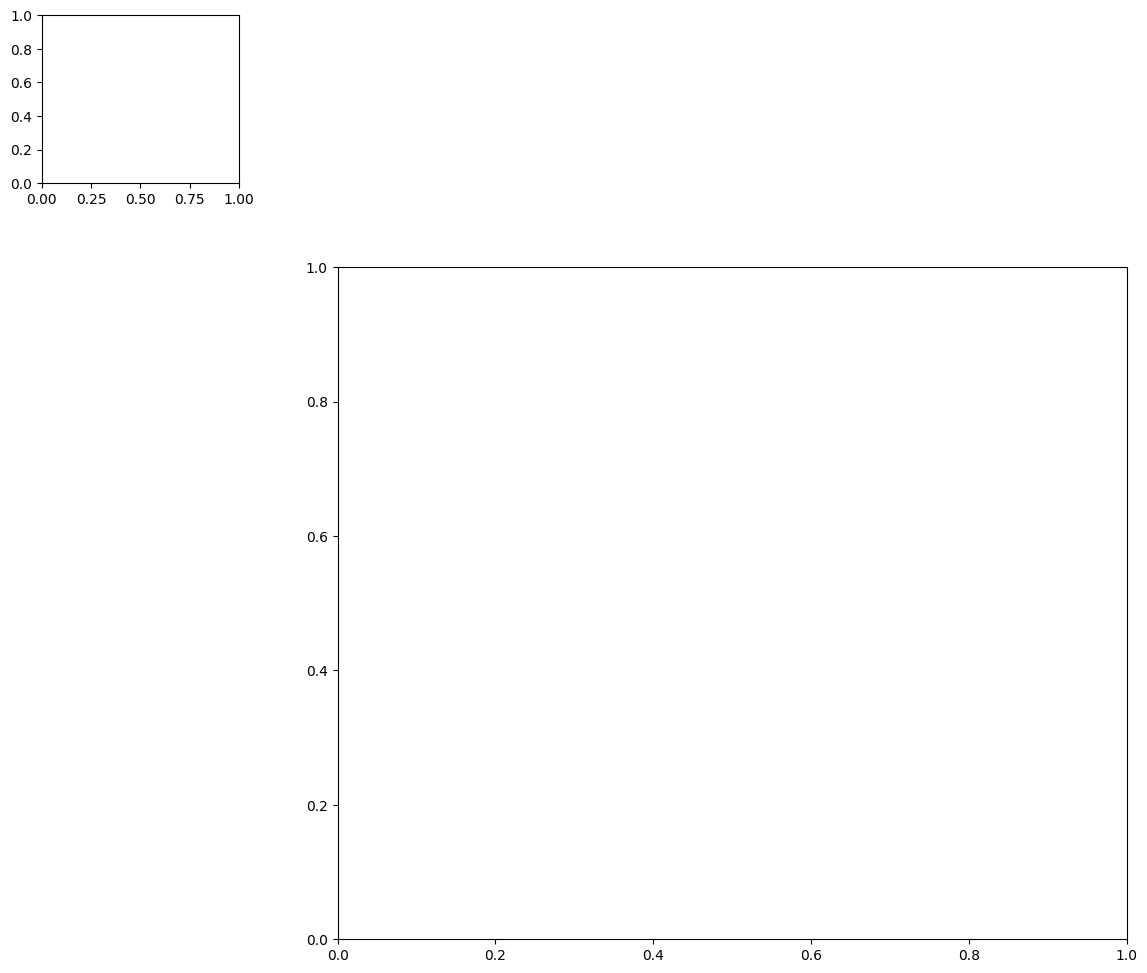

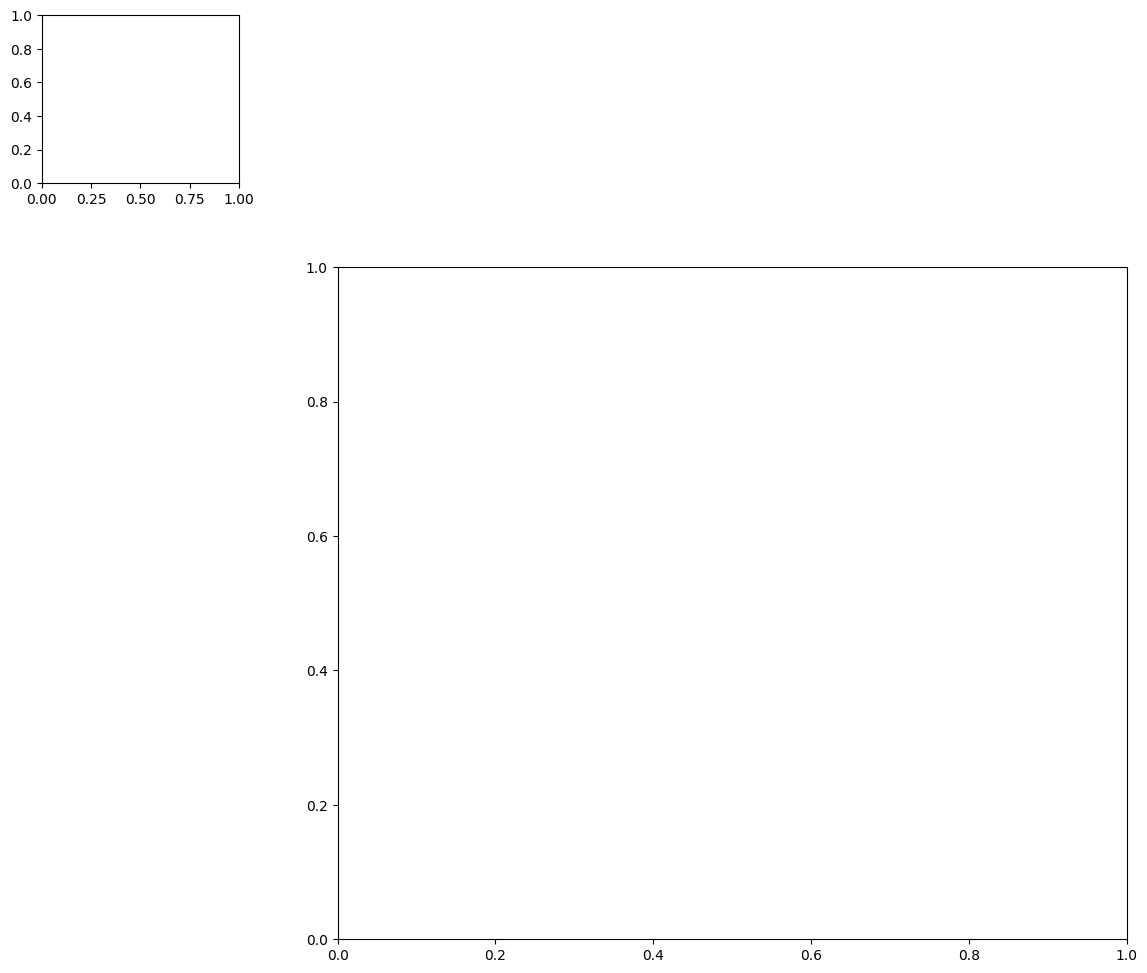

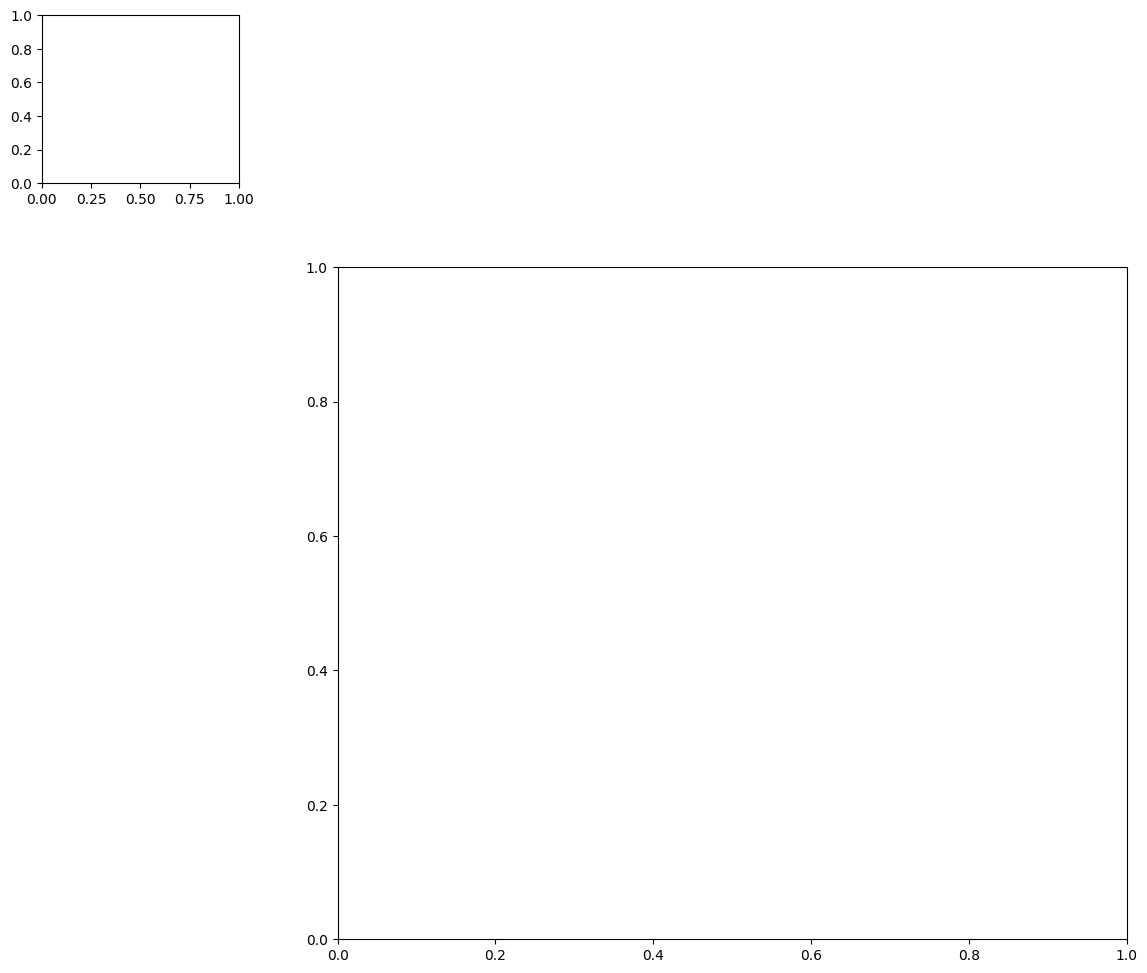

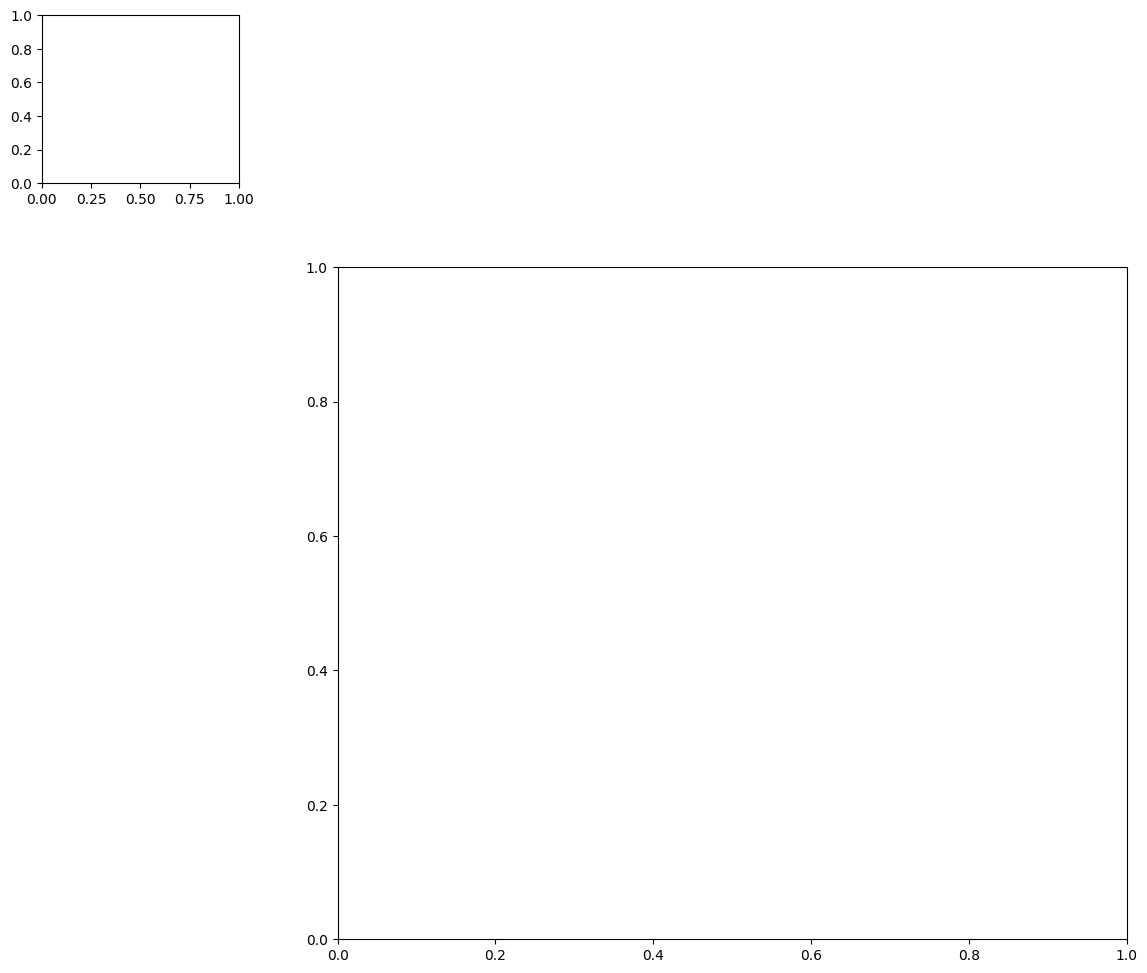

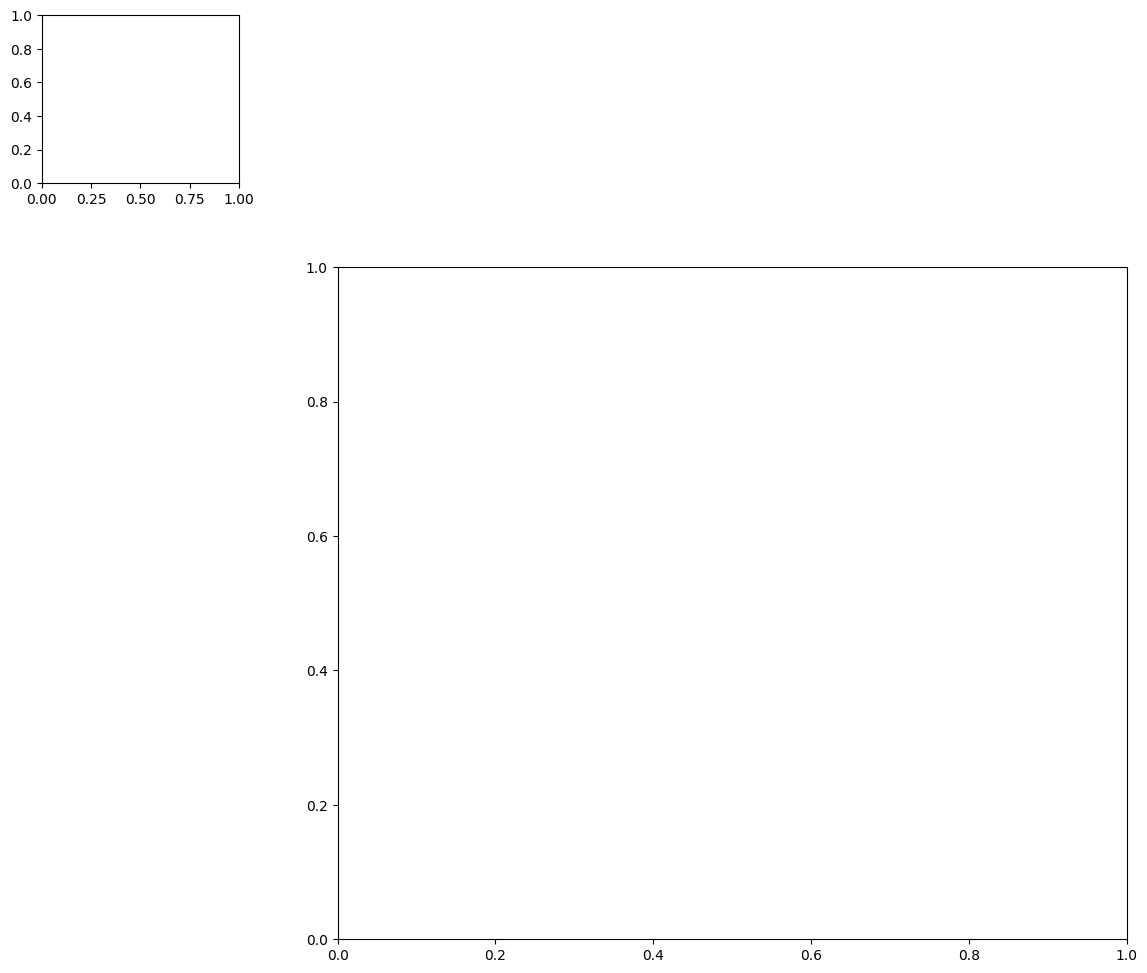

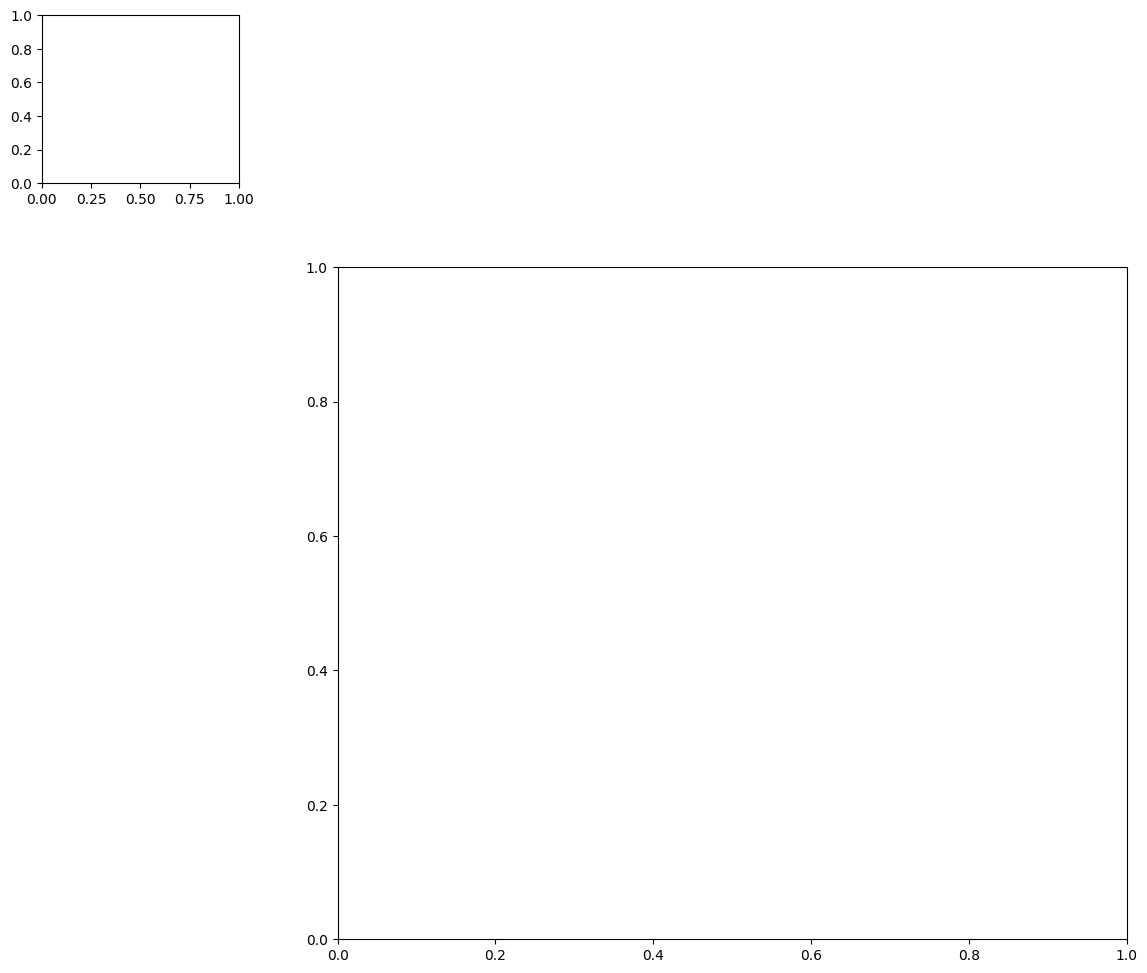

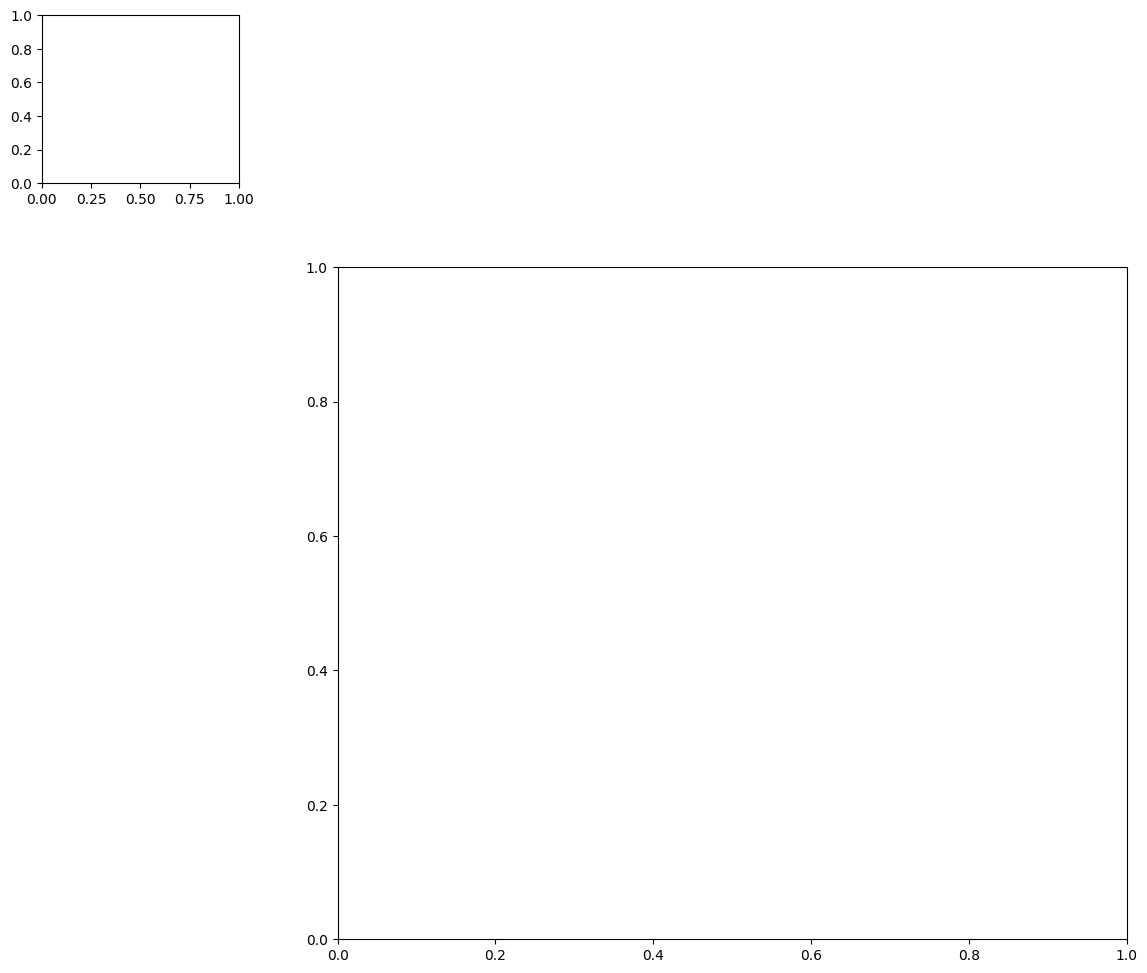

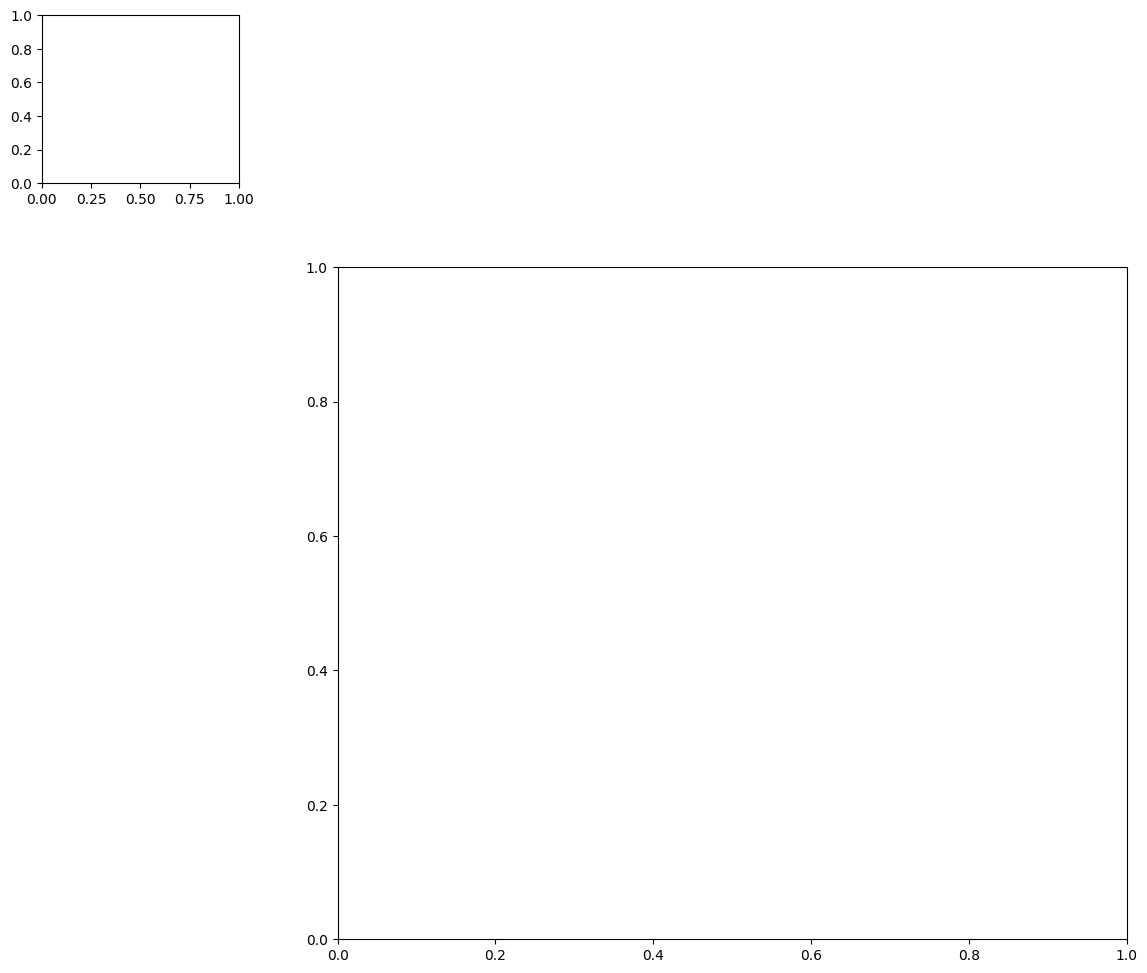

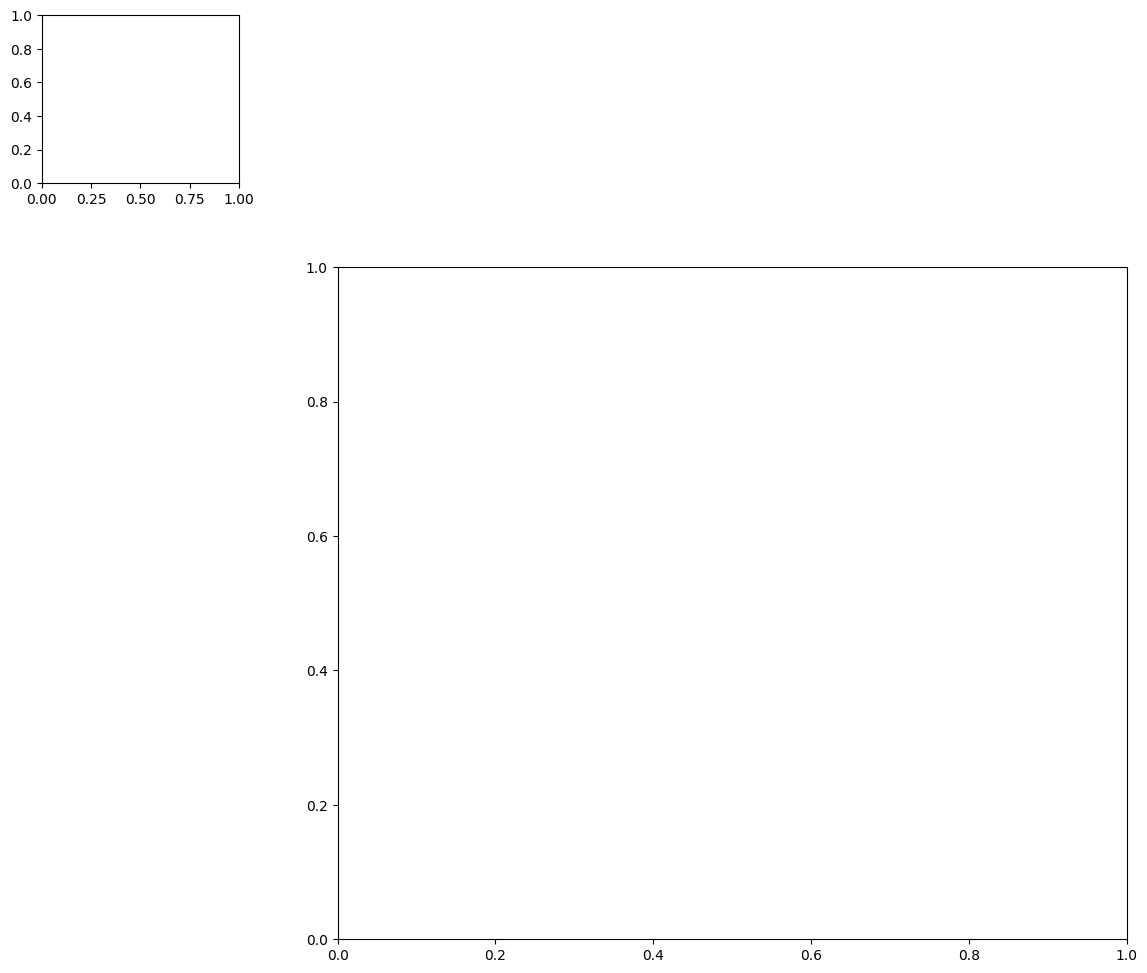

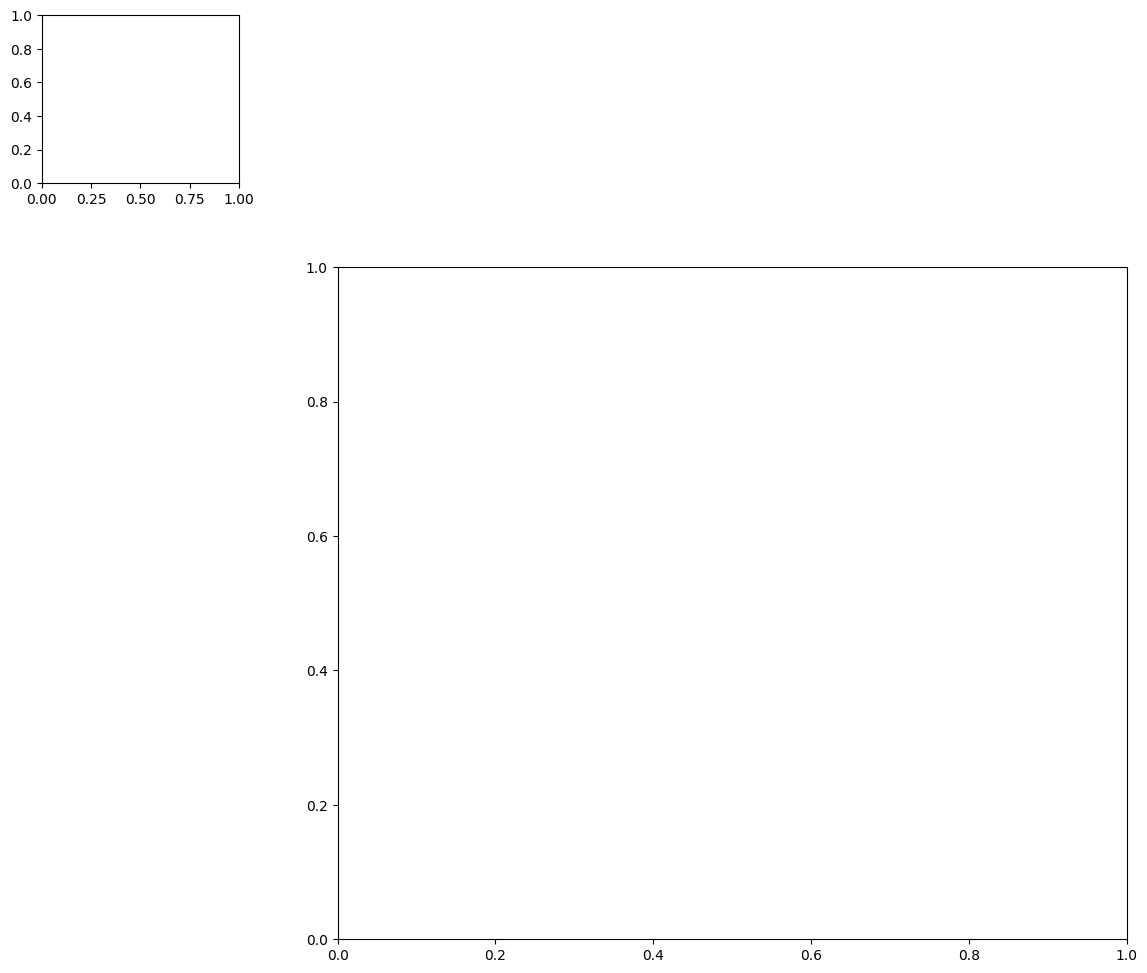

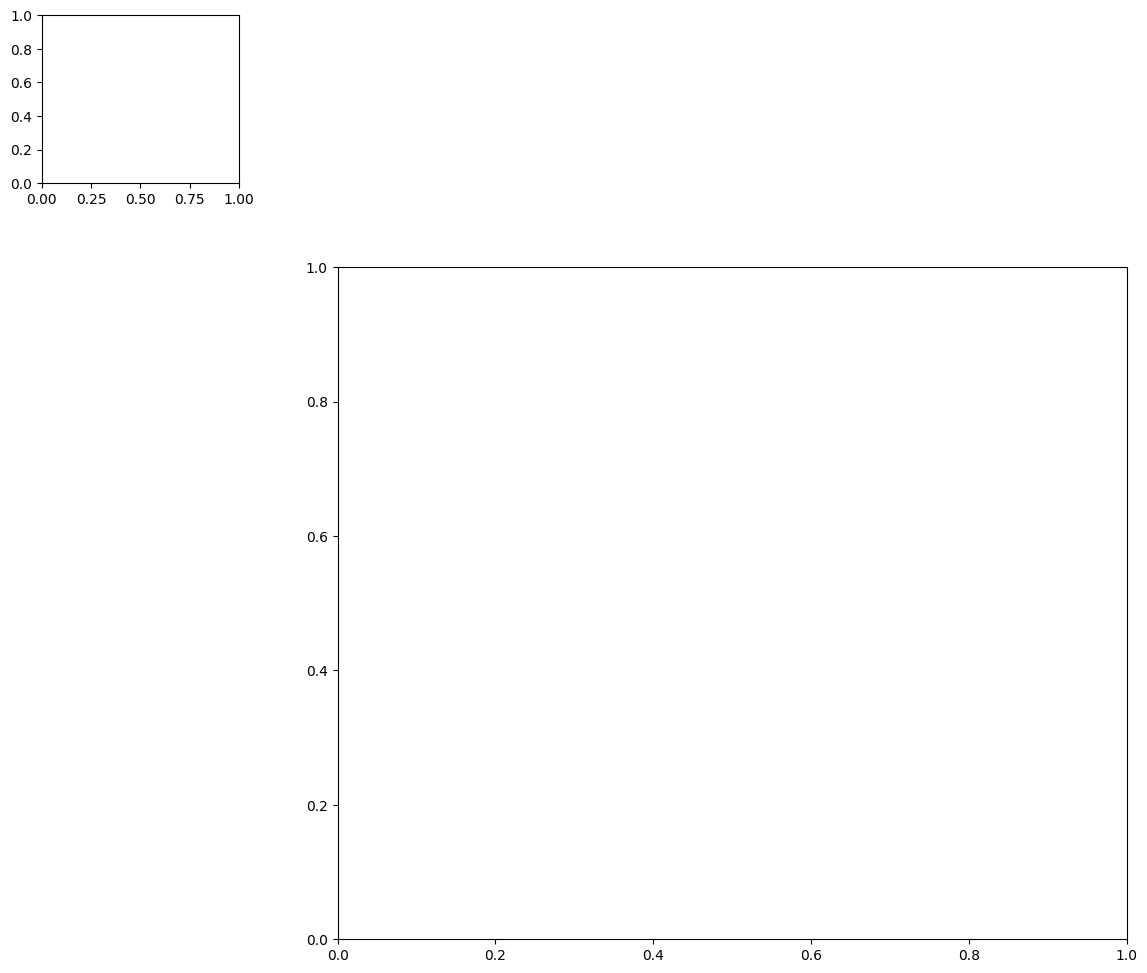

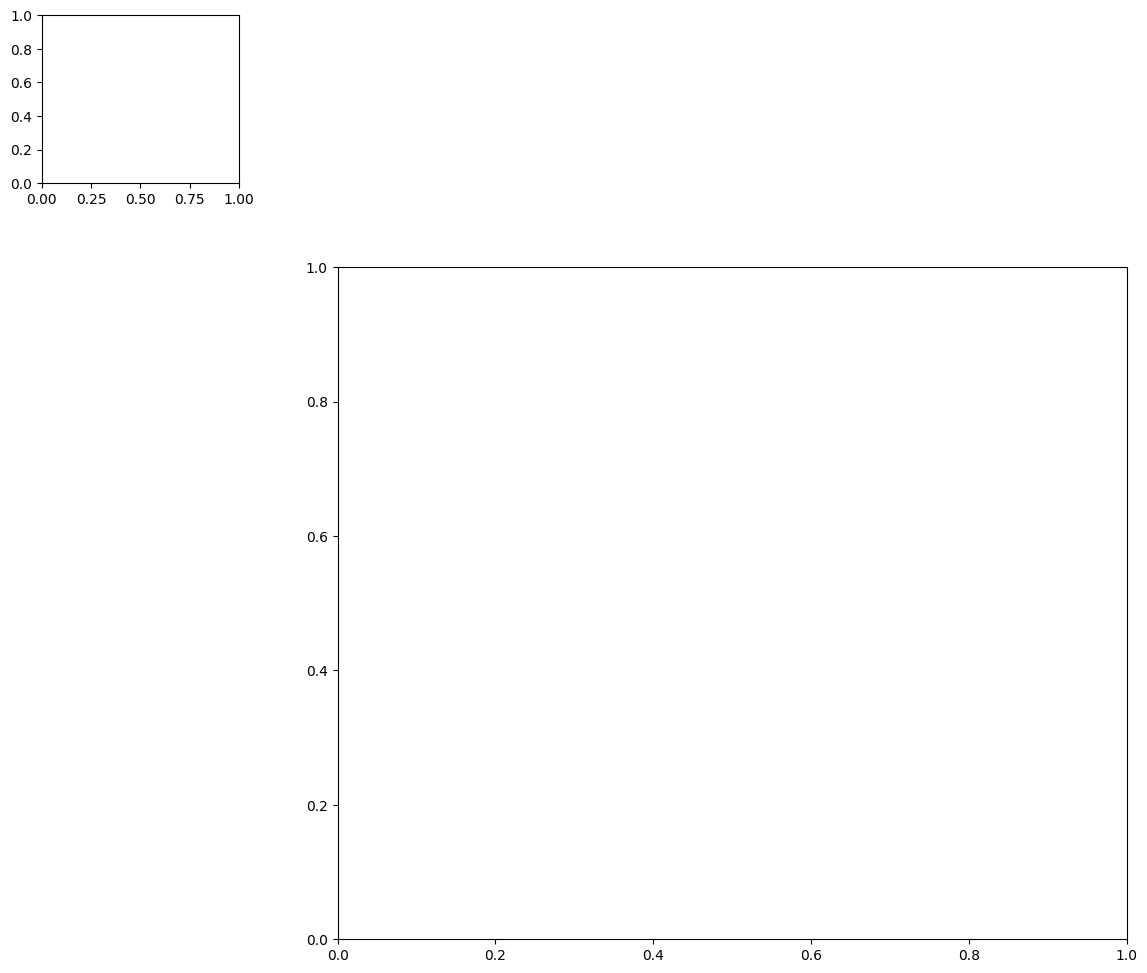

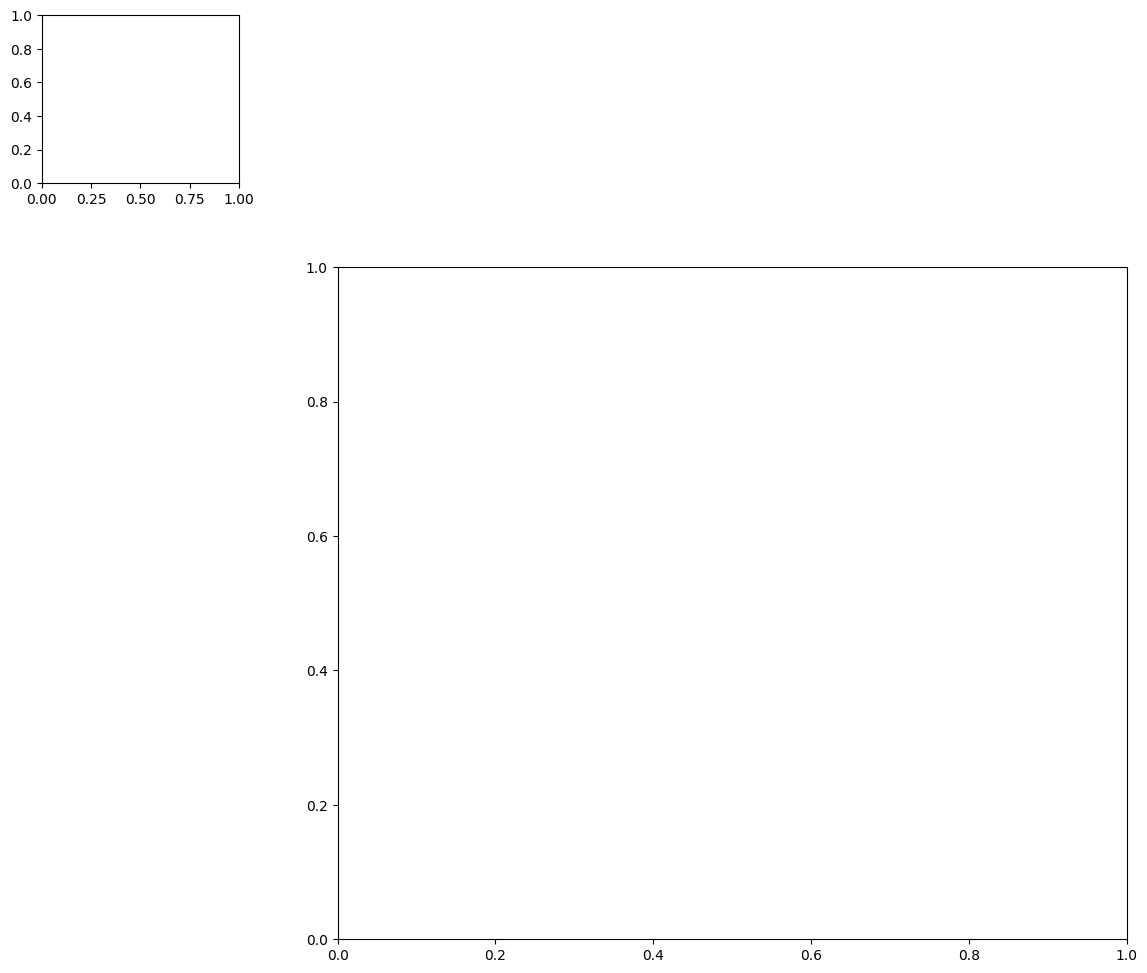

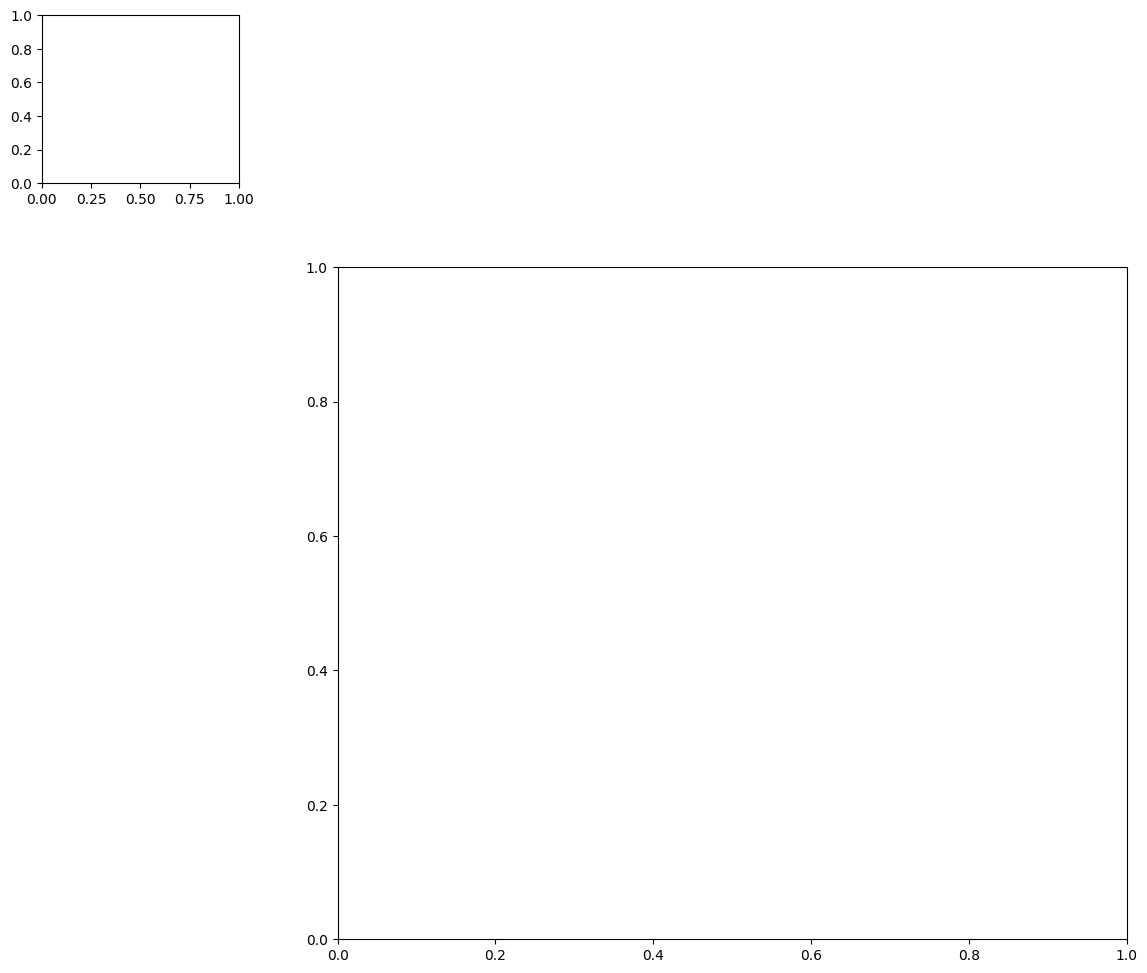

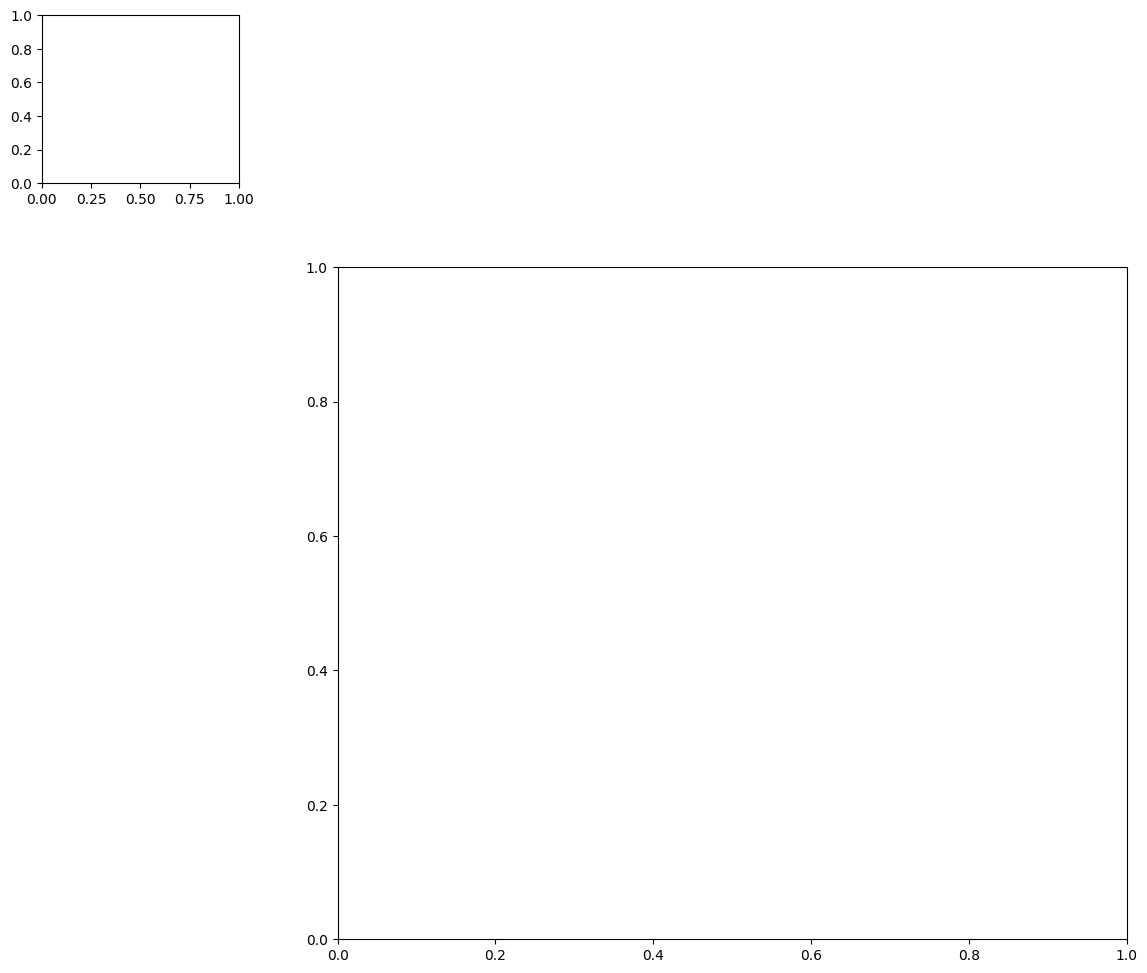

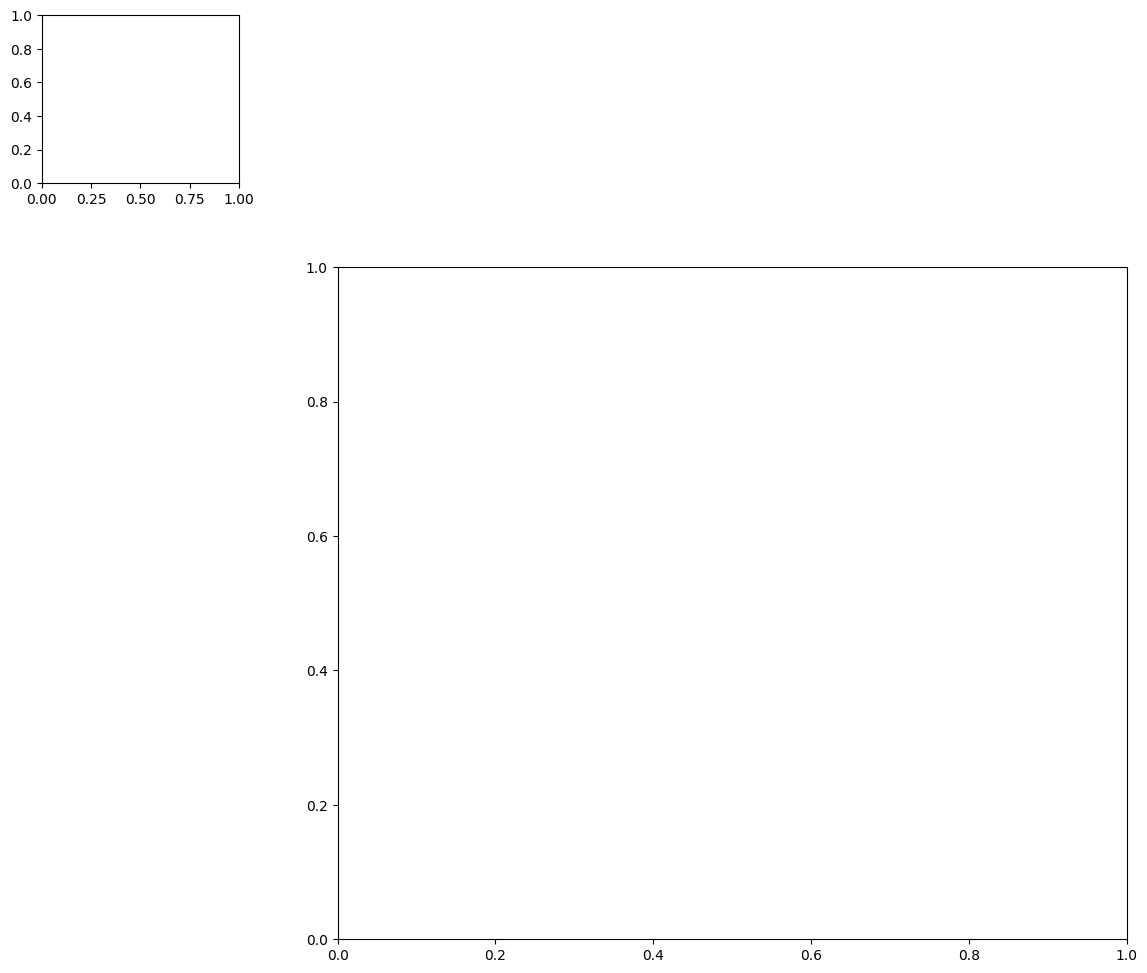

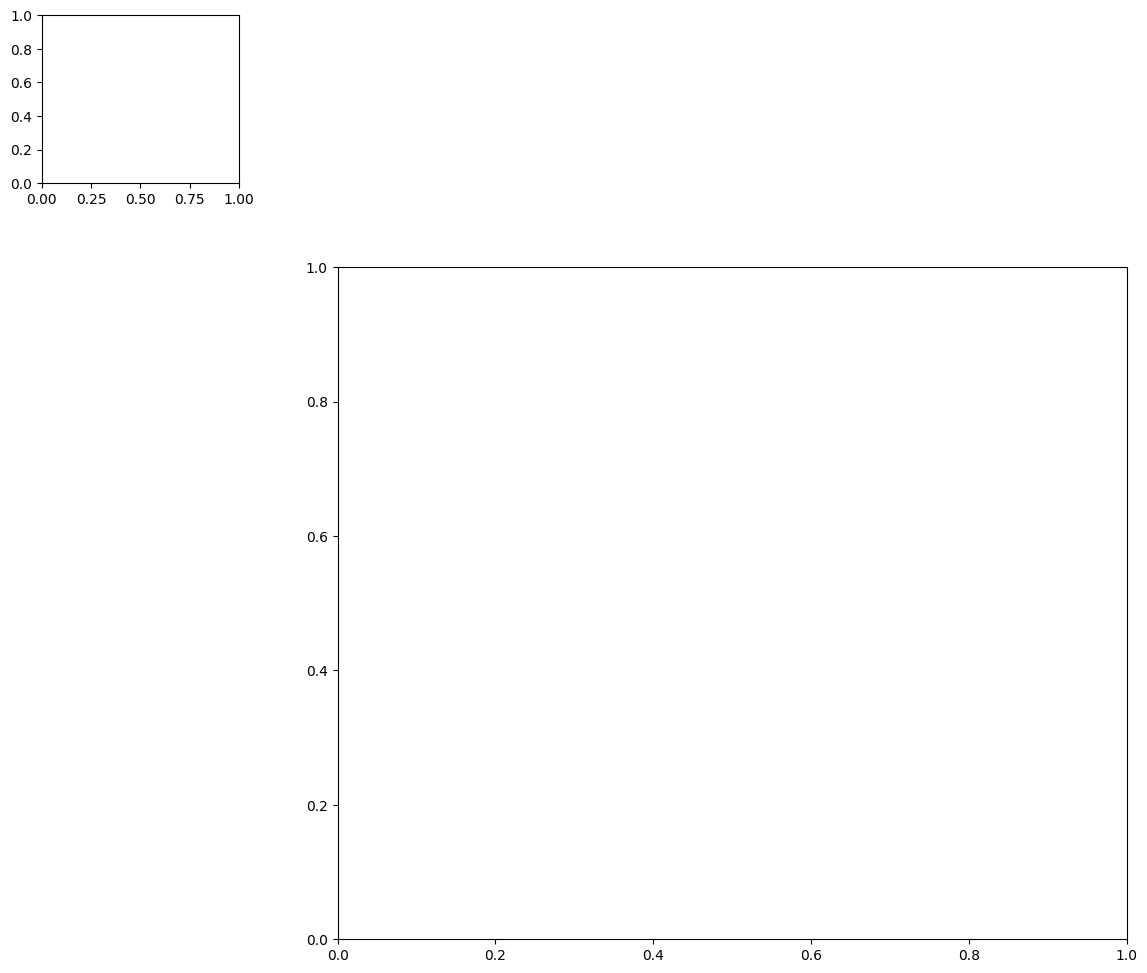

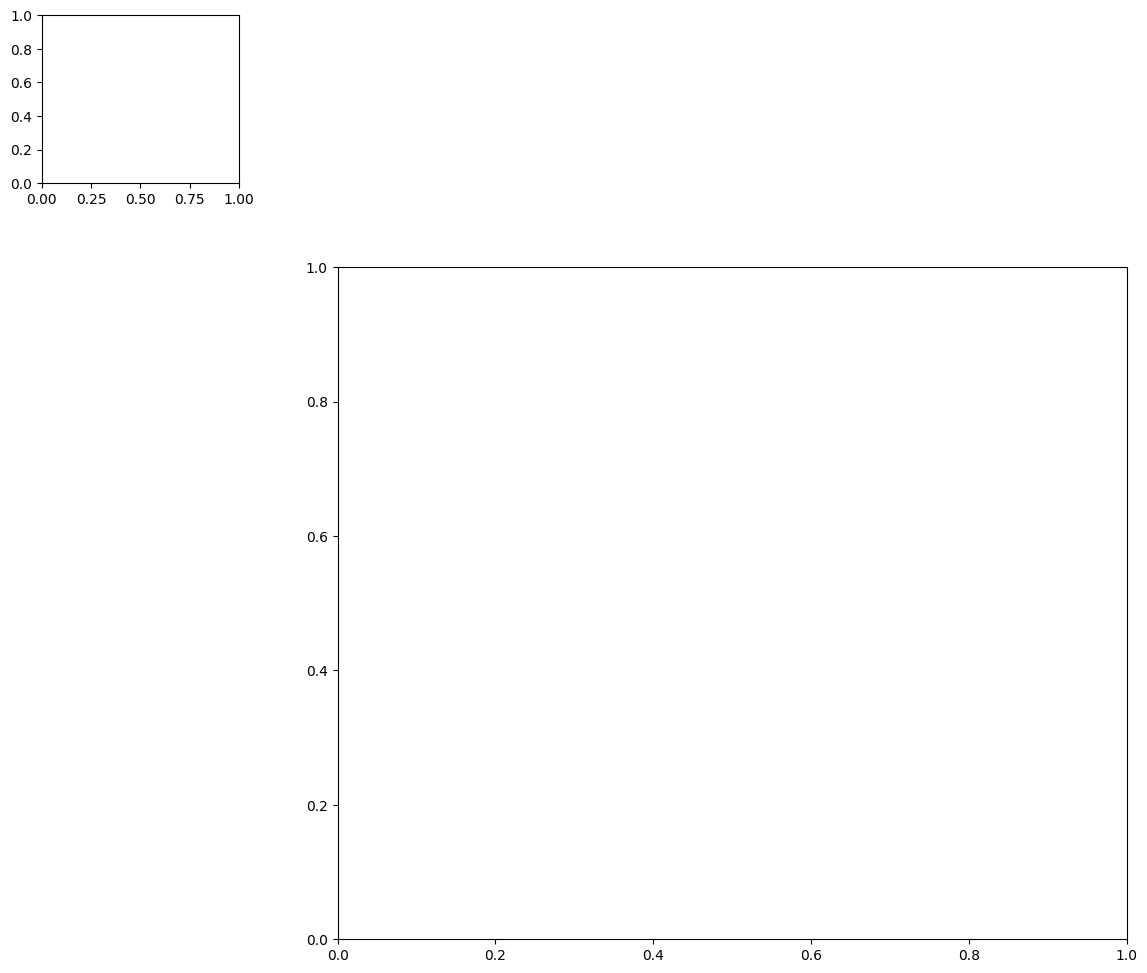

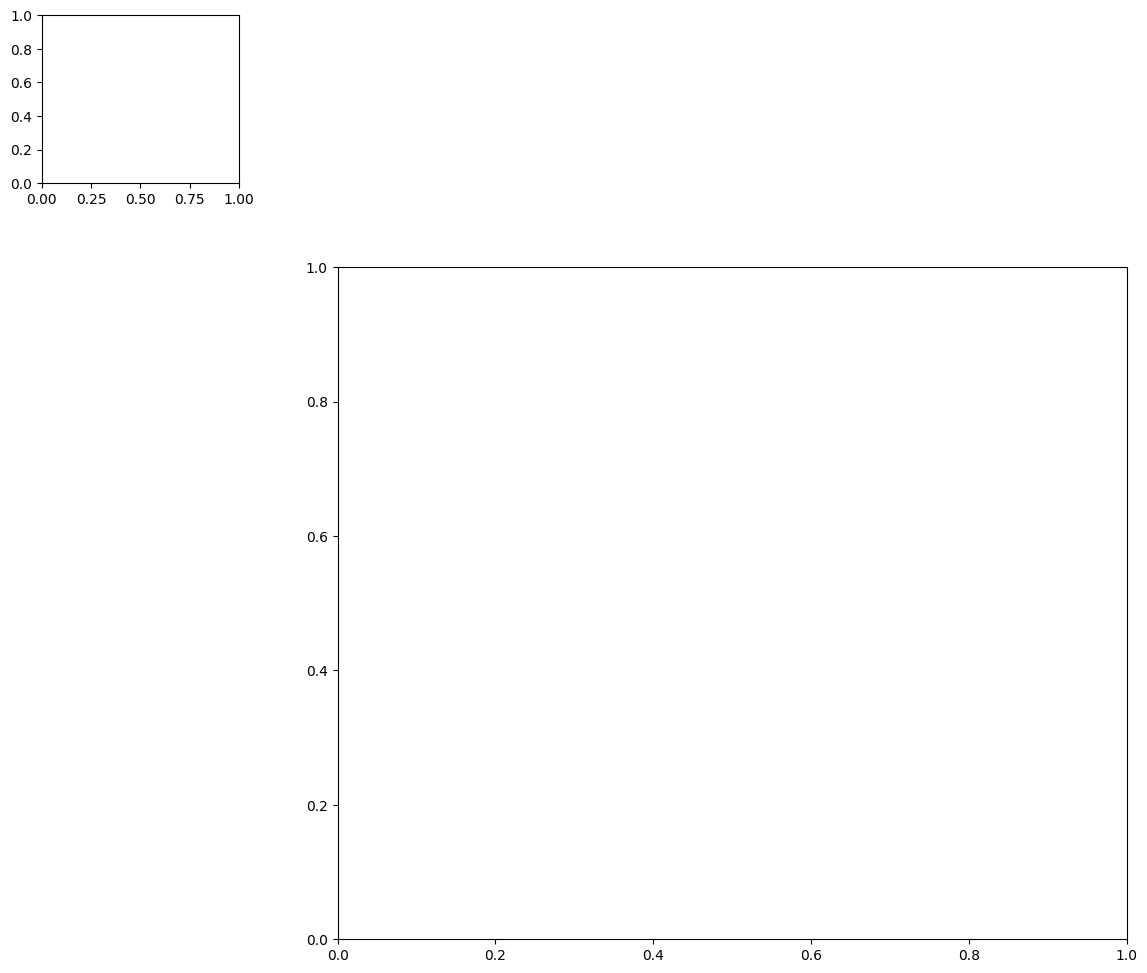

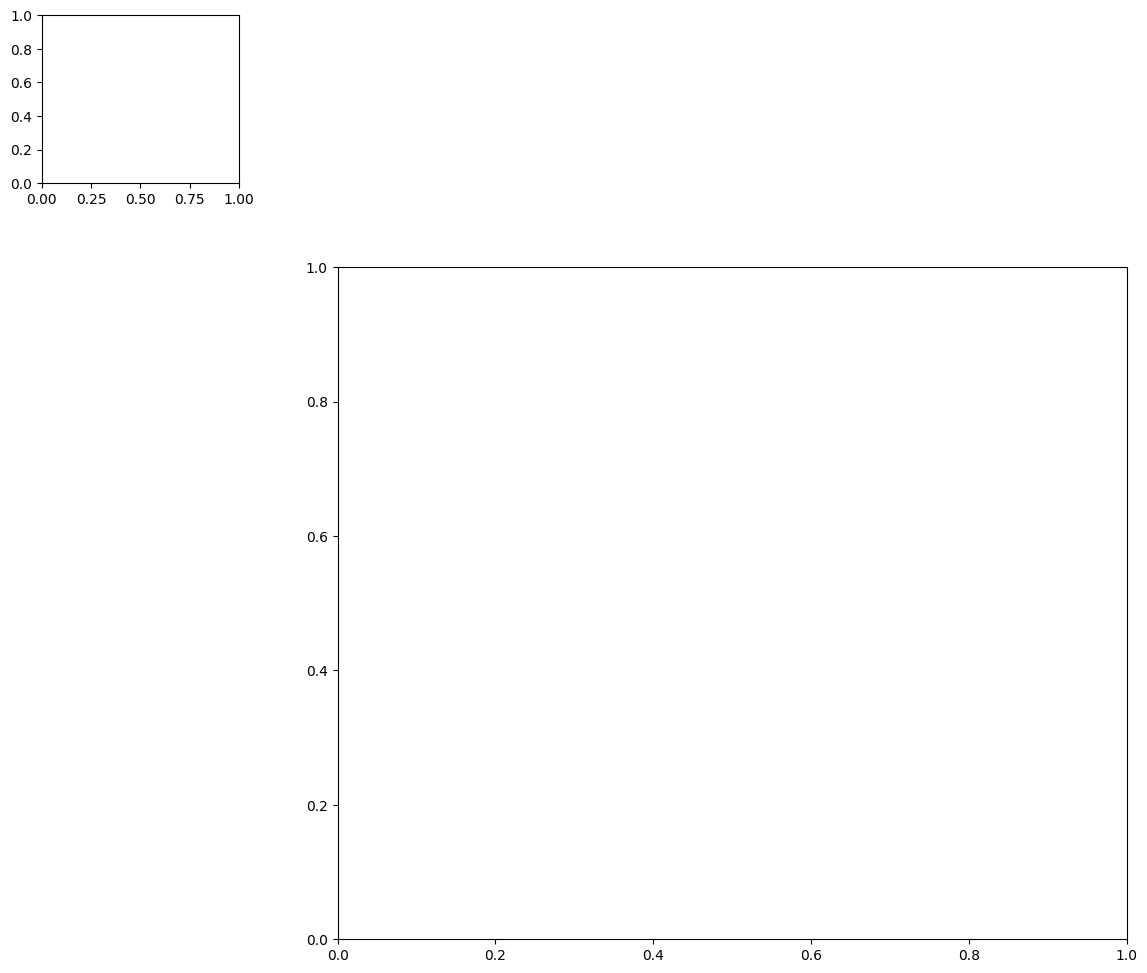

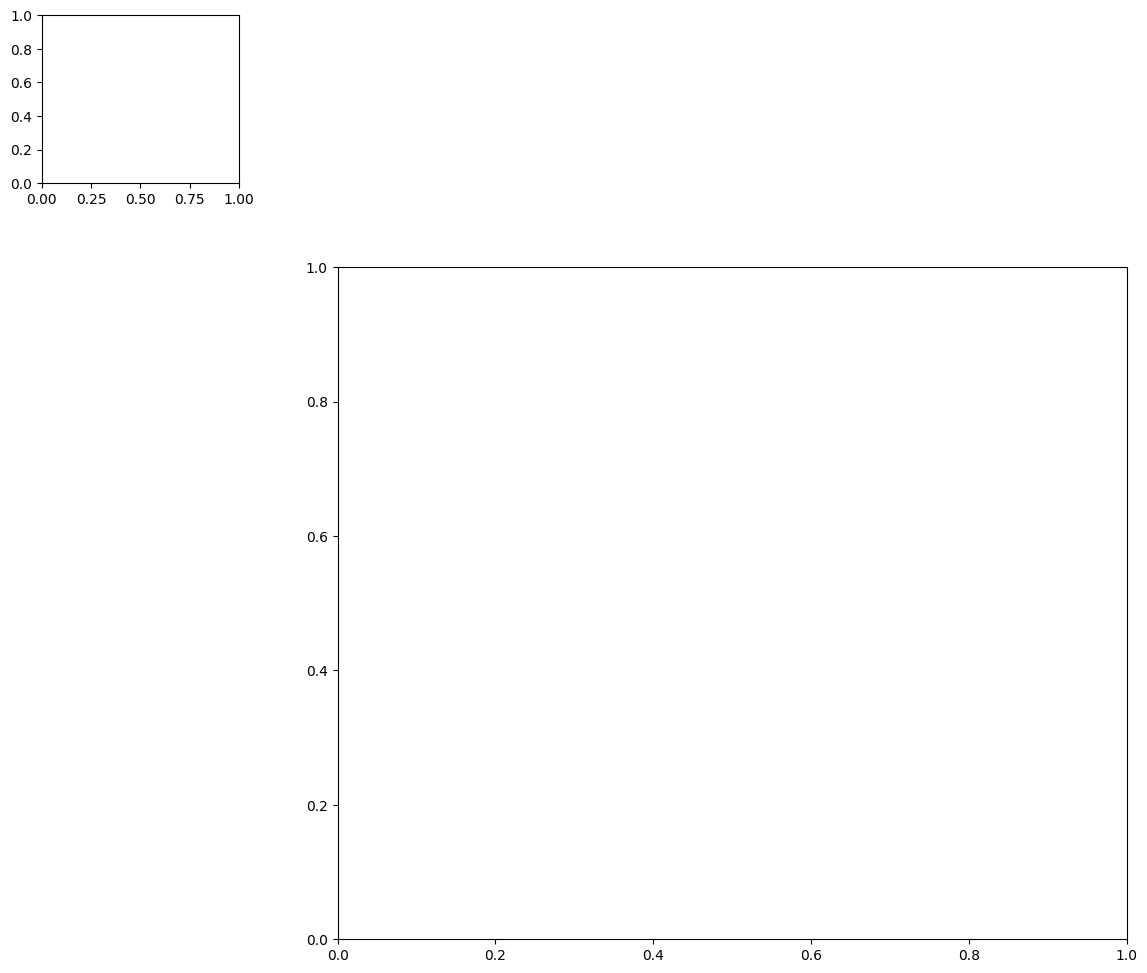

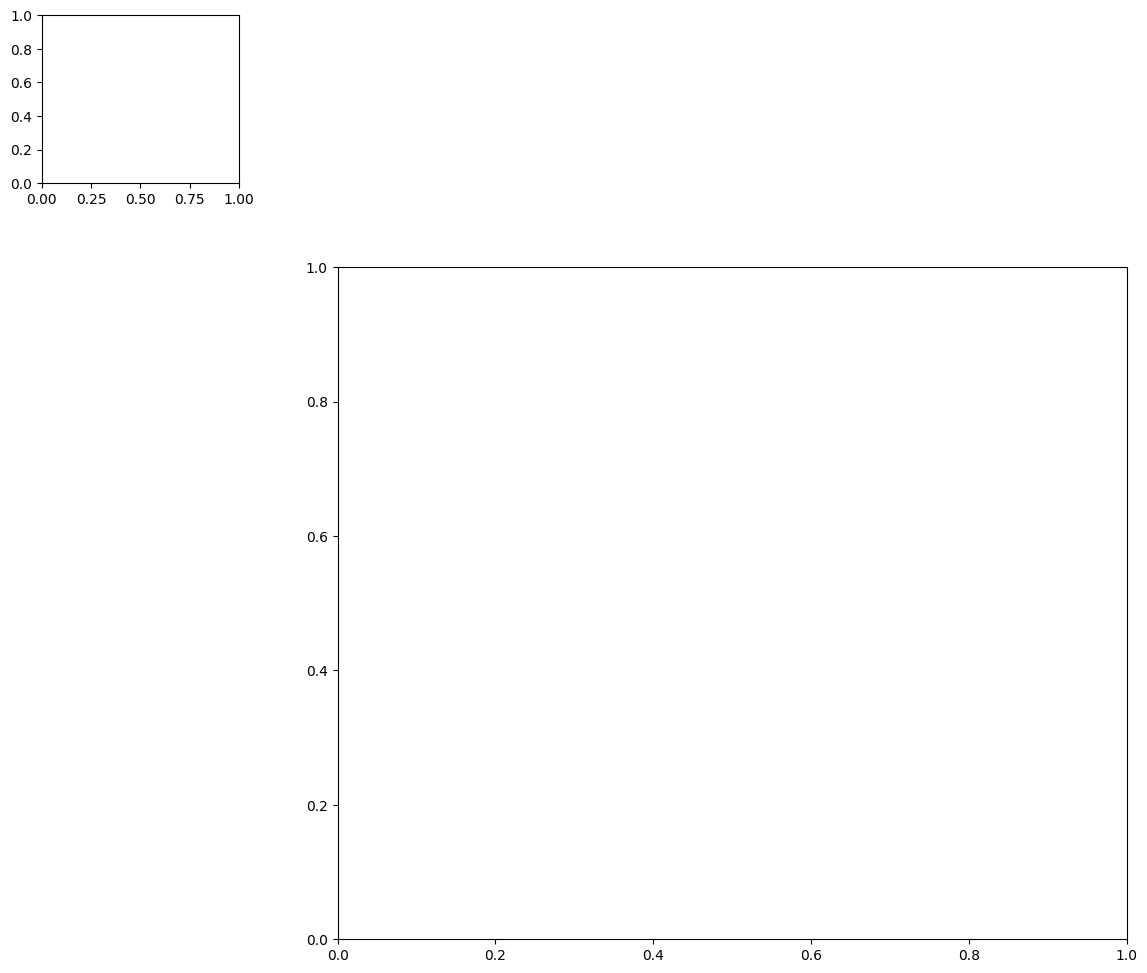

In [70]:
samples_vmin = 0.0
samples_vmax = 10.0
loss_vmin = 0.0
loss_vmax = 10.0

for target_ct in classes:
    ct_runs_df = results_df.loc[results_df.target_ct == target_ct]
    ct_dir = os.path.join(RESULTS_DIR, target_ct.replace("/", "_"))
    for run in tqdm(ct_runs_df.run):
        run_results = ct_results_dict[target_ct.replace("/", "_")][run]
        inverse_results = run_results["inverse_results"]
        fwd_results = run_results["fwd_results"]
        run_dir = os.path.join(ct_dir, run)
        plots_dir = os.path.join(run_dir, "plots")
        if not os.path.isdir(plots_dir):
            os.mkdir(plots_dir)
        plot_heatmap(
            plots_dir,
            classes,
            target_ct,
            fwd_results,
            inverse_results,
            annotation_dict,
            samples_vmin,
            samples_vmax, 
            loss_vmin,
            loss_vmax,
            plot_pheno=True
        )


## Visualizing induced phenotypes.

### Heatmap of induced phenotypes from sampled conditions.

For each type we pick the configuration with the best minimum loss.

## Visualizing induced cell states.

### Rescaling subsample data..

In [ ]:
izn_g = get_rescaling(train_adata_g, inverse=True)
zn_phi = get_rescaling(train_adata_phi)
X_true = torch.from_numpy(adata_g.obsm[cell_state_rep]).float().cuda()
X_true = izn_g(X_true)
X_true = zn_phi(X_true).detach().cpu().numpy()
adata_g.obsm["rescaled_features"] = X_true
adata_g

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scatter', 'X_scatter_standardized', 'X_channel', 'X_channel_standardized', 'X_channel+X_scatter', 'X_channel_standardized+X_scatter'

### Utility function to create adatas.


In [ ]:
n_scatter_feats = 6
def get_adata_from_idx(fwd_results, min_loss_idx, compute_stuff=True):
    X_gen = fwd_results["X"][min_loss_idx]
    ct_label_gen = ct_le.inverse_transform(
        fwd_results["ct_probs"][min_loss_idx].argmax(1)
    )

    X = np.concat((X_gen, X_true), axis=0)
    X_channel = X[:, :-n_scatter_feats]
    X_scatter = X[:, -n_scatter_feats:]
    G = np.concatenate((ct_label_gen, adata_g.obs["cell_type"].values), axis=0)
    ct_adata_gen = sc.AnnData(
        X=X_channel,
        obsm={"X_scatter": X_scatter},
        obs={
            "cell_type": G,
            "data_type": ["gen"]*X_gen.shape[0] + \
                ["real"]*len(adata_g)
        },
        var=pd.DataFrame(index=adata_g.var_names)
    )
    if compute_stuff:
        sc.pp.pca(ct_adata_gen)
        sc.pp.neighbors(ct_adata_gen)
        sc.tl.umap(ct_adata_gen)
    return ct_adata_gen

### Concatenating with generated samples

In [ ]:
ct_adatas_dict = {}

pbar = tqdm(range(len(classes)))

for target_ct in classes:
    ct_runs_df = results_df[results_df.target_ct == target_ct]
    best_run_idx = ct_runs_df.loc[:, "min_loss"].argmin()
    best_run = ct_runs_df.iloc[best_run_idx].loc["run"]
    run_results = ct_results_dict[target_ct.replace("/", "_")][best_run]

    inverse_results = run_results["inverse_results"]
    fwd_results = run_results["fwd_results"]

    loss_history = inverse_results["loss_history"]
    loss = loss_history[:, -1]

    pbar.set_description(f"{target_ct=} Min")
    pbar.update()
    ct_adata_gen_min = get_adata_from_idx(
        fwd_results,
        loss.argmin(),
        compute_stuff=False,
    )

    pbar.set_description(f"{target_ct=} Max")
    pbar.update()
    ct_adata_gen_max = get_adata_from_idx(
        fwd_results,
        loss.argmax(),
        compute_stuff=False,
    )

    pbar.set_description(f"{target_ct=} Median")
    pbar.update()
    ct_adata_gen_median = get_adata_from_idx(
        fwd_results,
        np.argsort(loss)[len(loss)//2],
        compute_stuff=False,
    )

    pbar.set_description(f"{target_ct=} Firts Quartile")
    pbar.update()
    ct_adata_gen_first_quartile = get_adata_from_idx(
        fwd_results,
        np.argsort(loss)[len(loss)//4],
        compute_stuff=False,
    )

    pbar.set_description(f"{target_ct=} Third Quartile")
    pbar.update()
    ct_adata_gen_third_quartile = get_adata_from_idx(
        fwd_results,
        np.argsort(loss)[(len(loss)//4)*3],
        compute_stuff=False,
    )

    ct_adatas_dict[target_ct] = {
        "min": ct_adata_gen_min,
        "max": ct_adata_gen_max,
        "median": ct_adata_gen_median,
        "first_quartile": ct_adata_gen_first_quartile,
        "third_quartile": ct_adata_gen_third_quartile,
    }


Reading results for DCs-CD14, 72 runs found: 100%|██████████| 19/19 [19:49<00:00, 62.58s/it]


### Utility function to plot adata.

In [ ]:
def plot_umap(ct_adata, target_ct):
    X_umap = ct_adata.obsm["X_umap"]
    ct_mask = (ct_adata.obs["cell_type"] == target_ct) & (ct_adata.obs["data_type"] != "gen")
    gen_mask = ct_adata.obs["data_type"] == "gen"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    fig.suptitle(target_ct)
    axes[0].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[0].scatter(
        X_umap[ct_mask, 0],
        X_umap[ct_mask, 1],
        s=40,
    )
    axes[0].set_title(f"Is Target")
    axes[0].grid(1)

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
    )
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(1)

    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.tight_layout()
    return fig


### Plot UMAPs.

In [ ]:
for target_ct, ct_adata in ct_adatas_dict.items():

    fig_min = plot_umap(ct_adata["min"], target_ct)
    fig_first_quartile = plot_umap(ct_adata["first_quartile"], target_ct)
    fig_median = plot_umap(ct_adata["median"], target_ct)
    fig_third_quartile = plot_umap(ct_adata["third_quartile"], target_ct)
    fig_max = plot_umap(ct_adata["max"], target_ct)

    ct_dir = os.path.join(PLOTS_DIR, target_ct.replace("/", "_"))

    fig_min.savefig(
        os.path.join(ct_dir, "umap_cell_type_min_loss.png"),
        dpi=300,
    )
    plt.close(fig_min)

    fig_first_quartile.savefig(
        os.path.join(ct_dir, "umap_cell_type_first_quartile.png"),
        dpi=300,
    )
    plt.close(fig_first_quartile)

    fig_median.savefig(
        os.path.join(ct_dir, "umap_cell_type_median_loss.png"),
        dpi=300,
    )
    plt.close(fig_median)

    fig_third_quartile.savefig(
        os.path.join(ct_dir, "umap_cell_type_third_quartile.png"),
        dpi=300,
    )
    plt.close(fig_third_quartile)

    fig_max.savefig(
        os.path.join(ct_dir, "umap_cell_type_max_loss.png"),
        dpi=300,
    )
    plt.close(fig_max)

### Utility function for dotplot.

In [ ]:
vmin = 0.0
vmax = 30.0
def dotplot(adata, target_ct):
    adata_gen = adata[adata.obs["data_type"]=="gen"]
    adata_real = adata[(adata.obs["data_type"]=="real") & (adata.obs["cell_type"] == target_ct)]
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
    sc.pl.dotplot(
        adata_gen,
        adata.var_names,
        groupby="data_type",
        ax=axes[0],
        show=False, vmin=vmin, vmax=vmax
    )
    axes[0].set_title(f"{target_ct} – Generated")

    sc.pl.dotplot(
        adata_real,
        adata_real.var_names,
        groupby="cell_type",
        ax=axes[1],
        show=False, vmin=vmin, vmax=vmax
    )
    axes[1].set_title(f"{target_ct} – Target")
    fig.tight_layout()
    return fig

### Dot Plots.

In [ ]:
for target_ct, ct_adata in ct_adatas_dict.items():
    fig_min = dotplot(ct_adata["min"], target_ct)
    fig_first_quartile = dotplot(ct_adata["first_quartile"], target_ct)
    fig_median = dotplot(ct_adata["median"], target_ct)
    fig_third_quartile = dotplot(ct_adata["third_quartile"], target_ct)
    fig_max = dotplot(ct_adata["max"], target_ct)

    ct_dir = os.path.join(PLOTS_DIR, target_ct.replace("/", "_"))

    fig_min.savefig(
        os.path.join(ct_dir, "dotplot_cell_type_min_loss.png"),
        dpi=300,
    )
    plt.close(fig_min)

    fig_first_quartile.savefig(
        os.path.join(ct_dir, "dotplot_cell_type_first_quartile.png"),
        dpi=300,
    )
    plt.close(fig_first_quartile)

    fig_median.savefig(
        os.path.join(ct_dir, "dotplot_cell_type_median_loss.png"),
        dpi=300,
    )
    plt.close(fig_median)

    fig_third_quartile.savefig(
        os.path.join(ct_dir, "dotplot_cell_type_third_quartile.png"),
        dpi=300,
    )
    plt.close(fig_third_quartile)

    fig_max.savefig(
        os.path.join(ct_dir, "dotplot_cell_type_max_loss.png"),
        dpi=300,
    )
    plt.close(fig_max)

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-